# Mitochondrial expression in AML vs healty individual 

Data come from  **AML scAtlas** cellxgene : 
https://cellxgene.cziscience.com/collections/071b706a-7ea7-47a4-bddf-6457725839fc and https://github.com/jesswhitts/AML-scAtlas

For the  scVI batch correction is actually trained with `scvi-tools`, we are using the exact model spec from the AML-scAtlas repo (`n_layers=2, n_latent=30, gene_likelihood="nb"`, `batch_key="Sample"`), on a **20-study, 15,512-cell stratified subsample** (Section 3) because the machine is CPU-only with 17GB RAM; training scVI on all 748,679 cells (the original authors used a GPU cluster) is not feasible inside a notebook run. 
The Cell-type annotation is taken from `obs['cell_type']` (standardized ontology)  `obs['Author Cell Type']` (repo labels) 

In [1]:
import os, time, warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import h5py
from scipy import sparse
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.patches import FancyBboxPatch, FancyArrowPatch
from matplotlib.lines import Line2D
import seaborn as sns

%matplotlib inline
plt.rcParams.update({
    "figure.dpi": 100,
    "savefig.dpi": 150,
    "font.size": 10,
    "axes.spines.top": False,
    "axes.spines.right": False,
})

DATA_DIR = "data"
RESULTS_DIR = "results"
os.makedirs(RESULTS_DIR, exist_ok=True)

H5_PATH = os.path.join(DATA_DIR, "538e5e8b-3400-4b23-b380-17a152949c63.h5ad")
assert os.path.exists(H5_PATH), f"Expected AML scAtlas h5ad at {H5_PATH}"

CELL_TYPE_ORDER = [
    "hematopoietic stem cell", "common myeloid progenitor",
    "granulocyte monocyte progenitor cell", "megakaryocyte-erythroid progenitor cell",
    "erythroid lineage cell", "promonocyte", "monocyte",
    "conventional dendritic cell", "plasmacytoid dendritic cell",
    "T cell", "natural killer cell", "B cell", "pro-B cell", "plasma cell",
]
_palette = sns.color_palette("tab20", len(CELL_TYPE_ORDER))
CELL_TYPE_PALETTE = dict(zip(CELL_TYPE_ORDER, _palette))

print("Setup complete.")

Setup complete.


Load raw counts & metadata (from the downloaded cellxgene object)

In [2]:
def load_categorical_obs(h5file, fields):
    out = {}
    for field in fields:
        cats = h5file[f"obs/{field}/categories"][:]
        cats = np.array([c.decode() if isinstance(c, bytes) else c for c in cats])
        codes = h5file[f"obs/{field}/codes"][:]
        out[field] = pd.Categorical.from_codes(codes, categories=cats)
    return pd.DataFrame(out)

OBS_FIELDS = [
    "cell_type", "Author Cell Type", "HSPC Cell Type", "donor_id", "Sample", "Study",
    "disease", "ELN Classification", "ELN Risk Group", "Fine Age Group", "Main Age Group",
    "sex",
]

with h5py.File(H5_PATH, "r") as f:
    obs = load_categorical_obs(f, OBS_FIELDS)

    fn_cats = f["var/feature_name/categories"][:]
    fn_cats = np.array([x.decode() if isinstance(x, bytes) else x for x in fn_cats])
    fn_codes = f["var/feature_name/codes"][:]
    gene_names = fn_cats[fn_codes]
    name_to_idx = {n: i for i, n in enumerate(gene_names)}

    n_cells, n_genes = f["X"].attrs["shape"]
    X_scVI_umap = f["obsm/X_scVI_umap"][:]

print(f"{n_cells:,} cells x {n_genes:,} genes")
print(f"{obs['Sample'].nunique()} samples from {obs['donor_id'].nunique()} donors across {obs['Study'].nunique()} studies")
print()
print(obs["disease"].value_counts())

748,679 cells x 21,588 genes


223 samples from 210 donors across 20 studies

disease
myeloid leukemia    581914
normal              166765
Name: count, dtype: int64


2. Quality control, computed directly from raw counts

In [3]:
MARKER_GENES = [
    "CD34", "GATA2",                                   # HSC / CMP
    "GATA1", "KLF1", "HBB",                             # MEP / erythroid
    "PF4",                                              # MEP / megakaryocyte
    "MPO",                                              # GMP
    "LYZ", "CD14", "FCGR3A", "ITGAX",                   # promonocyte / monocyte
    "CST3", "CD1C",                                     # conventional DC
    "IL3RA", "CLEC4C",                                  # plasmacytoid DC
    "IL7R", "CD3D", "CD8A",                             # T cell
    "NKG7", "GNLY",                                     # NK cell
    "MS4A1", "CD79A",                                   # B cell
    "VPREB1", "DNTT",                                   # pro-B cell
    "MZB1", "JCHAIN",                                   # plasma cell
]
MARKER_GENES = [g for g in MARKER_GENES if g in name_to_idx]
marker_idx = np.array([name_to_idx[g] for g in MARKER_GENES])
mt_mask = np.array([n.upper().startswith("MT-") for n in gene_names])
print(f"{len(MARKER_GENES)} marker genes found; {mt_mask.sum()} mitochondrial genes")

QC_CACHE = os.path.join(RESULTS_DIR, "qc_metrics.parquet")
MARKER_CACHE = os.path.join(RESULTS_DIR, "marker_expression.parquet")
CHUNK_ROWS = 10_000

if os.path.exists(QC_CACHE) and os.path.exists(MARKER_CACHE):
    print("Loading cached QC + marker-expression results...")
    qc_df = pd.read_parquet(QC_CACHE)
    marker_df = pd.read_parquet(MARKER_CACHE)
else:
    print(f"No cache found — scanning all {n_cells:,} cells in blocks of {CHUNK_ROWS:,} "
          "(this takes a few minutes)...")
    t0 = time.time()
    qc_total = np.zeros(n_cells, dtype=np.float64)
    qc_ngenes = np.zeros(n_cells, dtype=np.int64)
    qc_mt = np.zeros(n_cells, dtype=np.float64)
    marker_expr = np.zeros((n_cells, len(marker_idx)), dtype=np.float32)

    with h5py.File(H5_PATH, "r") as f:
        indptr = f["X/indptr"][:]
        raw_data_ds, raw_idx_ds = f["raw/X/data"], f["raw/X/indices"]
        x_data_ds, x_idx_ds = f["X/data"], f["X/indices"]

        for start in range(0, n_cells, CHUNK_ROWS):
            end = min(start + CHUNK_ROWS, n_cells)
            s, e = int(indptr[start]), int(indptr[end])
            local_indptr = indptr[start:end + 1] - indptr[start]

            raw_chunk = sparse.csr_matrix(
                (raw_data_ds[s:e], raw_idx_ds[s:e], local_indptr),
                shape=(end - start, n_genes))
            qc_total[start:end] = np.asarray(raw_chunk.sum(axis=1)).ravel()
            qc_ngenes[start:end] = raw_chunk.getnnz(axis=1)
            qc_mt[start:end] = np.asarray(raw_chunk[:, mt_mask].sum(axis=1)).ravel()

            x_chunk = sparse.csr_matrix(
                (x_data_ds[s:e], x_idx_ds[s:e], local_indptr),
                shape=(end - start, n_genes))
            marker_expr[start:end] = x_chunk[:, marker_idx].toarray()

    qc_df = pd.DataFrame({
        "total_counts": qc_total,
        "n_genes_by_counts": qc_ngenes,
        "pct_counts_mt": 100 * qc_mt / np.maximum(qc_total, 1),
    })
    marker_df = pd.DataFrame(marker_expr, columns=MARKER_GENES)
    qc_df.to_parquet(QC_CACHE)
    marker_df.to_parquet(MARKER_CACHE)
    print(f"Done in {time.time()-t0:.0f}s")

qc_df.index = obs.index
marker_df.index = obs.index
qc_df.describe()

26 marker genes found; 31 mitochondrial genes
Loading cached QC + marker-expression results...


,total_counts,n_genes_by_counts,pct_counts_mt
count,7.486790e+05,748679.000000,748679.000000
mean,8.798166e+03,1801.281460,5.685907
std,3.578001e+04,1011.363333,2.869405
min,4.110000e+02,230.000000,0.000000
25%,2.803000e+03,992.000000,3.602916
50%,5.130000e+03,1611.000000,5.486257
75%,9.153000e+03,2383.000000,7.823746
max,3.201572e+06,9849.000000,23.726027


QC distributions and outlier flags


Count/gene-count outliers (>5 MAD): 3,331 / 748,679 (0.4%)
Mitochondrial outliers (>3 MAD or >10%): 63,535 / 748,679 (8.5%)


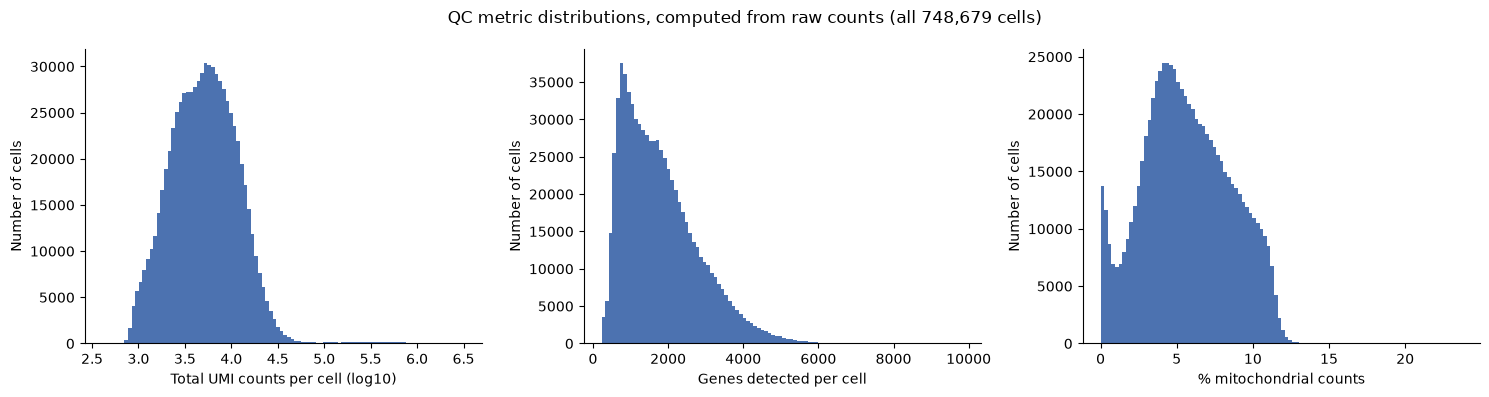

In [4]:
def is_outlier(series, n_mads):
    med, mad = np.median(series), (series - np.median(series)).abs().median()
    return (series < med - n_mads * mad) | (series > med + n_mads * mad)

log1p_total = np.log1p(qc_df["total_counts"])
log1p_ngenes = np.log1p(qc_df["n_genes_by_counts"])

outlier = is_outlier(log1p_total, 5) | is_outlier(log1p_ngenes, 5)
mt_outlier = is_outlier(qc_df["pct_counts_mt"], 3) | (qc_df["pct_counts_mt"] > 10)

print(f"Count/gene-count outliers (>5 MAD): {outlier.sum():,} / {n_cells:,} ({100*outlier.mean():.1f}%)")
print(f"Mitochondrial outliers (>3 MAD or >10%): {mt_outlier.sum():,} / {n_cells:,} ({100*mt_outlier.mean():.1f}%)")

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, col, xlabel, log in zip(
    axes,
    ["total_counts", "n_genes_by_counts", "pct_counts_mt"],
    ["Total UMI counts per cell (log10)", "Genes detected per cell", "% mitochondrial counts"],
    [True, False, False],
):
    data = np.log10(qc_df[col] + 1) if log else qc_df[col]
    ax.hist(data, bins=100, color="#4C72B0", edgecolor="none")
    ax.set_xlabel(xlabel)
    ax.set_ylabel("Number of cells")
fig.suptitle("QC metric distributions, computed from raw counts (all 748,679 cells)")
fig.tight_layout()
plt.show()

Batch correction with scVI

To understand how the author correct the datatset i trained a 20-study,
15,512-cell stratified subsample

The final Panel D UMAP (Section 6D) uses the authors' own full-atlas scVI embedding
(`obsm['X_scVI_umap']`, already loaded above)

In [5]:
import anndata as ad
import scanpy as sc

SUBSAMPLE_CACHE = os.path.join(RESULTS_DIR, "scvi_demo_subsample.h5ad")
WINDOW_PER_STUDY = 800

if os.path.exists(SUBSAMPLE_CACHE):
    print("Loading cached subsample...")
    adata_sub = sc.read_h5ad(SUBSAMPLE_CACHE)
else:
    study_codes = obs["Study"].cat.codes.values
    cats = obs["Study"].cat.categories
    change_idx = np.where(study_codes[1:] != study_codes[:-1])[0] + 1
    starts = np.concatenate([[0], change_idx])
    ends = np.concatenate([change_idx, [len(study_codes)]])
    runs = pd.DataFrame({"start": starts, "end": ends, "study": cats[study_codes[starts]]})
    runs["len"] = runs["end"] - runs["start"]
    best = runs.sort_values("len", ascending=False).drop_duplicates("study").sort_values("study")

    with h5py.File(H5_PATH, "r") as f:
        indptr = f["X/indptr"][:]
        raw_data_ds, raw_idx_ds = f["raw/X/data"], f["raw/X/indices"]
        blocks, row_slices = [], []
        for _, row in best.iterrows():
            L = row["len"]
            w = min(WINDOW_PER_STUDY, L)
            s = row["start"] + (L - w) // 2
            e = s + w
            byte_s, byte_e = int(indptr[s]), int(indptr[e])
            local_indptr = indptr[s:e + 1] - indptr[s]
            blocks.append(sparse.csr_matrix(
                (raw_data_ds[byte_s:byte_e], raw_idx_ds[byte_s:byte_e], local_indptr),
                shape=(e - s, n_genes)))
            row_slices.append((int(s), int(e)))

    X_counts = sparse.vstack(blocks, format="csr")
    obs_sub = pd.concat([obs.iloc[s:e] for s, e in row_slices], axis=0).reset_index(drop=True)
    adata_sub = ad.AnnData(X=X_counts, obs=obs_sub, var=pd.DataFrame(index=gene_names))
    adata_sub.var_names_make_unique()
    adata_sub.layers["counts"] = adata_sub.X.copy()
    adata_sub.write_h5ad(SUBSAMPLE_CACHE)

print(adata_sub)
print(adata_sub.obs["Study"].value_counts())

Loading cached subsample...


AnnData object with n_obs × n_vars = 15512 × 21588
    obs: 'cell_type', 'donor_id', 'Sample', 'disease', 'ELN Classification', 'ELN Risk Group', 'Fine Age Group', 'Main Age Group', 'sex', 'Study'
    layers: 'counts'
Study
beneyto-calabuig-2023    800
caron_2020               800
fiskus_2023              800
human_cell_atlas         800
jiang_2020               800
johnston_2020            800
lasry_2022               800
li_2022                  800
mumme_2023               800
naldini_2023             800
oetjen_2018              800
pei_2020                 800
petti_2019               800
setty_2019               800
van_galen_2019           800
velten_2021              800
zhang_2023               800
zhai_2022                800
zheng_2017               800
stetson_2021             312
Name: count, dtype: int64


In [6]:
import scvi

sc.settings.verbosity = 0
scvi.settings.seed = 666

SCVI_RESULT_CACHE = os.path.join(RESULTS_DIR, "scvi_demo_result.h5ad")

if os.path.exists(SCVI_RESULT_CACHE):
    print("Loading cached scVI demo result...")
    adata_demo = sc.read_h5ad(SCVI_RESULT_CACHE)
else:
    adata_demo = adata_sub.copy()

    # Uncorrected baseline: standard log-normalize -> HVG -> scale -> PCA -> UMAP
    adata_demo.X = adata_demo.layers["counts"].copy()
    sc.pp.normalize_total(adata_demo, target_sum=1e4)
    sc.pp.log1p(adata_demo)
    sc.pp.highly_variable_genes(adata_demo, n_top_genes=2000, flavor="seurat", batch_key="Study")

    adata_hvg = adata_demo[:, adata_demo.var.highly_variable].copy()
    sc.pp.scale(adata_hvg, max_value=10)
    sc.tl.pca(adata_hvg, n_comps=30)
    sc.pp.neighbors(adata_hvg, use_rep="X_pca", key_added="uncorrected_neighbors")
    sc.tl.umap(adata_hvg, neighbors_key="uncorrected_neighbors")
    adata_demo.obsm["X_umap_uncorrected"] = adata_hvg.obsm["X_umap"]

    # scVI, trained on raw counts restricted to the same HVGs (matches repo model spec)
    adata_scvi_in = adata_demo[:, adata_demo.var.highly_variable].copy()
    adata_scvi_in.X = adata_scvi_in.layers["counts"].copy()
    scvi.model.SCVI.setup_anndata(adata_scvi_in, layer="counts", batch_key="Sample")
    vae = scvi.model.SCVI(adata_scvi_in, n_layers=2, n_latent=30, gene_likelihood="nb")
    vae.train(max_epochs=60, early_stopping=True)

    adata_demo.obsm["X_scVI"] = vae.get_latent_representation()
    sc.pp.neighbors(adata_demo, use_rep="X_scVI", key_added="scvi_neighbors")
    sc.tl.umap(adata_demo, neighbors_key="scvi_neighbors")
    adata_demo.obsm["X_umap_scvi"] = adata_demo.obsm["X_umap"]

    adata_demo.write_h5ad(SCVI_RESULT_CACHE)

print(adata_demo)

Seed set to 666


Loading cached scVI demo result...


AnnData object with n_obs × n_vars = 15512 × 21588
    obs: 'cell_type', 'donor_id', 'Sample', 'disease', 'ELN Classification', 'ELN Risk Group', 'Fine Age Group', 'Main Age Group', 'sex', 'Study'
    var: 'highly_variable', 'means', 'dispersions', 'dispersions_norm', 'highly_variable_nbatches', 'highly_variable_intersection'
    uns: 'hvg', 'log1p', 'scvi_neighbors', 'umap'
    obsm: 'X_pca', 'X_scVI', 'X_umap', 'X_umap_scvi', 'X_umap_uncorrected'
    layers: 'counts'
    obsp: 'scvi_neighbors_connectivities', 'scvi_neighbors_distances'


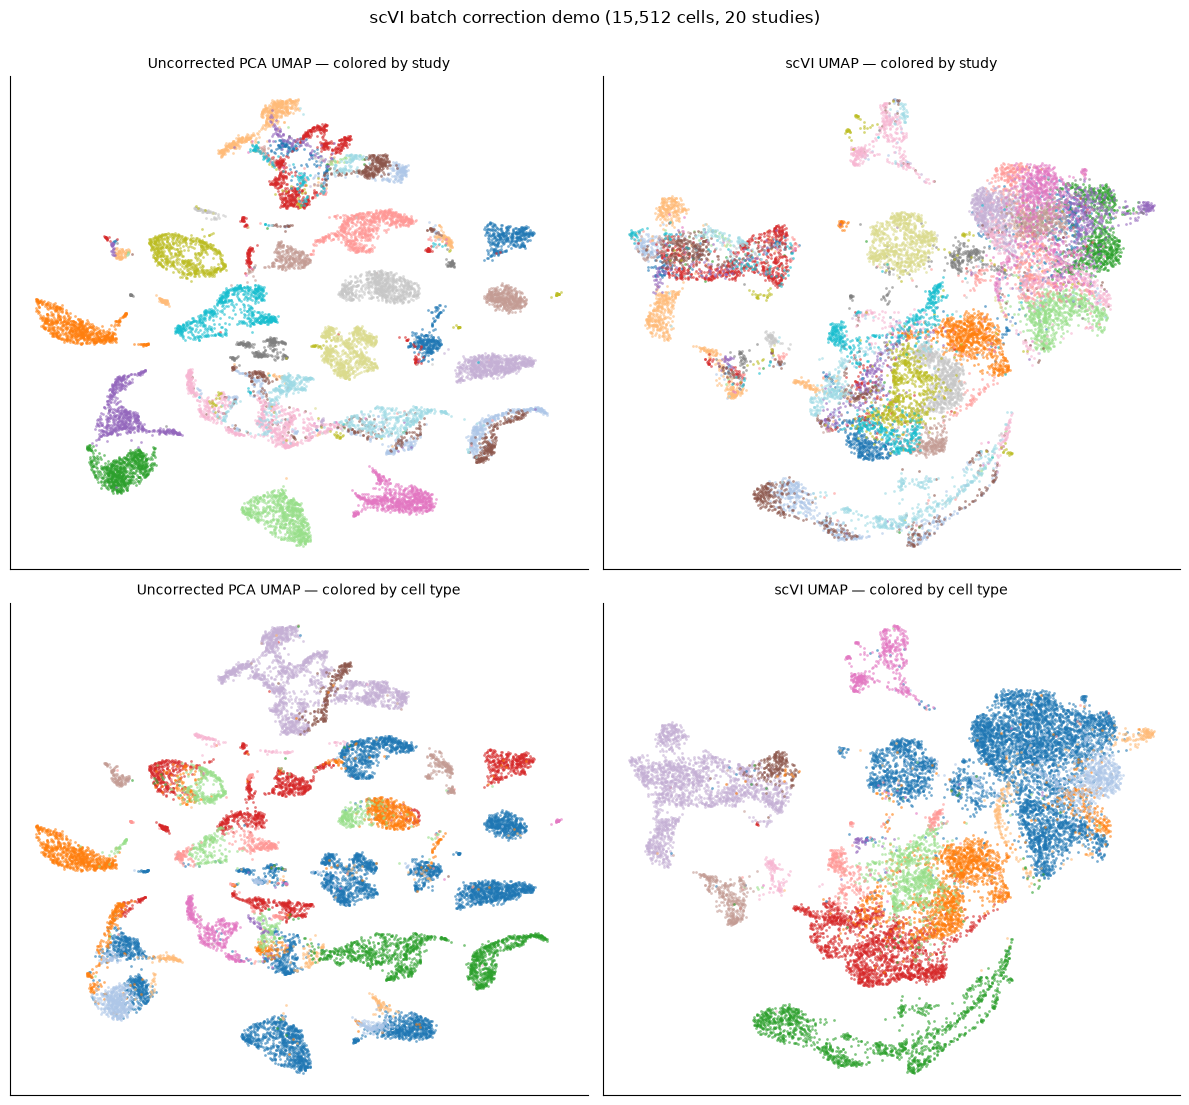

In [7]:
fig, axes = plt.subplots(2, 2, figsize=(12, 11))

study_cats = adata_demo.obs["Study"].cat.categories
study_colors = dict(zip(study_cats, sns.color_palette("tab20", len(study_cats))))
ct_colors = {ct: CELL_TYPE_PALETTE.get(ct, (0.6, 0.6, 0.6)) for ct in adata_demo.obs["cell_type"].cat.categories}

panels = [
    (axes[0, 0], "X_umap_uncorrected", "Study", study_colors, "Uncorrected PCA UMAP — colored by study"),
    (axes[0, 1], "X_umap_scvi", "Study", study_colors, "scVI UMAP — colored by study"),
    (axes[1, 0], "X_umap_uncorrected", "cell_type", ct_colors, "Uncorrected PCA UMAP — colored by cell type"),
    (axes[1, 1], "X_umap_scvi", "cell_type", ct_colors, "scVI UMAP — colored by cell type"),
]
for ax, basis, colorby, colors, title in panels:
    xy = adata_demo.obsm[basis]
    groups = adata_demo.obs[colorby].astype(str).values
    for g in pd.unique(groups):
        m = groups == g
        ax.scatter(xy[m, 0], xy[m, 1], s=4, alpha=0.6, color=colors.get(g, (0.6, 0.6, 0.6)), label=g, linewidths=0)
    ax.set_title(title, fontsize=10)
    ax.set_xticks([]); ax.set_yticks([])

fig.suptitle(f"scVI batch correction demo ({adata_demo.n_obs:,} cells, {len(study_cats)} studies)", y=1.0)
fig.tight_layout()
plt.show()

4. Cell-type annotation & ELN clinical subtyping (reused from the atlas)

The full-atlas cell-type labels come from the multi-method consensus pipeline in
`3_Analysis/4_Annotation` 

The **ELN Classification / ELN Risk Group** fields implement the rule-based mapping in
the repo's `annotations.py` (mutation- and cytogenetics-based, per ELN 2022 criteria).

In [8]:
eln_map = obs.groupby("ELN Classification", observed=True)["ELN Risk Group"].nunique()
assert (eln_map == 1).all(), "Expected a 1:1 mapping between ELN Classification and Risk Group"

cross = pd.crosstab(obs["ELN Classification"], obs["ELN Risk Group"])
cross = cross.loc[(cross.sum(axis=1)).sort_values(ascending=False).index]
cross

ELN Risk Group,Adverse,Favourable,Healthy_Donor,Intermediate,Unclassified
ELN Classification,,,,,
Healthy_Donor,0,0,166765,0,0
RUNX1-RUNX1T1,0,100930,0,0,0
Other,0,0,0,0,83015
MDS Related Genes,56682,0,0,0,0
NPM1,0,50264,0,0,0
-7,41785,0,0,0,0
TP53,41308,0,0,0,0
FLT3-ITD,0,0,0,39348,0
MLLr-Other,38651,0,0,0,0


In [9]:
print("Standardized cell_type labels:")
print(obs["cell_type"].value_counts())
print()
print("Author's original cell_type labels:")
print(obs["Author Cell Type"].value_counts())

Standardized cell_type labels:
cell_type
hematopoietic stem cell                    203742
T cell                                     127565
monocyte                                   116579
granulocyte monocyte progenitor cell        58580
common myeloid progenitor                   52454
erythroid lineage cell                      39276
promonocyte                                 39137
B cell                                      25671
megakaryocyte-erythroid progenitor cell     25332
conventional dendritic cell                 21962
natural killer cell                         16267
pro-B cell                                  13772
plasmacytoid dendritic cell                  5393
plasma cell                                  2949
Name: count, dtype: int64

Author's original cell_type labels:
Author Cell Type
HSPC          203742
T             127565
CD14+ Mono     98094
GMP            58580
CMP            52454
Erythroid      39276
ProMono        39137
B              25671
MEP        

5. Understanding the dataset

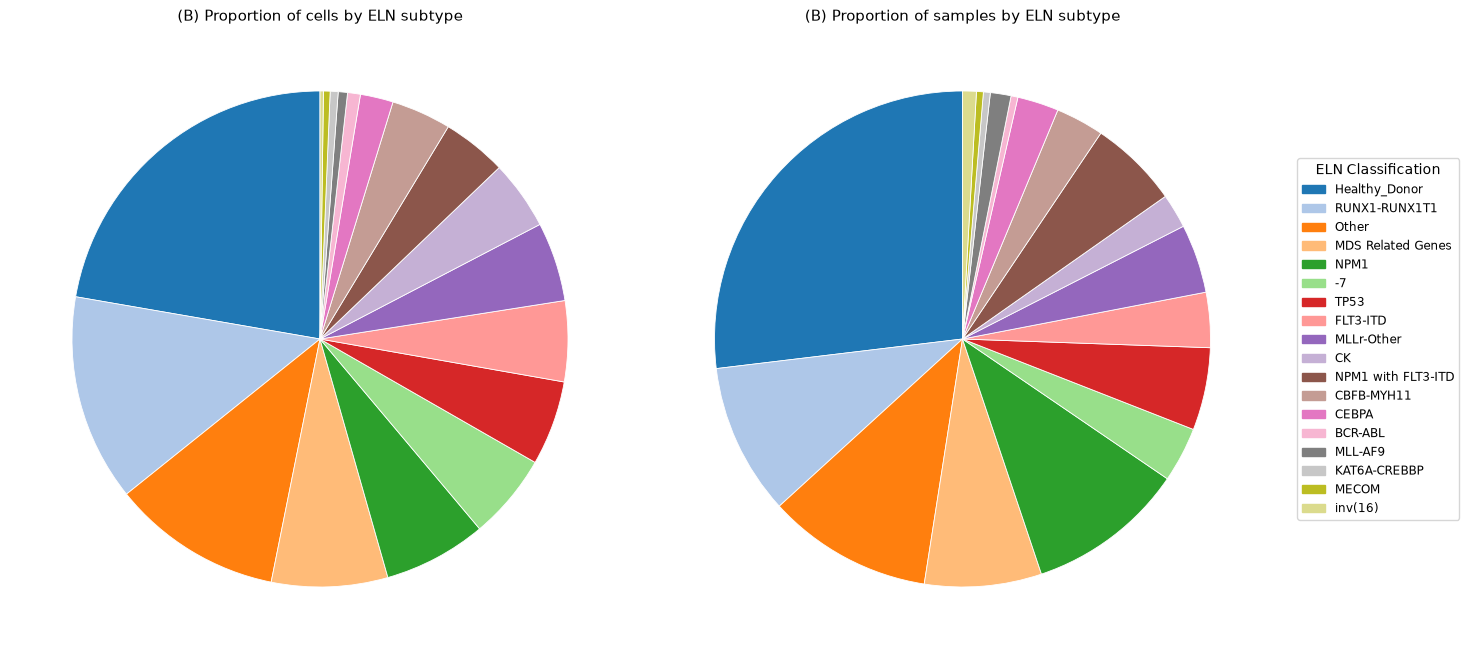

n cells = 748,679   n samples = 223


In [11]:
eln_order = obs["ELN Classification"].value_counts().index.tolist()
eln_colors = dict(zip(eln_order, sns.color_palette("tab20", len(eln_order))))

cell_props = obs["ELN Classification"].value_counts(normalize=True).loc[eln_order]
sample_props = (
    obs.drop_duplicates("Sample")["ELN Classification"]
    .value_counts(normalize=True).loc[eln_order]
)

fig, axes = plt.subplots(1, 2, figsize=(13, 6.5))
for ax, props, title in zip(axes, [cell_props, sample_props],
                             ["Proportion of cells", "Proportion of samples"]):
    wedges, _ = ax.pie(props.values, colors=[eln_colors[k] for k in props.index],
                        startangle=90, wedgeprops=dict(edgecolor="white", linewidth=0.6))
    ax.set_title(f"(B) {title} by ELN subtype", fontsize=11)

fig.legend(
    [mpatches.Patch(color=eln_colors[k]) for k in eln_order], eln_order,
    loc="center left", bbox_to_anchor=(1.0, 0.5), fontsize=8.5, title="ELN Classification",
)
fig.tight_layout()
plt.show()

print(f"n cells = {len(obs):,}   n samples = {obs['Sample'].nunique()}")

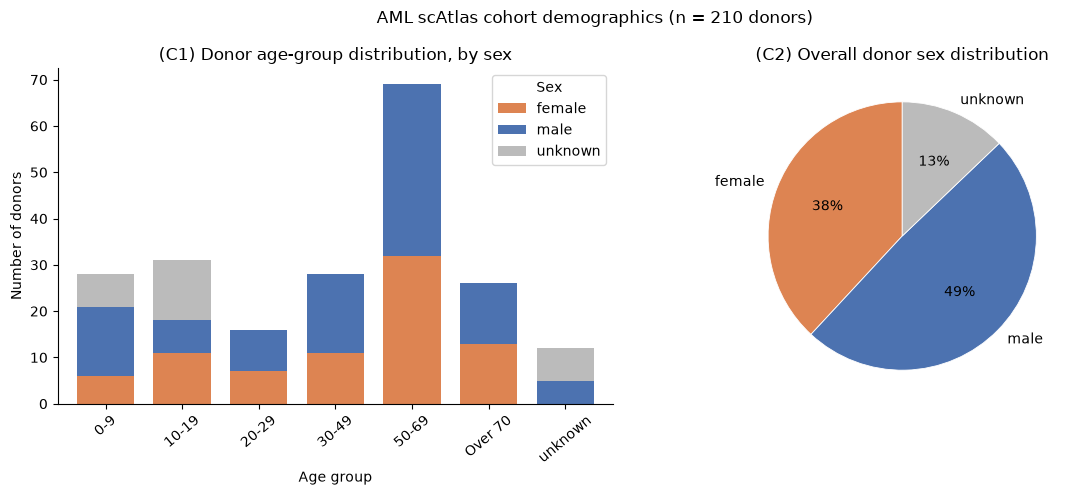

In [12]:
donor_level = obs.drop_duplicates("donor_id")[["donor_id", "Fine Age Group", "Main Age Group", "sex"]]

age_order = ["0-9", "10-19", "20-29", "30-49", "50-69", "Over 70", "unknown"]
sex_order = ["female", "male", "unknown"]
sex_colors = {"female": "#dd8452", "male": "#4c72b0", "unknown": "#bbbbbb"}

age_sex = (
    donor_level.groupby(["Fine Age Group", "sex"], observed=True).size()
    .unstack(fill_value=0).reindex(index=age_order, columns=sex_order, fill_value=0)
)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
age_sex.plot(kind="bar", stacked=True, ax=axes[0], color=[sex_colors[s] for s in sex_order], width=0.75)
axes[0].set_xlabel("Age group"); axes[0].set_ylabel("Number of donors")
axes[0].set_title("(C1) Donor age-group distribution, by sex")
axes[0].legend(title="Sex")
axes[0].tick_params(axis="x", rotation=40)

sex_counts = donor_level["sex"].value_counts().loc[[s for s in sex_order if s in donor_level["sex"].unique()]]
axes[1].pie(sex_counts.values, labels=sex_counts.index, autopct="%1.0f%%",
            colors=[sex_colors[s] for s in sex_counts.index], startangle=90,
            wedgeprops=dict(edgecolor="white", linewidth=0.6))
axes[1].set_title("(C2) Overall donor sex distribution")

fig.suptitle(f"AML scAtlas cohort demographics (n = {donor_level.shape[0]} donors)")
fig.tight_layout()
plt.show()

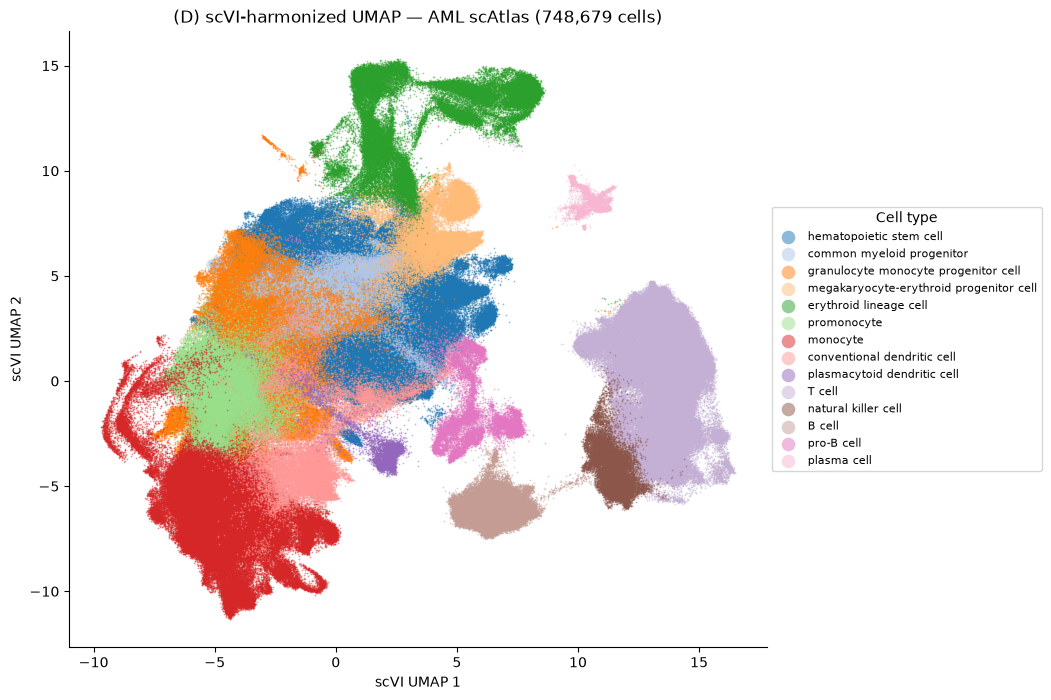

In [13]:
fig, ax = plt.subplots(figsize=(9, 8))
ct_values = obs["cell_type"].astype(str).values
rng = np.random.default_rng(0)
order = rng.permutation(len(ct_values))  # avoid one cell type systematically overplotting another

for ct in CELL_TYPE_ORDER:
    m = ct_values[order] == ct
    ax.scatter(X_scVI_umap[order][m, 0], X_scVI_umap[order][m, 1],
               s=1.5, alpha=0.5, linewidths=0, color=CELL_TYPE_PALETTE[ct], label=ct, rasterized=True)

ax.set_xlabel("scVI UMAP 1"); ax.set_ylabel("scVI UMAP 2")
ax.set_title("(D) scVI-harmonized UMAP — AML scAtlas (748,679 cells)")
leg = ax.legend(markerscale=8, fontsize=8, loc="center left", bbox_to_anchor=(1.0, 0.5), title="Cell type")
plt.show()

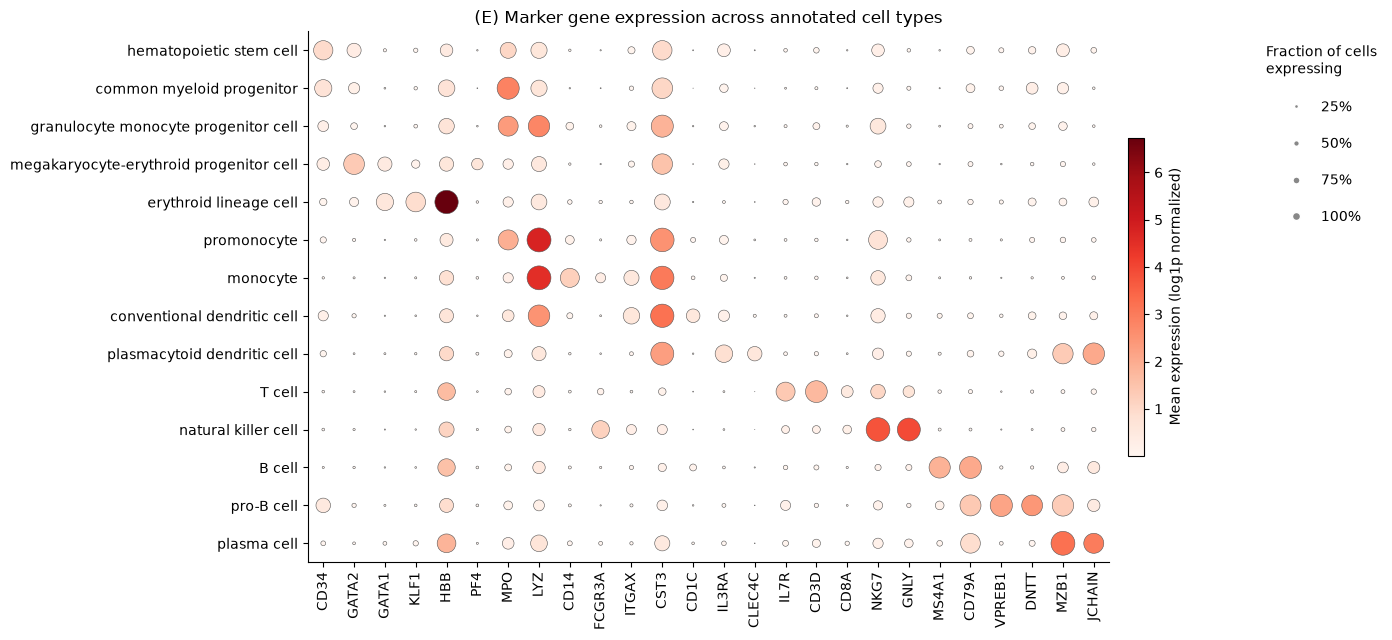

In [14]:
mean_expr = marker_df.groupby(obs["cell_type"].values, observed=True).mean()
frac_expr = (marker_df > 0).groupby(obs["cell_type"].values, observed=True).mean()

row_order = [ct for ct in CELL_TYPE_ORDER if ct in mean_expr.index]
mean_expr = mean_expr.loc[row_order, MARKER_GENES]
frac_expr = frac_expr.loc[row_order, MARKER_GENES]

fig, ax = plt.subplots(figsize=(14, 6.5))
x_idx = np.arange(len(MARKER_GENES))
y_idx = np.arange(len(row_order))
xx, yy = np.meshgrid(x_idx, y_idx)

sizes = frac_expr.values * 300
colors = mean_expr.values

sca = ax.scatter(xx.ravel(), yy.ravel(), s=sizes.ravel(), c=colors.ravel(),
                  cmap="Reds", edgecolors="#555555", linewidths=0.4)

ax.set_xticks(x_idx); ax.set_xticklabels(MARKER_GENES, rotation=90)
ax.set_yticks(y_idx); ax.set_yticklabels(row_order)
ax.set_xlim(-0.5, len(MARKER_GENES) - 0.5); ax.set_ylim(-0.5, len(row_order) - 0.5)
ax.invert_yaxis()
ax.set_title("(E) Marker gene expression across annotated cell types")

cbar = fig.colorbar(sca, ax=ax, shrink=0.6, pad=0.02)
cbar.set_label("Mean expression (log1p normalized)")

legend_fracs = [0.25, 0.5, 0.75, 1.0]
legend_handles = [
    Line2D([0], [0], marker="o", color="w", markerfacecolor="#888888",
           markersize=np.sqrt(f * 300) / 3.0, label=f"{int(f*100)}%")
    for f in legend_fracs
]
ax.legend(handles=legend_handles, title="Fraction of cells\nexpressing", loc="upper left",
          bbox_to_anchor=(1.18, 1.0), frameon=False, labelspacing=1.6)

fig.tight_layout()
plt.show()

6.  cell type vs. number of patients (healthy vs. leukemia)


In [15]:
PATIENT_THRESHOLD = 5   # ">5 patients"
CELL_THRESHOLD = 20     # ">20 cells"

summary = (
    obs.groupby(["cell_type", "disease"], observed=True)["donor_id"].nunique()
    .unstack(fill_value=0)
    .rename(columns={"normal": "N patients - healthy", "myeloid leukemia": "N patients - leukemia"})
)
sample_summary = (
    obs.groupby(["cell_type", "disease"], observed=True)["Sample"].nunique()
    .unstack(fill_value=0)
    .rename(columns={"normal": "N samples - healthy", "myeloid leukemia": "N samples - leukemia"})
)
cells_per_group = (
    obs.groupby(["cell_type", "disease"], observed=True).size()
    .unstack(fill_value=0)
    .rename(columns={"normal": "_cells_healthy", "myeloid leukemia": "_cells_leukemia"})
)

summary["N cells (total)"] = obs.groupby("cell_type", observed=True).size()
summary = summary.join(sample_summary).join(cells_per_group)

COL_FLAG = f">{PATIENT_THRESHOLD} patients & >{CELL_THRESHOLD} cells (Yes/No)"

# Flag: STRICTLY more than PATIENT_THRESHOLD patients AND STRICTLY more than
# CELL_THRESHOLD cells, required in BOTH the healthy and leukemia groups.
summary[COL_FLAG] = np.where(
    (summary["N patients - healthy"] > PATIENT_THRESHOLD)
    & (summary["N patients - leukemia"] > PATIENT_THRESHOLD)
    & (summary["_cells_healthy"] > CELL_THRESHOLD)
    & (summary["_cells_leukemia"] > CELL_THRESHOLD),
    "Yes", "No",
)

summary = summary[[
    "N cells (total)",
    "N patients - healthy", "N patients - leukemia",
    "N samples - healthy", "N samples - leukemia",
    COL_FLAG,
]]
summary = summary.loc[summary["N cells (total)"].sort_values(ascending=False).index]
summary.index.name = "Cell type"

numeric_cols = summary.columns.drop(COL_FLAG)

def _highlight_flag(val):
    color = "#c6efce" if val == "Yes" else "#ffc7ce"
    return f"background-color: {color}"

summary.style.background_gradient(cmap="Blues", subset=["N cells (total)"]) \
             .background_gradient(cmap="Greens", subset=["N patients - healthy", "N samples - healthy"]) \
             .background_gradient(cmap="Reds", subset=["N patients - leukemia", "N samples - leukemia"]) \
             .map(_highlight_flag, subset=[COL_FLAG]) \
             .format("{:,.0f}", subset=numeric_cols)

disease,N cells (total),N patients - healthy,N patients - leukemia,N samples - healthy,N samples - leukemia,>5 patients & >20 cells (Yes/No)
Cell type,,,,,,
hematopoietic stem cell,"203,742",51,157,60,161,Yes
T cell,"127,565",48,143,56,145,Yes
monocyte,"116,579",51,147,60,149,Yes
granulocyte monocyte progenitor cell,"58,580",43,151,44,155,Yes
common myeloid progenitor,"52,454",28,145,29,148,Yes
erythroid lineage cell,"39,276",51,132,60,135,Yes
promonocyte,"39,137",47,131,47,133,Yes
B cell,"25,671",50,138,58,139,Yes
megakaryocyte-erythroid progenitor cell,"25,332",49,148,58,151,Yes


">5 patients & >20 cells (Yes/No)"

7. T-cell pseudobulk differential expression for mitochondrial genes 

A focused bulk-style comparison of **T cells only**, healthy donors vs. AML patients,
built by summing raw counts per donor (pseudobulk) and testing with a DESeq2-style
negative-binomial model, then interpreted through the lens of **MitoCarta3.0**
(`data/Human.MitoCarta3.0.xls`) 1,136 genes  ~149 functional patways 

I Exclude CD34+-selected samples, CD34+ enrichment protocols deplete mature lymphocytes by
  design, so we checked T-cell representation per study directly: `fiskus_2023`,
  `stetson_2021`, `setty_2019`, `naldini_2023` and `zhai_2022` have 0–0.3% T cells
  (vs. 3–68% elsewhere) 

In [16]:
CT, LABEL, PFX = "T cell", "T cell", "tcell"
if "RESULTS" not in globals():
    RESULTS = {}

MIN_CELLS_PER_DONOR = 20
MIN_DONORS_PER_GROUP = 5

is_ct = (obs["cell_type"] == CT)
print(f"{LABEL}s before any donor-level filter: {is_ct.sum():,} cells, "
      f"{obs.loc[is_ct, 'donor_id'].nunique()} donors, "
      f"{obs.loc[is_ct, 'Study'].nunique()} studies")

ct_per_donor = (
    obs.loc[is_ct].groupby(["donor_id", "disease"], observed=True).size()
    .reset_index(name="n_cells_ct")
)
qualifying = ct_per_donor[ct_per_donor["n_cells_ct"] >= MIN_CELLS_PER_DONOR]
dropped = ct_per_donor[ct_per_donor["n_cells_ct"] < MIN_CELLS_PER_DONOR]
zero_donors = obs.loc[~obs["donor_id"].isin(ct_per_donor["donor_id"]), "donor_id"].nunique()

n_per_group = qualifying.groupby("disease", observed=True)["donor_id"].nunique()
assert (n_per_group >= MIN_DONORS_PER_GROUP).all(), "A disease group has <5 qualifying donors!"

print(f"\nDonors with ZERO {LABEL}s (dropped outright, mostly CD34+-sorted studies): {zero_donors}")
print(f"Donors with 1-{MIN_CELLS_PER_DONOR - 1} {LABEL}s (dropped, too few cells): "
      f"{dropped['donor_id'].nunique()}  ({dropped.groupby('disease', observed=True)['donor_id'].nunique().to_dict()})")
print(f"\nDonors KEPT (>={MIN_CELLS_PER_DONOR} {LABEL}s), per group:")
print(n_per_group)
print(f"\nTotal donors kept: {len(qualifying)} / {obs['donor_id'].nunique()} in the full atlas")
print(f"Total {LABEL}s kept for pseudobulk: {qualifying['n_cells_ct'].sum():,} "
      f"(of {is_ct.sum():,} {LABEL}s overall)")

qualifying_donors = qualifying["donor_id"].tolist()

studies_dropped_entirely = sorted(
    set(obs["Study"].unique())
    - set(obs.loc[obs["donor_id"].isin(qualifying_donors), "Study"].unique())
)
print(f"\nStudies with ZERO qualifying donors (effectively fully excluded): {studies_dropped_entirely}")

T cells before any donor-level filter: 127,565 cells, 191 donors, 17 studies

Donors with ZERO T cells (dropped outright, mostly CD34+-sorted studies): 19
Donors with 1-19 T cells (dropped, too few cells): 31  ({'myeloid leukemia': 29, 'normal': 2})

Donors KEPT (>=20 T cells), per group:
disease
myeloid leukemia    114
normal               46
Name: donor_id, dtype: int64

Total donors kept: 160 / 210 in the full atlas
Total T cells kept for pseudobulk: 127,300 (of 127,565 T cells overall)

Studies with ZERO qualifying donors (effectively fully excluded): ['fiskus_2023', 'naldini_2023', 'setty_2019', 'stetson_2021', 'zhai_2022']


T cell pseudobulk aggregation (sum raw counts per donor)

i cannot load the full raw-count matrix into memory, so donor-level
sums are accumulated with the same chunked HDF5 scan, restricted to T cells from the
qualifying donors and aggregated with a sparse indicator-matrix product
(`indicator @ chunk`) 

In [17]:
PB_CACHE = os.path.join(RESULTS_DIR, f"{PFX}_pseudobulk_counts.parquet")
PB_META_CACHE = os.path.join(RESULTS_DIR, f"{PFX}_pseudobulk_donor_meta.parquet")

if os.path.exists(PB_CACHE) and os.path.exists(PB_META_CACHE):
    print(f"Loading cached {LABEL} pseudobulk matrix...")
    pb_counts = pd.read_parquet(PB_CACHE)
    donor_meta = pd.read_parquet(PB_META_CACHE)
else:
    donor_to_qidx = {d: i for i, d in enumerate(qualifying_donors)}
    n_donors_pb = len(qualifying_donors)
    donor_codes_arr = obs["donor_id"].values
    is_ct_arr = is_ct.values
    assign = np.full(n_cells, -1, dtype=np.int64)
    mask_keep_cell = is_ct_arr & np.isin(donor_codes_arr, qualifying_donors)
    keep_rows = np.where(mask_keep_cell)[0]
    assign[keep_rows] = np.array([donor_to_qidx[d] for d in donor_codes_arr[keep_rows]])

    t0 = time.time()
    pseudobulk = np.zeros((n_donors_pb, n_genes), dtype=np.float64)
    with h5py.File(H5_PATH, "r") as f:
        indptr = f["X/indptr"][:]
        raw_data_ds, raw_idx_ds = f["raw/X/data"], f["raw/X/indices"]
        for start in range(0, n_cells, CHUNK_ROWS):
            end = min(start + CHUNK_ROWS, n_cells)
            chunk_assign = assign[start:end]
            if not np.any(chunk_assign >= 0):
                continue
            s, e = int(indptr[start]), int(indptr[end])
            local_indptr = indptr[start:end + 1] - indptr[start]
            raw_chunk = sparse.csr_matrix(
                (raw_data_ds[s:e], raw_idx_ds[s:e], local_indptr),
                shape=(end - start, n_genes))
            valid = chunk_assign >= 0
            rows = np.where(valid)[0]
            indicator = sparse.csr_matrix(
                (np.ones(len(rows)), (chunk_assign[valid], rows)),
                shape=(n_donors_pb, end - start))
            pseudobulk += indicator.dot(raw_chunk).toarray()
    print(f"Pseudobulk scan done in {time.time()-t0:.0f}s")

    pb_counts = pd.DataFrame(pseudobulk, index=qualifying_donors, columns=gene_names)
    donor_meta = (
        obs[obs["donor_id"].isin(qualifying_donors)]
        .drop_duplicates("donor_id").set_index("donor_id")
        .loc[qualifying_donors, ["disease", "Study", "Fine Age Group", "Main Age Group", "sex", "ELN Risk Group"]]
    )
    pb_counts.to_parquet(PB_CACHE)
    donor_meta.to_parquet(PB_META_CACHE)

print(f"Pseudobulk matrix: {pb_counts.shape[0]} donors x {pb_counts.shape[1]} genes")
donor_meta["disease"].value_counts()

Loading cached T cell pseudobulk matrix...


Pseudobulk matrix: 160 donors x 21588 genes


disease
myeloid leukemia    114
normal               46
Name: count, dtype: int64

T cell DESeq2-style differential expressionrix.

In [18]:
counts_all = pb_counts.round().astype(int)
gene_sums = counts_all.sum(axis=0)
counts_filt = counts_all.loc[:, gene_sums >= 10]
print(f"Genes after near-empty filter (sum>=10 across donors): {counts_filt.shape[1]} / {counts_all.shape[1]}")

meta = donor_meta.copy()
meta["disease"] = pd.Categorical(meta["disease"].astype(str), categories=["normal", "myeloid leukemia"])
meta["Study"] = meta["Study"].astype(str)

design_full = pd.get_dummies(meta[["Study", "disease"]], drop_first=True).astype(float)
design_full.insert(0, "intercept", 1.0)
rank = np.linalg.matrix_rank(design_full.values)
use_study_covariate = (rank == design_full.shape[1])
print(f"~ Study + disease design matrix: {design_full.shape}, rank {rank} "
      f"-> {'FULL RANK, using Study as covariate' if use_study_covariate else 'RANK DEFICIENT, falling back to ~ disease'}")

DESIGN_FORMULA = "~Study+disease" if use_study_covariate else "~disease"

Genes after near-empty filter (sum>=10 across donors): 18414 / 21588
~ Study + disease design matrix: (160, 16), rank 16 -> FULL RANK, using Study as covariate


In [19]:
from pydeseq2.dds import DeseqDataSet
from pydeseq2.ds import DeseqStats

DESEQ_CACHE = os.path.join(RESULTS_DIR, f"{PFX}_deseq_results.parquet")
VST_CACHE = os.path.join(RESULTS_DIR, f"{PFX}_vst.parquet")

if os.path.exists(DESEQ_CACHE) and os.path.exists(VST_CACHE):
    print("Loading cached DESeq2 results + VST matrix...")
    deseq_res = pd.read_parquet(DESEQ_CACHE)
    vst_df = pd.read_parquet(VST_CACHE)
else:
    dds = DeseqDataSet(counts=counts_filt, metadata=meta, design=DESIGN_FORMULA,
                        refit_cooks=True, quiet=True)
    dds.deseq2()

    dds.vst(use_design=False)
    vst_df = pd.DataFrame(dds.layers["vst_counts"], index=dds.obs_names, columns=dds.var_names)

    ds = DeseqStats(dds, contrast=["disease", "myeloid leukemia", "normal"], quiet=True)
    ds.summary()
    ds.lfc_shrink(coeff="disease[T.myeloid leukemia]")
    deseq_res = ds.results_df.copy()

    deseq_res.to_parquet(DESEQ_CACHE)
    vst_df.to_parquet(VST_CACHE)

print(f"DESeq2 results: {deseq_res.shape[0]} genes tested "
      f"(positive log2FC = higher in AML {LABEL}s vs. healthy {LABEL}s)")
print(f"Significant genes overall (padj < 0.05): {(deseq_res['padj'] < 0.05).sum()}")
deseq_res.sort_values("padj").head(10)

Loading cached DESeq2 results + VST matrix...


DESeq2 results: 18414 genes tested (positive log2FC = higher in AML T cells vs. healthy T cells)
Significant genes overall (padj < 0.05): 27


,baseMean,log2FoldChange,lfcSE,stat,pvalue,padj
UQCRFS1,158.787241,0.452912,0.123246,4.686375,0.000003,0.013569
ETV3,20.244869,-0.986862,0.300404,-4.606693,0.000004,0.013569
ADTRP,20.926879,1.626563,0.608706,4.305147,0.000017,0.021568
ZC3H6,32.868591,-0.708206,0.239098,-4.270425,0.000020,0.021568
ZBTB20,69.259447,-0.594693,0.200881,-4.287410,0.000018,0.021568
TTBK2,14.272546,-0.668621,0.229192,-4.287438,0.000018,0.021568
TNRC6C,46.697499,-0.627445,0.207901,-4.199965,0.000027,0.023582
RPS19BP1,117.784793,0.379138,0.120511,4.185597,0.000028,0.023582
SNRPB,232.778952,0.375864,0.119029,4.147812,0.000034,0.024739
UBE2N,117.518286,0.386169,0.131655,4.032825,0.000055,0.029076


VST-transformed PCA of donors, colored by disease and by study

Variance explained by PC1-5: [0.279 0.138 0.095 0.078 0.062]
Donors flagged as PCA outliers (>3 SD on PC1 or PC2): ['AML314', 'AML475', 'BM2']


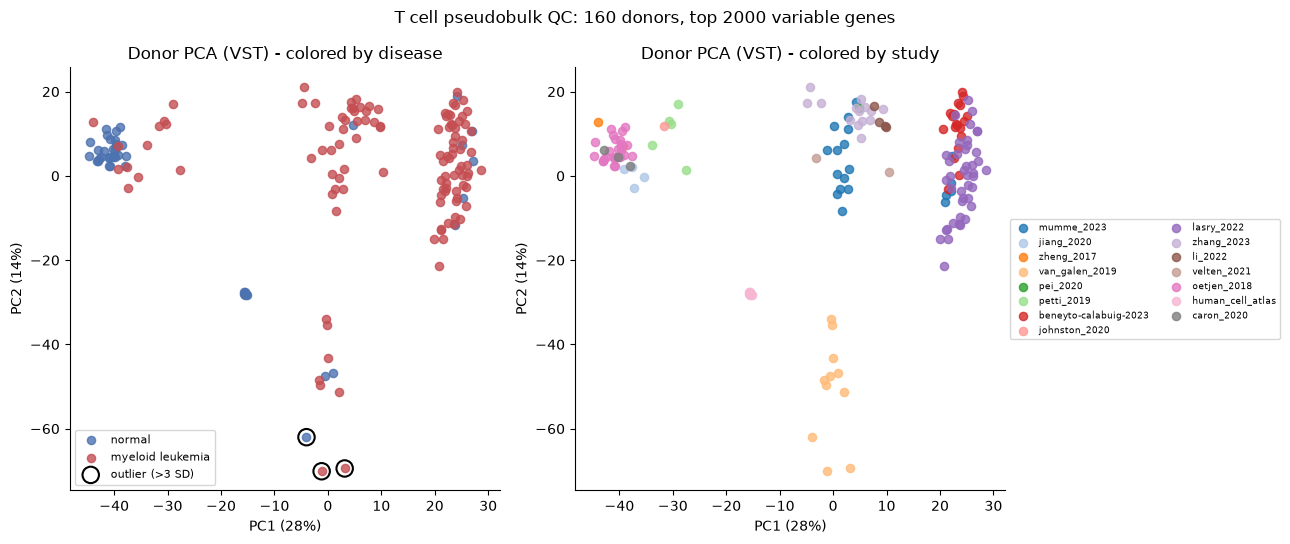

In [20]:
from sklearn.decomposition import PCA

gene_var = vst_df.var(axis=0).sort_values(ascending=False)
top_var_genes = gene_var.index[:2000]
Xc = vst_df[top_var_genes].values
Xc = Xc - Xc.mean(axis=0)
pca = PCA(n_components=10, random_state=0)
pcs = pca.fit_transform(Xc)
print("Variance explained by PC1-5:", np.round(pca.explained_variance_ratio_[:5], 3))

pc_df = pd.DataFrame(pcs[:, :2], columns=["PC1", "PC2"], index=vst_df.index).join(meta)
z1 = (pc_df["PC1"] - pc_df["PC1"].mean()) / pc_df["PC1"].std()
z2 = (pc_df["PC2"] - pc_df["PC2"].mean()) / pc_df["PC2"].std()
pc_df["outlier"] = (z1.abs() > 3) | (z2.abs() > 3)
outlier_donors = pc_df.index[pc_df["outlier"]].tolist()
print(f"Donors flagged as PCA outliers (>3 SD on PC1 or PC2): {outlier_donors}")

fig, axes = plt.subplots(1, 2, figsize=(13, 5.5))
disease_colors = {"normal": "#4c72b0", "myeloid leukemia": "#c44e52"}
for d, c in disease_colors.items():
    m = pc_df["disease"].astype(str) == d
    axes[0].scatter(pc_df.loc[m, "PC1"], pc_df.loc[m, "PC2"], s=35, alpha=0.8, color=c, label=d)
axes[0].scatter(pc_df.loc[pc_df["outlier"], "PC1"], pc_df.loc[pc_df["outlier"], "PC2"],
                s=140, facecolors="none", edgecolors="black", linewidths=1.5, label="outlier (>3 SD)")
axes[0].set_xlabel(f"PC1 ({pca.explained_variance_ratio_[0]*100:.0f}%)")
axes[0].set_ylabel(f"PC2 ({pca.explained_variance_ratio_[1]*100:.0f}%)")
axes[0].set_title("Donor PCA (VST) - colored by disease")
axes[0].legend(fontsize=8)

study_cats = pc_df["Study"].astype(str).unique()
study_colors2 = dict(zip(study_cats, sns.color_palette("tab20", len(study_cats))))
for s in study_cats:
    m = pc_df["Study"].astype(str) == s
    axes[1].scatter(pc_df.loc[m, "PC1"], pc_df.loc[m, "PC2"], s=35, alpha=0.8, color=study_colors2[s], label=s)
axes[1].set_xlabel(f"PC1 ({pca.explained_variance_ratio_[0]*100:.0f}%)")
axes[1].set_ylabel(f"PC2 ({pca.explained_variance_ratio_[1]*100:.0f}%)")
axes[1].set_title("Donor PCA (VST) - colored by study")
axes[1].legend(fontsize=6.5, ncol=2, loc="center left", bbox_to_anchor=(1.0, 0.5))

fig.suptitle(f"{LABEL} pseudobulk QC: {len(pc_df)} donors, top {len(top_var_genes)} variable genes")
fig.tight_layout()
plt.show()

### T cell MitoCarta3.0 genes: mtDNA-encoded (MT-) and nuclear-encoded analysed together

All MitoCarta3.0 genes present in the DE results form a single mitochondrial gene set. This
includes the 13 mtDNA-encoded protein-coding genes (MT-ND1, MT-CO1, ...), which MitoCarta
catalogs alongside the nuclear-encoded ones. The 18 mtDNA rRNA/tRNA genes are not in
MitoCarta, so they are not part of the mitochondrial gene set (they remain in the ranked
gene list for GSEA below).

In [21]:
mitocarta = pd.read_excel(os.path.join(DATA_DIR, "Human.MitoCarta3.0.xls"), sheet_name="A Human MitoCarta3.0")
mitocarta_genes = set(mitocarta["Symbol"].dropna().astype(str))

MT_GENES_ALL = sorted([g for g in gene_names if g.upper().startswith("MT-")])
mito_genes = sorted([g for g in mitocarta_genes if g in deseq_res.index])
n_mt_in_set = sum(g.upper().startswith("MT-") for g in mito_genes)
print(f"MitoCarta3.0: {len(mitocarta_genes)} genes total")
print(f"MitoCarta genes tested in this DE analysis: {len(mito_genes)} "
      f"({len(mito_genes) - n_mt_in_set} nuclear-encoded + {n_mt_in_set} mtDNA-encoded MT- genes)")

mito_table = deseq_res.loc[mito_genes].sort_values("padj")
mito_table["encoded_by"] = np.where(mito_table.index.str.upper().str.startswith("MT-"), "mtDNA", "nuclear")
display(mito_table.head(15)[["baseMean", "log2FoldChange", "lfcSE", "pvalue", "padj", "encoded_by"]])

MitoCarta3.0: 1136 genes total
MitoCarta genes tested in this DE analysis: 1029 (1016 nuclear-encoded + 13 mtDNA-encoded MT- genes)


,baseMean,log2FoldChange,lfcSE,pvalue,padj,encoded_by
UQCRFS1,158.787241,0.452912,0.123246,0.000003,0.013569,nuclear
CYC1,72.688761,0.486624,0.174699,0.000072,0.030007,nuclear
MRPS7,67.981349,0.315325,0.121273,0.000274,0.059572,nuclear
VDAC2,134.678926,0.297056,0.120729,0.000341,0.061792,nuclear
TMEM126A,46.548482,0.393708,0.170528,0.000362,0.061792,nuclear
COX18,12.604386,-0.497461,0.262552,0.000332,0.061792,nuclear
ATP5F1B,113.855426,0.039419,0.258445,0.000390,0.063027,nuclear
MRPS15,75.689488,0.254202,0.109078,0.000782,0.080462,nuclear
NDUFA12,166.555188,0.324820,0.154656,0.000792,0.080462,nuclear
MTHFD2,28.799609,0.545574,0.392349,0.000836,0.080462,nuclear


T cell single-gene calls and volcano plot

A mitochondrial gene (MitoCarta3.0, nuclear + mtDNA together) is called changed if
**padj < 0.05 and |shrunken log2FC| > 0.5**.

Mitochondrial genes passing padj<0.05 & |log2FC|>0.5: 0
Mitochondrial genes with padj<0.05 (any effect size): 2
None reach both thresholds simultaneously. Closest candidates (by padj):
            baseMean  log2FoldChange      padj encoded_by
UQCRFS1   158.787241        0.452912  0.013569    nuclear
CYC1       72.688761        0.486624  0.030007    nuclear
MRPS7      67.981349        0.315325  0.059572    nuclear
VDAC2     134.678926        0.297056  0.061792    nuclear
TMEM126A   46.548482        0.393708  0.061792    nuclear


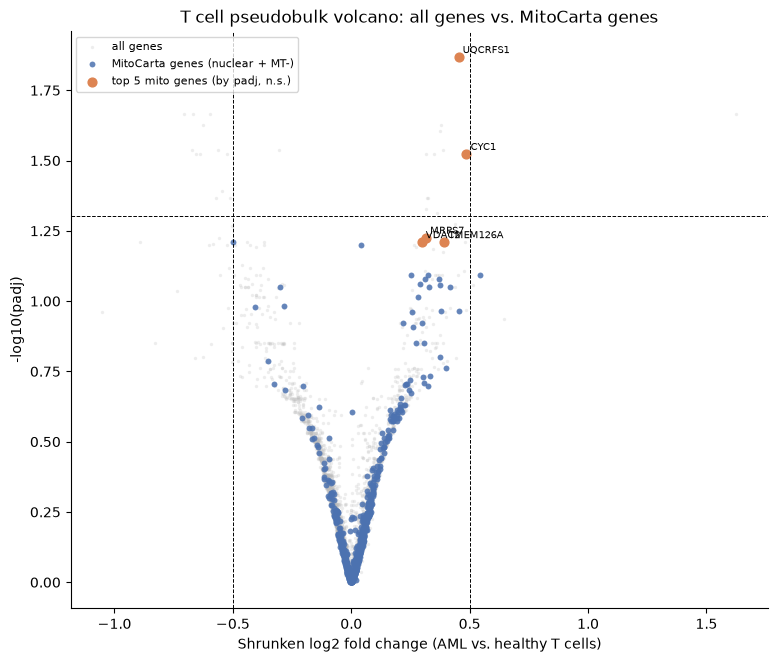

In [22]:
sig_mito = mito_table[(mito_table["padj"] < 0.05) & (mito_table["log2FoldChange"].abs() > 0.5)]
print(f"Mitochondrial genes passing padj<0.05 & |log2FC|>0.5: {len(sig_mito)}")
print(f"Mitochondrial genes with padj<0.05 (any effect size): {(mito_table['padj'] < 0.05).sum()}")
if len(sig_mito) == 0:
    print("None reach both thresholds simultaneously. Closest candidates (by padj):")
    print(mito_table.head(5)[["baseMean", "log2FoldChange", "padj", "encoded_by"]])

fig, ax = plt.subplots(figsize=(9, 7.5))
plot_df = deseq_res.dropna(subset=["padj"]).copy()
plot_df["neglog10padj"] = -np.log10(plot_df["padj"].clip(lower=1e-300))

ax.scatter(plot_df["log2FoldChange"], plot_df["neglog10padj"],
           s=6, alpha=0.25, color="#bbbbbb", linewidths=0, label="all genes")

mito_plot = plot_df.loc[plot_df.index.isin(mito_genes)]
ax.scatter(mito_plot["log2FoldChange"], mito_plot["neglog10padj"],
           s=18, alpha=0.85, color="#4c72b0", linewidths=0, label="MitoCarta genes (nuclear + MT-)")

if len(sig_mito) > 0:
    sig_plot = plot_df.loc[plot_df.index.isin(sig_mito.index)]
    ax.scatter(sig_plot["log2FoldChange"], sig_plot["neglog10padj"],
               s=40, color="#c44e52", label="significant mito (padj<0.05 & |L2FC|>0.5)")
    for gene, row in sig_plot.iterrows():
        ax.annotate(gene, (row["log2FoldChange"], row["neglog10padj"]), fontsize=7,
                    xytext=(3, 3), textcoords="offset points")
else:
    top5 = mito_table.head(5)
    top5_plot = plot_df.loc[plot_df.index.isin(top5.index)]
    ax.scatter(top5_plot["log2FoldChange"], top5_plot["neglog10padj"],
               s=40, color="#dd8452", label="top 5 mito genes (by padj, n.s.)")
    for gene, row in top5_plot.iterrows():
        ax.annotate(gene, (row["log2FoldChange"], row["neglog10padj"]), fontsize=7,
                    xytext=(3, 3), textcoords="offset points")

ax.axhline(-np.log10(0.05), color="black", lw=0.7, ls="--")
ax.axvline(0.5, color="black", lw=0.7, ls="--")
ax.axvline(-0.5, color="black", lw=0.7, ls="--")
ax.set_xlabel(f"Shrunken log2 fold change (AML vs. healthy {LABEL}s)")
ax.set_ylabel("-log10(padj)")
ax.set_title(f"{LABEL} pseudobulk volcano: all genes vs. MitoCarta genes")
ax.legend(fontsize=8, loc="upper left")
plt.show()

T cell pathway-level: GSEA against MitoCarta3.0 MitoPathways

all teste gene ordered by shrunken log2FC. mtDNA-encoded genes
contribute to pathway enrichment like any other member.

In [23]:
import gseapy as gp

GSEA_CACHE = os.path.join(RESULTS_DIR, f"{PFX}_gsea_results_mt_included.parquet")

mitopathways = pd.read_excel(os.path.join(DATA_DIR, "Human.MitoCarta3.0.xls"), sheet_name="C MitoPathways")
mitopathways = mitopathways.dropna(subset=["MitoPathway"])

gene_sets = {}
for _, row in mitopathways.iterrows():
    gene_sets[row["MitoPathway"]] = [g.strip() for g in str(row["Genes"]).split(",") if g.strip()]

gene_rank = deseq_res["log2FoldChange"].dropna().sort_values(ascending=False)
print(f"Ranked gene list (nuclear + MT-): {len(gene_rank)} genes; {len(gene_sets)} MitoPathway gene sets")

if os.path.exists(GSEA_CACHE):
    print("Loading cached GSEA results...")
    gsea_res = pd.read_parquet(GSEA_CACHE)
else:
    prerank = gp.prerank(
        rnk=gene_rank, gene_sets=gene_sets, min_size=5, max_size=500,
        permutation_num=1000, seed=0, threads=4, no_plot=True, outdir=None,
    )
    gsea_res = prerank.res2d.copy()
    gsea_res["NES"] = gsea_res["NES"].astype(float)
    gsea_res["FDR q-val"] = gsea_res["FDR q-val"].astype(float)
    gsea_res.to_parquet(GSEA_CACHE)

print(f"Pathways tested: {len(gsea_res)}")
print(f"Pathways with FDR q<0.05: {(gsea_res['FDR q-val'] < 0.05).sum()}")
sig_pathways = gsea_res[gsea_res["FDR q-val"] < 0.25].sort_values("NES")
print(f"Significant pathways (FDR q<0.25, standard GSEA convention): {len(sig_pathways)}")
sig_pathways[["Term", "NES", "NOM p-val", "FDR q-val"]]

Ranked gene list (nuclear + MT-): 18414 genes; 149 MitoPathway gene sets
Loading cached GSEA results...
Pathways tested: 114
Pathways with FDR q<0.05: 10
Significant pathways (FDR q<0.25, standard GSEA convention): 30


,Term,NES,NOM p-val,FDR q-val
29,Fe-S cluster biosynthesis,1.388572,0.091954,0.246892
28,Ketone metabolism,1.394601,0.070423,0.244713
27,Complex IV,1.397775,0.055749,0.246486
26,mtRNA metabolism,1.409163,0.029630,0.234092
25,TIM23 presequence pathway,1.413314,0.064748,0.235198
24,Carbohydrate metabolism,1.419814,0.038023,0.230396
23,"Protein import, sorting and homeostasis",1.470587,0.014815,0.150072
22,Gluconeogenesis,1.483005,0.037825,0.139187
21,Mitochondrial permeability transition pore,1.491149,0.029680,0.136087
20,Lysine metabolism,1.500719,0.021978,0.128682


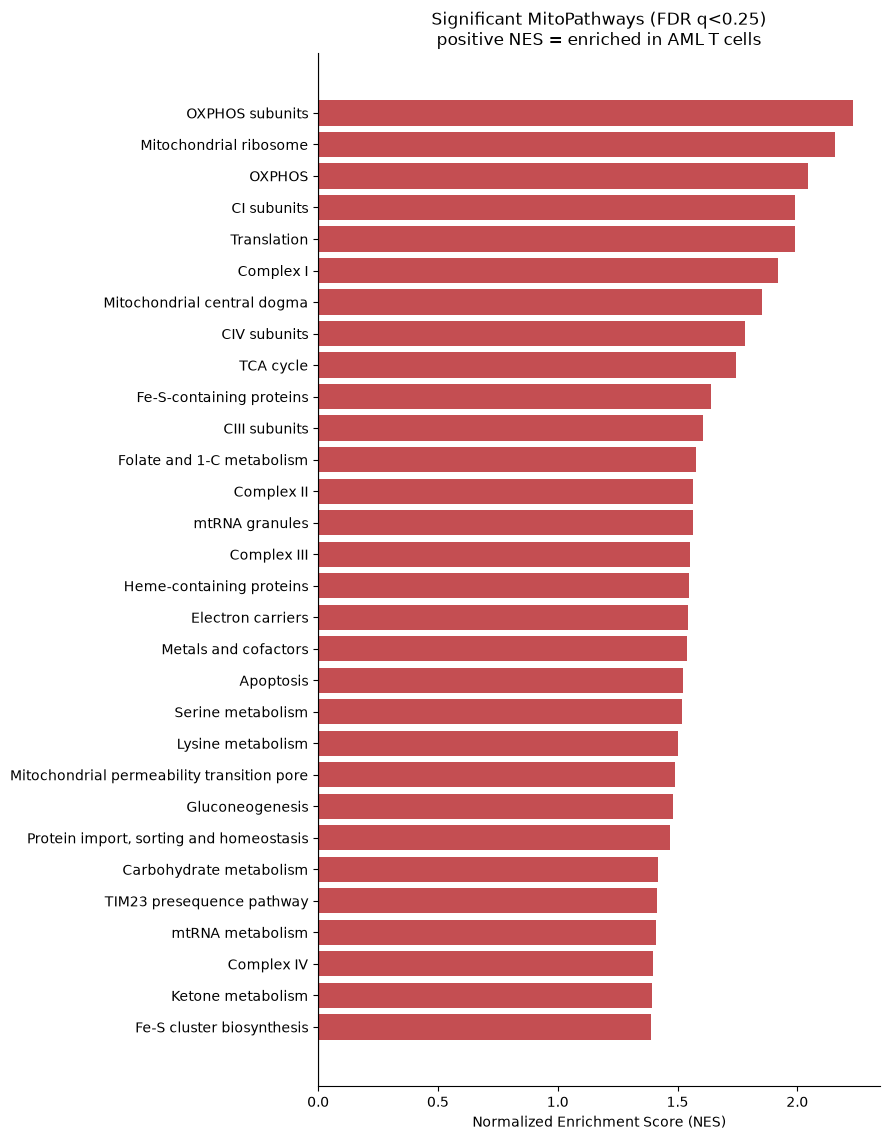

In [24]:
fig, ax = plt.subplots(figsize=(9, max(3, 0.35 * len(sig_pathways) + 1)))
if len(sig_pathways) > 0:
    colors_bar = ["#c44e52" if v > 0 else "#4c72b0" for v in sig_pathways["NES"]]
    ax.barh(sig_pathways["Term"], sig_pathways["NES"], color=colors_bar)
    ax.axvline(0, color="black", lw=0.8)
    ax.set_xlabel("Normalized Enrichment Score (NES)")
    ax.set_title(f"Significant MitoPathways (FDR q<0.25)\npositive NES = enriched in AML {LABEL}s")
else:
    ax.text(0.5, 0.5, "No MitoPathways reached FDR q<0.25", ha="center", va="center")
    ax.axis("off")
fig.tight_layout()
plt.show()

T cell top changed genes and pathways: per-donor detail

ESeq2 model conditions on `Study` (when the design
allows it), so its effect is the *within-study* disease effect. Studies that are entirely
healthy-only or entirely leukemia-only can have systematically different baselines, so a
**raw**, un-adjusted boxplot can show the *opposite* direction from the tested effect
(Simpson's-paradox-style confound). We therefore remove the per-study mean (adding back the
global mean) before plotting, so the plots reflect the same study-adjusted comparison
DESeq2 tested.

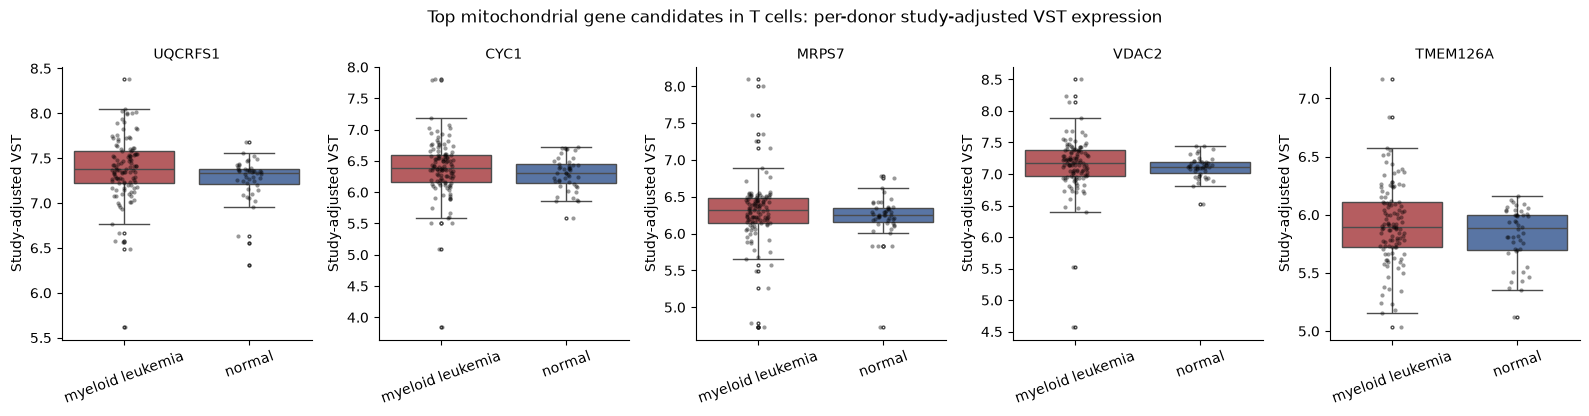

In [25]:
def study_adjusted(gene_vals, study_labels):
    df_tmp = pd.DataFrame({"v": gene_vals, "Study": study_labels})
    study_mean = df_tmp.groupby("Study")["v"].transform("mean")
    return df_tmp["v"] - study_mean + df_tmp["v"].mean()

top_genes_for_plot = (sig_mito.index.tolist() if len(sig_mito) > 0 else mito_table.head(5).index.tolist())[:5]

fig, axes = plt.subplots(1, len(top_genes_for_plot), figsize=(3.2 * len(top_genes_for_plot), 4.2), squeeze=False)
axes = axes[0]
for ax, gene in zip(axes, top_genes_for_plot):
    if use_study_covariate:
        vst_plot_vals = study_adjusted(vst_df[gene], meta["Study"])
        ylabel = "Study-adjusted VST"
    else:
        vst_plot_vals = vst_df[gene]
        ylabel = "VST"
    df_g = pd.DataFrame({ylabel: vst_plot_vals, "disease": meta["disease"].astype(str)})
    sns.boxplot(data=df_g, x="disease", y=ylabel, palette=disease_colors, ax=ax, fliersize=2)
    sns.stripplot(data=df_g, x="disease", y=ylabel, color="black", alpha=0.4, size=3, ax=ax)
    ax.set_title(gene, fontsize=10)
    ax.set_xlabel("")
    ax.tick_params(axis="x", rotation=20)
fig.suptitle(f"Top mitochondrial gene candidates in {LABEL}s: per-donor "
             + ("study-adjusted " if use_study_covariate else "") + "VST expression")
fig.tight_layout()
plt.show()

Top pathway (by |NES|, among those with >=5 leading-edge genes): OXPHOS subunits  (NES=2.23, FDR q=0.000)
Leading-edge genes plotted: 46


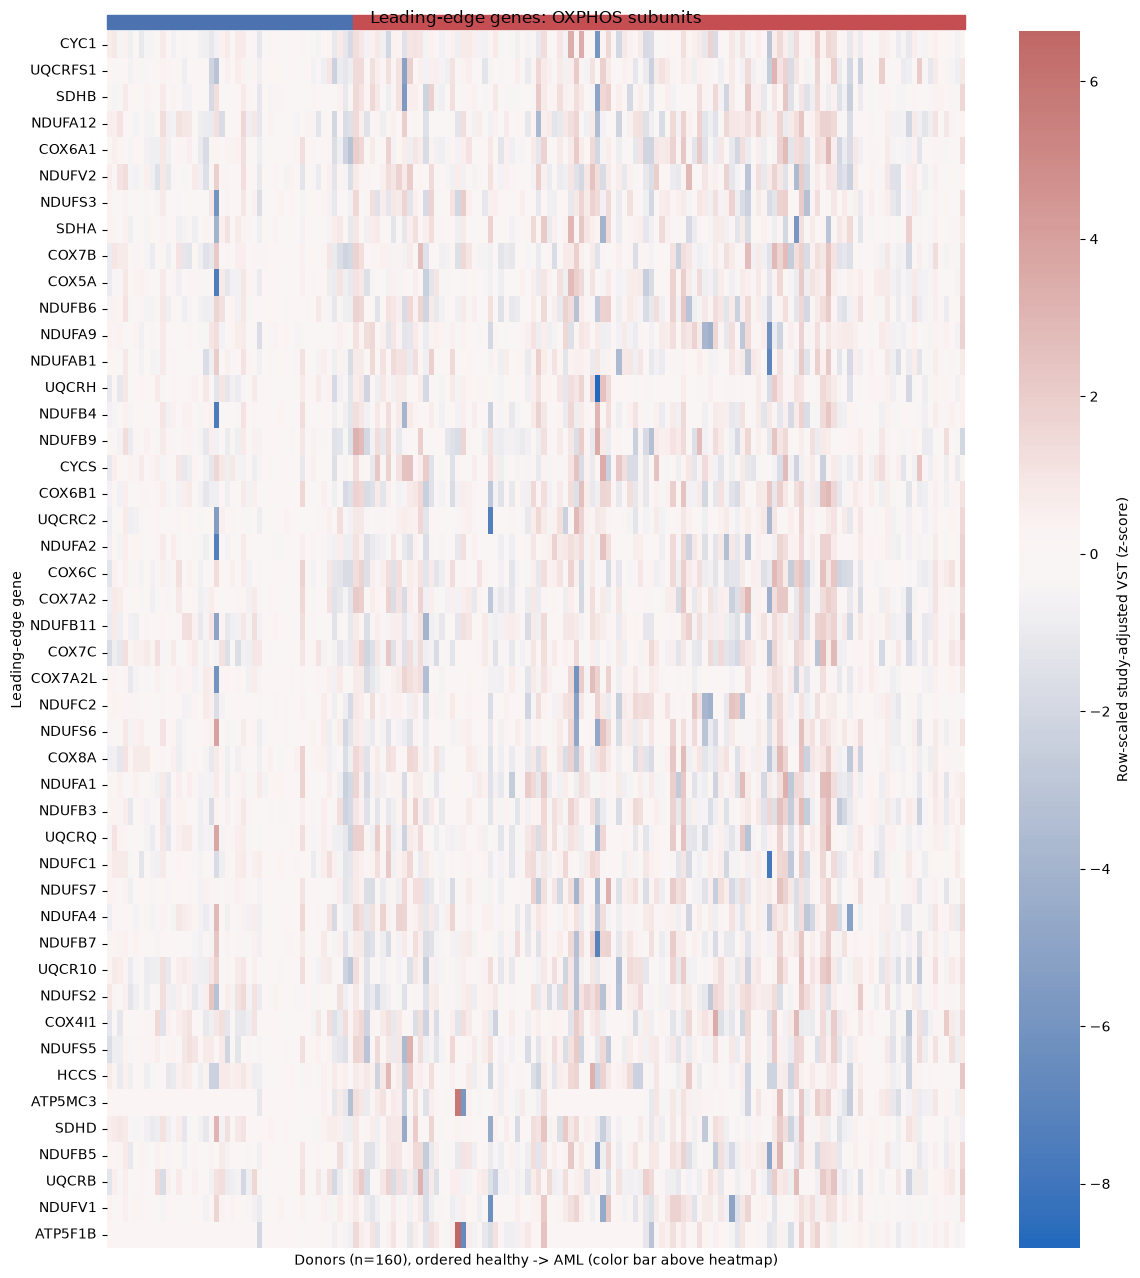

In [26]:
MIN_LEADING_EDGE = 5   # a heatmap needs several genes; skip pathways whose leading edge is (almost) empty

def _enough_genes(df):
    n = df["Lead_genes"].map(lambda s: sum(g in vst_df.columns for g in str(s).split(";")))
    return df[n >= MIN_LEADING_EDGE]

cand_ok = _enough_genes(sig_pathways if len(sig_pathways) > 0 else gsea_res)
if len(cand_ok) == 0:
    cand_ok = _enough_genes(gsea_res)   # none of the significant ones qualifies: use any tested pathway
pool = cand_ok if len(cand_ok) > 0 else gsea_res
top_pathway = pool.loc[pool["NES"].abs().idxmax()]

top_pathway_name = top_pathway["Term"]
leading_edge_genes = [g for g in str(top_pathway["Lead_genes"]).split(";") if g in vst_df.columns]
print(f"Top pathway (by |NES|, among those with >={MIN_LEADING_EDGE} leading-edge genes): "
      f"{top_pathway_name}  (NES={top_pathway['NES']:.2f}, FDR q={top_pathway['FDR q-val']:.3f})")
print(f"Leading-edge genes plotted: {len(leading_edge_genes)}")

if len(leading_edge_genes) >= 2:
    order = meta.sort_values("disease").index
    if use_study_covariate:
        hm_source = pd.DataFrame(
            {g: study_adjusted(vst_df[g], meta["Study"]) for g in leading_edge_genes},
            index=vst_df.index,
        )
        cbar_label = "Row-scaled study-adjusted VST (z-score)"
    else:
        hm_source = vst_df[leading_edge_genes]
        cbar_label = "Row-scaled VST (z-score)"
    hm_data = hm_source.loc[order, leading_edge_genes].T
    hm_z = hm_data.sub(hm_data.mean(axis=1), axis=0).div(hm_data.std(axis=1), axis=0)

    fig, ax = plt.subplots(figsize=(12, max(3, 0.28 * len(leading_edge_genes))))
    sns.heatmap(hm_z, cmap="vlag", center=0, ax=ax,
                cbar_kws={"label": cbar_label},
                xticklabels=False, yticklabels=True)
    disease_track = meta.loc[order, "disease"].astype(str).map({"normal": 0, "myeloid leukemia": 1}).values
    for i, v in enumerate(disease_track):
        ax.add_patch(plt.Rectangle((i, -0.6), 1, 0.5,
                                    color=disease_colors["myeloid leukemia"] if v else disease_colors["normal"],
                                    clip_on=False))
    ax.set_ylabel("Leading-edge gene")
    ax.set_xlabel(f"Donors (n={len(order)}), ordered healthy -> AML (color bar above heatmap)")
    ax.set_title(f"Leading-edge genes: {top_pathway_name}")
    fig.tight_layout()
    plt.show()
else:
    print("Not enough leading-edge genes with VST values to plot a heatmap.")

RESULTS[PFX] = dict(label=LABEL, deseq=deseq_res, gsea=gsea_res, mito_table=mito_table,
                    mito_genes=mito_genes, meta=meta)

In [27]:
CT, LABEL, PFX = "natural killer cell", "NK cell", "nk"
if "RESULTS" not in globals():
    RESULTS = {}

MIN_CELLS_PER_DONOR = 20
MIN_DONORS_PER_GROUP = 5

is_ct = (obs["cell_type"] == CT)
print(f"{LABEL}s before any donor-level filter: {is_ct.sum():,} cells, "
      f"{obs.loc[is_ct, 'donor_id'].nunique()} donors, "
      f"{obs.loc[is_ct, 'Study'].nunique()} studies")

ct_per_donor = (
    obs.loc[is_ct].groupby(["donor_id", "disease"], observed=True).size()
    .reset_index(name="n_cells_ct")
)
qualifying = ct_per_donor[ct_per_donor["n_cells_ct"] >= MIN_CELLS_PER_DONOR]
dropped = ct_per_donor[ct_per_donor["n_cells_ct"] < MIN_CELLS_PER_DONOR]
zero_donors = obs.loc[~obs["donor_id"].isin(ct_per_donor["donor_id"]), "donor_id"].nunique()

n_per_group = qualifying.groupby("disease", observed=True)["donor_id"].nunique()
assert (n_per_group >= MIN_DONORS_PER_GROUP).all(), "A disease group has <5 qualifying donors!"

print(f"\nDonors with ZERO {LABEL}s (dropped outright, mostly CD34+-sorted studies): {zero_donors}")
print(f"Donors with 1-{MIN_CELLS_PER_DONOR - 1} {LABEL}s (dropped, too few cells): "
      f"{dropped['donor_id'].nunique()}  ({dropped.groupby('disease', observed=True)['donor_id'].nunique().to_dict()})")
print(f"\nDonors KEPT (>={MIN_CELLS_PER_DONOR} {LABEL}s), per group:")
print(n_per_group)
print(f"\nTotal donors kept: {len(qualifying)} / {obs['donor_id'].nunique()} in the full atlas")
print(f"Total {LABEL}s kept for pseudobulk: {qualifying['n_cells_ct'].sum():,} "
      f"(of {is_ct.sum():,} {LABEL}s overall)")

qualifying_donors = qualifying["donor_id"].tolist()

studies_dropped_entirely = sorted(
    set(obs["Study"].unique())
    - set(obs.loc[obs["donor_id"].isin(qualifying_donors), "Study"].unique())
)
print(f"\nStudies with ZERO qualifying donors (effectively fully excluded): {studies_dropped_entirely}")

NK cells before any donor-level filter: 16,267 cells, 184 donors, 17 studies

Donors with ZERO NK cells (dropped outright, mostly CD34+-sorted studies): 26
Donors with 1-19 NK cells (dropped, too few cells): 76  ({'myeloid leukemia': 66, 'normal': 10})

Donors KEPT (>=20 NK cells), per group:
disease
myeloid leukemia    71
normal              37
Name: donor_id, dtype: int64

Total donors kept: 108 / 210 in the full atlas
Total NK cells kept for pseudobulk: 15,709 (of 16,267 NK cells overall)

Studies with ZERO qualifying donors (effectively fully excluded): ['caron_2020', 'fiskus_2023', 'johnston_2020', 'pei_2020', 'setty_2019', 'stetson_2021', 'zhai_2022']


In [28]:
PB_CACHE = os.path.join(RESULTS_DIR, f"{PFX}_pseudobulk_counts.parquet")
PB_META_CACHE = os.path.join(RESULTS_DIR, f"{PFX}_pseudobulk_donor_meta.parquet")

if os.path.exists(PB_CACHE) and os.path.exists(PB_META_CACHE):
    print(f"Loading cached {LABEL} pseudobulk matrix...")
    pb_counts = pd.read_parquet(PB_CACHE)
    donor_meta = pd.read_parquet(PB_META_CACHE)
else:
    donor_to_qidx = {d: i for i, d in enumerate(qualifying_donors)}
    n_donors_pb = len(qualifying_donors)
    donor_codes_arr = obs["donor_id"].values
    is_ct_arr = is_ct.values
    assign = np.full(n_cells, -1, dtype=np.int64)
    mask_keep_cell = is_ct_arr & np.isin(donor_codes_arr, qualifying_donors)
    keep_rows = np.where(mask_keep_cell)[0]
    assign[keep_rows] = np.array([donor_to_qidx[d] for d in donor_codes_arr[keep_rows]])

    t0 = time.time()
    pseudobulk = np.zeros((n_donors_pb, n_genes), dtype=np.float64)
    with h5py.File(H5_PATH, "r") as f:
        indptr = f["X/indptr"][:]
        raw_data_ds, raw_idx_ds = f["raw/X/data"], f["raw/X/indices"]
        for start in range(0, n_cells, CHUNK_ROWS):
            end = min(start + CHUNK_ROWS, n_cells)
            chunk_assign = assign[start:end]
            if not np.any(chunk_assign >= 0):
                continue
            s, e = int(indptr[start]), int(indptr[end])
            local_indptr = indptr[start:end + 1] - indptr[start]
            raw_chunk = sparse.csr_matrix(
                (raw_data_ds[s:e], raw_idx_ds[s:e], local_indptr),
                shape=(end - start, n_genes))
            valid = chunk_assign >= 0
            rows = np.where(valid)[0]
            indicator = sparse.csr_matrix(
                (np.ones(len(rows)), (chunk_assign[valid], rows)),
                shape=(n_donors_pb, end - start))
            pseudobulk += indicator.dot(raw_chunk).toarray()
    print(f"Pseudobulk scan done in {time.time()-t0:.0f}s")

    pb_counts = pd.DataFrame(pseudobulk, index=qualifying_donors, columns=gene_names)
    donor_meta = (
        obs[obs["donor_id"].isin(qualifying_donors)]
        .drop_duplicates("donor_id").set_index("donor_id")
        .loc[qualifying_donors, ["disease", "Study", "Fine Age Group", "Main Age Group", "sex", "ELN Risk Group"]]
    )
    pb_counts.to_parquet(PB_CACHE)
    donor_meta.to_parquet(PB_META_CACHE)

print(f"Pseudobulk matrix: {pb_counts.shape[0]} donors x {pb_counts.shape[1]} genes")
donor_meta["disease"].value_counts()

Loading cached NK cell pseudobulk matrix...


Pseudobulk matrix: 108 donors x 21588 genes


disease
myeloid leukemia    71
normal              37
Name: count, dtype: int64

In [29]:
counts_all = pb_counts.round().astype(int)
gene_sums = counts_all.sum(axis=0)
counts_filt = counts_all.loc[:, gene_sums >= 10]
print(f"Genes after near-empty filter (sum>=10 across donors): {counts_filt.shape[1]} / {counts_all.shape[1]}")

meta = donor_meta.copy()
meta["disease"] = pd.Categorical(meta["disease"].astype(str), categories=["normal", "myeloid leukemia"])
meta["Study"] = meta["Study"].astype(str)

design_full = pd.get_dummies(meta[["Study", "disease"]], drop_first=True).astype(float)
design_full.insert(0, "intercept", 1.0)
rank = np.linalg.matrix_rank(design_full.values)
use_study_covariate = (rank == design_full.shape[1])
print(f"~ Study + disease design matrix: {design_full.shape}, rank {rank} "
      f"-> {'FULL RANK, using Study as covariate' if use_study_covariate else 'RANK DEFICIENT, falling back to ~ disease'}")

DESIGN_FORMULA = "~Study+disease" if use_study_covariate else "~disease"

Genes after near-empty filter (sum>=10 across donors): 14333 / 21588
~ Study + disease design matrix: (108, 14), rank 14 -> FULL RANK, using Study as covariate


In [30]:
from pydeseq2.dds import DeseqDataSet
from pydeseq2.ds import DeseqStats

DESEQ_CACHE = os.path.join(RESULTS_DIR, f"{PFX}_deseq_results.parquet")
VST_CACHE = os.path.join(RESULTS_DIR, f"{PFX}_vst.parquet")

if os.path.exists(DESEQ_CACHE) and os.path.exists(VST_CACHE):
    print("Loading cached DESeq2 results + VST matrix...")
    deseq_res = pd.read_parquet(DESEQ_CACHE)
    vst_df = pd.read_parquet(VST_CACHE)
else:
    dds = DeseqDataSet(counts=counts_filt, metadata=meta, design=DESIGN_FORMULA,
                        refit_cooks=True, quiet=True)
    dds.deseq2()

    dds.vst(use_design=False)
    vst_df = pd.DataFrame(dds.layers["vst_counts"], index=dds.obs_names, columns=dds.var_names)

    ds = DeseqStats(dds, contrast=["disease", "myeloid leukemia", "normal"], quiet=True)
    ds.summary()
    ds.lfc_shrink(coeff="disease[T.myeloid leukemia]")
    deseq_res = ds.results_df.copy()

    deseq_res.to_parquet(DESEQ_CACHE)
    vst_df.to_parquet(VST_CACHE)

print(f"DESeq2 results: {deseq_res.shape[0]} genes tested "
      f"(positive log2FC = higher in AML {LABEL}s vs. healthy {LABEL}s)")
print(f"Significant genes overall (padj < 0.05): {(deseq_res['padj'] < 0.05).sum()}")
deseq_res.sort_values("padj").head(10)

Loading cached DESeq2 results + VST matrix...


DESeq2 results: 14333 genes tested (positive log2FC = higher in AML NK cells vs. healthy NK cells)
Significant genes overall (padj < 0.05): 0


,baseMean,log2FoldChange,lfcSE,stat,pvalue,padj
ZNF250,1.556720,-1.772366,0.492781,-4.378759,0.000012,0.171074
BTG2,51.023397,-1.097351,0.373325,-4.221596,0.000024,0.173844
KIAA0586,5.798547,-0.713761,0.275228,-3.916678,0.000090,0.245905
UQCRFS1,29.640893,0.506715,0.185186,3.870832,0.000108,0.245905
TNFSF14,5.626127,-0.927445,0.324845,-3.876576,0.000106,0.245905
STK39,7.213881,-0.812406,0.280458,-4.048576,0.000052,0.245905
IFIT2,39.221761,-0.051128,0.071367,-3.783869,0.000154,0.245905
MRPL47,13.572355,0.592654,0.229042,3.786240,0.000153,0.245905
MOSPD2,2.263669,-1.089681,0.410955,-3.804442,0.000142,0.245905
PZP,0.725242,-1.925549,0.584235,-3.692096,0.000222,0.281283


Variance explained by PC1-5: [0.267 0.118 0.085 0.07  0.038]
Donors flagged as PCA outliers (>3 SD on PC1 or PC2): []


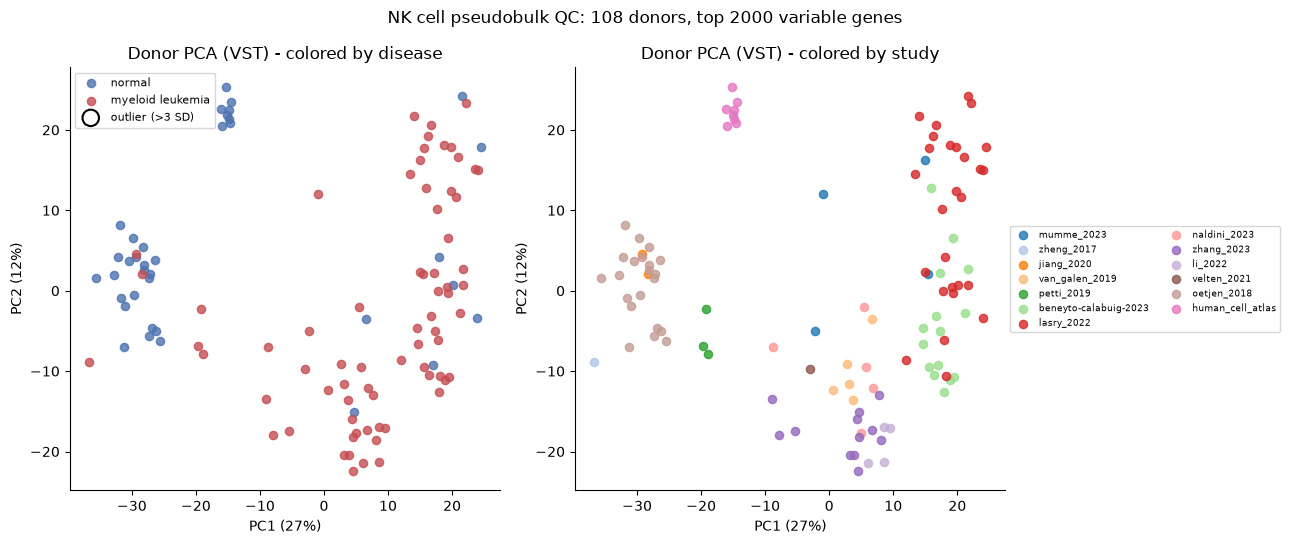

In [31]:
from sklearn.decomposition import PCA

gene_var = vst_df.var(axis=0).sort_values(ascending=False)
top_var_genes = gene_var.index[:2000]
Xc = vst_df[top_var_genes].values
Xc = Xc - Xc.mean(axis=0)
pca = PCA(n_components=10, random_state=0)
pcs = pca.fit_transform(Xc)
print("Variance explained by PC1-5:", np.round(pca.explained_variance_ratio_[:5], 3))

pc_df = pd.DataFrame(pcs[:, :2], columns=["PC1", "PC2"], index=vst_df.index).join(meta)
z1 = (pc_df["PC1"] - pc_df["PC1"].mean()) / pc_df["PC1"].std()
z2 = (pc_df["PC2"] - pc_df["PC2"].mean()) / pc_df["PC2"].std()
pc_df["outlier"] = (z1.abs() > 3) | (z2.abs() > 3)
outlier_donors = pc_df.index[pc_df["outlier"]].tolist()
print(f"Donors flagged as PCA outliers (>3 SD on PC1 or PC2): {outlier_donors}")

fig, axes = plt.subplots(1, 2, figsize=(13, 5.5))
disease_colors = {"normal": "#4c72b0", "myeloid leukemia": "#c44e52"}
for d, c in disease_colors.items():
    m = pc_df["disease"].astype(str) == d
    axes[0].scatter(pc_df.loc[m, "PC1"], pc_df.loc[m, "PC2"], s=35, alpha=0.8, color=c, label=d)
axes[0].scatter(pc_df.loc[pc_df["outlier"], "PC1"], pc_df.loc[pc_df["outlier"], "PC2"],
                s=140, facecolors="none", edgecolors="black", linewidths=1.5, label="outlier (>3 SD)")
axes[0].set_xlabel(f"PC1 ({pca.explained_variance_ratio_[0]*100:.0f}%)")
axes[0].set_ylabel(f"PC2 ({pca.explained_variance_ratio_[1]*100:.0f}%)")
axes[0].set_title("Donor PCA (VST) - colored by disease")
axes[0].legend(fontsize=8)

study_cats = pc_df["Study"].astype(str).unique()
study_colors2 = dict(zip(study_cats, sns.color_palette("tab20", len(study_cats))))
for s in study_cats:
    m = pc_df["Study"].astype(str) == s
    axes[1].scatter(pc_df.loc[m, "PC1"], pc_df.loc[m, "PC2"], s=35, alpha=0.8, color=study_colors2[s], label=s)
axes[1].set_xlabel(f"PC1 ({pca.explained_variance_ratio_[0]*100:.0f}%)")
axes[1].set_ylabel(f"PC2 ({pca.explained_variance_ratio_[1]*100:.0f}%)")
axes[1].set_title("Donor PCA (VST) - colored by study")
axes[1].legend(fontsize=6.5, ncol=2, loc="center left", bbox_to_anchor=(1.0, 0.5))

fig.suptitle(f"{LABEL} pseudobulk QC: {len(pc_df)} donors, top {len(top_var_genes)} variable genes")
fig.tight_layout()
plt.show()

In [32]:
mitocarta = pd.read_excel(os.path.join(DATA_DIR, "Human.MitoCarta3.0.xls"), sheet_name="A Human MitoCarta3.0")
mitocarta_genes = set(mitocarta["Symbol"].dropna().astype(str))

MT_GENES_ALL = sorted([g for g in gene_names if g.upper().startswith("MT-")])
mito_genes = sorted([g for g in mitocarta_genes if g in deseq_res.index])
n_mt_in_set = sum(g.upper().startswith("MT-") for g in mito_genes)
print(f"MitoCarta3.0: {len(mitocarta_genes)} genes total")
print(f"MitoCarta genes tested in this DE analysis: {len(mito_genes)} "
      f"({len(mito_genes) - n_mt_in_set} nuclear-encoded + {n_mt_in_set} mtDNA-encoded MT- genes)")

mito_table = deseq_res.loc[mito_genes].sort_values("padj")
mito_table["encoded_by"] = np.where(mito_table.index.str.upper().str.startswith("MT-"), "mtDNA", "nuclear")
display(mito_table.head(15)[["baseMean", "log2FoldChange", "lfcSE", "pvalue", "padj", "encoded_by"]])

MitoCarta3.0: 1136 genes total
MitoCarta genes tested in this DE analysis: 994 (981 nuclear-encoded + 13 mtDNA-encoded MT- genes)


,baseMean,log2FoldChange,lfcSE,pvalue,padj,encoded_by
MRPL47,13.572355,0.592654,0.229042,0.000153,0.245905,nuclear
UQCRFS1,29.640893,0.506715,0.185186,0.000108,0.245905,nuclear
NDUFS3,13.139565,0.413303,0.203041,0.000700,0.322734,nuclear
OGG1,3.532402,-0.815431,0.483259,0.000927,0.322734,nuclear
ATP5F1B,21.658433,0.396137,0.142081,0.000503,0.322734,nuclear
COX7B,51.358701,0.316580,0.155879,0.001161,0.332863,nuclear
MFF,15.456370,0.296831,0.186164,0.002659,0.482049,nuclear
HADHA,22.686924,-0.281678,0.172799,0.002737,0.482049,nuclear
DHX30,8.747945,0.399585,0.327024,0.003389,0.516750,nuclear
LACTB2,1.996789,-0.081012,0.116284,0.003838,0.531022,nuclear


Mitochondrial genes passing padj<0.05 & |log2FC|>0.5: 0
Mitochondrial genes with padj<0.05 (any effect size): 0
None reach both thresholds simultaneously. Closest candidates (by padj):
          baseMean  log2FoldChange      padj encoded_by
MRPL47   13.572355        0.592654  0.245905    nuclear
UQCRFS1  29.640893        0.506715  0.245905    nuclear
NDUFS3   13.139565        0.413303  0.322734    nuclear
OGG1      3.532402       -0.815431  0.322734    nuclear
ATP5F1B  21.658433        0.396137  0.322734    nuclear


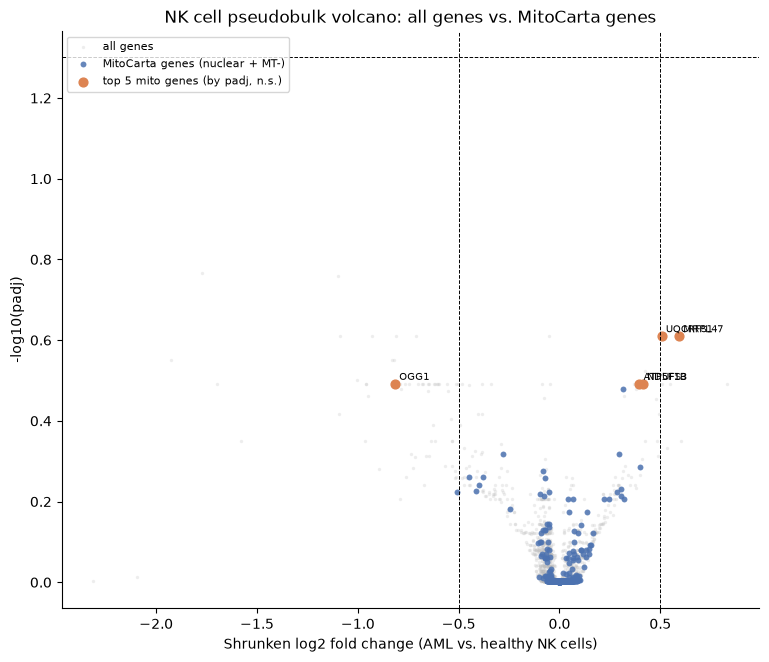

In [33]:
sig_mito = mito_table[(mito_table["padj"] < 0.05) & (mito_table["log2FoldChange"].abs() > 0.5)]
print(f"Mitochondrial genes passing padj<0.05 & |log2FC|>0.5: {len(sig_mito)}")
print(f"Mitochondrial genes with padj<0.05 (any effect size): {(mito_table['padj'] < 0.05).sum()}")
if len(sig_mito) == 0:
    print("None reach both thresholds simultaneously. Closest candidates (by padj):")
    print(mito_table.head(5)[["baseMean", "log2FoldChange", "padj", "encoded_by"]])

fig, ax = plt.subplots(figsize=(9, 7.5))
plot_df = deseq_res.dropna(subset=["padj"]).copy()
plot_df["neglog10padj"] = -np.log10(plot_df["padj"].clip(lower=1e-300))

ax.scatter(plot_df["log2FoldChange"], plot_df["neglog10padj"],
           s=6, alpha=0.25, color="#bbbbbb", linewidths=0, label="all genes")

mito_plot = plot_df.loc[plot_df.index.isin(mito_genes)]
ax.scatter(mito_plot["log2FoldChange"], mito_plot["neglog10padj"],
           s=18, alpha=0.85, color="#4c72b0", linewidths=0, label="MitoCarta genes (nuclear + MT-)")

if len(sig_mito) > 0:
    sig_plot = plot_df.loc[plot_df.index.isin(sig_mito.index)]
    ax.scatter(sig_plot["log2FoldChange"], sig_plot["neglog10padj"],
               s=40, color="#c44e52", label="significant mito (padj<0.05 & |L2FC|>0.5)")
    for gene, row in sig_plot.iterrows():
        ax.annotate(gene, (row["log2FoldChange"], row["neglog10padj"]), fontsize=7,
                    xytext=(3, 3), textcoords="offset points")
else:
    top5 = mito_table.head(5)
    top5_plot = plot_df.loc[plot_df.index.isin(top5.index)]
    ax.scatter(top5_plot["log2FoldChange"], top5_plot["neglog10padj"],
               s=40, color="#dd8452", label="top 5 mito genes (by padj, n.s.)")
    for gene, row in top5_plot.iterrows():
        ax.annotate(gene, (row["log2FoldChange"], row["neglog10padj"]), fontsize=7,
                    xytext=(3, 3), textcoords="offset points")

ax.axhline(-np.log10(0.05), color="black", lw=0.7, ls="--")
ax.axvline(0.5, color="black", lw=0.7, ls="--")
ax.axvline(-0.5, color="black", lw=0.7, ls="--")
ax.set_xlabel(f"Shrunken log2 fold change (AML vs. healthy {LABEL}s)")
ax.set_ylabel("-log10(padj)")
ax.set_title(f"{LABEL} pseudobulk volcano: all genes vs. MitoCarta genes")
ax.legend(fontsize=8, loc="upper left")
plt.show()

In [34]:
import gseapy as gp

GSEA_CACHE = os.path.join(RESULTS_DIR, f"{PFX}_gsea_results_mt_included.parquet")

mitopathways = pd.read_excel(os.path.join(DATA_DIR, "Human.MitoCarta3.0.xls"), sheet_name="C MitoPathways")
mitopathways = mitopathways.dropna(subset=["MitoPathway"])

gene_sets = {}
for _, row in mitopathways.iterrows():
    gene_sets[row["MitoPathway"]] = [g.strip() for g in str(row["Genes"]).split(",") if g.strip()]

gene_rank = deseq_res["log2FoldChange"].dropna().sort_values(ascending=False)
print(f"Ranked gene list (nuclear + MT-): {len(gene_rank)} genes; {len(gene_sets)} MitoPathway gene sets")

if os.path.exists(GSEA_CACHE):
    print("Loading cached GSEA results...")
    gsea_res = pd.read_parquet(GSEA_CACHE)
else:
    prerank = gp.prerank(
        rnk=gene_rank, gene_sets=gene_sets, min_size=5, max_size=500,
        permutation_num=1000, seed=0, threads=4, no_plot=True, outdir=None,
    )
    gsea_res = prerank.res2d.copy()
    gsea_res["NES"] = gsea_res["NES"].astype(float)
    gsea_res["FDR q-val"] = gsea_res["FDR q-val"].astype(float)
    gsea_res.to_parquet(GSEA_CACHE)

print(f"Pathways tested: {len(gsea_res)}")
print(f"Pathways with FDR q<0.05: {(gsea_res['FDR q-val'] < 0.05).sum()}")
sig_pathways = gsea_res[gsea_res["FDR q-val"] < 0.25].sort_values("NES")
print(f"Significant pathways (FDR q<0.25, standard GSEA convention): {len(sig_pathways)}")
sig_pathways[["Term", "NES", "NOM p-val", "FDR q-val"]]

Ranked gene list (nuclear + MT-): 14333 genes; 149 MitoPathway gene sets
Loading cached GSEA results...
Pathways tested: 110
Pathways with FDR q<0.05: 11
Significant pathways (FDR q<0.25, standard GSEA convention): 20


,Term,NES,NOM p-val,FDR q-val
21,TIM23 presequence pathway,1.468160,0.057789,0.227694
20,"Cholesterol, bile acid, steroid synthesis",1.482138,0.074359,0.218633
19,Complex II,1.492317,0.062500,0.213597
18,Import motor,1.496061,0.059666,0.220532
17,Protein import and sorting,1.524848,0.033537,0.189247
15,TOM,1.545870,0.048711,0.169282
14,mtRNA granules,1.556447,0.038585,0.165507
12,Complex III,1.615238,0.052770,0.103052
11,Complex IV,1.674460,0.009804,0.052118
10,CIII subunits,1.692382,0.012690,0.045671


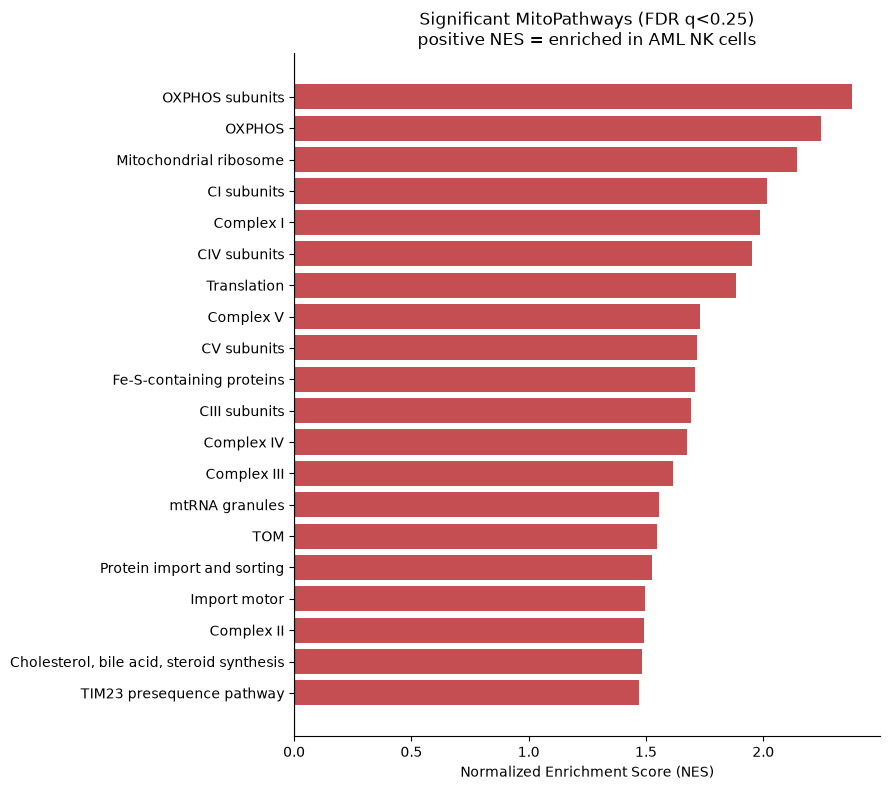

In [35]:
fig, ax = plt.subplots(figsize=(9, max(3, 0.35 * len(sig_pathways) + 1)))
if len(sig_pathways) > 0:
    colors_bar = ["#c44e52" if v > 0 else "#4c72b0" for v in sig_pathways["NES"]]
    ax.barh(sig_pathways["Term"], sig_pathways["NES"], color=colors_bar)
    ax.axvline(0, color="black", lw=0.8)
    ax.set_xlabel("Normalized Enrichment Score (NES)")
    ax.set_title(f"Significant MitoPathways (FDR q<0.25)\npositive NES = enriched in AML {LABEL}s")
else:
    ax.text(0.5, 0.5, "No MitoPathways reached FDR q<0.25", ha="center", va="center")
    ax.axis("off")
fig.tight_layout()
plt.show()

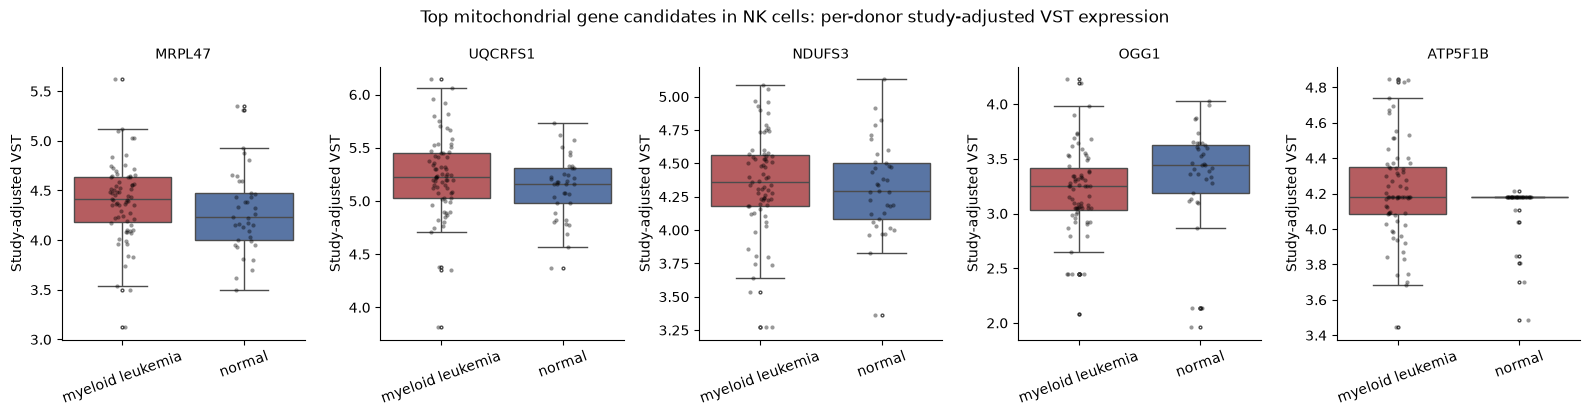

In [36]:
def study_adjusted(gene_vals, study_labels):
    df_tmp = pd.DataFrame({"v": gene_vals, "Study": study_labels})
    study_mean = df_tmp.groupby("Study")["v"].transform("mean")
    return df_tmp["v"] - study_mean + df_tmp["v"].mean()

top_genes_for_plot = (sig_mito.index.tolist() if len(sig_mito) > 0 else mito_table.head(5).index.tolist())[:5]

fig, axes = plt.subplots(1, len(top_genes_for_plot), figsize=(3.2 * len(top_genes_for_plot), 4.2), squeeze=False)
axes = axes[0]
for ax, gene in zip(axes, top_genes_for_plot):
    if use_study_covariate:
        vst_plot_vals = study_adjusted(vst_df[gene], meta["Study"])
        ylabel = "Study-adjusted VST"
    else:
        vst_plot_vals = vst_df[gene]
        ylabel = "VST"
    df_g = pd.DataFrame({ylabel: vst_plot_vals, "disease": meta["disease"].astype(str)})
    sns.boxplot(data=df_g, x="disease", y=ylabel, palette=disease_colors, ax=ax, fliersize=2)
    sns.stripplot(data=df_g, x="disease", y=ylabel, color="black", alpha=0.4, size=3, ax=ax)
    ax.set_title(gene, fontsize=10)
    ax.set_xlabel("")
    ax.tick_params(axis="x", rotation=20)
fig.suptitle(f"Top mitochondrial gene candidates in {LABEL}s: per-donor "
             + ("study-adjusted " if use_study_covariate else "") + "VST expression")
fig.tight_layout()
plt.show()

Top pathway (by |NES|, among those with >=5 leading-edge genes): OXPHOS subunits  (NES=2.38, FDR q=0.000)
Leading-edge genes plotted: 47


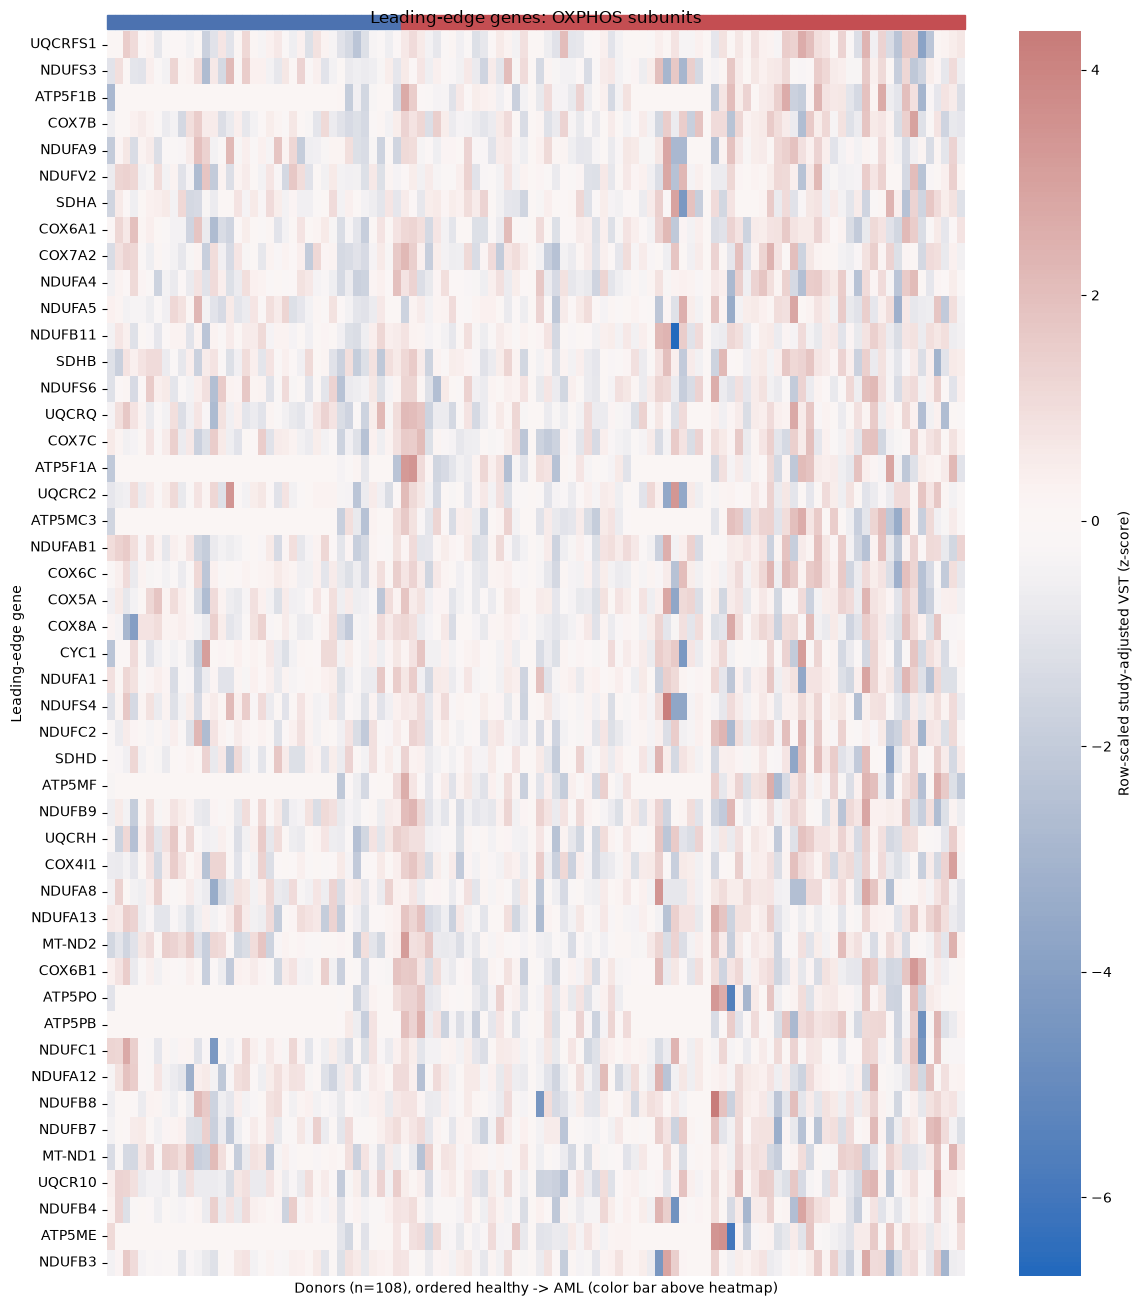

In [37]:
MIN_LEADING_EDGE = 5   # a heatmap needs several genes; skip pathways whose leading edge is (almost) empty

def _enough_genes(df):
    n = df["Lead_genes"].map(lambda s: sum(g in vst_df.columns for g in str(s).split(";")))
    return df[n >= MIN_LEADING_EDGE]

cand_ok = _enough_genes(sig_pathways if len(sig_pathways) > 0 else gsea_res)
if len(cand_ok) == 0:
    cand_ok = _enough_genes(gsea_res)   # none of the significant ones qualifies: use any tested pathway
pool = cand_ok if len(cand_ok) > 0 else gsea_res
top_pathway = pool.loc[pool["NES"].abs().idxmax()]

top_pathway_name = top_pathway["Term"]
leading_edge_genes = [g for g in str(top_pathway["Lead_genes"]).split(";") if g in vst_df.columns]
print(f"Top pathway (by |NES|, among those with >={MIN_LEADING_EDGE} leading-edge genes): "
      f"{top_pathway_name}  (NES={top_pathway['NES']:.2f}, FDR q={top_pathway['FDR q-val']:.3f})")
print(f"Leading-edge genes plotted: {len(leading_edge_genes)}")

if len(leading_edge_genes) >= 2:
    order = meta.sort_values("disease").index
    if use_study_covariate:
        hm_source = pd.DataFrame(
            {g: study_adjusted(vst_df[g], meta["Study"]) for g in leading_edge_genes},
            index=vst_df.index,
        )
        cbar_label = "Row-scaled study-adjusted VST (z-score)"
    else:
        hm_source = vst_df[leading_edge_genes]
        cbar_label = "Row-scaled VST (z-score)"
    hm_data = hm_source.loc[order, leading_edge_genes].T
    hm_z = hm_data.sub(hm_data.mean(axis=1), axis=0).div(hm_data.std(axis=1), axis=0)

    fig, ax = plt.subplots(figsize=(12, max(3, 0.28 * len(leading_edge_genes))))
    sns.heatmap(hm_z, cmap="vlag", center=0, ax=ax,
                cbar_kws={"label": cbar_label},
                xticklabels=False, yticklabels=True)
    disease_track = meta.loc[order, "disease"].astype(str).map({"normal": 0, "myeloid leukemia": 1}).values
    for i, v in enumerate(disease_track):
        ax.add_patch(plt.Rectangle((i, -0.6), 1, 0.5,
                                    color=disease_colors["myeloid leukemia"] if v else disease_colors["normal"],
                                    clip_on=False))
    ax.set_ylabel("Leading-edge gene")
    ax.set_xlabel(f"Donors (n={len(order)}), ordered healthy -> AML (color bar above heatmap)")
    ax.set_title(f"Leading-edge genes: {top_pathway_name}")
    fig.tight_layout()
    plt.show()
else:
    print("Not enough leading-edge genes with VST values to plot a heatmap.")

RESULTS[PFX] = dict(label=LABEL, deseq=deseq_res, gsea=gsea_res, mito_table=mito_table,
                    mito_genes=mito_genes, meta=meta)

9. B cell 

In [38]:
CT, LABEL, PFX = "B cell", "B cell", "bcell"
if "RESULTS" not in globals():
    RESULTS = {}

MIN_CELLS_PER_DONOR = 20
MIN_DONORS_PER_GROUP = 5

is_ct = (obs["cell_type"] == CT)
print(f"{LABEL}s before any donor-level filter: {is_ct.sum():,} cells, "
      f"{obs.loc[is_ct, 'donor_id'].nunique()} donors, "
      f"{obs.loc[is_ct, 'Study'].nunique()} studies")

ct_per_donor = (
    obs.loc[is_ct].groupby(["donor_id", "disease"], observed=True).size()
    .reset_index(name="n_cells_ct")
)
qualifying = ct_per_donor[ct_per_donor["n_cells_ct"] >= MIN_CELLS_PER_DONOR]
dropped = ct_per_donor[ct_per_donor["n_cells_ct"] < MIN_CELLS_PER_DONOR]
zero_donors = obs.loc[~obs["donor_id"].isin(ct_per_donor["donor_id"]), "donor_id"].nunique()

n_per_group = qualifying.groupby("disease", observed=True)["donor_id"].nunique()
assert (n_per_group >= MIN_DONORS_PER_GROUP).all(), "A disease group has <5 qualifying donors!"

print(f"\nDonors with ZERO {LABEL}s (dropped outright, mostly CD34+-sorted studies): {zero_donors}")
print(f"Donors with 1-{MIN_CELLS_PER_DONOR - 1} {LABEL}s (dropped, too few cells): "
      f"{dropped['donor_id'].nunique()}  ({dropped.groupby('disease', observed=True)['donor_id'].nunique().to_dict()})")
print(f"\nDonors KEPT (>={MIN_CELLS_PER_DONOR} {LABEL}s), per group:")
print(n_per_group)
print(f"\nTotal donors kept: {len(qualifying)} / {obs['donor_id'].nunique()} in the full atlas")
print(f"Total {LABEL}s kept for pseudobulk: {qualifying['n_cells_ct'].sum():,} "
      f"(of {is_ct.sum():,} {LABEL}s overall)")

qualifying_donors = qualifying["donor_id"].tolist()

studies_dropped_entirely = sorted(
    set(obs["Study"].unique())
    - set(obs.loc[obs["donor_id"].isin(qualifying_donors), "Study"].unique())
)
print(f"\nStudies with ZERO qualifying donors (effectively fully excluded): {studies_dropped_entirely}")

B cells before any donor-level filter: 25,671 cells, 188 donors, 18 studies

Donors with ZERO B cells (dropped outright, mostly CD34+-sorted studies): 22
Donors with 1-19 B cells (dropped, too few cells): 60  ({'myeloid leukemia': 53, 'normal': 7})

Donors KEPT (>=20 B cells), per group:
disease
myeloid leukemia    85
normal              43
Name: donor_id, dtype: int64

Total donors kept: 128 / 210 in the full atlas
Total B cells kept for pseudobulk: 25,222 (of 25,671 B cells overall)

Studies with ZERO qualifying donors (effectively fully excluded): ['fiskus_2023', 'jiang_2020', 'johnston_2020', 'pei_2020', 'setty_2019', 'velten_2021', 'zhai_2022', 'zheng_2017']


In [39]:
PB_CACHE = os.path.join(RESULTS_DIR, f"{PFX}_pseudobulk_counts.parquet")
PB_META_CACHE = os.path.join(RESULTS_DIR, f"{PFX}_pseudobulk_donor_meta.parquet")

if os.path.exists(PB_CACHE) and os.path.exists(PB_META_CACHE):
    print(f"Loading cached {LABEL} pseudobulk matrix...")
    pb_counts = pd.read_parquet(PB_CACHE)
    donor_meta = pd.read_parquet(PB_META_CACHE)
else:
    donor_to_qidx = {d: i for i, d in enumerate(qualifying_donors)}
    n_donors_pb = len(qualifying_donors)
    donor_codes_arr = obs["donor_id"].values
    is_ct_arr = is_ct.values
    assign = np.full(n_cells, -1, dtype=np.int64)
    mask_keep_cell = is_ct_arr & np.isin(donor_codes_arr, qualifying_donors)
    keep_rows = np.where(mask_keep_cell)[0]
    assign[keep_rows] = np.array([donor_to_qidx[d] for d in donor_codes_arr[keep_rows]])

    t0 = time.time()
    pseudobulk = np.zeros((n_donors_pb, n_genes), dtype=np.float64)
    with h5py.File(H5_PATH, "r") as f:
        indptr = f["X/indptr"][:]
        raw_data_ds, raw_idx_ds = f["raw/X/data"], f["raw/X/indices"]
        for start in range(0, n_cells, CHUNK_ROWS):
            end = min(start + CHUNK_ROWS, n_cells)
            chunk_assign = assign[start:end]
            if not np.any(chunk_assign >= 0):
                continue
            s, e = int(indptr[start]), int(indptr[end])
            local_indptr = indptr[start:end + 1] - indptr[start]
            raw_chunk = sparse.csr_matrix(
                (raw_data_ds[s:e], raw_idx_ds[s:e], local_indptr),
                shape=(end - start, n_genes))
            valid = chunk_assign >= 0
            rows = np.where(valid)[0]
            indicator = sparse.csr_matrix(
                (np.ones(len(rows)), (chunk_assign[valid], rows)),
                shape=(n_donors_pb, end - start))
            pseudobulk += indicator.dot(raw_chunk).toarray()
    print(f"Pseudobulk scan done in {time.time()-t0:.0f}s")

    pb_counts = pd.DataFrame(pseudobulk, index=qualifying_donors, columns=gene_names)
    donor_meta = (
        obs[obs["donor_id"].isin(qualifying_donors)]
        .drop_duplicates("donor_id").set_index("donor_id")
        .loc[qualifying_donors, ["disease", "Study", "Fine Age Group", "Main Age Group", "sex", "ELN Risk Group"]]
    )
    pb_counts.to_parquet(PB_CACHE)
    donor_meta.to_parquet(PB_META_CACHE)

print(f"Pseudobulk matrix: {pb_counts.shape[0]} donors x {pb_counts.shape[1]} genes")
donor_meta["disease"].value_counts()

Loading cached B cell pseudobulk matrix...


Pseudobulk matrix: 128 donors x 21588 genes


disease
myeloid leukemia    85
normal              43
Name: count, dtype: int64

In [40]:
counts_all = pb_counts.round().astype(int)
gene_sums = counts_all.sum(axis=0)
counts_filt = counts_all.loc[:, gene_sums >= 10]
print(f"Genes after near-empty filter (sum>=10 across donors): {counts_filt.shape[1]} / {counts_all.shape[1]}")

meta = donor_meta.copy()
meta["disease"] = pd.Categorical(meta["disease"].astype(str), categories=["normal", "myeloid leukemia"])
meta["Study"] = meta["Study"].astype(str)

design_full = pd.get_dummies(meta[["Study", "disease"]], drop_first=True).astype(float)
design_full.insert(0, "intercept", 1.0)
rank = np.linalg.matrix_rank(design_full.values)
use_study_covariate = (rank == design_full.shape[1])
print(f"~ Study + disease design matrix: {design_full.shape}, rank {rank} "
      f"-> {'FULL RANK, using Study as covariate' if use_study_covariate else 'RANK DEFICIENT, falling back to ~ disease'}")

DESIGN_FORMULA = "~Study+disease" if use_study_covariate else "~disease"

Genes after near-empty filter (sum>=10 across donors): 14945 / 21588
~ Study + disease design matrix: (128, 13), rank 13 -> FULL RANK, using Study as covariate


In [41]:
from pydeseq2.dds import DeseqDataSet
from pydeseq2.ds import DeseqStats

DESEQ_CACHE = os.path.join(RESULTS_DIR, f"{PFX}_deseq_results.parquet")
VST_CACHE = os.path.join(RESULTS_DIR, f"{PFX}_vst.parquet")

if os.path.exists(DESEQ_CACHE) and os.path.exists(VST_CACHE):
    print("Loading cached DESeq2 results + VST matrix...")
    deseq_res = pd.read_parquet(DESEQ_CACHE)
    vst_df = pd.read_parquet(VST_CACHE)
else:
    dds = DeseqDataSet(counts=counts_filt, metadata=meta, design=DESIGN_FORMULA,
                        refit_cooks=True, quiet=True)
    dds.deseq2()

    dds.vst(use_design=False)
    vst_df = pd.DataFrame(dds.layers["vst_counts"], index=dds.obs_names, columns=dds.var_names)

    ds = DeseqStats(dds, contrast=["disease", "myeloid leukemia", "normal"], quiet=True)
    ds.summary()
    ds.lfc_shrink(coeff="disease[T.myeloid leukemia]")
    deseq_res = ds.results_df.copy()

    deseq_res.to_parquet(DESEQ_CACHE)
    vst_df.to_parquet(VST_CACHE)

print(f"DESeq2 results: {deseq_res.shape[0]} genes tested "
      f"(positive log2FC = higher in AML {LABEL}s vs. healthy {LABEL}s)")
print(f"Significant genes overall (padj < 0.05): {(deseq_res['padj'] < 0.05).sum()}")
deseq_res.sort_values("padj").head(10)

Loading cached DESeq2 results + VST matrix...


DESeq2 results: 14945 genes tested (positive log2FC = higher in AML B cells vs. healthy B cells)
Significant genes overall (padj < 0.05): 16


,baseMean,log2FoldChange,lfcSE,stat,pvalue,padj
SSBP2,14.913658,-1.132992,0.286762,-5.075331,3.868222e-07,0.002979
WASF1,3.903329,-2.162805,0.609221,-4.568988,4.900839e-06,0.012580
CCDC191,15.251533,-1.575234,0.455308,-4.593033,4.368493e-06,0.012580
KDM1B,4.727199,-1.020082,0.353693,-4.312755,1.612329e-05,0.031041
HMCES,5.725298,-1.175161,0.441338,-4.154018,3.266872e-05,0.031588
ARL16,9.262037,-0.691543,0.260557,-4.153002,3.281415e-05,0.031588
CD38,8.834392,-1.590372,0.529236,-4.242988,2.205630e-05,0.031588
CMTM8,3.341955,-3.506085,0.914755,-4.182725,2.880359e-05,0.031588
GADD45GIP1,33.901011,0.537557,0.200547,4.056774,4.975515e-05,0.033894
ME2,11.161062,-0.624855,0.241123,-4.089680,4.319694e-05,0.033894


Variance explained by PC1-5: [0.272 0.117 0.086 0.072 0.061]
Donors flagged as PCA outliers (>3 SD on PC1 or PC2): []


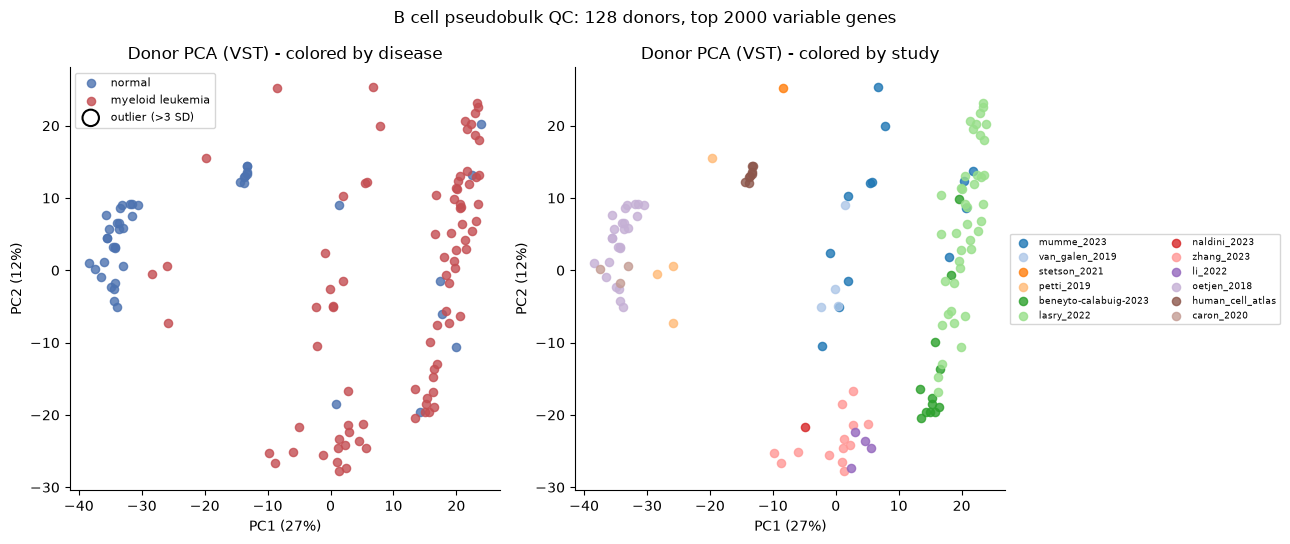

In [42]:
from sklearn.decomposition import PCA

gene_var = vst_df.var(axis=0).sort_values(ascending=False)
top_var_genes = gene_var.index[:2000]
Xc = vst_df[top_var_genes].values
Xc = Xc - Xc.mean(axis=0)
pca = PCA(n_components=10, random_state=0)
pcs = pca.fit_transform(Xc)
print("Variance explained by PC1-5:", np.round(pca.explained_variance_ratio_[:5], 3))

pc_df = pd.DataFrame(pcs[:, :2], columns=["PC1", "PC2"], index=vst_df.index).join(meta)
z1 = (pc_df["PC1"] - pc_df["PC1"].mean()) / pc_df["PC1"].std()
z2 = (pc_df["PC2"] - pc_df["PC2"].mean()) / pc_df["PC2"].std()
pc_df["outlier"] = (z1.abs() > 3) | (z2.abs() > 3)
outlier_donors = pc_df.index[pc_df["outlier"]].tolist()
print(f"Donors flagged as PCA outliers (>3 SD on PC1 or PC2): {outlier_donors}")

fig, axes = plt.subplots(1, 2, figsize=(13, 5.5))
disease_colors = {"normal": "#4c72b0", "myeloid leukemia": "#c44e52"}
for d, c in disease_colors.items():
    m = pc_df["disease"].astype(str) == d
    axes[0].scatter(pc_df.loc[m, "PC1"], pc_df.loc[m, "PC2"], s=35, alpha=0.8, color=c, label=d)
axes[0].scatter(pc_df.loc[pc_df["outlier"], "PC1"], pc_df.loc[pc_df["outlier"], "PC2"],
                s=140, facecolors="none", edgecolors="black", linewidths=1.5, label="outlier (>3 SD)")
axes[0].set_xlabel(f"PC1 ({pca.explained_variance_ratio_[0]*100:.0f}%)")
axes[0].set_ylabel(f"PC2 ({pca.explained_variance_ratio_[1]*100:.0f}%)")
axes[0].set_title("Donor PCA (VST) - colored by disease")
axes[0].legend(fontsize=8)

study_cats = pc_df["Study"].astype(str).unique()
study_colors2 = dict(zip(study_cats, sns.color_palette("tab20", len(study_cats))))
for s in study_cats:
    m = pc_df["Study"].astype(str) == s
    axes[1].scatter(pc_df.loc[m, "PC1"], pc_df.loc[m, "PC2"], s=35, alpha=0.8, color=study_colors2[s], label=s)
axes[1].set_xlabel(f"PC1 ({pca.explained_variance_ratio_[0]*100:.0f}%)")
axes[1].set_ylabel(f"PC2 ({pca.explained_variance_ratio_[1]*100:.0f}%)")
axes[1].set_title("Donor PCA (VST) - colored by study")
axes[1].legend(fontsize=6.5, ncol=2, loc="center left", bbox_to_anchor=(1.0, 0.5))

fig.suptitle(f"{LABEL} pseudobulk QC: {len(pc_df)} donors, top {len(top_var_genes)} variable genes")
fig.tight_layout()
plt.show()

In [43]:
mitocarta = pd.read_excel(os.path.join(DATA_DIR, "Human.MitoCarta3.0.xls"), sheet_name="A Human MitoCarta3.0")
mitocarta_genes = set(mitocarta["Symbol"].dropna().astype(str))

MT_GENES_ALL = sorted([g for g in gene_names if g.upper().startswith("MT-")])
mito_genes = sorted([g for g in mitocarta_genes if g in deseq_res.index])
n_mt_in_set = sum(g.upper().startswith("MT-") for g in mito_genes)
print(f"MitoCarta3.0: {len(mitocarta_genes)} genes total")
print(f"MitoCarta genes tested in this DE analysis: {len(mito_genes)} "
      f"({len(mito_genes) - n_mt_in_set} nuclear-encoded + {n_mt_in_set} mtDNA-encoded MT- genes)")

mito_table = deseq_res.loc[mito_genes].sort_values("padj")
mito_table["encoded_by"] = np.where(mito_table.index.str.upper().str.startswith("MT-"), "mtDNA", "nuclear")
display(mito_table.head(15)[["baseMean", "log2FoldChange", "lfcSE", "pvalue", "padj", "encoded_by"]])

MitoCarta3.0: 1136 genes total
MitoCarta genes tested in this DE analysis: 1000 (987 nuclear-encoded + 13 mtDNA-encoded MT- genes)


,baseMean,log2FoldChange,lfcSE,pvalue,padj,encoded_by
ME2,11.161062,-0.624855,0.241123,0.000043,0.033894,nuclear
REXO2,12.459937,-0.854052,0.315044,0.000052,0.033894,nuclear
GADD45GIP1,33.901011,0.537557,0.200547,0.000050,0.033894,nuclear
DNAJC30,5.774398,0.727014,0.454480,0.000421,0.095318,nuclear
ACSM3,9.071128,-1.586888,0.777148,0.000474,0.097257,nuclear
GUK1,60.219234,0.337292,0.273327,0.001139,0.151229,nuclear
GPX1,26.859528,1.726875,0.638132,0.001412,0.164257,nuclear
NDUFV2,31.247651,0.309702,0.376399,0.004572,0.303544,nuclear
ALDH5A1,2.744435,-0.052353,0.060608,0.004643,0.303840,nuclear
CEP89,2.618850,-0.396969,0.226189,0.007058,0.375243,nuclear


Mitochondrial genes passing padj<0.05 & |log2FC|>0.5: 3
Mitochondrial genes with padj<0.05 (any effect size): 3


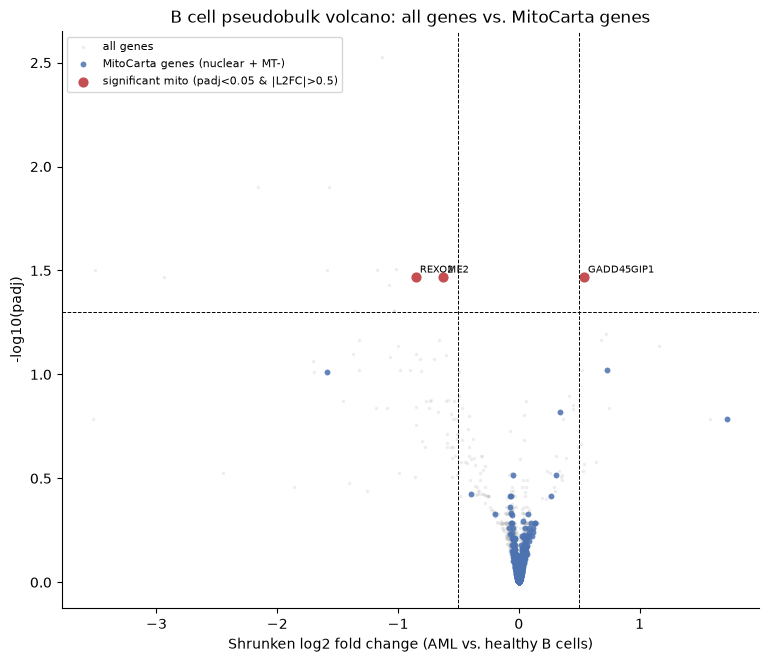

In [44]:
sig_mito = mito_table[(mito_table["padj"] < 0.05) & (mito_table["log2FoldChange"].abs() > 0.5)]
print(f"Mitochondrial genes passing padj<0.05 & |log2FC|>0.5: {len(sig_mito)}")
print(f"Mitochondrial genes with padj<0.05 (any effect size): {(mito_table['padj'] < 0.05).sum()}")
if len(sig_mito) == 0:
    print("None reach both thresholds simultaneously. Closest candidates (by padj):")
    print(mito_table.head(5)[["baseMean", "log2FoldChange", "padj", "encoded_by"]])

fig, ax = plt.subplots(figsize=(9, 7.5))
plot_df = deseq_res.dropna(subset=["padj"]).copy()
plot_df["neglog10padj"] = -np.log10(plot_df["padj"].clip(lower=1e-300))

ax.scatter(plot_df["log2FoldChange"], plot_df["neglog10padj"],
           s=6, alpha=0.25, color="#bbbbbb", linewidths=0, label="all genes")

mito_plot = plot_df.loc[plot_df.index.isin(mito_genes)]
ax.scatter(mito_plot["log2FoldChange"], mito_plot["neglog10padj"],
           s=18, alpha=0.85, color="#4c72b0", linewidths=0, label="MitoCarta genes (nuclear + MT-)")

if len(sig_mito) > 0:
    sig_plot = plot_df.loc[plot_df.index.isin(sig_mito.index)]
    ax.scatter(sig_plot["log2FoldChange"], sig_plot["neglog10padj"],
               s=40, color="#c44e52", label="significant mito (padj<0.05 & |L2FC|>0.5)")
    for gene, row in sig_plot.iterrows():
        ax.annotate(gene, (row["log2FoldChange"], row["neglog10padj"]), fontsize=7,
                    xytext=(3, 3), textcoords="offset points")
else:
    top5 = mito_table.head(5)
    top5_plot = plot_df.loc[plot_df.index.isin(top5.index)]
    ax.scatter(top5_plot["log2FoldChange"], top5_plot["neglog10padj"],
               s=40, color="#dd8452", label="top 5 mito genes (by padj, n.s.)")
    for gene, row in top5_plot.iterrows():
        ax.annotate(gene, (row["log2FoldChange"], row["neglog10padj"]), fontsize=7,
                    xytext=(3, 3), textcoords="offset points")

ax.axhline(-np.log10(0.05), color="black", lw=0.7, ls="--")
ax.axvline(0.5, color="black", lw=0.7, ls="--")
ax.axvline(-0.5, color="black", lw=0.7, ls="--")
ax.set_xlabel(f"Shrunken log2 fold change (AML vs. healthy {LABEL}s)")
ax.set_ylabel("-log10(padj)")
ax.set_title(f"{LABEL} pseudobulk volcano: all genes vs. MitoCarta genes")
ax.legend(fontsize=8, loc="upper left")
plt.show()

In [45]:
import gseapy as gp

GSEA_CACHE = os.path.join(RESULTS_DIR, f"{PFX}_gsea_results_mt_included.parquet")

mitopathways = pd.read_excel(os.path.join(DATA_DIR, "Human.MitoCarta3.0.xls"), sheet_name="C MitoPathways")
mitopathways = mitopathways.dropna(subset=["MitoPathway"])

gene_sets = {}
for _, row in mitopathways.iterrows():
    gene_sets[row["MitoPathway"]] = [g.strip() for g in str(row["Genes"]).split(",") if g.strip()]

gene_rank = deseq_res["log2FoldChange"].dropna().sort_values(ascending=False)
print(f"Ranked gene list (nuclear + MT-): {len(gene_rank)} genes; {len(gene_sets)} MitoPathway gene sets")

if os.path.exists(GSEA_CACHE):
    print("Loading cached GSEA results...")
    gsea_res = pd.read_parquet(GSEA_CACHE)
else:
    prerank = gp.prerank(
        rnk=gene_rank, gene_sets=gene_sets, min_size=5, max_size=500,
        permutation_num=1000, seed=0, threads=4, no_plot=True, outdir=None,
    )
    gsea_res = prerank.res2d.copy()
    gsea_res["NES"] = gsea_res["NES"].astype(float)
    gsea_res["FDR q-val"] = gsea_res["FDR q-val"].astype(float)
    gsea_res.to_parquet(GSEA_CACHE)

print(f"Pathways tested: {len(gsea_res)}")
print(f"Pathways with FDR q<0.05: {(gsea_res['FDR q-val'] < 0.05).sum()}")
sig_pathways = gsea_res[gsea_res["FDR q-val"] < 0.25].sort_values("NES")
print(f"Significant pathways (FDR q<0.25, standard GSEA convention): {len(sig_pathways)}")
sig_pathways[["Term", "NES", "NOM p-val", "FDR q-val"]]

Ranked gene list (nuclear + MT-): 14945 genes; 149 MitoPathway gene sets
Loading cached GSEA results...
Pathways tested: 113
Pathways with FDR q<0.05: 0
Significant pathways (FDR q<0.25, standard GSEA convention): 13


,Term,NES,NOM p-val,FDR q-val
12,Heme-containing proteins,1.595143,0.058651,0.241577
11,OXPHOS,1.635883,0.000000,0.211257
10,Selenoproteins,1.667845,0.007614,0.189227
9,Translation,1.707849,0.008621,0.165674
8,CIII subunits,1.719721,0.033241,0.170201
7,Fe-S-containing proteins,1.740809,0.037879,0.168653
6,Complex I,1.774949,0.049180,0.152385
5,CI subunits,1.836488,0.033898,0.117561
4,Mitochondrial ribosome,1.891380,0.005000,0.088411
3,Detoxification,1.975152,0.008734,0.050932


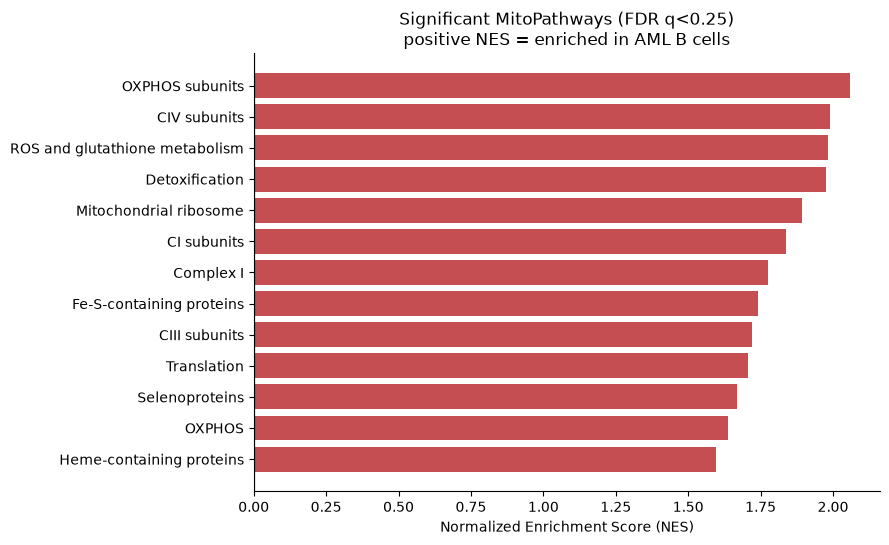

In [46]:
fig, ax = plt.subplots(figsize=(9, max(3, 0.35 * len(sig_pathways) + 1)))
if len(sig_pathways) > 0:
    colors_bar = ["#c44e52" if v > 0 else "#4c72b0" for v in sig_pathways["NES"]]
    ax.barh(sig_pathways["Term"], sig_pathways["NES"], color=colors_bar)
    ax.axvline(0, color="black", lw=0.8)
    ax.set_xlabel("Normalized Enrichment Score (NES)")
    ax.set_title(f"Significant MitoPathways (FDR q<0.25)\npositive NES = enriched in AML {LABEL}s")
else:
    ax.text(0.5, 0.5, "No MitoPathways reached FDR q<0.25", ha="center", va="center")
    ax.axis("off")
fig.tight_layout()
plt.show()

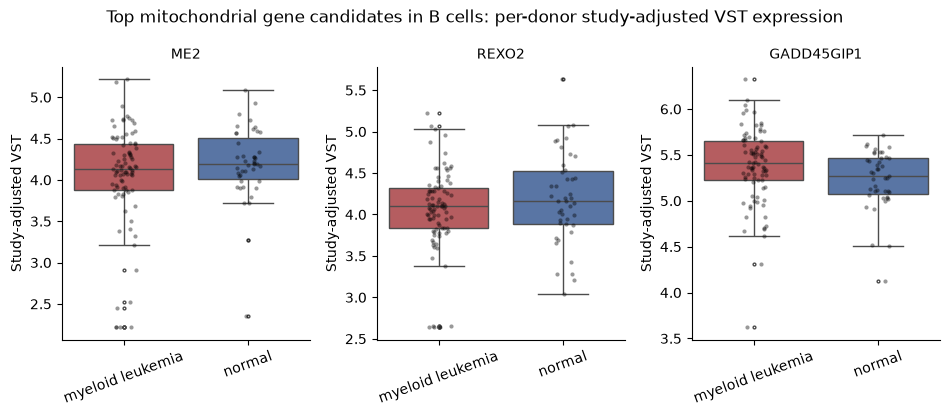

In [47]:
def study_adjusted(gene_vals, study_labels):
    df_tmp = pd.DataFrame({"v": gene_vals, "Study": study_labels})
    study_mean = df_tmp.groupby("Study")["v"].transform("mean")
    return df_tmp["v"] - study_mean + df_tmp["v"].mean()

top_genes_for_plot = (sig_mito.index.tolist() if len(sig_mito) > 0 else mito_table.head(5).index.tolist())[:5]

fig, axes = plt.subplots(1, len(top_genes_for_plot), figsize=(3.2 * len(top_genes_for_plot), 4.2), squeeze=False)
axes = axes[0]
for ax, gene in zip(axes, top_genes_for_plot):
    if use_study_covariate:
        vst_plot_vals = study_adjusted(vst_df[gene], meta["Study"])
        ylabel = "Study-adjusted VST"
    else:
        vst_plot_vals = vst_df[gene]
        ylabel = "VST"
    df_g = pd.DataFrame({ylabel: vst_plot_vals, "disease": meta["disease"].astype(str)})
    sns.boxplot(data=df_g, x="disease", y=ylabel, palette=disease_colors, ax=ax, fliersize=2)
    sns.stripplot(data=df_g, x="disease", y=ylabel, color="black", alpha=0.4, size=3, ax=ax)
    ax.set_title(gene, fontsize=10)
    ax.set_xlabel("")
    ax.tick_params(axis="x", rotation=20)
fig.suptitle(f"Top mitochondrial gene candidates in {LABEL}s: per-donor "
             + ("study-adjusted " if use_study_covariate else "") + "VST expression")
fig.tight_layout()
plt.show()

Top pathway (by |NES|, among those with >=5 leading-edge genes): OXPHOS subunits  (NES=2.06, FDR q=0.063)
Leading-edge genes plotted: 49


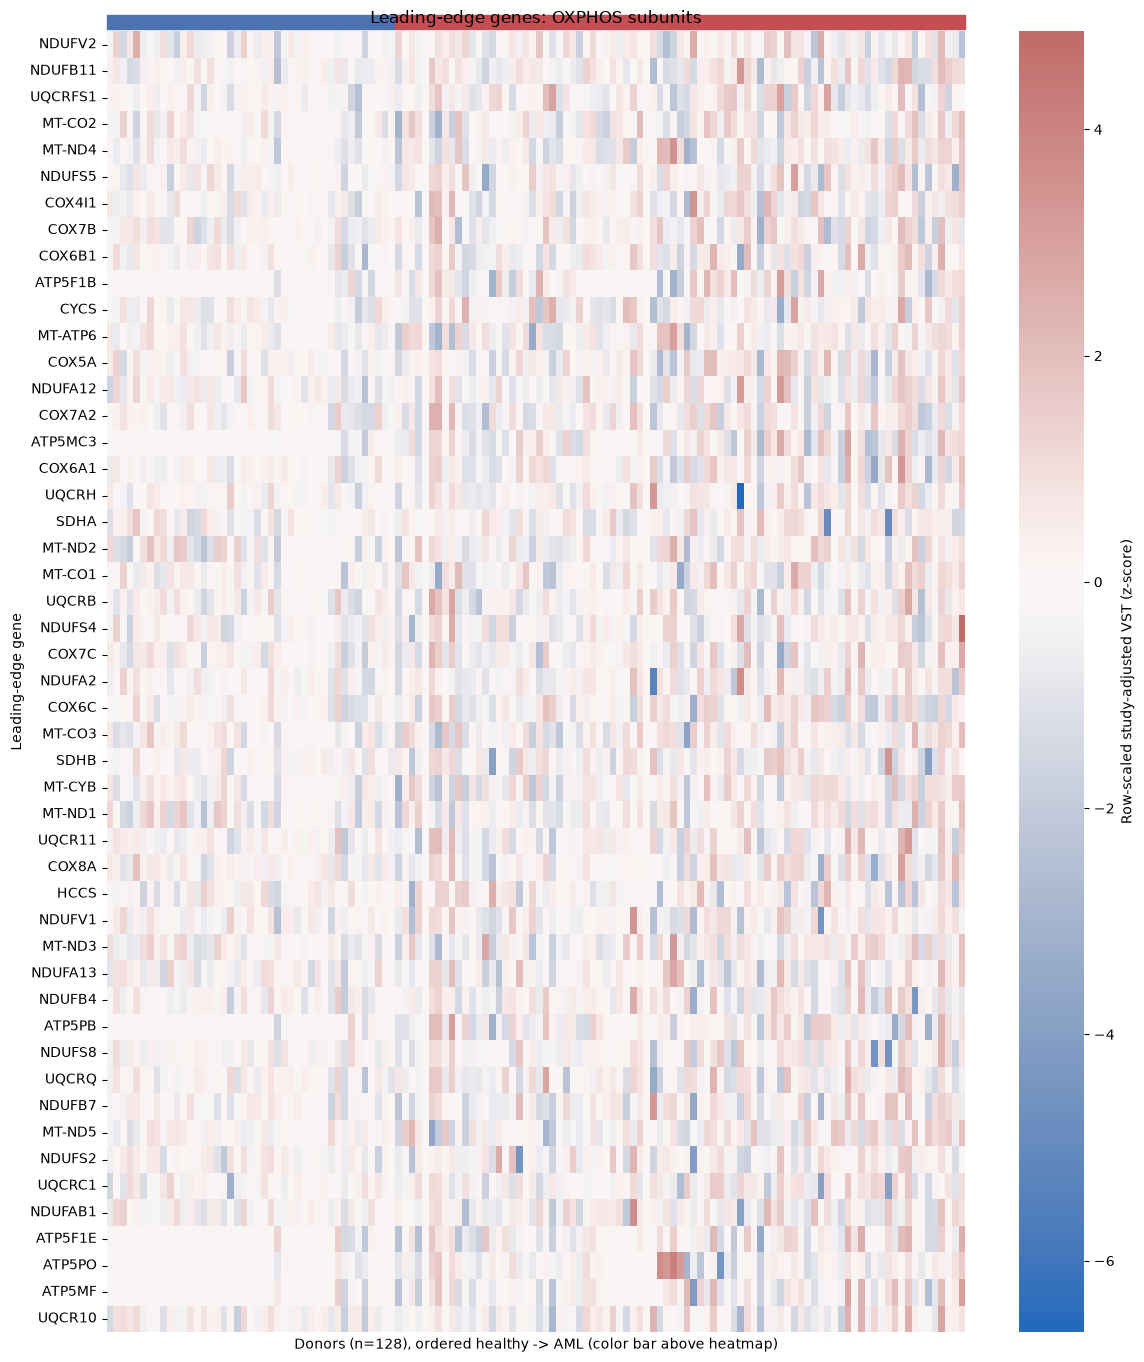

In [48]:
MIN_LEADING_EDGE = 5   # a heatmap needs several genes; skip pathways whose leading edge is (almost) empty

def _enough_genes(df):
    n = df["Lead_genes"].map(lambda s: sum(g in vst_df.columns for g in str(s).split(";")))
    return df[n >= MIN_LEADING_EDGE]

cand_ok = _enough_genes(sig_pathways if len(sig_pathways) > 0 else gsea_res)
if len(cand_ok) == 0:
    cand_ok = _enough_genes(gsea_res)   # none of the significant ones qualifies: use any tested pathway
pool = cand_ok if len(cand_ok) > 0 else gsea_res
top_pathway = pool.loc[pool["NES"].abs().idxmax()]

top_pathway_name = top_pathway["Term"]
leading_edge_genes = [g for g in str(top_pathway["Lead_genes"]).split(";") if g in vst_df.columns]
print(f"Top pathway (by |NES|, among those with >={MIN_LEADING_EDGE} leading-edge genes): "
      f"{top_pathway_name}  (NES={top_pathway['NES']:.2f}, FDR q={top_pathway['FDR q-val']:.3f})")
print(f"Leading-edge genes plotted: {len(leading_edge_genes)}")

if len(leading_edge_genes) >= 2:
    order = meta.sort_values("disease").index
    if use_study_covariate:
        hm_source = pd.DataFrame(
            {g: study_adjusted(vst_df[g], meta["Study"]) for g in leading_edge_genes},
            index=vst_df.index,
        )
        cbar_label = "Row-scaled study-adjusted VST (z-score)"
    else:
        hm_source = vst_df[leading_edge_genes]
        cbar_label = "Row-scaled VST (z-score)"
    hm_data = hm_source.loc[order, leading_edge_genes].T
    hm_z = hm_data.sub(hm_data.mean(axis=1), axis=0).div(hm_data.std(axis=1), axis=0)

    fig, ax = plt.subplots(figsize=(12, max(3, 0.28 * len(leading_edge_genes))))
    sns.heatmap(hm_z, cmap="vlag", center=0, ax=ax,
                cbar_kws={"label": cbar_label},
                xticklabels=False, yticklabels=True)
    disease_track = meta.loc[order, "disease"].astype(str).map({"normal": 0, "myeloid leukemia": 1}).values
    for i, v in enumerate(disease_track):
        ax.add_patch(plt.Rectangle((i, -0.6), 1, 0.5,
                                    color=disease_colors["myeloid leukemia"] if v else disease_colors["normal"],
                                    clip_on=False))
    ax.set_ylabel("Leading-edge gene")
    ax.set_xlabel(f"Donors (n={len(order)}), ordered healthy -> AML (color bar above heatmap)")
    ax.set_title(f"Leading-edge genes: {top_pathway_name}")
    fig.tight_layout()
    plt.show()
else:
    print("Not enough leading-edge genes with VST values to plot a heatmap.")

RESULTS[PFX] = dict(label=LABEL, deseq=deseq_res, gsea=gsea_res, mito_table=mito_table,
                    mito_genes=mito_genes, meta=meta)

10. monocyte pseudobulk 

In [49]:
CT, LABEL, PFX = "monocyte", "monocyte", "mono"
if "RESULTS" not in globals():
    RESULTS = {}

MIN_CELLS_PER_DONOR = 20
MIN_DONORS_PER_GROUP = 5

is_ct = (obs["cell_type"] == CT)
print(f"{LABEL}s before any donor-level filter: {is_ct.sum():,} cells, "
      f"{obs.loc[is_ct, 'donor_id'].nunique()} donors, "
      f"{obs.loc[is_ct, 'Study'].nunique()} studies")

ct_per_donor = (
    obs.loc[is_ct].groupby(["donor_id", "disease"], observed=True).size()
    .reset_index(name="n_cells_ct")
)
qualifying = ct_per_donor[ct_per_donor["n_cells_ct"] >= MIN_CELLS_PER_DONOR]
dropped = ct_per_donor[ct_per_donor["n_cells_ct"] < MIN_CELLS_PER_DONOR]
zero_donors = obs.loc[~obs["donor_id"].isin(ct_per_donor["donor_id"]), "donor_id"].nunique()

n_per_group = qualifying.groupby("disease", observed=True)["donor_id"].nunique()
assert (n_per_group >= MIN_DONORS_PER_GROUP).all(), "A disease group has <5 qualifying donors!"

print(f"\nDonors with ZERO {LABEL}s (dropped outright, mostly CD34+-sorted studies): {zero_donors}")
print(f"Donors with 1-{MIN_CELLS_PER_DONOR - 1} {LABEL}s (dropped, too few cells): "
      f"{dropped['donor_id'].nunique()}  ({dropped.groupby('disease', observed=True)['donor_id'].nunique().to_dict()})")
print(f"\nDonors KEPT (>={MIN_CELLS_PER_DONOR} {LABEL}s), per group:")
print(n_per_group)
print(f"\nTotal donors kept: {len(qualifying)} / {obs['donor_id'].nunique()} in the full atlas")
print(f"Total {LABEL}s kept for pseudobulk: {qualifying['n_cells_ct'].sum():,} "
      f"(of {is_ct.sum():,} {LABEL}s overall)")

qualifying_donors = qualifying["donor_id"].tolist()

studies_dropped_entirely = sorted(
    set(obs["Study"].unique())
    - set(obs.loc[obs["donor_id"].isin(qualifying_donors), "Study"].unique())
)
print(f"\nStudies with ZERO qualifying donors (effectively fully excluded): {studies_dropped_entirely}")

monocytes before any donor-level filter: 116,579 cells, 198 donors, 20 studies

Donors with ZERO monocytes (dropped outright, mostly CD34+-sorted studies): 12
Donors with 1-19 monocytes (dropped, too few cells): 38  ({'myeloid leukemia': 35, 'normal': 3})

Donors KEPT (>=20 monocytes), per group:
disease
myeloid leukemia    112
normal               48
Name: donor_id, dtype: int64

Total donors kept: 160 / 210 in the full atlas
Total monocytes kept for pseudobulk: 116,343 (of 116,579 monocytes overall)

Studies with ZERO qualifying donors (effectively fully excluded): ['fiskus_2023', 'johnston_2020', 'stetson_2021', 'zhai_2022']


In [50]:
PB_CACHE = os.path.join(RESULTS_DIR, f"{PFX}_pseudobulk_counts.parquet")
PB_META_CACHE = os.path.join(RESULTS_DIR, f"{PFX}_pseudobulk_donor_meta.parquet")

if os.path.exists(PB_CACHE) and os.path.exists(PB_META_CACHE):
    print(f"Loading cached {LABEL} pseudobulk matrix...")
    pb_counts = pd.read_parquet(PB_CACHE)
    donor_meta = pd.read_parquet(PB_META_CACHE)
else:
    donor_to_qidx = {d: i for i, d in enumerate(qualifying_donors)}
    n_donors_pb = len(qualifying_donors)
    donor_codes_arr = obs["donor_id"].values
    is_ct_arr = is_ct.values
    assign = np.full(n_cells, -1, dtype=np.int64)
    mask_keep_cell = is_ct_arr & np.isin(donor_codes_arr, qualifying_donors)
    keep_rows = np.where(mask_keep_cell)[0]
    assign[keep_rows] = np.array([donor_to_qidx[d] for d in donor_codes_arr[keep_rows]])

    t0 = time.time()
    pseudobulk = np.zeros((n_donors_pb, n_genes), dtype=np.float64)
    with h5py.File(H5_PATH, "r") as f:
        indptr = f["X/indptr"][:]
        raw_data_ds, raw_idx_ds = f["raw/X/data"], f["raw/X/indices"]
        for start in range(0, n_cells, CHUNK_ROWS):
            end = min(start + CHUNK_ROWS, n_cells)
            chunk_assign = assign[start:end]
            if not np.any(chunk_assign >= 0):
                continue
            s, e = int(indptr[start]), int(indptr[end])
            local_indptr = indptr[start:end + 1] - indptr[start]
            raw_chunk = sparse.csr_matrix(
                (raw_data_ds[s:e], raw_idx_ds[s:e], local_indptr),
                shape=(end - start, n_genes))
            valid = chunk_assign >= 0
            rows = np.where(valid)[0]
            indicator = sparse.csr_matrix(
                (np.ones(len(rows)), (chunk_assign[valid], rows)),
                shape=(n_donors_pb, end - start))
            pseudobulk += indicator.dot(raw_chunk).toarray()
    print(f"Pseudobulk scan done in {time.time()-t0:.0f}s")

    pb_counts = pd.DataFrame(pseudobulk, index=qualifying_donors, columns=gene_names)
    donor_meta = (
        obs[obs["donor_id"].isin(qualifying_donors)]
        .drop_duplicates("donor_id").set_index("donor_id")
        .loc[qualifying_donors, ["disease", "Study", "Fine Age Group", "Main Age Group", "sex", "ELN Risk Group"]]
    )
    pb_counts.to_parquet(PB_CACHE)
    donor_meta.to_parquet(PB_META_CACHE)

print(f"Pseudobulk matrix: {pb_counts.shape[0]} donors x {pb_counts.shape[1]} genes")
donor_meta["disease"].value_counts()

Loading cached monocyte pseudobulk matrix...


Pseudobulk matrix: 160 donors x 21588 genes


disease
myeloid leukemia    112
normal               48
Name: count, dtype: int64

In [51]:
counts_all = pb_counts.round().astype(int)
gene_sums = counts_all.sum(axis=0)
counts_filt = counts_all.loc[:, gene_sums >= 10]
print(f"Genes after near-empty filter (sum>=10 across donors): {counts_filt.shape[1]} / {counts_all.shape[1]}")

meta = donor_meta.copy()
meta["disease"] = pd.Categorical(meta["disease"].astype(str), categories=["normal", "myeloid leukemia"])
meta["Study"] = meta["Study"].astype(str)

design_full = pd.get_dummies(meta[["Study", "disease"]], drop_first=True).astype(float)
design_full.insert(0, "intercept", 1.0)
rank = np.linalg.matrix_rank(design_full.values)
use_study_covariate = (rank == design_full.shape[1])
print(f"~ Study + disease design matrix: {design_full.shape}, rank {rank} "
      f"-> {'FULL RANK, using Study as covariate' if use_study_covariate else 'RANK DEFICIENT, falling back to ~ disease'}")

DESIGN_FORMULA = "~Study+disease" if use_study_covariate else "~disease"

Genes after near-empty filter (sum>=10 across donors): 19094 / 21588
~ Study + disease design matrix: (160, 17), rank 17 -> FULL RANK, using Study as covariate


In [52]:
from pydeseq2.dds import DeseqDataSet
from pydeseq2.ds import DeseqStats

DESEQ_CACHE = os.path.join(RESULTS_DIR, f"{PFX}_deseq_results.parquet")
VST_CACHE = os.path.join(RESULTS_DIR, f"{PFX}_vst.parquet")

if os.path.exists(DESEQ_CACHE) and os.path.exists(VST_CACHE):
    print("Loading cached DESeq2 results + VST matrix...")
    deseq_res = pd.read_parquet(DESEQ_CACHE)
    vst_df = pd.read_parquet(VST_CACHE)
else:
    dds = DeseqDataSet(counts=counts_filt, metadata=meta, design=DESIGN_FORMULA,
                        refit_cooks=True, quiet=True)
    dds.deseq2()

    dds.vst(use_design=False)
    vst_df = pd.DataFrame(dds.layers["vst_counts"], index=dds.obs_names, columns=dds.var_names)

    ds = DeseqStats(dds, contrast=["disease", "myeloid leukemia", "normal"], quiet=True)
    ds.summary()
    ds.lfc_shrink(coeff="disease[T.myeloid leukemia]")
    deseq_res = ds.results_df.copy()

    deseq_res.to_parquet(DESEQ_CACHE)
    vst_df.to_parquet(VST_CACHE)

print(f"DESeq2 results: {deseq_res.shape[0]} genes tested "
      f"(positive log2FC = higher in AML {LABEL}s vs. healthy {LABEL}s)")
print(f"Significant genes overall (padj < 0.05): {(deseq_res['padj'] < 0.05).sum()}")
deseq_res.sort_values("padj").head(10)

Loading cached DESeq2 results + VST matrix...


DESeq2 results: 19094 genes tested (positive log2FC = higher in AML monocytes vs. healthy monocytes)
Significant genes overall (padj < 0.05): 117


,baseMean,log2FoldChange,lfcSE,stat,pvalue,padj
HES1,14.815602,-4.544329,0.686875,-7.738828,1.003376e-14,1.023945e-10
LMNA,331.458474,2.499697,0.540960,5.824478,5.729123e-09,2.679849e-05
VSIG4,34.932475,4.505976,0.846237,5.771047,7.878047e-09,2.679849e-05
IVNS1ABP,107.954489,-1.232178,0.334663,-5.074936,3.876260e-07,6.592872e-04
C1QA,232.070073,3.270696,0.882743,5.090676,3.567901e-07,6.592872e-04
FLT3,44.339756,1.901888,0.504363,5.090069,3.579333e-07,6.592872e-04
SYNE1,43.519391,-1.673481,0.477011,-5.030280,4.897646e-07,7.140068e-04
OSM,29.470661,-1.960375,0.623819,-4.989749,6.045784e-07,7.712153e-04
P2RX4,67.958661,0.911478,0.250618,4.928951,8.267248e-07,9.374140e-04
SPATA13,60.243230,-1.058255,0.311623,-4.825041,1.399747e-06,1.184858e-03


Variance explained by PC1-5: [0.247 0.113 0.091 0.067 0.045]
Donors flagged as PCA outliers (>3 SD on PC1 or PC2): ['AML210A', 'AML329', 'AML419A', 'AML1012', 'BM1', 'BM2']


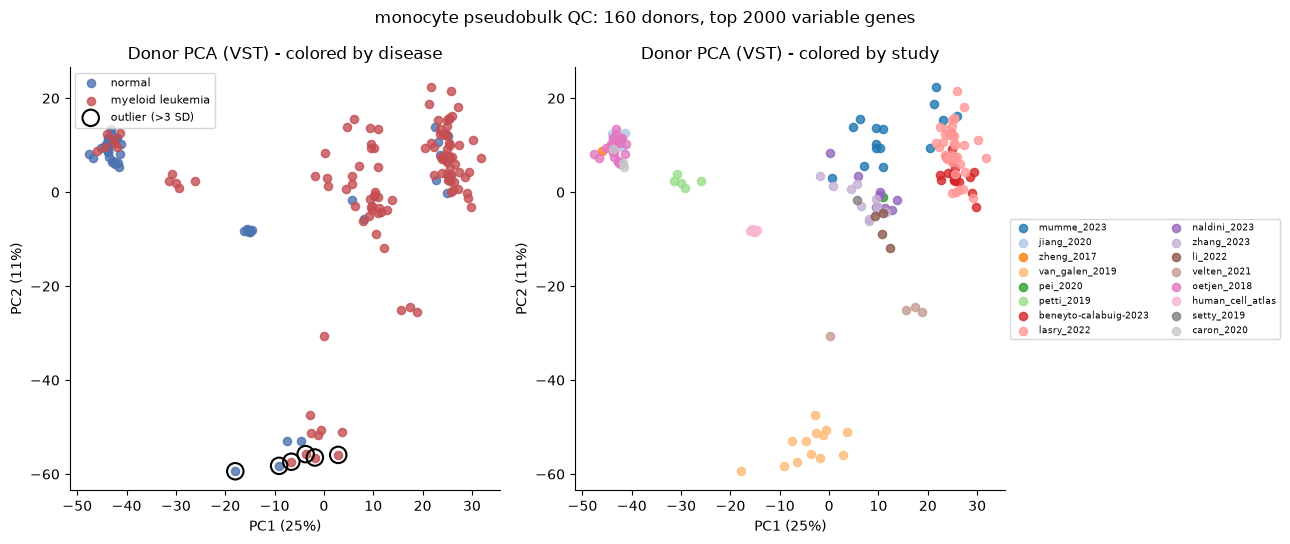

In [53]:
from sklearn.decomposition import PCA

gene_var = vst_df.var(axis=0).sort_values(ascending=False)
top_var_genes = gene_var.index[:2000]
Xc = vst_df[top_var_genes].values
Xc = Xc - Xc.mean(axis=0)
pca = PCA(n_components=10, random_state=0)
pcs = pca.fit_transform(Xc)
print("Variance explained by PC1-5:", np.round(pca.explained_variance_ratio_[:5], 3))

pc_df = pd.DataFrame(pcs[:, :2], columns=["PC1", "PC2"], index=vst_df.index).join(meta)
z1 = (pc_df["PC1"] - pc_df["PC1"].mean()) / pc_df["PC1"].std()
z2 = (pc_df["PC2"] - pc_df["PC2"].mean()) / pc_df["PC2"].std()
pc_df["outlier"] = (z1.abs() > 3) | (z2.abs() > 3)
outlier_donors = pc_df.index[pc_df["outlier"]].tolist()
print(f"Donors flagged as PCA outliers (>3 SD on PC1 or PC2): {outlier_donors}")

fig, axes = plt.subplots(1, 2, figsize=(13, 5.5))
disease_colors = {"normal": "#4c72b0", "myeloid leukemia": "#c44e52"}
for d, c in disease_colors.items():
    m = pc_df["disease"].astype(str) == d
    axes[0].scatter(pc_df.loc[m, "PC1"], pc_df.loc[m, "PC2"], s=35, alpha=0.8, color=c, label=d)
axes[0].scatter(pc_df.loc[pc_df["outlier"], "PC1"], pc_df.loc[pc_df["outlier"], "PC2"],
                s=140, facecolors="none", edgecolors="black", linewidths=1.5, label="outlier (>3 SD)")
axes[0].set_xlabel(f"PC1 ({pca.explained_variance_ratio_[0]*100:.0f}%)")
axes[0].set_ylabel(f"PC2 ({pca.explained_variance_ratio_[1]*100:.0f}%)")
axes[0].set_title("Donor PCA (VST) - colored by disease")
axes[0].legend(fontsize=8)

study_cats = pc_df["Study"].astype(str).unique()
study_colors2 = dict(zip(study_cats, sns.color_palette("tab20", len(study_cats))))
for s in study_cats:
    m = pc_df["Study"].astype(str) == s
    axes[1].scatter(pc_df.loc[m, "PC1"], pc_df.loc[m, "PC2"], s=35, alpha=0.8, color=study_colors2[s], label=s)
axes[1].set_xlabel(f"PC1 ({pca.explained_variance_ratio_[0]*100:.0f}%)")
axes[1].set_ylabel(f"PC2 ({pca.explained_variance_ratio_[1]*100:.0f}%)")
axes[1].set_title("Donor PCA (VST) - colored by study")
axes[1].legend(fontsize=6.5, ncol=2, loc="center left", bbox_to_anchor=(1.0, 0.5))

fig.suptitle(f"{LABEL} pseudobulk QC: {len(pc_df)} donors, top {len(top_var_genes)} variable genes")
fig.tight_layout()
plt.show()

In [54]:
mitocarta = pd.read_excel(os.path.join(DATA_DIR, "Human.MitoCarta3.0.xls"), sheet_name="A Human MitoCarta3.0")
mitocarta_genes = set(mitocarta["Symbol"].dropna().astype(str))

MT_GENES_ALL = sorted([g for g in gene_names if g.upper().startswith("MT-")])
mito_genes = sorted([g for g in mitocarta_genes if g in deseq_res.index])
n_mt_in_set = sum(g.upper().startswith("MT-") for g in mito_genes)
print(f"MitoCarta3.0: {len(mitocarta_genes)} genes total")
print(f"MitoCarta genes tested in this DE analysis: {len(mito_genes)} "
      f"({len(mito_genes) - n_mt_in_set} nuclear-encoded + {n_mt_in_set} mtDNA-encoded MT- genes)")

mito_table = deseq_res.loc[mito_genes].sort_values("padj")
mito_table["encoded_by"] = np.where(mito_table.index.str.upper().str.startswith("MT-"), "mtDNA", "nuclear")
display(mito_table.head(15)[["baseMean", "log2FoldChange", "lfcSE", "pvalue", "padj", "encoded_by"]])

MitoCarta3.0: 1136 genes total
MitoCarta genes tested in this DE analysis: 1037 (1024 nuclear-encoded + 13 mtDNA-encoded MT- genes)


,baseMean,log2FoldChange,lfcSE,pvalue,padj,encoded_by
TMEM11,40.800350,0.669207,0.237691,0.000024,0.010600,nuclear
BNIP3,17.396914,1.082577,0.508935,0.000113,0.023661,nuclear
GLYCTK,8.864764,-0.670480,0.344393,0.000443,0.044760,nuclear
OXCT1,6.807546,-0.803207,0.576161,0.000852,0.062122,nuclear
PMAIP1,124.961393,0.842199,0.523730,0.001099,0.071208,nuclear
PNKD,88.747985,0.336484,0.382735,0.001496,0.083881,nuclear
IDI1,88.108837,-0.462319,0.468047,0.001482,0.083881,nuclear
BAX,205.367507,0.358235,0.659095,0.001615,0.086727,nuclear
PNPLA8,115.955274,-0.464678,0.398698,0.002267,0.104695,nuclear
ACADSB,7.562855,-0.515066,2.915005,0.002817,0.121365,nuclear


Mitochondrial genes passing padj<0.05 & |log2FC|>0.5: 3
Mitochondrial genes with padj<0.05 (any effect size): 3


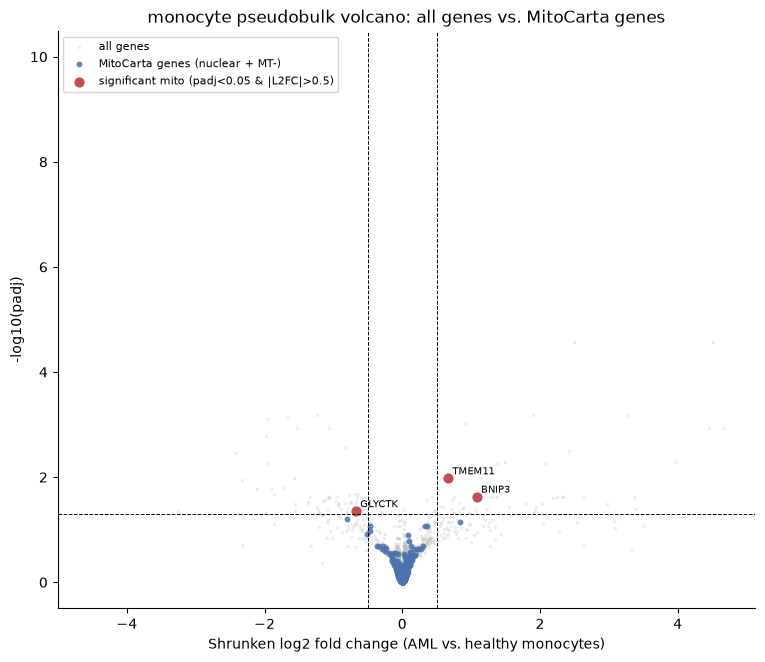

In [55]:
sig_mito = mito_table[(mito_table["padj"] < 0.05) & (mito_table["log2FoldChange"].abs() > 0.5)]
print(f"Mitochondrial genes passing padj<0.05 & |log2FC|>0.5: {len(sig_mito)}")
print(f"Mitochondrial genes with padj<0.05 (any effect size): {(mito_table['padj'] < 0.05).sum()}")
if len(sig_mito) == 0:
    print("None reach both thresholds simultaneously. Closest candidates (by padj):")
    print(mito_table.head(5)[["baseMean", "log2FoldChange", "padj", "encoded_by"]])

fig, ax = plt.subplots(figsize=(9, 7.5))
plot_df = deseq_res.dropna(subset=["padj"]).copy()
plot_df["neglog10padj"] = -np.log10(plot_df["padj"].clip(lower=1e-300))

ax.scatter(plot_df["log2FoldChange"], plot_df["neglog10padj"],
           s=6, alpha=0.25, color="#bbbbbb", linewidths=0, label="all genes")

mito_plot = plot_df.loc[plot_df.index.isin(mito_genes)]
ax.scatter(mito_plot["log2FoldChange"], mito_plot["neglog10padj"],
           s=18, alpha=0.85, color="#4c72b0", linewidths=0, label="MitoCarta genes (nuclear + MT-)")

if len(sig_mito) > 0:
    sig_plot = plot_df.loc[plot_df.index.isin(sig_mito.index)]
    ax.scatter(sig_plot["log2FoldChange"], sig_plot["neglog10padj"],
               s=40, color="#c44e52", label="significant mito (padj<0.05 & |L2FC|>0.5)")
    for gene, row in sig_plot.iterrows():
        ax.annotate(gene, (row["log2FoldChange"], row["neglog10padj"]), fontsize=7,
                    xytext=(3, 3), textcoords="offset points")
else:
    top5 = mito_table.head(5)
    top5_plot = plot_df.loc[plot_df.index.isin(top5.index)]
    ax.scatter(top5_plot["log2FoldChange"], top5_plot["neglog10padj"],
               s=40, color="#dd8452", label="top 5 mito genes (by padj, n.s.)")
    for gene, row in top5_plot.iterrows():
        ax.annotate(gene, (row["log2FoldChange"], row["neglog10padj"]), fontsize=7,
                    xytext=(3, 3), textcoords="offset points")

ax.axhline(-np.log10(0.05), color="black", lw=0.7, ls="--")
ax.axvline(0.5, color="black", lw=0.7, ls="--")
ax.axvline(-0.5, color="black", lw=0.7, ls="--")
ax.set_xlabel(f"Shrunken log2 fold change (AML vs. healthy {LABEL}s)")
ax.set_ylabel("-log10(padj)")
ax.set_title(f"{LABEL} pseudobulk volcano: all genes vs. MitoCarta genes")
ax.legend(fontsize=8, loc="upper left")
plt.show()

In [56]:
import gseapy as gp

GSEA_CACHE = os.path.join(RESULTS_DIR, f"{PFX}_gsea_results_mt_included.parquet")

mitopathways = pd.read_excel(os.path.join(DATA_DIR, "Human.MitoCarta3.0.xls"), sheet_name="C MitoPathways")
mitopathways = mitopathways.dropna(subset=["MitoPathway"])

gene_sets = {}
for _, row in mitopathways.iterrows():
    gene_sets[row["MitoPathway"]] = [g.strip() for g in str(row["Genes"]).split(",") if g.strip()]

gene_rank = deseq_res["log2FoldChange"].dropna().sort_values(ascending=False)
print(f"Ranked gene list (nuclear + MT-): {len(gene_rank)} genes; {len(gene_sets)} MitoPathway gene sets")

if os.path.exists(GSEA_CACHE):
    print("Loading cached GSEA results...")
    gsea_res = pd.read_parquet(GSEA_CACHE)
else:
    prerank = gp.prerank(
        rnk=gene_rank, gene_sets=gene_sets, min_size=5, max_size=500,
        permutation_num=1000, seed=0, threads=4, no_plot=True, outdir=None,
    )
    gsea_res = prerank.res2d.copy()
    gsea_res["NES"] = gsea_res["NES"].astype(float)
    gsea_res["FDR q-val"] = gsea_res["FDR q-val"].astype(float)
    gsea_res.to_parquet(GSEA_CACHE)

print(f"Pathways tested: {len(gsea_res)}")
print(f"Pathways with FDR q<0.05: {(gsea_res['FDR q-val'] < 0.05).sum()}")
sig_pathways = gsea_res[gsea_res["FDR q-val"] < 0.25].sort_values("NES")
print(f"Significant pathways (FDR q<0.25, standard GSEA convention): {len(sig_pathways)}")
sig_pathways[["Term", "NES", "NOM p-val", "FDR q-val"]]

Ranked gene list (nuclear + MT-): 19094 genes; 149 MitoPathway gene sets
Loading cached GSEA results...
Pathways tested: 114
Pathways with FDR q<0.05: 0
Significant pathways (FDR q<0.25, standard GSEA convention): 0


,Term,NES,NOM p-val,FDR q-val


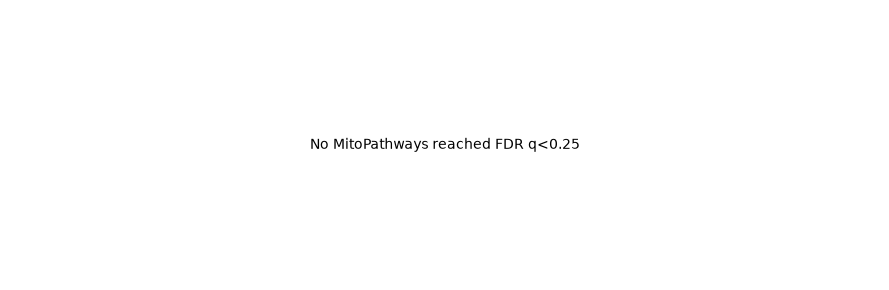

In [57]:
fig, ax = plt.subplots(figsize=(9, max(3, 0.35 * len(sig_pathways) + 1)))
if len(sig_pathways) > 0:
    colors_bar = ["#c44e52" if v > 0 else "#4c72b0" for v in sig_pathways["NES"]]
    ax.barh(sig_pathways["Term"], sig_pathways["NES"], color=colors_bar)
    ax.axvline(0, color="black", lw=0.8)
    ax.set_xlabel("Normalized Enrichment Score (NES)")
    ax.set_title(f"Significant MitoPathways (FDR q<0.25)\npositive NES = enriched in AML {LABEL}s")
else:
    ax.text(0.5, 0.5, "No MitoPathways reached FDR q<0.25", ha="center", va="center")
    ax.axis("off")
fig.tight_layout()
plt.show()

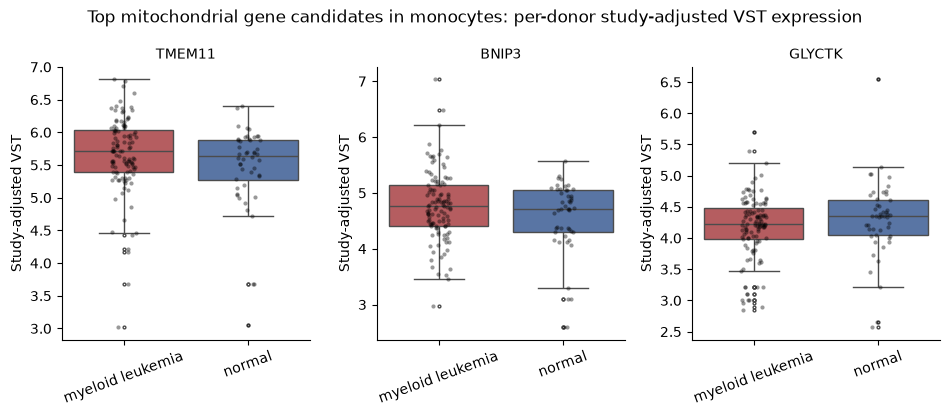

In [58]:
def study_adjusted(gene_vals, study_labels):
    df_tmp = pd.DataFrame({"v": gene_vals, "Study": study_labels})
    study_mean = df_tmp.groupby("Study")["v"].transform("mean")
    return df_tmp["v"] - study_mean + df_tmp["v"].mean()

top_genes_for_plot = (sig_mito.index.tolist() if len(sig_mito) > 0 else mito_table.head(5).index.tolist())[:5]

fig, axes = plt.subplots(1, len(top_genes_for_plot), figsize=(3.2 * len(top_genes_for_plot), 4.2), squeeze=False)
axes = axes[0]
for ax, gene in zip(axes, top_genes_for_plot):
    if use_study_covariate:
        vst_plot_vals = study_adjusted(vst_df[gene], meta["Study"])
        ylabel = "Study-adjusted VST"
    else:
        vst_plot_vals = vst_df[gene]
        ylabel = "VST"
    df_g = pd.DataFrame({ylabel: vst_plot_vals, "disease": meta["disease"].astype(str)})
    sns.boxplot(data=df_g, x="disease", y=ylabel, palette=disease_colors, ax=ax, fliersize=2)
    sns.stripplot(data=df_g, x="disease", y=ylabel, color="black", alpha=0.4, size=3, ax=ax)
    ax.set_title(gene, fontsize=10)
    ax.set_xlabel("")
    ax.tick_params(axis="x", rotation=20)
fig.suptitle(f"Top mitochondrial gene candidates in {LABEL}s: per-donor "
             + ("study-adjusted " if use_study_covariate else "") + "VST expression")
fig.tight_layout()
plt.show()

Top pathway (by |NES|, among those with >=5 leading-edge genes): Carbohydrate metabolism  (NES=-1.29, FDR q=1.000)
Leading-edge genes plotted: 19


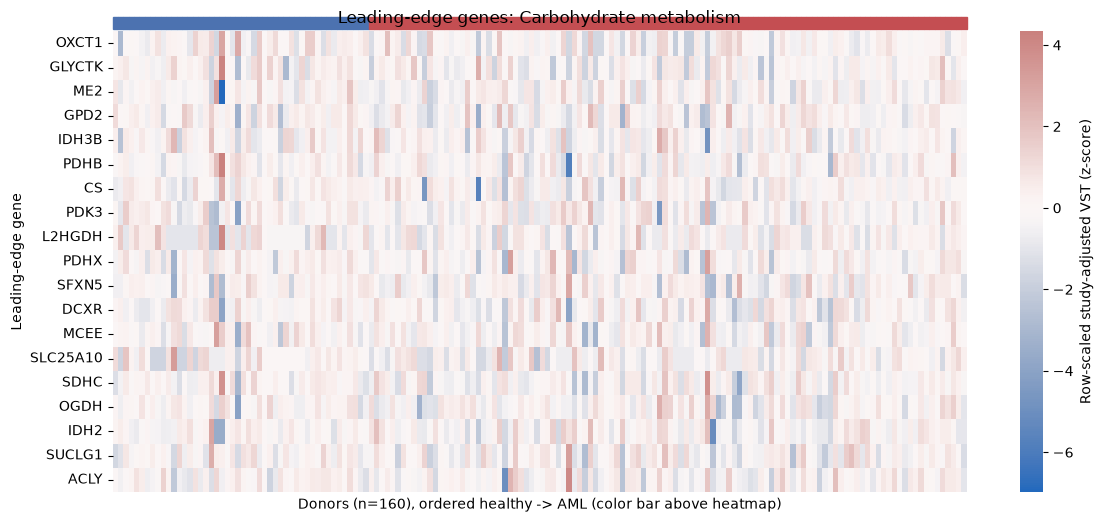

In [59]:
MIN_LEADING_EDGE = 5   # a heatmap needs several genes; skip pathways whose leading edge is (almost) empty

def _enough_genes(df):
    n = df["Lead_genes"].map(lambda s: sum(g in vst_df.columns for g in str(s).split(";")))
    return df[n >= MIN_LEADING_EDGE]

cand_ok = _enough_genes(sig_pathways if len(sig_pathways) > 0 else gsea_res)
if len(cand_ok) == 0:
    cand_ok = _enough_genes(gsea_res)   # none of the significant ones qualifies: use any tested pathway
pool = cand_ok if len(cand_ok) > 0 else gsea_res
top_pathway = pool.loc[pool["NES"].abs().idxmax()]

top_pathway_name = top_pathway["Term"]
leading_edge_genes = [g for g in str(top_pathway["Lead_genes"]).split(";") if g in vst_df.columns]
print(f"Top pathway (by |NES|, among those with >={MIN_LEADING_EDGE} leading-edge genes): "
      f"{top_pathway_name}  (NES={top_pathway['NES']:.2f}, FDR q={top_pathway['FDR q-val']:.3f})")
print(f"Leading-edge genes plotted: {len(leading_edge_genes)}")

if len(leading_edge_genes) >= 2:
    order = meta.sort_values("disease").index
    if use_study_covariate:
        hm_source = pd.DataFrame(
            {g: study_adjusted(vst_df[g], meta["Study"]) for g in leading_edge_genes},
            index=vst_df.index,
        )
        cbar_label = "Row-scaled study-adjusted VST (z-score)"
    else:
        hm_source = vst_df[leading_edge_genes]
        cbar_label = "Row-scaled VST (z-score)"
    hm_data = hm_source.loc[order, leading_edge_genes].T
    hm_z = hm_data.sub(hm_data.mean(axis=1), axis=0).div(hm_data.std(axis=1), axis=0)

    fig, ax = plt.subplots(figsize=(12, max(3, 0.28 * len(leading_edge_genes))))
    sns.heatmap(hm_z, cmap="vlag", center=0, ax=ax,
                cbar_kws={"label": cbar_label},
                xticklabels=False, yticklabels=True)
    disease_track = meta.loc[order, "disease"].astype(str).map({"normal": 0, "myeloid leukemia": 1}).values
    for i, v in enumerate(disease_track):
        ax.add_patch(plt.Rectangle((i, -0.6), 1, 0.5,
                                    color=disease_colors["myeloid leukemia"] if v else disease_colors["normal"],
                                    clip_on=False))
    ax.set_ylabel("Leading-edge gene")
    ax.set_xlabel(f"Donors (n={len(order)}), ordered healthy -> AML (color bar above heatmap)")
    ax.set_title(f"Leading-edge genes: {top_pathway_name}")
    fig.tight_layout()
    plt.show()
else:
    print("Not enough leading-edge genes with VST values to plot a heatmap.")

RESULTS[PFX] = dict(label=LABEL, deseq=deseq_res, gsea=gsea_res, mito_table=mito_table,
                    mito_genes=mito_genes, meta=meta)

11. promonocyte 

In [60]:
CT, LABEL, PFX = "promonocyte", "promonocyte", "promono"
if "RESULTS" not in globals():
    RESULTS = {}

MIN_CELLS_PER_DONOR = 20
MIN_DONORS_PER_GROUP = 5

is_ct = (obs["cell_type"] == CT)
print(f"{LABEL}s before any donor-level filter: {is_ct.sum():,} cells, "
      f"{obs.loc[is_ct, 'donor_id'].nunique()} donors, "
      f"{obs.loc[is_ct, 'Study'].nunique()} studies")

ct_per_donor = (
    obs.loc[is_ct].groupby(["donor_id", "disease"], observed=True).size()
    .reset_index(name="n_cells_ct")
)
qualifying = ct_per_donor[ct_per_donor["n_cells_ct"] >= MIN_CELLS_PER_DONOR]
dropped = ct_per_donor[ct_per_donor["n_cells_ct"] < MIN_CELLS_PER_DONOR]
zero_donors = obs.loc[~obs["donor_id"].isin(ct_per_donor["donor_id"]), "donor_id"].nunique()

n_per_group = qualifying.groupby("disease", observed=True)["donor_id"].nunique()
assert (n_per_group >= MIN_DONORS_PER_GROUP).all(), "A disease group has <5 qualifying donors!"

print(f"\nDonors with ZERO {LABEL}s (dropped outright, mostly CD34+-sorted studies): {zero_donors}")
print(f"Donors with 1-{MIN_CELLS_PER_DONOR - 1} {LABEL}s (dropped, too few cells): "
      f"{dropped['donor_id'].nunique()}  ({dropped.groupby('disease', observed=True)['donor_id'].nunique().to_dict()})")
print(f"\nDonors KEPT (>={MIN_CELLS_PER_DONOR} {LABEL}s), per group:")
print(n_per_group)
print(f"\nTotal donors kept: {len(qualifying)} / {obs['donor_id'].nunique()} in the full atlas")
print(f"Total {LABEL}s kept for pseudobulk: {qualifying['n_cells_ct'].sum():,} "
      f"(of {is_ct.sum():,} {LABEL}s overall)")

qualifying_donors = qualifying["donor_id"].tolist()

studies_dropped_entirely = sorted(
    set(obs["Study"].unique())
    - set(obs.loc[obs["donor_id"].isin(qualifying_donors), "Study"].unique())
)
print(f"\nStudies with ZERO qualifying donors (effectively fully excluded): {studies_dropped_entirely}")

promonocytes before any donor-level filter: 39,137 cells, 178 donors, 19 studies

Donors with ZERO promonocytes (dropped outright, mostly CD34+-sorted studies): 32
Donors with 1-19 promonocytes (dropped, too few cells): 69  ({'myeloid leukemia': 58, 'normal': 11})

Donors KEPT (>=20 promonocytes), per group:
disease
myeloid leukemia    73
normal              36
Name: donor_id, dtype: int64

Total donors kept: 109 / 210 in the full atlas
Total promonocytes kept for pseudobulk: 38,717 (of 39,137 promonocytes overall)

Studies with ZERO qualifying donors (effectively fully excluded): ['human_cell_atlas', 'johnston_2020', 'pei_2020', 'stetson_2021', 'zhai_2022']


In [61]:
PB_CACHE = os.path.join(RESULTS_DIR, f"{PFX}_pseudobulk_counts.parquet")
PB_META_CACHE = os.path.join(RESULTS_DIR, f"{PFX}_pseudobulk_donor_meta.parquet")

if os.path.exists(PB_CACHE) and os.path.exists(PB_META_CACHE):
    print(f"Loading cached {LABEL} pseudobulk matrix...")
    pb_counts = pd.read_parquet(PB_CACHE)
    donor_meta = pd.read_parquet(PB_META_CACHE)
else:
    donor_to_qidx = {d: i for i, d in enumerate(qualifying_donors)}
    n_donors_pb = len(qualifying_donors)
    donor_codes_arr = obs["donor_id"].values
    is_ct_arr = is_ct.values
    assign = np.full(n_cells, -1, dtype=np.int64)
    mask_keep_cell = is_ct_arr & np.isin(donor_codes_arr, qualifying_donors)
    keep_rows = np.where(mask_keep_cell)[0]
    assign[keep_rows] = np.array([donor_to_qidx[d] for d in donor_codes_arr[keep_rows]])

    t0 = time.time()
    pseudobulk = np.zeros((n_donors_pb, n_genes), dtype=np.float64)
    with h5py.File(H5_PATH, "r") as f:
        indptr = f["X/indptr"][:]
        raw_data_ds, raw_idx_ds = f["raw/X/data"], f["raw/X/indices"]
        for start in range(0, n_cells, CHUNK_ROWS):
            end = min(start + CHUNK_ROWS, n_cells)
            chunk_assign = assign[start:end]
            if not np.any(chunk_assign >= 0):
                continue
            s, e = int(indptr[start]), int(indptr[end])
            local_indptr = indptr[start:end + 1] - indptr[start]
            raw_chunk = sparse.csr_matrix(
                (raw_data_ds[s:e], raw_idx_ds[s:e], local_indptr),
                shape=(end - start, n_genes))
            valid = chunk_assign >= 0
            rows = np.where(valid)[0]
            indicator = sparse.csr_matrix(
                (np.ones(len(rows)), (chunk_assign[valid], rows)),
                shape=(n_donors_pb, end - start))
            pseudobulk += indicator.dot(raw_chunk).toarray()
    print(f"Pseudobulk scan done in {time.time()-t0:.0f}s")

    pb_counts = pd.DataFrame(pseudobulk, index=qualifying_donors, columns=gene_names)
    donor_meta = (
        obs[obs["donor_id"].isin(qualifying_donors)]
        .drop_duplicates("donor_id").set_index("donor_id")
        .loc[qualifying_donors, ["disease", "Study", "Fine Age Group", "Main Age Group", "sex", "ELN Risk Group"]]
    )
    pb_counts.to_parquet(PB_CACHE)
    donor_meta.to_parquet(PB_META_CACHE)

print(f"Pseudobulk matrix: {pb_counts.shape[0]} donors x {pb_counts.shape[1]} genes")
donor_meta["disease"].value_counts()

Loading cached promonocyte pseudobulk matrix...


Pseudobulk matrix: 109 donors x 21588 genes


disease
myeloid leukemia    73
normal              36
Name: count, dtype: int64

In [62]:
counts_all = pb_counts.round().astype(int)
gene_sums = counts_all.sum(axis=0)
counts_filt = counts_all.loc[:, gene_sums >= 10]
print(f"Genes after near-empty filter (sum>=10 across donors): {counts_filt.shape[1]} / {counts_all.shape[1]}")

meta = donor_meta.copy()
meta["disease"] = pd.Categorical(meta["disease"].astype(str), categories=["normal", "myeloid leukemia"])
meta["Study"] = meta["Study"].astype(str)

design_full = pd.get_dummies(meta[["Study", "disease"]], drop_first=True).astype(float)
design_full.insert(0, "intercept", 1.0)
rank = np.linalg.matrix_rank(design_full.values)
use_study_covariate = (rank == design_full.shape[1])
print(f"~ Study + disease design matrix: {design_full.shape}, rank {rank} "
      f"-> {'FULL RANK, using Study as covariate' if use_study_covariate else 'RANK DEFICIENT, falling back to ~ disease'}")

DESIGN_FORMULA = "~Study+disease" if use_study_covariate else "~disease"

Genes after near-empty filter (sum>=10 across donors): 18778 / 21588
~ Study + disease design matrix: (109, 16), rank 16 -> FULL RANK, using Study as covariate


In [63]:
from pydeseq2.dds import DeseqDataSet
from pydeseq2.ds import DeseqStats

DESEQ_CACHE = os.path.join(RESULTS_DIR, f"{PFX}_deseq_results.parquet")
VST_CACHE = os.path.join(RESULTS_DIR, f"{PFX}_vst.parquet")

if os.path.exists(DESEQ_CACHE) and os.path.exists(VST_CACHE):
    print("Loading cached DESeq2 results + VST matrix...")
    deseq_res = pd.read_parquet(DESEQ_CACHE)
    vst_df = pd.read_parquet(VST_CACHE)
else:
    dds = DeseqDataSet(counts=counts_filt, metadata=meta, design=DESIGN_FORMULA,
                        refit_cooks=True, quiet=True)
    dds.deseq2()

    dds.vst(use_design=False)
    vst_df = pd.DataFrame(dds.layers["vst_counts"], index=dds.obs_names, columns=dds.var_names)

    ds = DeseqStats(dds, contrast=["disease", "myeloid leukemia", "normal"], quiet=True)
    ds.summary()
    ds.lfc_shrink(coeff="disease[T.myeloid leukemia]")
    deseq_res = ds.results_df.copy()

    deseq_res.to_parquet(DESEQ_CACHE)
    vst_df.to_parquet(VST_CACHE)

print(f"DESeq2 results: {deseq_res.shape[0]} genes tested "
      f"(positive log2FC = higher in AML {LABEL}s vs. healthy {LABEL}s)")
print(f"Significant genes overall (padj < 0.05): {(deseq_res['padj'] < 0.05).sum()}")
deseq_res.sort_values("padj").head(10)

Loading cached DESeq2 results + VST matrix...


DESeq2 results: 18778 genes tested (positive log2FC = higher in AML promonocytes vs. healthy promonocytes)
Significant genes overall (padj < 0.05): 153


,baseMean,log2FoldChange,lfcSE,stat,pvalue,padj
DUSP6,100.412215,2.018922,0.372683,6.202044,5.573466e-10,0.000006
UBE2E1,57.149126,0.896993,0.185245,5.659398,1.519051e-08,0.000085
EREG,102.846772,-0.000037,0.000503,-5.557203,2.741314e-08,0.000102
MEIS1,15.179724,4.280733,0.835279,5.434704,5.488744e-08,0.000138
GFI1,13.326383,2.516559,0.529281,5.413009,6.197443e-08,0.000138
PCSK5,3.298481,-2.262265,0.588658,-5.121980,3.023439e-07,0.000561
APOC2,22.902158,4.832576,1.067464,5.091936,3.544264e-07,0.000563
HOXA9,62.859171,3.498405,0.961997,5.010938,5.416538e-07,0.000753
CEP55,33.053058,-1.172952,0.268497,-4.980723,6.334732e-07,0.000783
KDM5B,32.177593,1.452177,0.337109,4.922922,8.526127e-07,0.000949


Variance explained by PC1-5: [0.284 0.125 0.082 0.057 0.046]
Donors flagged as PCA outliers (>3 SD on PC1 or PC2): ['AML210A', 'AML329', 'AML371', 'BM2', 'BM4']


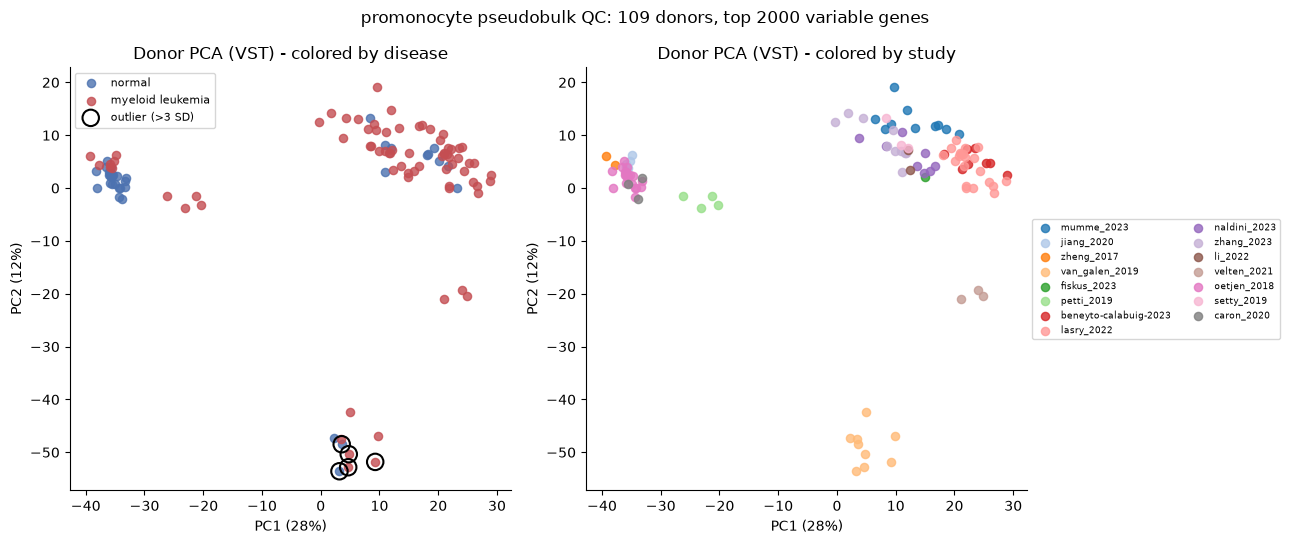

In [64]:
from sklearn.decomposition import PCA

gene_var = vst_df.var(axis=0).sort_values(ascending=False)
top_var_genes = gene_var.index[:2000]
Xc = vst_df[top_var_genes].values
Xc = Xc - Xc.mean(axis=0)
pca = PCA(n_components=10, random_state=0)
pcs = pca.fit_transform(Xc)
print("Variance explained by PC1-5:", np.round(pca.explained_variance_ratio_[:5], 3))

pc_df = pd.DataFrame(pcs[:, :2], columns=["PC1", "PC2"], index=vst_df.index).join(meta)
z1 = (pc_df["PC1"] - pc_df["PC1"].mean()) / pc_df["PC1"].std()
z2 = (pc_df["PC2"] - pc_df["PC2"].mean()) / pc_df["PC2"].std()
pc_df["outlier"] = (z1.abs() > 3) | (z2.abs() > 3)
outlier_donors = pc_df.index[pc_df["outlier"]].tolist()
print(f"Donors flagged as PCA outliers (>3 SD on PC1 or PC2): {outlier_donors}")

fig, axes = plt.subplots(1, 2, figsize=(13, 5.5))
disease_colors = {"normal": "#4c72b0", "myeloid leukemia": "#c44e52"}
for d, c in disease_colors.items():
    m = pc_df["disease"].astype(str) == d
    axes[0].scatter(pc_df.loc[m, "PC1"], pc_df.loc[m, "PC2"], s=35, alpha=0.8, color=c, label=d)
axes[0].scatter(pc_df.loc[pc_df["outlier"], "PC1"], pc_df.loc[pc_df["outlier"], "PC2"],
                s=140, facecolors="none", edgecolors="black", linewidths=1.5, label="outlier (>3 SD)")
axes[0].set_xlabel(f"PC1 ({pca.explained_variance_ratio_[0]*100:.0f}%)")
axes[0].set_ylabel(f"PC2 ({pca.explained_variance_ratio_[1]*100:.0f}%)")
axes[0].set_title("Donor PCA (VST) - colored by disease")
axes[0].legend(fontsize=8)

study_cats = pc_df["Study"].astype(str).unique()
study_colors2 = dict(zip(study_cats, sns.color_palette("tab20", len(study_cats))))
for s in study_cats:
    m = pc_df["Study"].astype(str) == s
    axes[1].scatter(pc_df.loc[m, "PC1"], pc_df.loc[m, "PC2"], s=35, alpha=0.8, color=study_colors2[s], label=s)
axes[1].set_xlabel(f"PC1 ({pca.explained_variance_ratio_[0]*100:.0f}%)")
axes[1].set_ylabel(f"PC2 ({pca.explained_variance_ratio_[1]*100:.0f}%)")
axes[1].set_title("Donor PCA (VST) - colored by study")
axes[1].legend(fontsize=6.5, ncol=2, loc="center left", bbox_to_anchor=(1.0, 0.5))

fig.suptitle(f"{LABEL} pseudobulk QC: {len(pc_df)} donors, top {len(top_var_genes)} variable genes")
fig.tight_layout()
plt.show()

In [65]:
mitocarta = pd.read_excel(os.path.join(DATA_DIR, "Human.MitoCarta3.0.xls"), sheet_name="A Human MitoCarta3.0")
mitocarta_genes = set(mitocarta["Symbol"].dropna().astype(str))

MT_GENES_ALL = sorted([g for g in gene_names if g.upper().startswith("MT-")])
mito_genes = sorted([g for g in mitocarta_genes if g in deseq_res.index])
n_mt_in_set = sum(g.upper().startswith("MT-") for g in mito_genes)
print(f"MitoCarta3.0: {len(mitocarta_genes)} genes total")
print(f"MitoCarta genes tested in this DE analysis: {len(mito_genes)} "
      f"({len(mito_genes) - n_mt_in_set} nuclear-encoded + {n_mt_in_set} mtDNA-encoded MT- genes)")

mito_table = deseq_res.loc[mito_genes].sort_values("padj")
mito_table["encoded_by"] = np.where(mito_table.index.str.upper().str.startswith("MT-"), "mtDNA", "nuclear")
display(mito_table.head(15)[["baseMean", "log2FoldChange", "lfcSE", "pvalue", "padj", "encoded_by"]])

MitoCarta3.0: 1136 genes total
MitoCarta genes tested in this DE analysis: 1034 (1021 nuclear-encoded + 13 mtDNA-encoded MT- genes)


,baseMean,log2FoldChange,lfcSE,pvalue,padj,encoded_by
BBC3,6.602204,2.304267,0.615077,0.000002,0.001781,nuclear
MCUB,30.144320,-0.963429,0.279941,0.000017,0.005247,nuclear
BNIP3,11.034434,1.547948,0.454132,0.000030,0.006897,nuclear
SDSL,7.935750,1.394785,0.456820,0.000038,0.008202,nuclear
RPUSD4,12.042092,0.682481,0.317236,0.000167,0.019930,nuclear
PDP1,9.698372,-0.000021,0.000747,0.000258,0.025877,nuclear
MRPS30,27.813404,0.510192,0.240915,0.000322,0.031446,nuclear
MCRIP2,30.894508,0.579967,0.226006,0.000343,0.033202,nuclear
PHYH,13.805100,0.700051,0.423365,0.000482,0.040460,nuclear
MRPL33,346.631740,0.570067,0.310102,0.000488,0.040460,nuclear


Mitochondrial genes passing padj<0.05 & |log2FC|>0.5: 9
Mitochondrial genes with padj<0.05 (any effect size): 10


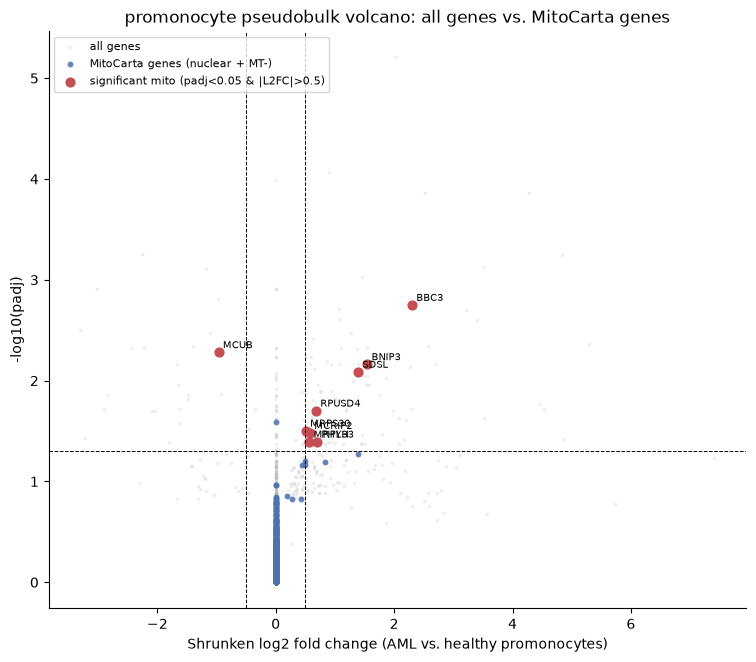

In [66]:
sig_mito = mito_table[(mito_table["padj"] < 0.05) & (mito_table["log2FoldChange"].abs() > 0.5)]
print(f"Mitochondrial genes passing padj<0.05 & |log2FC|>0.5: {len(sig_mito)}")
print(f"Mitochondrial genes with padj<0.05 (any effect size): {(mito_table['padj'] < 0.05).sum()}")
if len(sig_mito) == 0:
    print("None reach both thresholds simultaneously. Closest candidates (by padj):")
    print(mito_table.head(5)[["baseMean", "log2FoldChange", "padj", "encoded_by"]])

fig, ax = plt.subplots(figsize=(9, 7.5))
plot_df = deseq_res.dropna(subset=["padj"]).copy()
plot_df["neglog10padj"] = -np.log10(plot_df["padj"].clip(lower=1e-300))

ax.scatter(plot_df["log2FoldChange"], plot_df["neglog10padj"],
           s=6, alpha=0.25, color="#bbbbbb", linewidths=0, label="all genes")

mito_plot = plot_df.loc[plot_df.index.isin(mito_genes)]
ax.scatter(mito_plot["log2FoldChange"], mito_plot["neglog10padj"],
           s=18, alpha=0.85, color="#4c72b0", linewidths=0, label="MitoCarta genes (nuclear + MT-)")

if len(sig_mito) > 0:
    sig_plot = plot_df.loc[plot_df.index.isin(sig_mito.index)]
    ax.scatter(sig_plot["log2FoldChange"], sig_plot["neglog10padj"],
               s=40, color="#c44e52", label="significant mito (padj<0.05 & |L2FC|>0.5)")
    for gene, row in sig_plot.iterrows():
        ax.annotate(gene, (row["log2FoldChange"], row["neglog10padj"]), fontsize=7,
                    xytext=(3, 3), textcoords="offset points")
else:
    top5 = mito_table.head(5)
    top5_plot = plot_df.loc[plot_df.index.isin(top5.index)]
    ax.scatter(top5_plot["log2FoldChange"], top5_plot["neglog10padj"],
               s=40, color="#dd8452", label="top 5 mito genes (by padj, n.s.)")
    for gene, row in top5_plot.iterrows():
        ax.annotate(gene, (row["log2FoldChange"], row["neglog10padj"]), fontsize=7,
                    xytext=(3, 3), textcoords="offset points")

ax.axhline(-np.log10(0.05), color="black", lw=0.7, ls="--")
ax.axvline(0.5, color="black", lw=0.7, ls="--")
ax.axvline(-0.5, color="black", lw=0.7, ls="--")
ax.set_xlabel(f"Shrunken log2 fold change (AML vs. healthy {LABEL}s)")
ax.set_ylabel("-log10(padj)")
ax.set_title(f"{LABEL} pseudobulk volcano: all genes vs. MitoCarta genes")
ax.legend(fontsize=8, loc="upper left")
plt.show()

In [67]:
import gseapy as gp

GSEA_CACHE = os.path.join(RESULTS_DIR, f"{PFX}_gsea_results_mt_included.parquet")

mitopathways = pd.read_excel(os.path.join(DATA_DIR, "Human.MitoCarta3.0.xls"), sheet_name="C MitoPathways")
mitopathways = mitopathways.dropna(subset=["MitoPathway"])

gene_sets = {}
for _, row in mitopathways.iterrows():
    gene_sets[row["MitoPathway"]] = [g.strip() for g in str(row["Genes"]).split(",") if g.strip()]

gene_rank = deseq_res["log2FoldChange"].dropna().sort_values(ascending=False)
print(f"Ranked gene list (nuclear + MT-): {len(gene_rank)} genes; {len(gene_sets)} MitoPathway gene sets")

if os.path.exists(GSEA_CACHE):
    print("Loading cached GSEA results...")
    gsea_res = pd.read_parquet(GSEA_CACHE)
else:
    prerank = gp.prerank(
        rnk=gene_rank, gene_sets=gene_sets, min_size=5, max_size=500,
        permutation_num=1000, seed=0, threads=4, no_plot=True, outdir=None,
    )
    gsea_res = prerank.res2d.copy()
    gsea_res["NES"] = gsea_res["NES"].astype(float)
    gsea_res["FDR q-val"] = gsea_res["FDR q-val"].astype(float)
    gsea_res.to_parquet(GSEA_CACHE)

print(f"Pathways tested: {len(gsea_res)}")
print(f"Pathways with FDR q<0.05: {(gsea_res['FDR q-val'] < 0.05).sum()}")
sig_pathways = gsea_res[gsea_res["FDR q-val"] < 0.25].sort_values("NES")
print(f"Significant pathways (FDR q<0.25, standard GSEA convention): {len(sig_pathways)}")
sig_pathways[["Term", "NES", "NOM p-val", "FDR q-val"]]

Ranked gene list (nuclear + MT-): 18778 genes; 149 MitoPathway gene sets
Loading cached GSEA results...
Pathways tested: 113
Pathways with FDR q<0.05: 0
Significant pathways (FDR q<0.25, standard GSEA convention): 0


,Term,NES,NOM p-val,FDR q-val


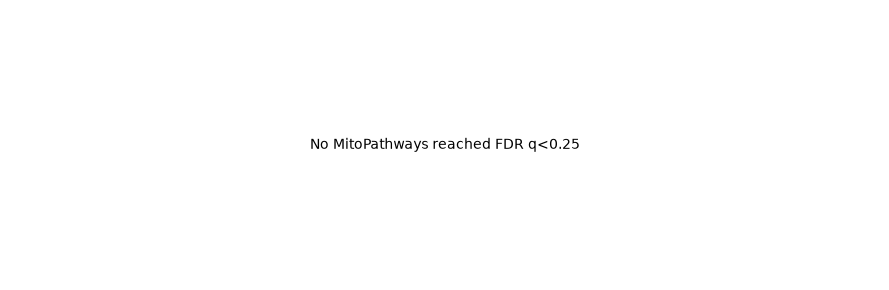

In [68]:
fig, ax = plt.subplots(figsize=(9, max(3, 0.35 * len(sig_pathways) + 1)))
if len(sig_pathways) > 0:
    colors_bar = ["#c44e52" if v > 0 else "#4c72b0" for v in sig_pathways["NES"]]
    ax.barh(sig_pathways["Term"], sig_pathways["NES"], color=colors_bar)
    ax.axvline(0, color="black", lw=0.8)
    ax.set_xlabel("Normalized Enrichment Score (NES)")
    ax.set_title(f"Significant MitoPathways (FDR q<0.25)\npositive NES = enriched in AML {LABEL}s")
else:
    ax.text(0.5, 0.5, "No MitoPathways reached FDR q<0.25", ha="center", va="center")
    ax.axis("off")
fig.tight_layout()
plt.show()

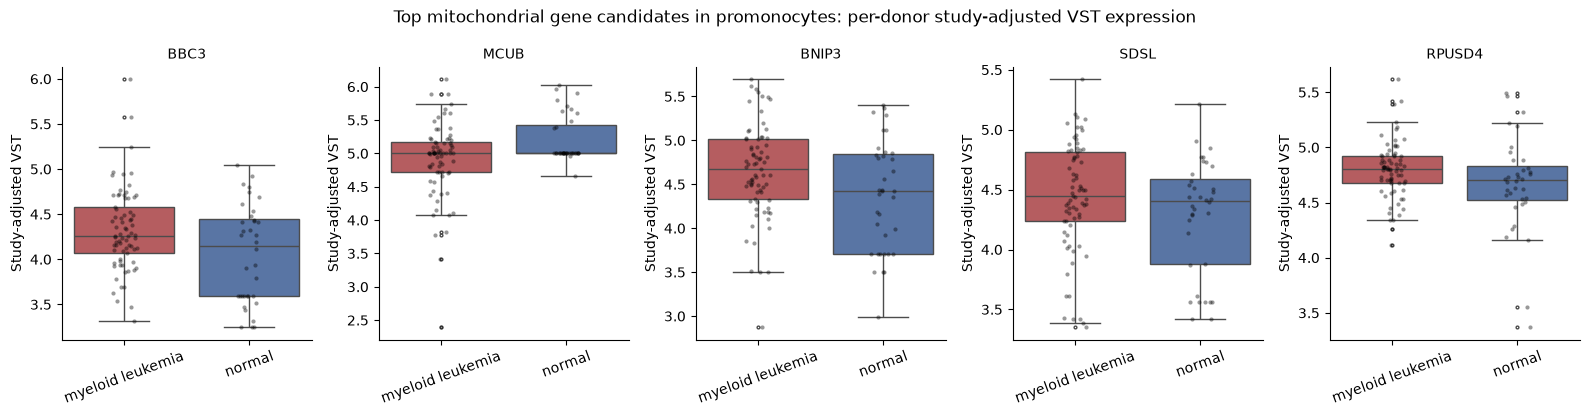

In [69]:
def study_adjusted(gene_vals, study_labels):
    df_tmp = pd.DataFrame({"v": gene_vals, "Study": study_labels})
    study_mean = df_tmp.groupby("Study")["v"].transform("mean")
    return df_tmp["v"] - study_mean + df_tmp["v"].mean()

top_genes_for_plot = (sig_mito.index.tolist() if len(sig_mito) > 0 else mito_table.head(5).index.tolist())[:5]

fig, axes = plt.subplots(1, len(top_genes_for_plot), figsize=(3.2 * len(top_genes_for_plot), 4.2), squeeze=False)
axes = axes[0]
for ax, gene in zip(axes, top_genes_for_plot):
    if use_study_covariate:
        vst_plot_vals = study_adjusted(vst_df[gene], meta["Study"])
        ylabel = "Study-adjusted VST"
    else:
        vst_plot_vals = vst_df[gene]
        ylabel = "VST"
    df_g = pd.DataFrame({ylabel: vst_plot_vals, "disease": meta["disease"].astype(str)})
    sns.boxplot(data=df_g, x="disease", y=ylabel, palette=disease_colors, ax=ax, fliersize=2)
    sns.stripplot(data=df_g, x="disease", y=ylabel, color="black", alpha=0.4, size=3, ax=ax)
    ax.set_title(gene, fontsize=10)
    ax.set_xlabel("")
    ax.tick_params(axis="x", rotation=20)
fig.suptitle(f"Top mitochondrial gene candidates in {LABEL}s: per-donor "
             + ("study-adjusted " if use_study_covariate else "") + "VST expression")
fig.tight_layout()
plt.show()

Top pathway (by |NES|, among those with >=5 leading-edge genes): mt-tRNA synthetases  (NES=-1.21, FDR q=1.000)
Leading-edge genes plotted: 8


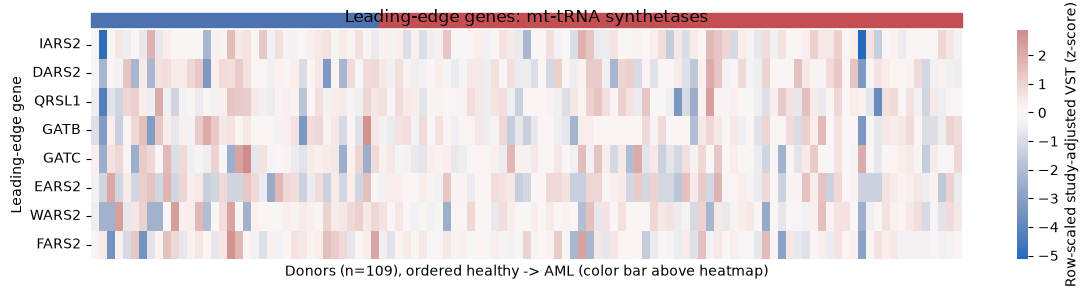

In [70]:
MIN_LEADING_EDGE = 5   # a heatmap needs several genes; skip pathways whose leading edge is (almost) empty

def _enough_genes(df):
    n = df["Lead_genes"].map(lambda s: sum(g in vst_df.columns for g in str(s).split(";")))
    return df[n >= MIN_LEADING_EDGE]

cand_ok = _enough_genes(sig_pathways if len(sig_pathways) > 0 else gsea_res)
if len(cand_ok) == 0:
    cand_ok = _enough_genes(gsea_res)   # none of the significant ones qualifies: use any tested pathway
pool = cand_ok if len(cand_ok) > 0 else gsea_res
top_pathway = pool.loc[pool["NES"].abs().idxmax()]

top_pathway_name = top_pathway["Term"]
leading_edge_genes = [g for g in str(top_pathway["Lead_genes"]).split(";") if g in vst_df.columns]
print(f"Top pathway (by |NES|, among those with >={MIN_LEADING_EDGE} leading-edge genes): "
      f"{top_pathway_name}  (NES={top_pathway['NES']:.2f}, FDR q={top_pathway['FDR q-val']:.3f})")
print(f"Leading-edge genes plotted: {len(leading_edge_genes)}")

if len(leading_edge_genes) >= 2:
    order = meta.sort_values("disease").index
    if use_study_covariate:
        hm_source = pd.DataFrame(
            {g: study_adjusted(vst_df[g], meta["Study"]) for g in leading_edge_genes},
            index=vst_df.index,
        )
        cbar_label = "Row-scaled study-adjusted VST (z-score)"
    else:
        hm_source = vst_df[leading_edge_genes]
        cbar_label = "Row-scaled VST (z-score)"
    hm_data = hm_source.loc[order, leading_edge_genes].T
    hm_z = hm_data.sub(hm_data.mean(axis=1), axis=0).div(hm_data.std(axis=1), axis=0)

    fig, ax = plt.subplots(figsize=(12, max(3, 0.28 * len(leading_edge_genes))))
    sns.heatmap(hm_z, cmap="vlag", center=0, ax=ax,
                cbar_kws={"label": cbar_label},
                xticklabels=False, yticklabels=True)
    disease_track = meta.loc[order, "disease"].astype(str).map({"normal": 0, "myeloid leukemia": 1}).values
    for i, v in enumerate(disease_track):
        ax.add_patch(plt.Rectangle((i, -0.6), 1, 0.5,
                                    color=disease_colors["myeloid leukemia"] if v else disease_colors["normal"],
                                    clip_on=False))
    ax.set_ylabel("Leading-edge gene")
    ax.set_xlabel(f"Donors (n={len(order)}), ordered healthy -> AML (color bar above heatmap)")
    ax.set_title(f"Leading-edge genes: {top_pathway_name}")
    fig.tight_layout()
    plt.show()
else:
    print("Not enough leading-edge genes with VST values to plot a heatmap.")

RESULTS[PFX] = dict(label=LABEL, deseq=deseq_res, gsea=gsea_res, mito_table=mito_table,
                    mito_genes=mito_genes, meta=meta)

In [71]:
CT, LABEL, PFX = "erythroid lineage cell", "erythroid cell", "eryth"
if "RESULTS" not in globals():
    RESULTS = {}

MIN_CELLS_PER_DONOR = 20
MIN_DONORS_PER_GROUP = 5

is_ct = (obs["cell_type"] == CT)
print(f"{LABEL}s before any donor-level filter: {is_ct.sum():,} cells, "
      f"{obs.loc[is_ct, 'donor_id'].nunique()} donors, "
      f"{obs.loc[is_ct, 'Study'].nunique()} studies")

ct_per_donor = (
    obs.loc[is_ct].groupby(["donor_id", "disease"], observed=True).size()
    .reset_index(name="n_cells_ct")
)
qualifying = ct_per_donor[ct_per_donor["n_cells_ct"] >= MIN_CELLS_PER_DONOR]
dropped = ct_per_donor[ct_per_donor["n_cells_ct"] < MIN_CELLS_PER_DONOR]
zero_donors = obs.loc[~obs["donor_id"].isin(ct_per_donor["donor_id"]), "donor_id"].nunique()

n_per_group = qualifying.groupby("disease", observed=True)["donor_id"].nunique()
assert (n_per_group >= MIN_DONORS_PER_GROUP).all(), "A disease group has <5 qualifying donors!"

print(f"\nDonors with ZERO {LABEL}s (dropped outright, mostly CD34+-sorted studies): {zero_donors}")
print(f"Donors with 1-{MIN_CELLS_PER_DONOR - 1} {LABEL}s (dropped, too few cells): "
      f"{dropped['donor_id'].nunique()}  ({dropped.groupby('disease', observed=True)['donor_id'].nunique().to_dict()})")
print(f"\nDonors KEPT (>={MIN_CELLS_PER_DONOR} {LABEL}s), per group:")
print(n_per_group)
print(f"\nTotal donors kept: {len(qualifying)} / {obs['donor_id'].nunique()} in the full atlas")
print(f"Total {LABEL}s kept for pseudobulk: {qualifying['n_cells_ct'].sum():,} "
      f"(of {is_ct.sum():,} {LABEL}s overall)")

qualifying_donors = qualifying["donor_id"].tolist()

studies_dropped_entirely = sorted(
    set(obs["Study"].unique())
    - set(obs.loc[obs["donor_id"].isin(qualifying_donors), "Study"].unique())
)
print(f"\nStudies with ZERO qualifying donors (effectively fully excluded): {studies_dropped_entirely}")

erythroid cells before any donor-level filter: 39,276 cells, 183 donors, 18 studies

Donors with ZERO erythroid cells (dropped outright, mostly CD34+-sorted studies): 27
Donors with 1-19 erythroid cells (dropped, too few cells): 70  ({'myeloid leukemia': 61, 'normal': 9})

Donors KEPT (>=20 erythroid cells), per group:
disease
myeloid leukemia    71
normal              42
Name: donor_id, dtype: int64

Total donors kept: 113 / 210 in the full atlas
Total erythroid cells kept for pseudobulk: 38,793 (of 39,276 erythroid cells overall)

Studies with ZERO qualifying donors (effectively fully excluded): ['fiskus_2023', 'human_cell_atlas', 'pei_2020', 'stetson_2021', 'zhai_2022']


In [72]:
PB_CACHE = os.path.join(RESULTS_DIR, f"{PFX}_pseudobulk_counts.parquet")
PB_META_CACHE = os.path.join(RESULTS_DIR, f"{PFX}_pseudobulk_donor_meta.parquet")

if os.path.exists(PB_CACHE) and os.path.exists(PB_META_CACHE):
    print(f"Loading cached {LABEL} pseudobulk matrix...")
    pb_counts = pd.read_parquet(PB_CACHE)
    donor_meta = pd.read_parquet(PB_META_CACHE)
else:
    donor_to_qidx = {d: i for i, d in enumerate(qualifying_donors)}
    n_donors_pb = len(qualifying_donors)
    donor_codes_arr = obs["donor_id"].values
    is_ct_arr = is_ct.values
    assign = np.full(n_cells, -1, dtype=np.int64)
    mask_keep_cell = is_ct_arr & np.isin(donor_codes_arr, qualifying_donors)
    keep_rows = np.where(mask_keep_cell)[0]
    assign[keep_rows] = np.array([donor_to_qidx[d] for d in donor_codes_arr[keep_rows]])

    t0 = time.time()
    pseudobulk = np.zeros((n_donors_pb, n_genes), dtype=np.float64)
    with h5py.File(H5_PATH, "r") as f:
        indptr = f["X/indptr"][:]
        raw_data_ds, raw_idx_ds = f["raw/X/data"], f["raw/X/indices"]
        for start in range(0, n_cells, CHUNK_ROWS):
            end = min(start + CHUNK_ROWS, n_cells)
            chunk_assign = assign[start:end]
            if not np.any(chunk_assign >= 0):
                continue
            s, e = int(indptr[start]), int(indptr[end])
            local_indptr = indptr[start:end + 1] - indptr[start]
            raw_chunk = sparse.csr_matrix(
                (raw_data_ds[s:e], raw_idx_ds[s:e], local_indptr),
                shape=(end - start, n_genes))
            valid = chunk_assign >= 0
            rows = np.where(valid)[0]
            indicator = sparse.csr_matrix(
                (np.ones(len(rows)), (chunk_assign[valid], rows)),
                shape=(n_donors_pb, end - start))
            pseudobulk += indicator.dot(raw_chunk).toarray()
    print(f"Pseudobulk scan done in {time.time()-t0:.0f}s")

    pb_counts = pd.DataFrame(pseudobulk, index=qualifying_donors, columns=gene_names)
    donor_meta = (
        obs[obs["donor_id"].isin(qualifying_donors)]
        .drop_duplicates("donor_id").set_index("donor_id")
        .loc[qualifying_donors, ["disease", "Study", "Fine Age Group", "Main Age Group", "sex", "ELN Risk Group"]]
    )
    pb_counts.to_parquet(PB_CACHE)
    donor_meta.to_parquet(PB_META_CACHE)

print(f"Pseudobulk matrix: {pb_counts.shape[0]} donors x {pb_counts.shape[1]} genes")
donor_meta["disease"].value_counts()

Loading cached erythroid cell pseudobulk matrix...


Pseudobulk matrix: 113 donors x 21588 genes


disease
myeloid leukemia    71
normal              42
Name: count, dtype: int64

In [73]:
counts_all = pb_counts.round().astype(int)
gene_sums = counts_all.sum(axis=0)
counts_filt = counts_all.loc[:, gene_sums >= 10]
print(f"Genes after near-empty filter (sum>=10 across donors): {counts_filt.shape[1]} / {counts_all.shape[1]}")

meta = donor_meta.copy()
meta["disease"] = pd.Categorical(meta["disease"].astype(str), categories=["normal", "myeloid leukemia"])
meta["Study"] = meta["Study"].astype(str)

design_full = pd.get_dummies(meta[["Study", "disease"]], drop_first=True).astype(float)
design_full.insert(0, "intercept", 1.0)
rank = np.linalg.matrix_rank(design_full.values)
use_study_covariate = (rank == design_full.shape[1])
print(f"~ Study + disease design matrix: {design_full.shape}, rank {rank} "
      f"-> {'FULL RANK, using Study as covariate' if use_study_covariate else 'RANK DEFICIENT, falling back to ~ disease'}")

DESIGN_FORMULA = "~Study+disease" if use_study_covariate else "~disease"

Genes after near-empty filter (sum>=10 across donors): 20074 / 21588
~ Study + disease design matrix: (113, 16), rank 16 -> FULL RANK, using Study as covariate


In [74]:
from pydeseq2.dds import DeseqDataSet
from pydeseq2.ds import DeseqStats

DESEQ_CACHE = os.path.join(RESULTS_DIR, f"{PFX}_deseq_results.parquet")
VST_CACHE = os.path.join(RESULTS_DIR, f"{PFX}_vst.parquet")

if os.path.exists(DESEQ_CACHE) and os.path.exists(VST_CACHE):
    print("Loading cached DESeq2 results + VST matrix...")
    deseq_res = pd.read_parquet(DESEQ_CACHE)
    vst_df = pd.read_parquet(VST_CACHE)
else:
    dds = DeseqDataSet(counts=counts_filt, metadata=meta, design=DESIGN_FORMULA,
                        refit_cooks=True, quiet=True)
    dds.deseq2()

    dds.vst(use_design=False)
    vst_df = pd.DataFrame(dds.layers["vst_counts"], index=dds.obs_names, columns=dds.var_names)

    ds = DeseqStats(dds, contrast=["disease", "myeloid leukemia", "normal"], quiet=True)
    ds.summary()
    ds.lfc_shrink(coeff="disease[T.myeloid leukemia]")
    deseq_res = ds.results_df.copy()

    deseq_res.to_parquet(DESEQ_CACHE)
    vst_df.to_parquet(VST_CACHE)

print(f"DESeq2 results: {deseq_res.shape[0]} genes tested "
      f"(positive log2FC = higher in AML {LABEL}s vs. healthy {LABEL}s)")
print(f"Significant genes overall (padj < 0.05): {(deseq_res['padj'] < 0.05).sum()}")
deseq_res.sort_values("padj").head(10)

Loading cached DESeq2 results + VST matrix...


DESeq2 results: 20074 genes tested (positive log2FC = higher in AML erythroid cells vs. healthy erythroid cells)
Significant genes overall (padj < 0.05): 825


,baseMean,log2FoldChange,lfcSE,stat,pvalue,padj
GYPB,679.335621,3.513913,0.412526,8.239054,1.735773e-16,1.861616e-12
SLC4A1,1202.552652,3.979563,0.509196,7.868291,3.595194e-15,1.927923e-11
HBG2,6852.446355,5.671854,0.742030,7.717605,1.185356e-14,4.237648e-11
HBA2,115598.484928,4.126604,0.535062,7.281801,3.293937e-13,8.831868e-10
AQP1,63.888740,3.425548,0.495287,7.131273,9.944455e-13,2.133086e-09
OSBP2,102.102091,3.133658,0.459850,6.837256,8.072442e-12,1.442949e-08
HBD,14251.373494,2.714055,0.388547,6.785830,1.154208e-11,1.768412e-08
GYPE,74.935536,2.894575,0.421634,6.735217,1.636849e-11,2.194401e-08
HBA1,76039.831319,3.114910,0.487854,6.692494,2.193994e-11,2.614510e-08
HBG1,3371.940075,5.221122,0.730107,6.609668,3.851839e-11,4.131097e-08


Variance explained by PC1-5: [0.3   0.142 0.09  0.063 0.053]
Donors flagged as PCA outliers (>3 SD on PC1 or PC2): []


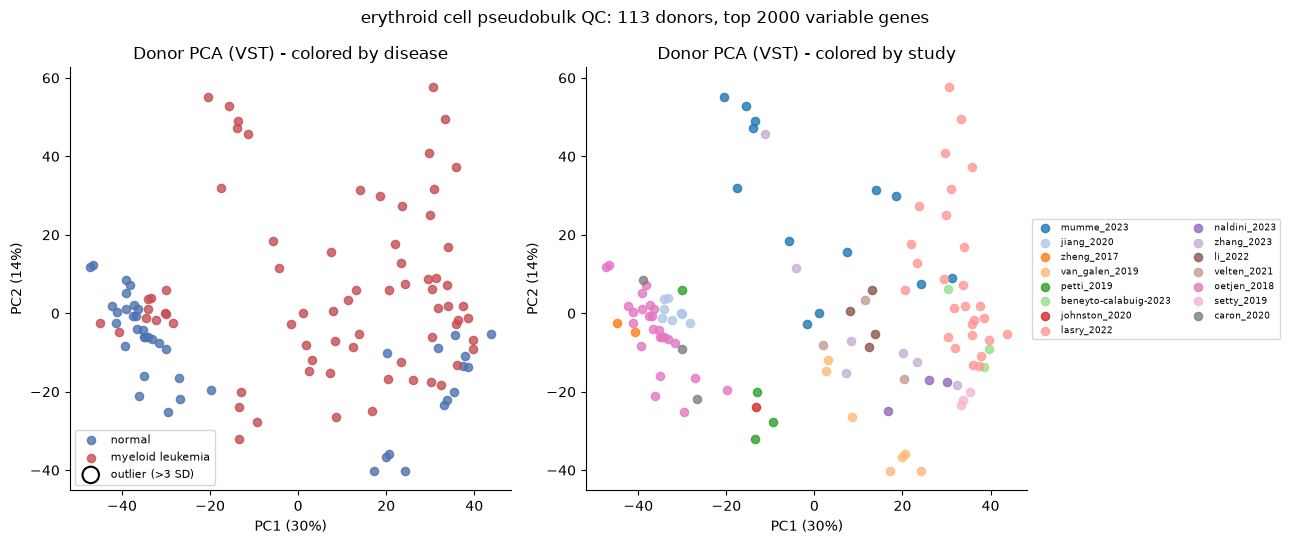

In [75]:
from sklearn.decomposition import PCA

gene_var = vst_df.var(axis=0).sort_values(ascending=False)
top_var_genes = gene_var.index[:2000]
Xc = vst_df[top_var_genes].values
Xc = Xc - Xc.mean(axis=0)
pca = PCA(n_components=10, random_state=0)
pcs = pca.fit_transform(Xc)
print("Variance explained by PC1-5:", np.round(pca.explained_variance_ratio_[:5], 3))

pc_df = pd.DataFrame(pcs[:, :2], columns=["PC1", "PC2"], index=vst_df.index).join(meta)
z1 = (pc_df["PC1"] - pc_df["PC1"].mean()) / pc_df["PC1"].std()
z2 = (pc_df["PC2"] - pc_df["PC2"].mean()) / pc_df["PC2"].std()
pc_df["outlier"] = (z1.abs() > 3) | (z2.abs() > 3)
outlier_donors = pc_df.index[pc_df["outlier"]].tolist()
print(f"Donors flagged as PCA outliers (>3 SD on PC1 or PC2): {outlier_donors}")

fig, axes = plt.subplots(1, 2, figsize=(13, 5.5))
disease_colors = {"normal": "#4c72b0", "myeloid leukemia": "#c44e52"}
for d, c in disease_colors.items():
    m = pc_df["disease"].astype(str) == d
    axes[0].scatter(pc_df.loc[m, "PC1"], pc_df.loc[m, "PC2"], s=35, alpha=0.8, color=c, label=d)
axes[0].scatter(pc_df.loc[pc_df["outlier"], "PC1"], pc_df.loc[pc_df["outlier"], "PC2"],
                s=140, facecolors="none", edgecolors="black", linewidths=1.5, label="outlier (>3 SD)")
axes[0].set_xlabel(f"PC1 ({pca.explained_variance_ratio_[0]*100:.0f}%)")
axes[0].set_ylabel(f"PC2 ({pca.explained_variance_ratio_[1]*100:.0f}%)")
axes[0].set_title("Donor PCA (VST) - colored by disease")
axes[0].legend(fontsize=8)

study_cats = pc_df["Study"].astype(str).unique()
study_colors2 = dict(zip(study_cats, sns.color_palette("tab20", len(study_cats))))
for s in study_cats:
    m = pc_df["Study"].astype(str) == s
    axes[1].scatter(pc_df.loc[m, "PC1"], pc_df.loc[m, "PC2"], s=35, alpha=0.8, color=study_colors2[s], label=s)
axes[1].set_xlabel(f"PC1 ({pca.explained_variance_ratio_[0]*100:.0f}%)")
axes[1].set_ylabel(f"PC2 ({pca.explained_variance_ratio_[1]*100:.0f}%)")
axes[1].set_title("Donor PCA (VST) - colored by study")
axes[1].legend(fontsize=6.5, ncol=2, loc="center left", bbox_to_anchor=(1.0, 0.5))

fig.suptitle(f"{LABEL} pseudobulk QC: {len(pc_df)} donors, top {len(top_var_genes)} variable genes")
fig.tight_layout()
plt.show()

In [76]:
mitocarta = pd.read_excel(os.path.join(DATA_DIR, "Human.MitoCarta3.0.xls"), sheet_name="A Human MitoCarta3.0")
mitocarta_genes = set(mitocarta["Symbol"].dropna().astype(str))

MT_GENES_ALL = sorted([g for g in gene_names if g.upper().startswith("MT-")])
mito_genes = sorted([g for g in mitocarta_genes if g in deseq_res.index])
n_mt_in_set = sum(g.upper().startswith("MT-") for g in mito_genes)
print(f"MitoCarta3.0: {len(mitocarta_genes)} genes total")
print(f"MitoCarta genes tested in this DE analysis: {len(mito_genes)} "
      f"({len(mito_genes) - n_mt_in_set} nuclear-encoded + {n_mt_in_set} mtDNA-encoded MT- genes)")

mito_table = deseq_res.loc[mito_genes].sort_values("padj")
mito_table["encoded_by"] = np.where(mito_table.index.str.upper().str.startswith("MT-"), "mtDNA", "nuclear")
display(mito_table.head(15)[["baseMean", "log2FoldChange", "lfcSE", "pvalue", "padj", "encoded_by"]])

MitoCarta3.0: 1136 genes total
MitoCarta genes tested in this DE analysis: 1039 (1026 nuclear-encoded + 13 mtDNA-encoded MT- genes)


,baseMean,log2FoldChange,lfcSE,pvalue,padj,encoded_by
SLC25A37,2557.849428,2.617183,0.453091,8.189184e-10,5.855266e-07,nuclear
ACSL6,65.293995,4.018493,0.872153,3.376488e-09,1.724421e-06,nuclear
ALAS2,2403.152797,2.491801,0.471075,1.328907e-08,4.750844e-06,nuclear
MGST3,579.792655,1.253099,0.289155,6.064809e-06,6.440106e-04,nuclear
RMDN1,44.153764,-0.549525,0.132930,8.634156e-06,8.654329e-04,nuclear
NADK2,26.520701,-0.766483,0.192057,1.624152e-05,1.451586e-03,nuclear
SLC25A39,1271.635042,1.472138,0.384436,2.200053e-05,1.747820e-03,nuclear
BPHL,9.782575,-1.002643,0.256886,2.359139e-05,1.846844e-03,nuclear
AMT,13.205310,-1.491850,0.332837,2.853384e-05,2.082095e-03,nuclear
COQ9,30.338673,-0.538160,0.134104,2.853781e-05,2.082095e-03,nuclear


Mitochondrial genes passing padj<0.05 & |log2FC|>0.5: 49
Mitochondrial genes with padj<0.05 (any effect size): 59


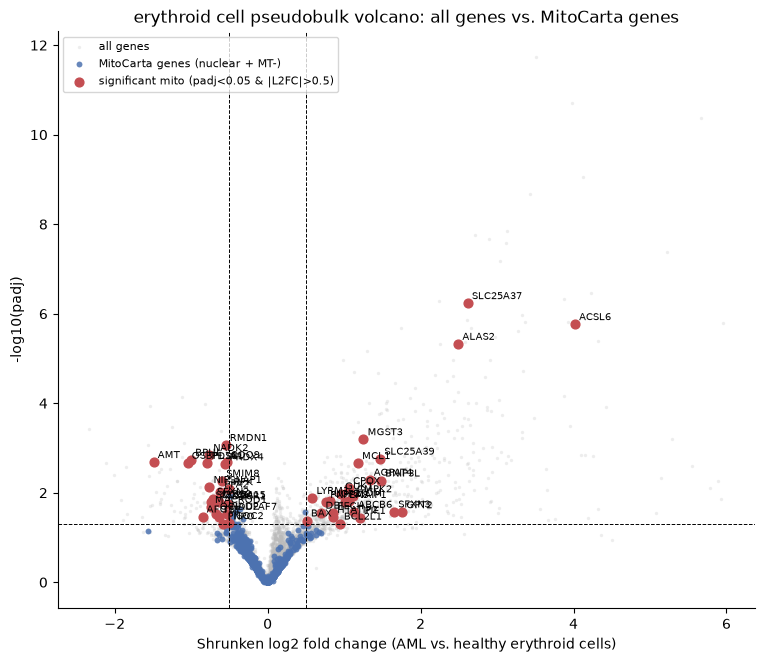

In [77]:
sig_mito = mito_table[(mito_table["padj"] < 0.05) & (mito_table["log2FoldChange"].abs() > 0.5)]
print(f"Mitochondrial genes passing padj<0.05 & |log2FC|>0.5: {len(sig_mito)}")
print(f"Mitochondrial genes with padj<0.05 (any effect size): {(mito_table['padj'] < 0.05).sum()}")
if len(sig_mito) == 0:
    print("None reach both thresholds simultaneously. Closest candidates (by padj):")
    print(mito_table.head(5)[["baseMean", "log2FoldChange", "padj", "encoded_by"]])

fig, ax = plt.subplots(figsize=(9, 7.5))
plot_df = deseq_res.dropna(subset=["padj"]).copy()
plot_df["neglog10padj"] = -np.log10(plot_df["padj"].clip(lower=1e-300))

ax.scatter(plot_df["log2FoldChange"], plot_df["neglog10padj"],
           s=6, alpha=0.25, color="#bbbbbb", linewidths=0, label="all genes")

mito_plot = plot_df.loc[plot_df.index.isin(mito_genes)]
ax.scatter(mito_plot["log2FoldChange"], mito_plot["neglog10padj"],
           s=18, alpha=0.85, color="#4c72b0", linewidths=0, label="MitoCarta genes (nuclear + MT-)")

if len(sig_mito) > 0:
    sig_plot = plot_df.loc[plot_df.index.isin(sig_mito.index)]
    ax.scatter(sig_plot["log2FoldChange"], sig_plot["neglog10padj"],
               s=40, color="#c44e52", label="significant mito (padj<0.05 & |L2FC|>0.5)")
    for gene, row in sig_plot.iterrows():
        ax.annotate(gene, (row["log2FoldChange"], row["neglog10padj"]), fontsize=7,
                    xytext=(3, 3), textcoords="offset points")
else:
    top5 = mito_table.head(5)
    top5_plot = plot_df.loc[plot_df.index.isin(top5.index)]
    ax.scatter(top5_plot["log2FoldChange"], top5_plot["neglog10padj"],
               s=40, color="#dd8452", label="top 5 mito genes (by padj, n.s.)")
    for gene, row in top5_plot.iterrows():
        ax.annotate(gene, (row["log2FoldChange"], row["neglog10padj"]), fontsize=7,
                    xytext=(3, 3), textcoords="offset points")

ax.axhline(-np.log10(0.05), color="black", lw=0.7, ls="--")
ax.axvline(0.5, color="black", lw=0.7, ls="--")
ax.axvline(-0.5, color="black", lw=0.7, ls="--")
ax.set_xlabel(f"Shrunken log2 fold change (AML vs. healthy {LABEL}s)")
ax.set_ylabel("-log10(padj)")
ax.set_title(f"{LABEL} pseudobulk volcano: all genes vs. MitoCarta genes")
ax.legend(fontsize=8, loc="upper left")
plt.show()

In [78]:
import gseapy as gp

GSEA_CACHE = os.path.join(RESULTS_DIR, f"{PFX}_gsea_results_mt_included.parquet")

mitopathways = pd.read_excel(os.path.join(DATA_DIR, "Human.MitoCarta3.0.xls"), sheet_name="C MitoPathways")
mitopathways = mitopathways.dropna(subset=["MitoPathway"])

gene_sets = {}
for _, row in mitopathways.iterrows():
    gene_sets[row["MitoPathway"]] = [g.strip() for g in str(row["Genes"]).split(",") if g.strip()]

gene_rank = deseq_res["log2FoldChange"].dropna().sort_values(ascending=False)
print(f"Ranked gene list (nuclear + MT-): {len(gene_rank)} genes; {len(gene_sets)} MitoPathway gene sets")

if os.path.exists(GSEA_CACHE):
    print("Loading cached GSEA results...")
    gsea_res = pd.read_parquet(GSEA_CACHE)
else:
    prerank = gp.prerank(
        rnk=gene_rank, gene_sets=gene_sets, min_size=5, max_size=500,
        permutation_num=1000, seed=0, threads=4, no_plot=True, outdir=None,
    )
    gsea_res = prerank.res2d.copy()
    gsea_res["NES"] = gsea_res["NES"].astype(float)
    gsea_res["FDR q-val"] = gsea_res["FDR q-val"].astype(float)
    gsea_res.to_parquet(GSEA_CACHE)

print(f"Pathways tested: {len(gsea_res)}")
print(f"Pathways with FDR q<0.05: {(gsea_res['FDR q-val'] < 0.05).sum()}")
sig_pathways = gsea_res[gsea_res["FDR q-val"] < 0.25].sort_values("NES")
print(f"Significant pathways (FDR q<0.25, standard GSEA convention): {len(sig_pathways)}")
sig_pathways[["Term", "NES", "NOM p-val", "FDR q-val"]]

Ranked gene list (nuclear + MT-): 20074 genes; 149 MitoPathway gene sets
Loading cached GSEA results...
Pathways tested: 114
Pathways with FDR q<0.05: 11
Significant pathways (FDR q<0.25, standard GSEA convention): 21


,Term,NES,NOM p-val,FDR q-val
0,Translation,-2.028661,0.000000,0.002385
1,Mitochondrial ribosome,-1.989961,0.000000,0.002385
2,Mitochondrial central dogma,-1.989891,0.000000,0.001590
3,Complex I,-1.821411,0.000000,0.002981
4,mtRNA metabolism,-1.800886,0.000000,0.004293
5,CI assembly factors,-1.774683,0.006309,0.007950
6,"Protein import, sorting and homeostasis",-1.763600,0.000000,0.008178
7,OXPHOS assembly factors,-1.756602,0.000000,0.007752
8,Protein import and sorting,-1.756313,0.000000,0.006890
9,mt-tRNA synthetases,-1.734694,0.000000,0.008825


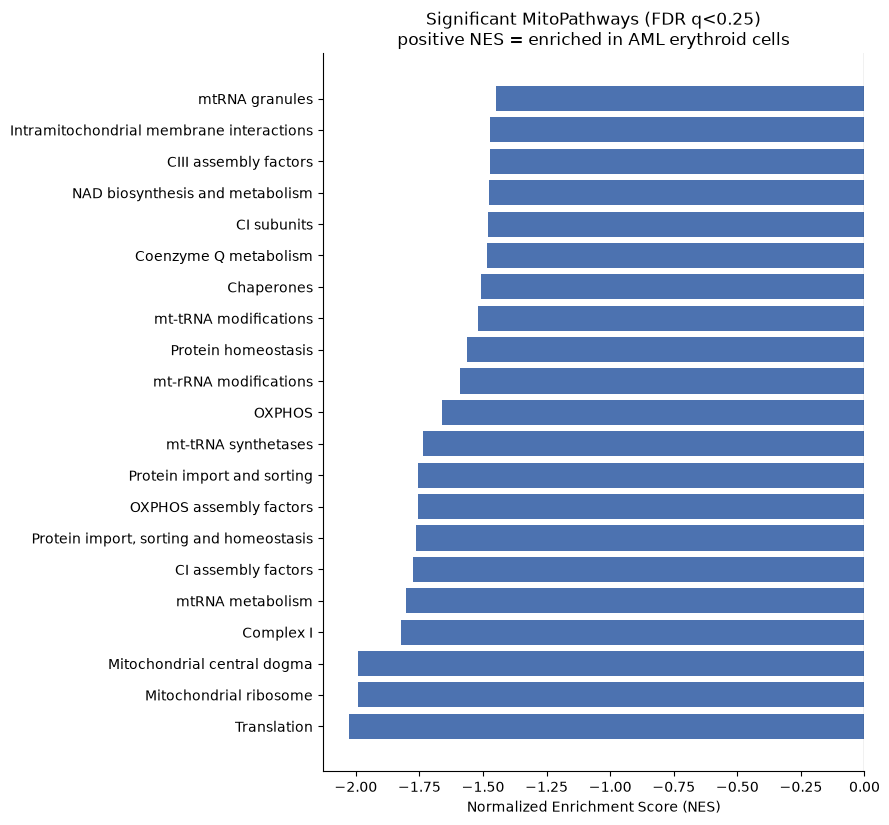

In [79]:
fig, ax = plt.subplots(figsize=(9, max(3, 0.35 * len(sig_pathways) + 1)))
if len(sig_pathways) > 0:
    colors_bar = ["#c44e52" if v > 0 else "#4c72b0" for v in sig_pathways["NES"]]
    ax.barh(sig_pathways["Term"], sig_pathways["NES"], color=colors_bar)
    ax.axvline(0, color="black", lw=0.8)
    ax.set_xlabel("Normalized Enrichment Score (NES)")
    ax.set_title(f"Significant MitoPathways (FDR q<0.25)\npositive NES = enriched in AML {LABEL}s")
else:
    ax.text(0.5, 0.5, "No MitoPathways reached FDR q<0.25", ha="center", va="center")
    ax.axis("off")
fig.tight_layout()
plt.show()

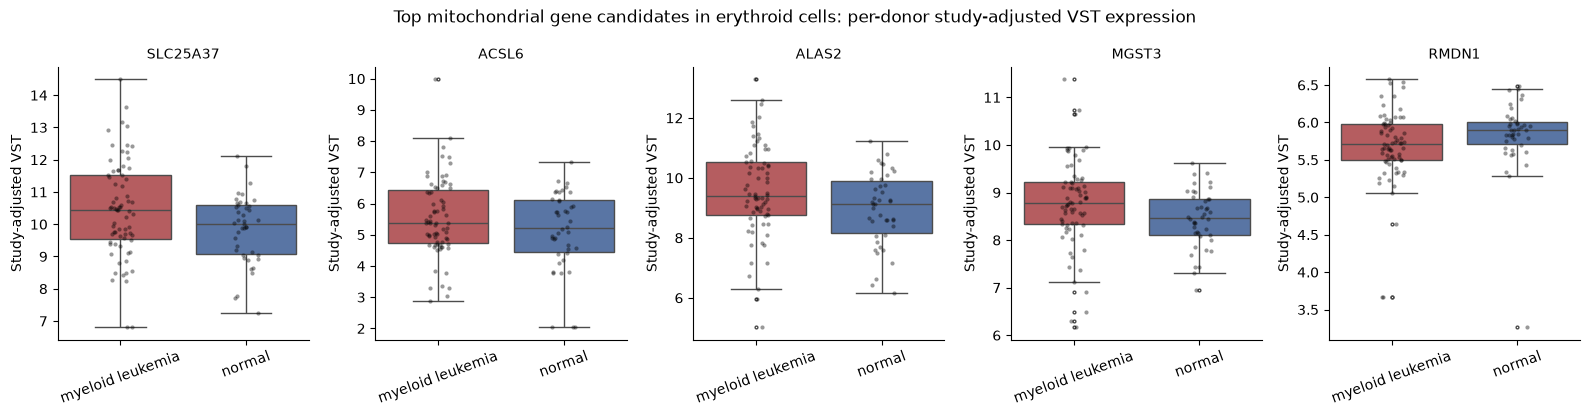

In [80]:
def study_adjusted(gene_vals, study_labels):
    df_tmp = pd.DataFrame({"v": gene_vals, "Study": study_labels})
    study_mean = df_tmp.groupby("Study")["v"].transform("mean")
    return df_tmp["v"] - study_mean + df_tmp["v"].mean()

top_genes_for_plot = (sig_mito.index.tolist() if len(sig_mito) > 0 else mito_table.head(5).index.tolist())[:5]

fig, axes = plt.subplots(1, len(top_genes_for_plot), figsize=(3.2 * len(top_genes_for_plot), 4.2), squeeze=False)
axes = axes[0]
for ax, gene in zip(axes, top_genes_for_plot):
    if use_study_covariate:
        vst_plot_vals = study_adjusted(vst_df[gene], meta["Study"])
        ylabel = "Study-adjusted VST"
    else:
        vst_plot_vals = vst_df[gene]
        ylabel = "VST"
    df_g = pd.DataFrame({ylabel: vst_plot_vals, "disease": meta["disease"].astype(str)})
    sns.boxplot(data=df_g, x="disease", y=ylabel, palette=disease_colors, ax=ax, fliersize=2)
    sns.stripplot(data=df_g, x="disease", y=ylabel, color="black", alpha=0.4, size=3, ax=ax)
    ax.set_title(gene, fontsize=10)
    ax.set_xlabel("")
    ax.tick_params(axis="x", rotation=20)
fig.suptitle(f"Top mitochondrial gene candidates in {LABEL}s: per-donor "
             + ("study-adjusted " if use_study_covariate else "") + "VST expression")
fig.tight_layout()
plt.show()

Top pathway (by |NES|, among those with >=5 leading-edge genes): Translation  (NES=-2.03, FDR q=0.002)
Leading-edge genes plotted: 104


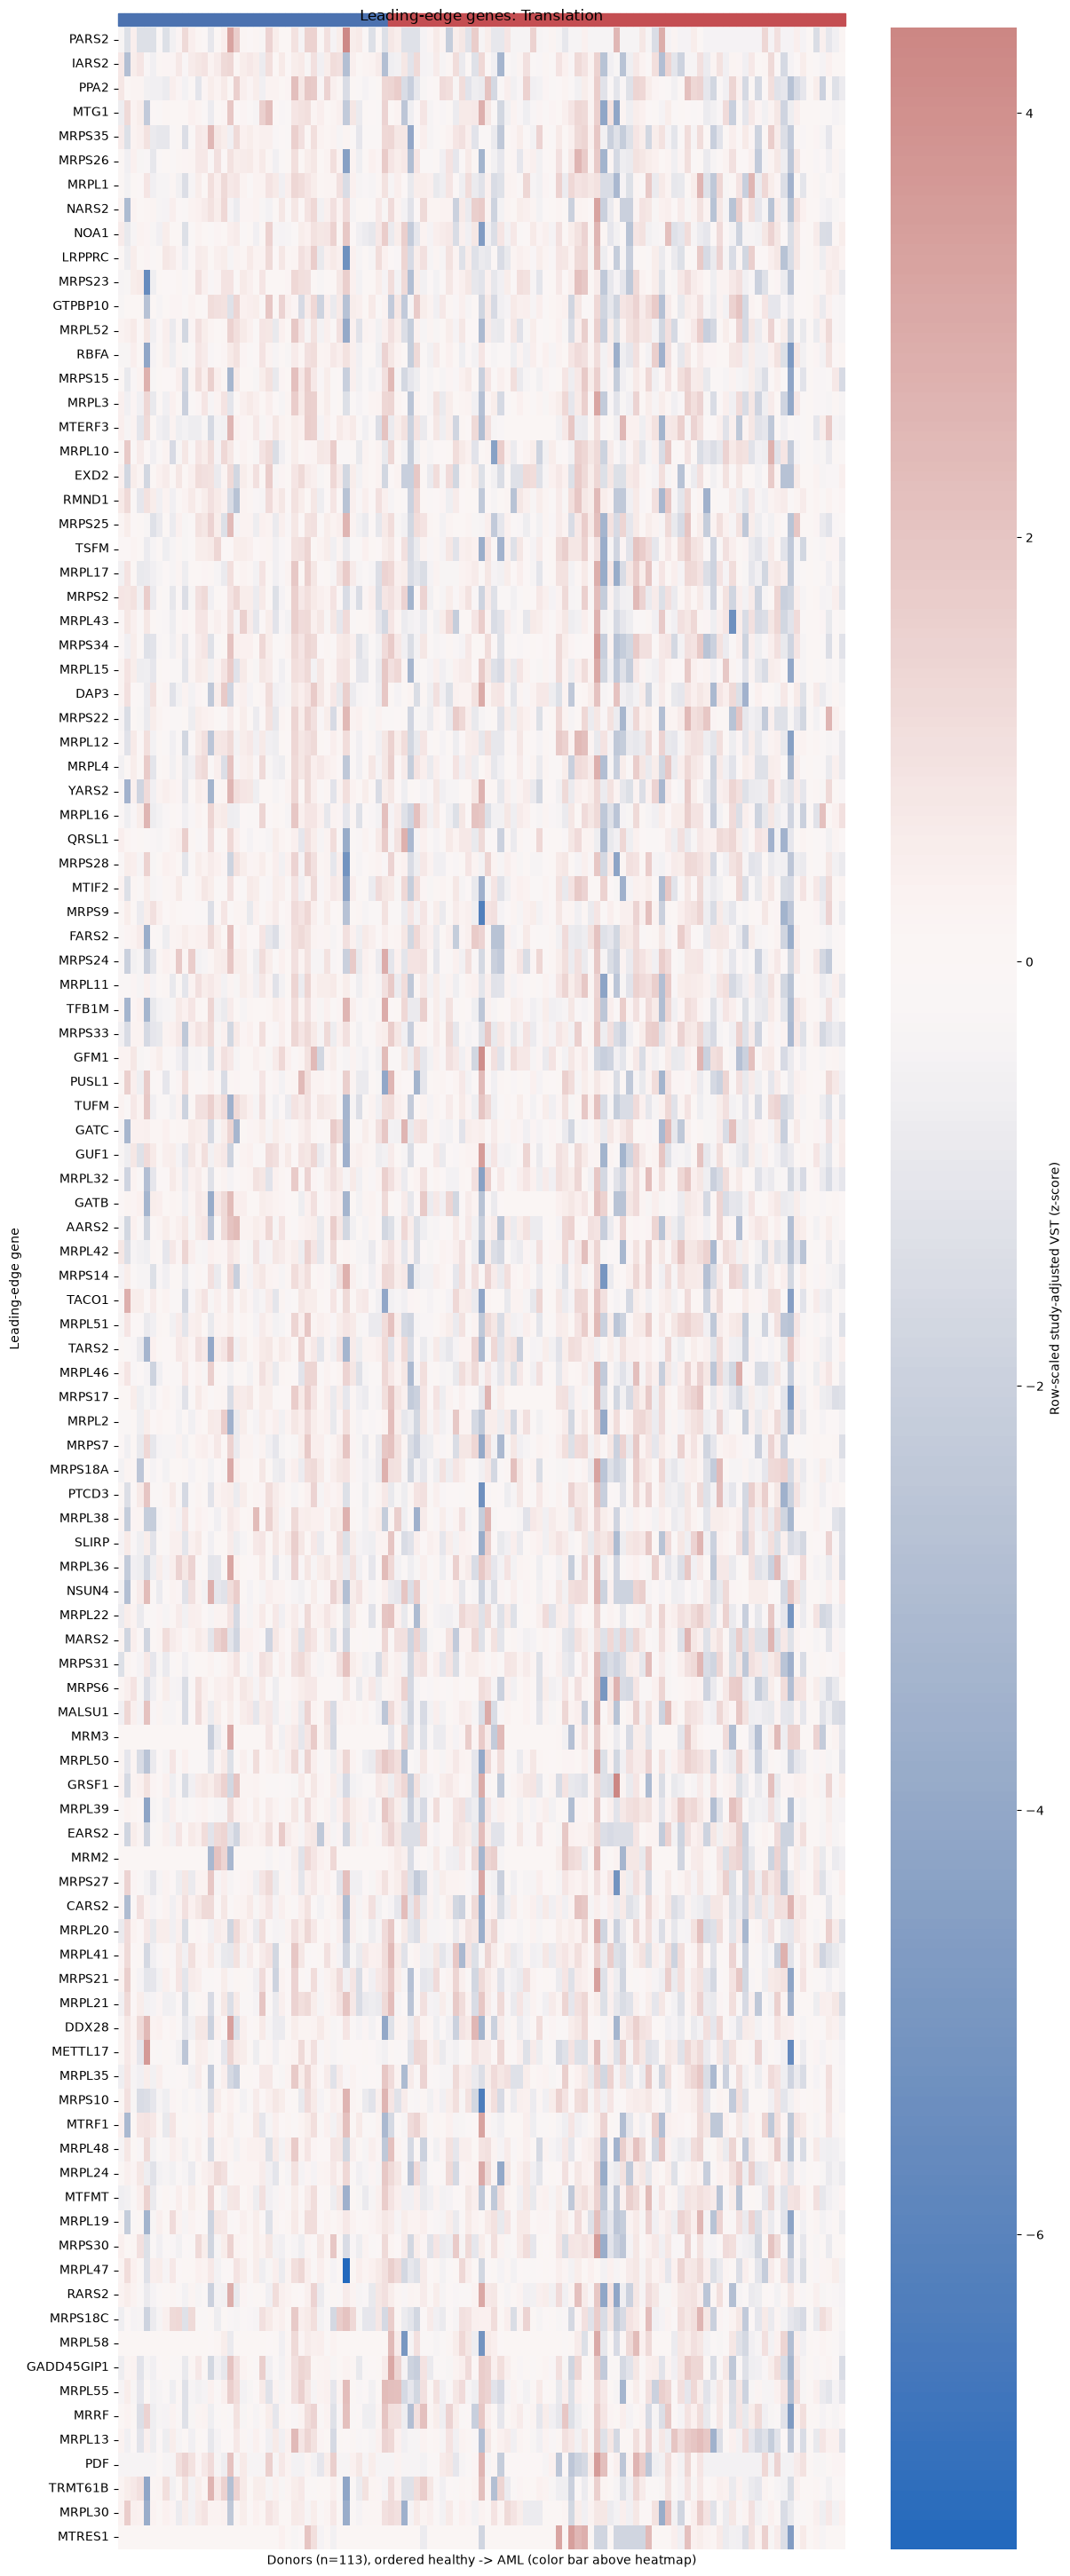

In [81]:
MIN_LEADING_EDGE = 5   # a heatmap needs several genes; skip pathways whose leading edge is (almost) empty

def _enough_genes(df):
    n = df["Lead_genes"].map(lambda s: sum(g in vst_df.columns for g in str(s).split(";")))
    return df[n >= MIN_LEADING_EDGE]

cand_ok = _enough_genes(sig_pathways if len(sig_pathways) > 0 else gsea_res)
if len(cand_ok) == 0:
    cand_ok = _enough_genes(gsea_res)   # none of the significant ones qualifies: use any tested pathway
pool = cand_ok if len(cand_ok) > 0 else gsea_res
top_pathway = pool.loc[pool["NES"].abs().idxmax()]

top_pathway_name = top_pathway["Term"]
leading_edge_genes = [g for g in str(top_pathway["Lead_genes"]).split(";") if g in vst_df.columns]
print(f"Top pathway (by |NES|, among those with >={MIN_LEADING_EDGE} leading-edge genes): "
      f"{top_pathway_name}  (NES={top_pathway['NES']:.2f}, FDR q={top_pathway['FDR q-val']:.3f})")
print(f"Leading-edge genes plotted: {len(leading_edge_genes)}")

if len(leading_edge_genes) >= 2:
    order = meta.sort_values("disease").index
    if use_study_covariate:
        hm_source = pd.DataFrame(
            {g: study_adjusted(vst_df[g], meta["Study"]) for g in leading_edge_genes},
            index=vst_df.index,
        )
        cbar_label = "Row-scaled study-adjusted VST (z-score)"
    else:
        hm_source = vst_df[leading_edge_genes]
        cbar_label = "Row-scaled VST (z-score)"
    hm_data = hm_source.loc[order, leading_edge_genes].T
    hm_z = hm_data.sub(hm_data.mean(axis=1), axis=0).div(hm_data.std(axis=1), axis=0)

    fig, ax = plt.subplots(figsize=(12, max(3, 0.28 * len(leading_edge_genes))))
    sns.heatmap(hm_z, cmap="vlag", center=0, ax=ax,
                cbar_kws={"label": cbar_label},
                xticklabels=False, yticklabels=True)
    disease_track = meta.loc[order, "disease"].astype(str).map({"normal": 0, "myeloid leukemia": 1}).values
    for i, v in enumerate(disease_track):
        ax.add_patch(plt.Rectangle((i, -0.6), 1, 0.5,
                                    color=disease_colors["myeloid leukemia"] if v else disease_colors["normal"],
                                    clip_on=False))
    ax.set_ylabel("Leading-edge gene")
    ax.set_xlabel(f"Donors (n={len(order)}), ordered healthy -> AML (color bar above heatmap)")
    ax.set_title(f"Leading-edge genes: {top_pathway_name}")
    fig.tight_layout()
    plt.show()
else:
    print("Not enough leading-edge genes with VST values to plot a heatmap.")

RESULTS[PFX] = dict(label=LABEL, deseq=deseq_res, gsea=gsea_res, mito_table=mito_table,
                    mito_genes=mito_genes, meta=meta)

In [82]:
CT, LABEL, PFX = "conventional dendritic cell", "cDC", "cdc"
if "RESULTS" not in globals():
    RESULTS = {}

MIN_CELLS_PER_DONOR = 20
MIN_DONORS_PER_GROUP = 5

is_ct = (obs["cell_type"] == CT)
print(f"{LABEL}s before any donor-level filter: {is_ct.sum():,} cells, "
      f"{obs.loc[is_ct, 'donor_id'].nunique()} donors, "
      f"{obs.loc[is_ct, 'Study'].nunique()} studies")

ct_per_donor = (
    obs.loc[is_ct].groupby(["donor_id", "disease"], observed=True).size()
    .reset_index(name="n_cells_ct")
)
qualifying = ct_per_donor[ct_per_donor["n_cells_ct"] >= MIN_CELLS_PER_DONOR]
dropped = ct_per_donor[ct_per_donor["n_cells_ct"] < MIN_CELLS_PER_DONOR]
zero_donors = obs.loc[~obs["donor_id"].isin(ct_per_donor["donor_id"]), "donor_id"].nunique()

n_per_group = qualifying.groupby("disease", observed=True)["donor_id"].nunique()
assert (n_per_group >= MIN_DONORS_PER_GROUP).all(), "A disease group has <5 qualifying donors!"

print(f"\nDonors with ZERO {LABEL}s (dropped outright, mostly CD34+-sorted studies): {zero_donors}")
print(f"Donors with 1-{MIN_CELLS_PER_DONOR - 1} {LABEL}s (dropped, too few cells): "
      f"{dropped['donor_id'].nunique()}  ({dropped.groupby('disease', observed=True)['donor_id'].nunique().to_dict()})")
print(f"\nDonors KEPT (>={MIN_CELLS_PER_DONOR} {LABEL}s), per group:")
print(n_per_group)
print(f"\nTotal donors kept: {len(qualifying)} / {obs['donor_id'].nunique()} in the full atlas")
print(f"Total {LABEL}s kept for pseudobulk: {qualifying['n_cells_ct'].sum():,} "
      f"(of {is_ct.sum():,} {LABEL}s overall)")

qualifying_donors = qualifying["donor_id"].tolist()

studies_dropped_entirely = sorted(
    set(obs["Study"].unique())
    - set(obs.loc[obs["donor_id"].isin(qualifying_donors), "Study"].unique())
)
print(f"\nStudies with ZERO qualifying donors (effectively fully excluded): {studies_dropped_entirely}")

cDCs before any donor-level filter: 21,962 cells, 184 donors, 18 studies

Donors with ZERO cDCs (dropped outright, mostly CD34+-sorted studies): 26
Donors with 1-19 cDCs (dropped, too few cells): 95  ({'myeloid leukemia': 75, 'normal': 20})

Donors KEPT (>=20 cDCs), per group:
disease
myeloid leukemia    58
normal              31
Name: donor_id, dtype: int64

Total donors kept: 89 / 210 in the full atlas
Total cDCs kept for pseudobulk: 21,342 (of 21,962 cDCs overall)

Studies with ZERO qualifying donors (effectively fully excluded): ['fiskus_2023', 'human_cell_atlas', 'johnston_2020', 'pei_2020', 'stetson_2021', 'zhai_2022']


In [83]:
PB_CACHE = os.path.join(RESULTS_DIR, f"{PFX}_pseudobulk_counts.parquet")
PB_META_CACHE = os.path.join(RESULTS_DIR, f"{PFX}_pseudobulk_donor_meta.parquet")

if os.path.exists(PB_CACHE) and os.path.exists(PB_META_CACHE):
    print(f"Loading cached {LABEL} pseudobulk matrix...")
    pb_counts = pd.read_parquet(PB_CACHE)
    donor_meta = pd.read_parquet(PB_META_CACHE)
else:
    donor_to_qidx = {d: i for i, d in enumerate(qualifying_donors)}
    n_donors_pb = len(qualifying_donors)
    donor_codes_arr = obs["donor_id"].values
    is_ct_arr = is_ct.values
    assign = np.full(n_cells, -1, dtype=np.int64)
    mask_keep_cell = is_ct_arr & np.isin(donor_codes_arr, qualifying_donors)
    keep_rows = np.where(mask_keep_cell)[0]
    assign[keep_rows] = np.array([donor_to_qidx[d] for d in donor_codes_arr[keep_rows]])

    t0 = time.time()
    pseudobulk = np.zeros((n_donors_pb, n_genes), dtype=np.float64)
    with h5py.File(H5_PATH, "r") as f:
        indptr = f["X/indptr"][:]
        raw_data_ds, raw_idx_ds = f["raw/X/data"], f["raw/X/indices"]
        for start in range(0, n_cells, CHUNK_ROWS):
            end = min(start + CHUNK_ROWS, n_cells)
            chunk_assign = assign[start:end]
            if not np.any(chunk_assign >= 0):
                continue
            s, e = int(indptr[start]), int(indptr[end])
            local_indptr = indptr[start:end + 1] - indptr[start]
            raw_chunk = sparse.csr_matrix(
                (raw_data_ds[s:e], raw_idx_ds[s:e], local_indptr),
                shape=(end - start, n_genes))
            valid = chunk_assign >= 0
            rows = np.where(valid)[0]
            indicator = sparse.csr_matrix(
                (np.ones(len(rows)), (chunk_assign[valid], rows)),
                shape=(n_donors_pb, end - start))
            pseudobulk += indicator.dot(raw_chunk).toarray()
    print(f"Pseudobulk scan done in {time.time()-t0:.0f}s")

    pb_counts = pd.DataFrame(pseudobulk, index=qualifying_donors, columns=gene_names)
    donor_meta = (
        obs[obs["donor_id"].isin(qualifying_donors)]
        .drop_duplicates("donor_id").set_index("donor_id")
        .loc[qualifying_donors, ["disease", "Study", "Fine Age Group", "Main Age Group", "sex", "ELN Risk Group"]]
    )
    pb_counts.to_parquet(PB_CACHE)
    donor_meta.to_parquet(PB_META_CACHE)

print(f"Pseudobulk matrix: {pb_counts.shape[0]} donors x {pb_counts.shape[1]} genes")
donor_meta["disease"].value_counts()

Loading cached cDC pseudobulk matrix...


Pseudobulk matrix: 89 donors x 21588 genes


disease
myeloid leukemia    58
normal              31
Name: count, dtype: int64

In [84]:
counts_all = pb_counts.round().astype(int)
gene_sums = counts_all.sum(axis=0)
counts_filt = counts_all.loc[:, gene_sums >= 10]
print(f"Genes after near-empty filter (sum>=10 across donors): {counts_filt.shape[1]} / {counts_all.shape[1]}")

meta = donor_meta.copy()
meta["disease"] = pd.Categorical(meta["disease"].astype(str), categories=["normal", "myeloid leukemia"])
meta["Study"] = meta["Study"].astype(str)

design_full = pd.get_dummies(meta[["Study", "disease"]], drop_first=True).astype(float)
design_full.insert(0, "intercept", 1.0)
rank = np.linalg.matrix_rank(design_full.values)
use_study_covariate = (rank == design_full.shape[1])
print(f"~ Study + disease design matrix: {design_full.shape}, rank {rank} "
      f"-> {'FULL RANK, using Study as covariate' if use_study_covariate else 'RANK DEFICIENT, falling back to ~ disease'}")

DESIGN_FORMULA = "~Study+disease" if use_study_covariate else "~disease"

Genes after near-empty filter (sum>=10 across donors): 15842 / 21588
~ Study + disease design matrix: (89, 15), rank 15 -> FULL RANK, using Study as covariate


In [85]:
from pydeseq2.dds import DeseqDataSet
from pydeseq2.ds import DeseqStats

DESEQ_CACHE = os.path.join(RESULTS_DIR, f"{PFX}_deseq_results.parquet")
VST_CACHE = os.path.join(RESULTS_DIR, f"{PFX}_vst.parquet")

if os.path.exists(DESEQ_CACHE) and os.path.exists(VST_CACHE):
    print("Loading cached DESeq2 results + VST matrix...")
    deseq_res = pd.read_parquet(DESEQ_CACHE)
    vst_df = pd.read_parquet(VST_CACHE)
else:
    dds = DeseqDataSet(counts=counts_filt, metadata=meta, design=DESIGN_FORMULA,
                        refit_cooks=True, quiet=True)
    dds.deseq2()

    dds.vst(use_design=False)
    vst_df = pd.DataFrame(dds.layers["vst_counts"], index=dds.obs_names, columns=dds.var_names)

    ds = DeseqStats(dds, contrast=["disease", "myeloid leukemia", "normal"], quiet=True)
    ds.summary()
    ds.lfc_shrink(coeff="disease[T.myeloid leukemia]")
    deseq_res = ds.results_df.copy()

    deseq_res.to_parquet(DESEQ_CACHE)
    vst_df.to_parquet(VST_CACHE)

print(f"DESeq2 results: {deseq_res.shape[0]} genes tested "
      f"(positive log2FC = higher in AML {LABEL}s vs. healthy {LABEL}s)")
print(f"Significant genes overall (padj < 0.05): {(deseq_res['padj'] < 0.05).sum()}")
deseq_res.sort_values("padj").head(10)

Loading cached DESeq2 results + VST matrix...


DESeq2 results: 15842 genes tested (positive log2FC = higher in AML cDCs vs. healthy cDCs)
Significant genes overall (padj < 0.05): 158


,baseMean,log2FoldChange,lfcSE,stat,pvalue,padj
MIR222HG,16.462232,3.091040,0.568155,5.923013,3.160952e-09,0.000024
DUSP6,44.235191,2.510680,0.515239,5.640531,1.695270e-08,0.000064
CREM,23.418348,-2.240806,0.558607,-5.400931,6.629597e-08,0.000167
ATP1B3,63.759799,-1.166487,0.267914,-5.331394,9.746185e-08,0.000184
WDFY2,66.914796,1.075947,0.260940,5.107051,3.272260e-07,0.000494
PNPLA8,31.418102,-1.397701,0.351624,-5.055346,4.296108e-07,0.000540
LINC01089,12.751291,1.762675,0.409900,5.011125,5.411271e-07,0.000583
SMIM3,30.443876,2.383938,0.626894,4.873790,1.094771e-06,0.000918
PTPN7,33.843556,1.134592,0.298603,4.880885,1.056109e-06,0.000918
RGS1,93.807017,-2.505680,0.770935,-4.812223,1.492604e-06,0.001126


Variance explained by PC1-5: [0.297 0.11  0.07  0.06  0.043]
Donors flagged as PCA outliers (>3 SD on PC1 or PC2): []


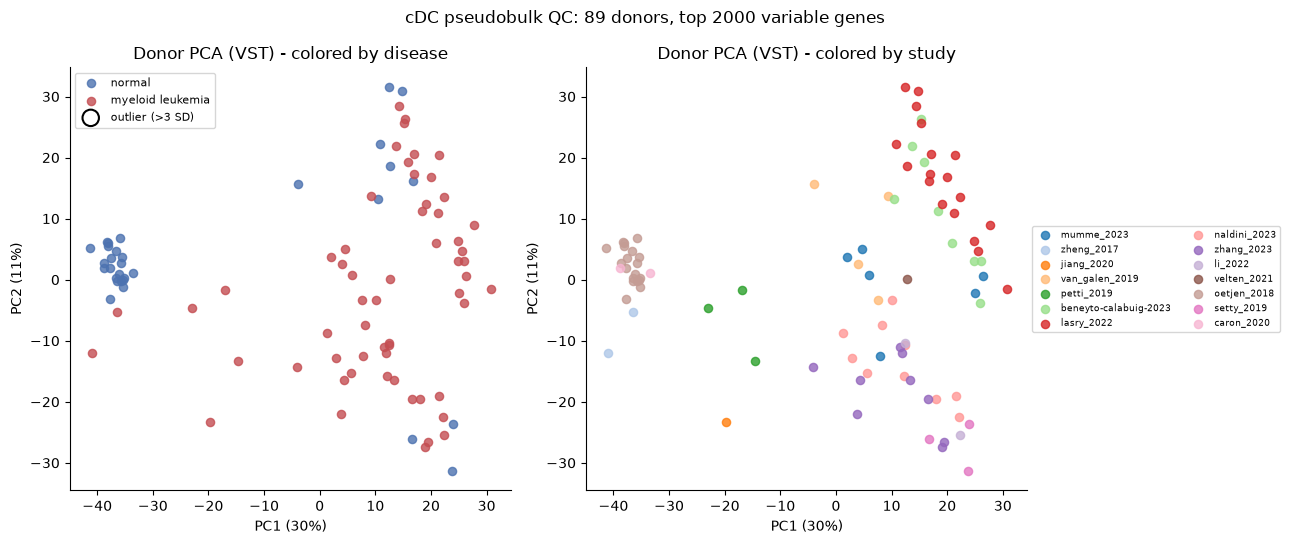

In [86]:
from sklearn.decomposition import PCA

gene_var = vst_df.var(axis=0).sort_values(ascending=False)
top_var_genes = gene_var.index[:2000]
Xc = vst_df[top_var_genes].values
Xc = Xc - Xc.mean(axis=0)
pca = PCA(n_components=10, random_state=0)
pcs = pca.fit_transform(Xc)
print("Variance explained by PC1-5:", np.round(pca.explained_variance_ratio_[:5], 3))

pc_df = pd.DataFrame(pcs[:, :2], columns=["PC1", "PC2"], index=vst_df.index).join(meta)
z1 = (pc_df["PC1"] - pc_df["PC1"].mean()) / pc_df["PC1"].std()
z2 = (pc_df["PC2"] - pc_df["PC2"].mean()) / pc_df["PC2"].std()
pc_df["outlier"] = (z1.abs() > 3) | (z2.abs() > 3)
outlier_donors = pc_df.index[pc_df["outlier"]].tolist()
print(f"Donors flagged as PCA outliers (>3 SD on PC1 or PC2): {outlier_donors}")

fig, axes = plt.subplots(1, 2, figsize=(13, 5.5))
disease_colors = {"normal": "#4c72b0", "myeloid leukemia": "#c44e52"}
for d, c in disease_colors.items():
    m = pc_df["disease"].astype(str) == d
    axes[0].scatter(pc_df.loc[m, "PC1"], pc_df.loc[m, "PC2"], s=35, alpha=0.8, color=c, label=d)
axes[0].scatter(pc_df.loc[pc_df["outlier"], "PC1"], pc_df.loc[pc_df["outlier"], "PC2"],
                s=140, facecolors="none", edgecolors="black", linewidths=1.5, label="outlier (>3 SD)")
axes[0].set_xlabel(f"PC1 ({pca.explained_variance_ratio_[0]*100:.0f}%)")
axes[0].set_ylabel(f"PC2 ({pca.explained_variance_ratio_[1]*100:.0f}%)")
axes[0].set_title("Donor PCA (VST) - colored by disease")
axes[0].legend(fontsize=8)

study_cats = pc_df["Study"].astype(str).unique()
study_colors2 = dict(zip(study_cats, sns.color_palette("tab20", len(study_cats))))
for s in study_cats:
    m = pc_df["Study"].astype(str) == s
    axes[1].scatter(pc_df.loc[m, "PC1"], pc_df.loc[m, "PC2"], s=35, alpha=0.8, color=study_colors2[s], label=s)
axes[1].set_xlabel(f"PC1 ({pca.explained_variance_ratio_[0]*100:.0f}%)")
axes[1].set_ylabel(f"PC2 ({pca.explained_variance_ratio_[1]*100:.0f}%)")
axes[1].set_title("Donor PCA (VST) - colored by study")
axes[1].legend(fontsize=6.5, ncol=2, loc="center left", bbox_to_anchor=(1.0, 0.5))

fig.suptitle(f"{LABEL} pseudobulk QC: {len(pc_df)} donors, top {len(top_var_genes)} variable genes")
fig.tight_layout()
plt.show()

In [87]:
mitocarta = pd.read_excel(os.path.join(DATA_DIR, "Human.MitoCarta3.0.xls"), sheet_name="A Human MitoCarta3.0")
mitocarta_genes = set(mitocarta["Symbol"].dropna().astype(str))

MT_GENES_ALL = sorted([g for g in gene_names if g.upper().startswith("MT-")])
mito_genes = sorted([g for g in mitocarta_genes if g in deseq_res.index])
n_mt_in_set = sum(g.upper().startswith("MT-") for g in mito_genes)
print(f"MitoCarta3.0: {len(mitocarta_genes)} genes total")
print(f"MitoCarta genes tested in this DE analysis: {len(mito_genes)} "
      f"({len(mito_genes) - n_mt_in_set} nuclear-encoded + {n_mt_in_set} mtDNA-encoded MT- genes)")

mito_table = deseq_res.loc[mito_genes].sort_values("padj")
mito_table["encoded_by"] = np.where(mito_table.index.str.upper().str.startswith("MT-"), "mtDNA", "nuclear")
display(mito_table.head(15)[["baseMean", "log2FoldChange", "lfcSE", "pvalue", "padj", "encoded_by"]])

MitoCarta3.0: 1136 genes total
MitoCarta genes tested in this DE analysis: 1015 (1002 nuclear-encoded + 13 mtDNA-encoded MT- genes)


,baseMean,log2FoldChange,lfcSE,pvalue,padj,encoded_by
PNPLA8,31.418102,-1.397701,0.351624,4.296108e-07,0.000540,nuclear
TOMM34,9.248657,-1.145470,0.328382,9.297862e-06,0.003341,nuclear
GHITM,88.213150,-0.385973,0.131355,2.896666e-04,0.026989,nuclear
GOLPH3,26.001918,0.737123,0.320520,3.333836e-04,0.030683,nuclear
ARMCX3,21.583740,0.776580,0.372774,4.967442e-04,0.037068,nuclear
SLC25A3,280.478132,-0.485186,0.191351,6.077468e-04,0.040234,nuclear
IDI1,38.932565,-0.707756,0.420857,6.559295e-04,0.041454,nuclear
HSD17B10,51.460813,-0.487981,0.199440,8.003139e-04,0.044681,nuclear
STOM,19.669333,0.836421,0.622535,1.023422e-03,0.049545,nuclear
SMIM8,7.143037,1.112149,0.804303,1.345703e-03,0.057705,nuclear


Mitochondrial genes passing padj<0.05 & |log2FC|>0.5: 6
Mitochondrial genes with padj<0.05 (any effect size): 9


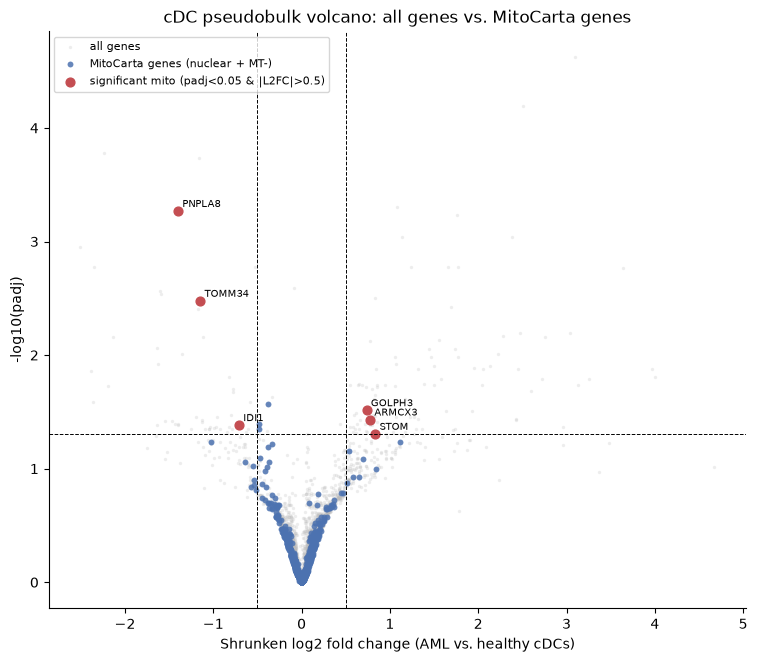

In [88]:
sig_mito = mito_table[(mito_table["padj"] < 0.05) & (mito_table["log2FoldChange"].abs() > 0.5)]
print(f"Mitochondrial genes passing padj<0.05 & |log2FC|>0.5: {len(sig_mito)}")
print(f"Mitochondrial genes with padj<0.05 (any effect size): {(mito_table['padj'] < 0.05).sum()}")
if len(sig_mito) == 0:
    print("None reach both thresholds simultaneously. Closest candidates (by padj):")
    print(mito_table.head(5)[["baseMean", "log2FoldChange", "padj", "encoded_by"]])

fig, ax = plt.subplots(figsize=(9, 7.5))
plot_df = deseq_res.dropna(subset=["padj"]).copy()
plot_df["neglog10padj"] = -np.log10(plot_df["padj"].clip(lower=1e-300))

ax.scatter(plot_df["log2FoldChange"], plot_df["neglog10padj"],
           s=6, alpha=0.25, color="#bbbbbb", linewidths=0, label="all genes")

mito_plot = plot_df.loc[plot_df.index.isin(mito_genes)]
ax.scatter(mito_plot["log2FoldChange"], mito_plot["neglog10padj"],
           s=18, alpha=0.85, color="#4c72b0", linewidths=0, label="MitoCarta genes (nuclear + MT-)")

if len(sig_mito) > 0:
    sig_plot = plot_df.loc[plot_df.index.isin(sig_mito.index)]
    ax.scatter(sig_plot["log2FoldChange"], sig_plot["neglog10padj"],
               s=40, color="#c44e52", label="significant mito (padj<0.05 & |L2FC|>0.5)")
    for gene, row in sig_plot.iterrows():
        ax.annotate(gene, (row["log2FoldChange"], row["neglog10padj"]), fontsize=7,
                    xytext=(3, 3), textcoords="offset points")
else:
    top5 = mito_table.head(5)
    top5_plot = plot_df.loc[plot_df.index.isin(top5.index)]
    ax.scatter(top5_plot["log2FoldChange"], top5_plot["neglog10padj"],
               s=40, color="#dd8452", label="top 5 mito genes (by padj, n.s.)")
    for gene, row in top5_plot.iterrows():
        ax.annotate(gene, (row["log2FoldChange"], row["neglog10padj"]), fontsize=7,
                    xytext=(3, 3), textcoords="offset points")

ax.axhline(-np.log10(0.05), color="black", lw=0.7, ls="--")
ax.axvline(0.5, color="black", lw=0.7, ls="--")
ax.axvline(-0.5, color="black", lw=0.7, ls="--")
ax.set_xlabel(f"Shrunken log2 fold change (AML vs. healthy {LABEL}s)")
ax.set_ylabel("-log10(padj)")
ax.set_title(f"{LABEL} pseudobulk volcano: all genes vs. MitoCarta genes")
ax.legend(fontsize=8, loc="upper left")
plt.show()

In [89]:
import gseapy as gp

GSEA_CACHE = os.path.join(RESULTS_DIR, f"{PFX}_gsea_results_mt_included.parquet")

mitopathways = pd.read_excel(os.path.join(DATA_DIR, "Human.MitoCarta3.0.xls"), sheet_name="C MitoPathways")
mitopathways = mitopathways.dropna(subset=["MitoPathway"])

gene_sets = {}
for _, row in mitopathways.iterrows():
    gene_sets[row["MitoPathway"]] = [g.strip() for g in str(row["Genes"]).split(",") if g.strip()]

gene_rank = deseq_res["log2FoldChange"].dropna().sort_values(ascending=False)
print(f"Ranked gene list (nuclear + MT-): {len(gene_rank)} genes; {len(gene_sets)} MitoPathway gene sets")

if os.path.exists(GSEA_CACHE):
    print("Loading cached GSEA results...")
    gsea_res = pd.read_parquet(GSEA_CACHE)
else:
    prerank = gp.prerank(
        rnk=gene_rank, gene_sets=gene_sets, min_size=5, max_size=500,
        permutation_num=1000, seed=0, threads=4, no_plot=True, outdir=None,
    )
    gsea_res = prerank.res2d.copy()
    gsea_res["NES"] = gsea_res["NES"].astype(float)
    gsea_res["FDR q-val"] = gsea_res["FDR q-val"].astype(float)
    gsea_res.to_parquet(GSEA_CACHE)

print(f"Pathways tested: {len(gsea_res)}")
print(f"Pathways with FDR q<0.05: {(gsea_res['FDR q-val'] < 0.05).sum()}")
sig_pathways = gsea_res[gsea_res["FDR q-val"] < 0.25].sort_values("NES")
print(f"Significant pathways (FDR q<0.25, standard GSEA convention): {len(sig_pathways)}")
sig_pathways[["Term", "NES", "NOM p-val", "FDR q-val"]]

Ranked gene list (nuclear + MT-): 15842 genes; 149 MitoPathway gene sets
Loading cached GSEA results...
Pathways tested: 113
Pathways with FDR q<0.05: 0
Significant pathways (FDR q<0.25, standard GSEA convention): 1


,Term,NES,NOM p-val,FDR q-val
0,OXPHOS subunits,-1.778251,0.0,0.233387


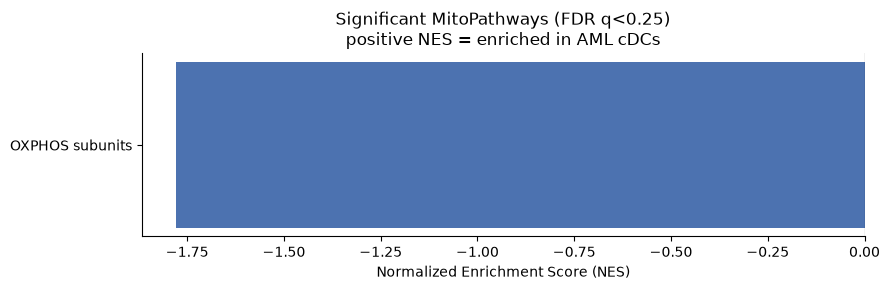

In [90]:
fig, ax = plt.subplots(figsize=(9, max(3, 0.35 * len(sig_pathways) + 1)))
if len(sig_pathways) > 0:
    colors_bar = ["#c44e52" if v > 0 else "#4c72b0" for v in sig_pathways["NES"]]
    ax.barh(sig_pathways["Term"], sig_pathways["NES"], color=colors_bar)
    ax.axvline(0, color="black", lw=0.8)
    ax.set_xlabel("Normalized Enrichment Score (NES)")
    ax.set_title(f"Significant MitoPathways (FDR q<0.25)\npositive NES = enriched in AML {LABEL}s")
else:
    ax.text(0.5, 0.5, "No MitoPathways reached FDR q<0.25", ha="center", va="center")
    ax.axis("off")
fig.tight_layout()
plt.show()

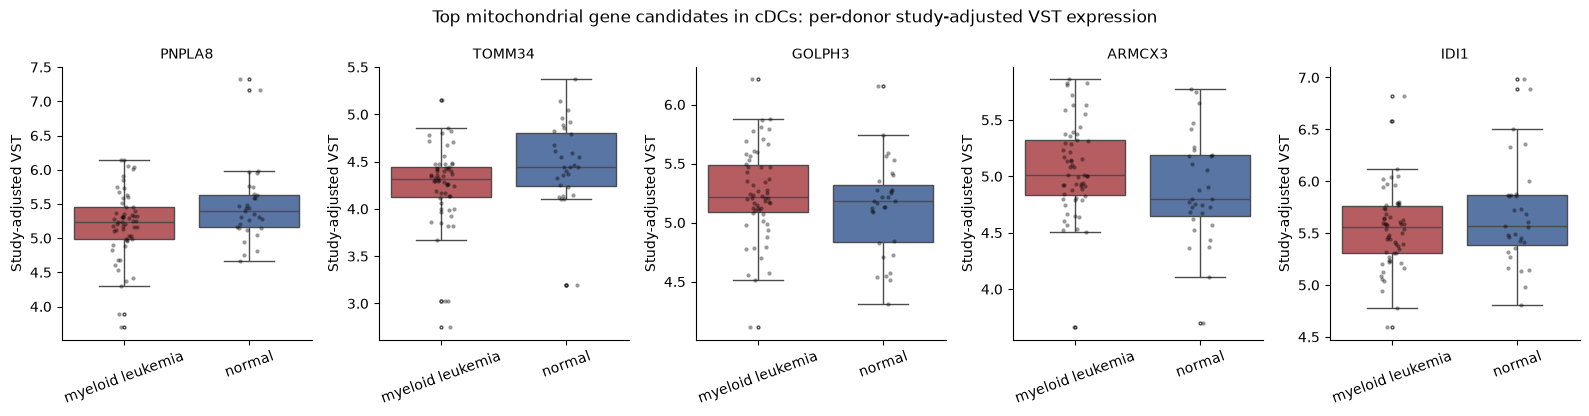

In [91]:
def study_adjusted(gene_vals, study_labels):
    df_tmp = pd.DataFrame({"v": gene_vals, "Study": study_labels})
    study_mean = df_tmp.groupby("Study")["v"].transform("mean")
    return df_tmp["v"] - study_mean + df_tmp["v"].mean()

top_genes_for_plot = (sig_mito.index.tolist() if len(sig_mito) > 0 else mito_table.head(5).index.tolist())[:5]

fig, axes = plt.subplots(1, len(top_genes_for_plot), figsize=(3.2 * len(top_genes_for_plot), 4.2), squeeze=False)
axes = axes[0]
for ax, gene in zip(axes, top_genes_for_plot):
    if use_study_covariate:
        vst_plot_vals = study_adjusted(vst_df[gene], meta["Study"])
        ylabel = "Study-adjusted VST"
    else:
        vst_plot_vals = vst_df[gene]
        ylabel = "VST"
    df_g = pd.DataFrame({ylabel: vst_plot_vals, "disease": meta["disease"].astype(str)})
    sns.boxplot(data=df_g, x="disease", y=ylabel, palette=disease_colors, ax=ax, fliersize=2)
    sns.stripplot(data=df_g, x="disease", y=ylabel, color="black", alpha=0.4, size=3, ax=ax)
    ax.set_title(gene, fontsize=10)
    ax.set_xlabel("")
    ax.tick_params(axis="x", rotation=20)
fig.suptitle(f"Top mitochondrial gene candidates in {LABEL}s: per-donor "
             + ("study-adjusted " if use_study_covariate else "") + "VST expression")
fig.tight_layout()
plt.show()

Top pathway (by |NES|, among those with >=5 leading-edge genes): OXPHOS subunits  (NES=-1.78, FDR q=0.233)
Leading-edge genes plotted: 62


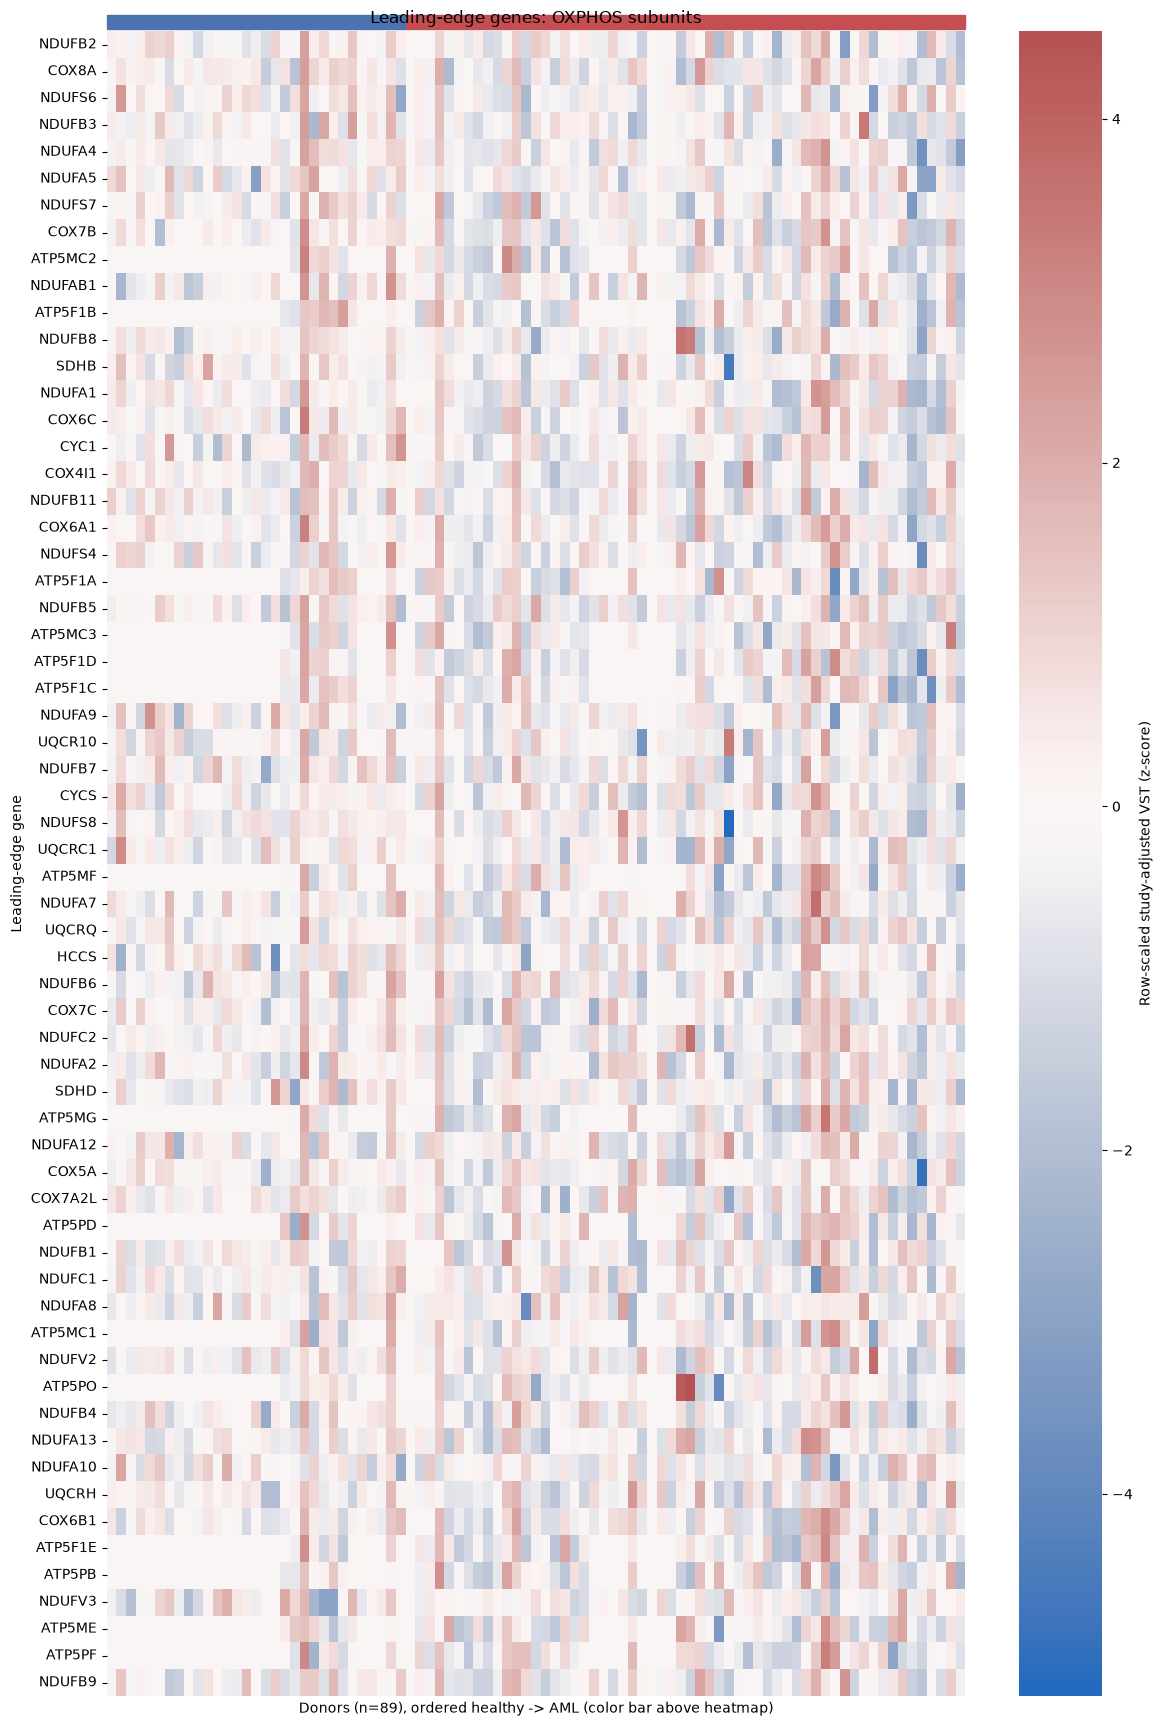

In [92]:
MIN_LEADING_EDGE = 5   # a heatmap needs several genes; skip pathways whose leading edge is (almost) empty

def _enough_genes(df):
    n = df["Lead_genes"].map(lambda s: sum(g in vst_df.columns for g in str(s).split(";")))
    return df[n >= MIN_LEADING_EDGE]

cand_ok = _enough_genes(sig_pathways if len(sig_pathways) > 0 else gsea_res)
if len(cand_ok) == 0:
    cand_ok = _enough_genes(gsea_res)   # none of the significant ones qualifies: use any tested pathway
pool = cand_ok if len(cand_ok) > 0 else gsea_res
top_pathway = pool.loc[pool["NES"].abs().idxmax()]

top_pathway_name = top_pathway["Term"]
leading_edge_genes = [g for g in str(top_pathway["Lead_genes"]).split(";") if g in vst_df.columns]
print(f"Top pathway (by |NES|, among those with >={MIN_LEADING_EDGE} leading-edge genes): "
      f"{top_pathway_name}  (NES={top_pathway['NES']:.2f}, FDR q={top_pathway['FDR q-val']:.3f})")
print(f"Leading-edge genes plotted: {len(leading_edge_genes)}")

if len(leading_edge_genes) >= 2:
    order = meta.sort_values("disease").index
    if use_study_covariate:
        hm_source = pd.DataFrame(
            {g: study_adjusted(vst_df[g], meta["Study"]) for g in leading_edge_genes},
            index=vst_df.index,
        )
        cbar_label = "Row-scaled study-adjusted VST (z-score)"
    else:
        hm_source = vst_df[leading_edge_genes]
        cbar_label = "Row-scaled VST (z-score)"
    hm_data = hm_source.loc[order, leading_edge_genes].T
    hm_z = hm_data.sub(hm_data.mean(axis=1), axis=0).div(hm_data.std(axis=1), axis=0)

    fig, ax = plt.subplots(figsize=(12, max(3, 0.28 * len(leading_edge_genes))))
    sns.heatmap(hm_z, cmap="vlag", center=0, ax=ax,
                cbar_kws={"label": cbar_label},
                xticklabels=False, yticklabels=True)
    disease_track = meta.loc[order, "disease"].astype(str).map({"normal": 0, "myeloid leukemia": 1}).values
    for i, v in enumerate(disease_track):
        ax.add_patch(plt.Rectangle((i, -0.6), 1, 0.5,
                                    color=disease_colors["myeloid leukemia"] if v else disease_colors["normal"],
                                    clip_on=False))
    ax.set_ylabel("Leading-edge gene")
    ax.set_xlabel(f"Donors (n={len(order)}), ordered healthy -> AML (color bar above heatmap)")
    ax.set_title(f"Leading-edge genes: {top_pathway_name}")
    fig.tight_layout()
    plt.show()
else:
    print("Not enough leading-edge genes with VST values to plot a heatmap.")

RESULTS[PFX] = dict(label=LABEL, deseq=deseq_res, gsea=gsea_res, mito_table=mito_table,
                    mito_genes=mito_genes, meta=meta)

In [93]:
CT, LABEL, PFX = "hematopoietic stem cell", "HSC", "hsc"
if "RESULTS" not in globals():
    RESULTS = {}

MIN_CELLS_PER_DONOR = 20
MIN_DONORS_PER_GROUP = 5

is_ct = (obs["cell_type"] == CT)
print(f"{LABEL}s before any donor-level filter: {is_ct.sum():,} cells, "
      f"{obs.loc[is_ct, 'donor_id'].nunique()} donors, "
      f"{obs.loc[is_ct, 'Study'].nunique()} studies")

ct_per_donor = (
    obs.loc[is_ct].groupby(["donor_id", "disease"], observed=True).size()
    .reset_index(name="n_cells_ct")
)
qualifying = ct_per_donor[ct_per_donor["n_cells_ct"] >= MIN_CELLS_PER_DONOR]
dropped = ct_per_donor[ct_per_donor["n_cells_ct"] < MIN_CELLS_PER_DONOR]
zero_donors = obs.loc[~obs["donor_id"].isin(ct_per_donor["donor_id"]), "donor_id"].nunique()

n_per_group = qualifying.groupby("disease", observed=True)["donor_id"].nunique()
assert (n_per_group >= MIN_DONORS_PER_GROUP).all(), "A disease group has <5 qualifying donors!"

print(f"\nDonors with ZERO {LABEL}s (dropped outright, mostly CD34+-sorted studies): {zero_donors}")
print(f"Donors with 1-{MIN_CELLS_PER_DONOR - 1} {LABEL}s (dropped, too few cells): "
      f"{dropped['donor_id'].nunique()}  ({dropped.groupby('disease', observed=True)['donor_id'].nunique().to_dict()})")
print(f"\nDonors KEPT (>={MIN_CELLS_PER_DONOR} {LABEL}s), per group:")
print(n_per_group)
print(f"\nTotal donors kept: {len(qualifying)} / {obs['donor_id'].nunique()} in the full atlas")
print(f"Total {LABEL}s kept for pseudobulk: {qualifying['n_cells_ct'].sum():,} "
      f"(of {is_ct.sum():,} {LABEL}s overall)")

qualifying_donors = qualifying["donor_id"].tolist()

studies_dropped_entirely = sorted(
    set(obs["Study"].unique())
    - set(obs.loc[obs["donor_id"].isin(qualifying_donors), "Study"].unique())
)
print(f"\nStudies with ZERO qualifying donors (effectively fully excluded): {studies_dropped_entirely}")

HSCs before any donor-level filter: 203,742 cells, 208 donors, 20 studies

Donors with ZERO HSCs (dropped outright, mostly CD34+-sorted studies): 2
Donors with 1-19 HSCs (dropped, too few cells): 27  ({'myeloid leukemia': 11, 'normal': 16})

Donors KEPT (>=20 HSCs), per group:
disease
myeloid leukemia    146
normal               35
Name: donor_id, dtype: int64

Total donors kept: 181 / 210 in the full atlas
Total HSCs kept for pseudobulk: 203,512 (of 203,742 HSCs overall)

Studies with ZERO qualifying donors (effectively fully excluded): ['human_cell_atlas']


In [94]:
PB_CACHE = os.path.join(RESULTS_DIR, f"{PFX}_pseudobulk_counts.parquet")
PB_META_CACHE = os.path.join(RESULTS_DIR, f"{PFX}_pseudobulk_donor_meta.parquet")

if os.path.exists(PB_CACHE) and os.path.exists(PB_META_CACHE):
    print(f"Loading cached {LABEL} pseudobulk matrix...")
    pb_counts = pd.read_parquet(PB_CACHE)
    donor_meta = pd.read_parquet(PB_META_CACHE)
else:
    donor_to_qidx = {d: i for i, d in enumerate(qualifying_donors)}
    n_donors_pb = len(qualifying_donors)
    donor_codes_arr = obs["donor_id"].values
    is_ct_arr = is_ct.values
    assign = np.full(n_cells, -1, dtype=np.int64)
    mask_keep_cell = is_ct_arr & np.isin(donor_codes_arr, qualifying_donors)
    keep_rows = np.where(mask_keep_cell)[0]
    assign[keep_rows] = np.array([donor_to_qidx[d] for d in donor_codes_arr[keep_rows]])

    t0 = time.time()
    pseudobulk = np.zeros((n_donors_pb, n_genes), dtype=np.float64)
    with h5py.File(H5_PATH, "r") as f:
        indptr = f["X/indptr"][:]
        raw_data_ds, raw_idx_ds = f["raw/X/data"], f["raw/X/indices"]
        for start in range(0, n_cells, CHUNK_ROWS):
            end = min(start + CHUNK_ROWS, n_cells)
            chunk_assign = assign[start:end]
            if not np.any(chunk_assign >= 0):
                continue
            s, e = int(indptr[start]), int(indptr[end])
            local_indptr = indptr[start:end + 1] - indptr[start]
            raw_chunk = sparse.csr_matrix(
                (raw_data_ds[s:e], raw_idx_ds[s:e], local_indptr),
                shape=(end - start, n_genes))
            valid = chunk_assign >= 0
            rows = np.where(valid)[0]
            indicator = sparse.csr_matrix(
                (np.ones(len(rows)), (chunk_assign[valid], rows)),
                shape=(n_donors_pb, end - start))
            pseudobulk += indicator.dot(raw_chunk).toarray()
    print(f"Pseudobulk scan done in {time.time()-t0:.0f}s")

    pb_counts = pd.DataFrame(pseudobulk, index=qualifying_donors, columns=gene_names)
    donor_meta = (
        obs[obs["donor_id"].isin(qualifying_donors)]
        .drop_duplicates("donor_id").set_index("donor_id")
        .loc[qualifying_donors, ["disease", "Study", "Fine Age Group", "Main Age Group", "sex", "ELN Risk Group"]]
    )
    pb_counts.to_parquet(PB_CACHE)
    donor_meta.to_parquet(PB_META_CACHE)

print(f"Pseudobulk matrix: {pb_counts.shape[0]} donors x {pb_counts.shape[1]} genes")
donor_meta["disease"].value_counts()

Loading cached HSC pseudobulk matrix...


Pseudobulk matrix: 181 donors x 21588 genes


disease
myeloid leukemia    146
normal               35
Name: count, dtype: int64

In [95]:
counts_all = pb_counts.round().astype(int)
gene_sums = counts_all.sum(axis=0)
counts_filt = counts_all.loc[:, gene_sums >= 10]
print(f"Genes after near-empty filter (sum>=10 across donors): {counts_filt.shape[1]} / {counts_all.shape[1]}")

meta = donor_meta.copy()
meta["disease"] = pd.Categorical(meta["disease"].astype(str), categories=["normal", "myeloid leukemia"])
meta["Study"] = meta["Study"].astype(str)

design_full = pd.get_dummies(meta[["Study", "disease"]], drop_first=True).astype(float)
design_full.insert(0, "intercept", 1.0)
rank = np.linalg.matrix_rank(design_full.values)
use_study_covariate = (rank == design_full.shape[1])
print(f"~ Study + disease design matrix: {design_full.shape}, rank {rank} "
      f"-> {'FULL RANK, using Study as covariate' if use_study_covariate else 'RANK DEFICIENT, falling back to ~ disease'}")

DESIGN_FORMULA = "~Study+disease" if use_study_covariate else "~disease"

Genes after near-empty filter (sum>=10 across donors): 21209 / 21588
~ Study + disease design matrix: (181, 20), rank 20 -> FULL RANK, using Study as covariate


In [96]:
from pydeseq2.dds import DeseqDataSet
from pydeseq2.ds import DeseqStats

DESEQ_CACHE = os.path.join(RESULTS_DIR, f"{PFX}_deseq_results.parquet")
VST_CACHE = os.path.join(RESULTS_DIR, f"{PFX}_vst.parquet")

if os.path.exists(DESEQ_CACHE) and os.path.exists(VST_CACHE):
    print("Loading cached DESeq2 results + VST matrix...")
    deseq_res = pd.read_parquet(DESEQ_CACHE)
    vst_df = pd.read_parquet(VST_CACHE)
else:
    dds = DeseqDataSet(counts=counts_filt, metadata=meta, design=DESIGN_FORMULA,
                        refit_cooks=True, quiet=True)
    dds.deseq2()

    dds.vst(use_design=False)
    vst_df = pd.DataFrame(dds.layers["vst_counts"], index=dds.obs_names, columns=dds.var_names)

    ds = DeseqStats(dds, contrast=["disease", "myeloid leukemia", "normal"], quiet=True)
    ds.summary()
    ds.lfc_shrink(coeff="disease[T.myeloid leukemia]")
    deseq_res = ds.results_df.copy()

    deseq_res.to_parquet(DESEQ_CACHE)
    vst_df.to_parquet(VST_CACHE)

print(f"DESeq2 results: {deseq_res.shape[0]} genes tested "
      f"(positive log2FC = higher in AML {LABEL}s vs. healthy {LABEL}s)")
print(f"Significant genes overall (padj < 0.05): {(deseq_res['padj'] < 0.05).sum()}")
deseq_res.sort_values("padj").head(10)

Loading cached DESeq2 results + VST matrix...


DESeq2 results: 21209 genes tested (positive log2FC = higher in AML HSCs vs. healthy HSCs)
Significant genes overall (padj < 0.05): 405


,baseMean,log2FoldChange,lfcSE,stat,pvalue,padj
DENND3,128.402176,1.934865,0.330471,6.309391,2.801347e-10,0.000003
SAT1,1151.967277,1.694421,0.342658,6.000488,1.967249e-09,0.000012
CTSA,270.682054,1.833987,0.393612,5.570444,2.540909e-08,0.000100
HLF,23.148584,-4.029953,1.164818,-5.489516,4.030377e-08,0.000104
PDE3B,100.158000,2.315405,0.494703,5.424482,5.812276e-08,0.000104
SH3BGRL3,2697.038676,1.200186,0.290061,5.463153,4.677508e-08,0.000104
CD63,887.404895,0.950001,0.217058,5.413768,6.171204e-08,0.000104
PRKG2,27.830207,-4.023315,0.988743,-5.372329,7.772602e-08,0.000109
IL1RAP,117.103333,2.122223,0.536607,5.359740,8.334190e-08,0.000109
HOTAIRM1,77.509402,3.338550,0.830731,5.300930,1.152142e-07,0.000135


In [98]:
mitocarta = pd.read_excel(os.path.join(DATA_DIR, "Human.MitoCarta3.0.xls"), sheet_name="A Human MitoCarta3.0")
mitocarta_genes = set(mitocarta["Symbol"].dropna().astype(str))

MT_GENES_ALL = sorted([g for g in gene_names if g.upper().startswith("MT-")])
mito_genes = sorted([g for g in mitocarta_genes if g in deseq_res.index])
n_mt_in_set = sum(g.upper().startswith("MT-") for g in mito_genes)
print(f"MitoCarta3.0: {len(mitocarta_genes)} genes total")
print(f"MitoCarta genes tested in this DE analysis: {len(mito_genes)} "
      f"({len(mito_genes) - n_mt_in_set} nuclear-encoded + {n_mt_in_set} mtDNA-encoded MT- genes)")

mito_table = deseq_res.loc[mito_genes].sort_values("padj")
mito_table["encoded_by"] = np.where(mito_table.index.str.upper().str.startswith("MT-"), "mtDNA", "nuclear")
display(mito_table.head(15)[["baseMean", "log2FoldChange", "lfcSE", "pvalue", "padj", "encoded_by"]])

MitoCarta3.0: 1136 genes total
MitoCarta genes tested in this DE analysis: 1041 (1028 nuclear-encoded + 13 mtDNA-encoded MT- genes)


,baseMean,log2FoldChange,lfcSE,pvalue,padj,encoded_by
FH,87.817717,-0.766849,0.225139,0.000018,0.004001,nuclear
PDK1,99.401000,1.205233,0.379395,0.000020,0.004153,nuclear
OSBPL1A,76.834491,-1.242440,0.393562,0.000029,0.005242,nuclear
NIPSNAP1,74.339076,-0.693468,0.229907,0.000082,0.009308,nuclear
BBC3,23.096097,2.035147,0.949373,0.000084,0.009424,nuclear
PPTC7,111.947132,0.824808,0.328543,0.000172,0.015089,nuclear
UNG,92.816168,-0.950008,0.313435,0.000180,0.015377,nuclear
CASP8,174.257731,0.629350,0.219970,0.000215,0.016414,nuclear
ALDH7A1,30.226154,-1.371466,0.492032,0.000289,0.019542,nuclear
SFXN3,62.995705,1.364167,0.760340,0.000321,0.020947,nuclear


Mitochondrial genes passing padj<0.05 & |log2FC|>0.5: 20
Mitochondrial genes with padj<0.05 (any effect size): 22


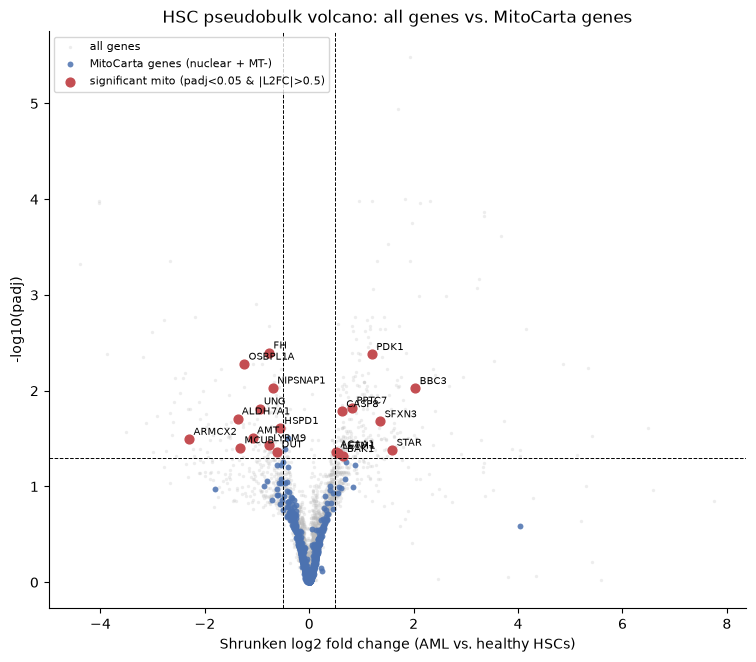

In [99]:
sig_mito = mito_table[(mito_table["padj"] < 0.05) & (mito_table["log2FoldChange"].abs() > 0.5)]
print(f"Mitochondrial genes passing padj<0.05 & |log2FC|>0.5: {len(sig_mito)}")
print(f"Mitochondrial genes with padj<0.05 (any effect size): {(mito_table['padj'] < 0.05).sum()}")
if len(sig_mito) == 0:
    print("None reach both thresholds simultaneously. Closest candidates (by padj):")
    print(mito_table.head(5)[["baseMean", "log2FoldChange", "padj", "encoded_by"]])

fig, ax = plt.subplots(figsize=(9, 7.5))
plot_df = deseq_res.dropna(subset=["padj"]).copy()
plot_df["neglog10padj"] = -np.log10(plot_df["padj"].clip(lower=1e-300))

ax.scatter(plot_df["log2FoldChange"], plot_df["neglog10padj"],
           s=6, alpha=0.25, color="#bbbbbb", linewidths=0, label="all genes")

mito_plot = plot_df.loc[plot_df.index.isin(mito_genes)]
ax.scatter(mito_plot["log2FoldChange"], mito_plot["neglog10padj"],
           s=18, alpha=0.85, color="#4c72b0", linewidths=0, label="MitoCarta genes (nuclear + MT-)")

if len(sig_mito) > 0:
    sig_plot = plot_df.loc[plot_df.index.isin(sig_mito.index)]
    ax.scatter(sig_plot["log2FoldChange"], sig_plot["neglog10padj"],
               s=40, color="#c44e52", label="significant mito (padj<0.05 & |L2FC|>0.5)")
    for gene, row in sig_plot.iterrows():
        ax.annotate(gene, (row["log2FoldChange"], row["neglog10padj"]), fontsize=7,
                    xytext=(3, 3), textcoords="offset points")
else:
    top5 = mito_table.head(5)
    top5_plot = plot_df.loc[plot_df.index.isin(top5.index)]
    ax.scatter(top5_plot["log2FoldChange"], top5_plot["neglog10padj"],
               s=40, color="#dd8452", label="top 5 mito genes (by padj, n.s.)")
    for gene, row in top5_plot.iterrows():
        ax.annotate(gene, (row["log2FoldChange"], row["neglog10padj"]), fontsize=7,
                    xytext=(3, 3), textcoords="offset points")

ax.axhline(-np.log10(0.05), color="black", lw=0.7, ls="--")
ax.axvline(0.5, color="black", lw=0.7, ls="--")
ax.axvline(-0.5, color="black", lw=0.7, ls="--")
ax.set_xlabel(f"Shrunken log2 fold change (AML vs. healthy {LABEL}s)")
ax.set_ylabel("-log10(padj)")
ax.set_title(f"{LABEL} pseudobulk volcano: all genes vs. MitoCarta genes")
ax.legend(fontsize=8, loc="upper left")
plt.show()

In [100]:
import gseapy as gp

GSEA_CACHE = os.path.join(RESULTS_DIR, f"{PFX}_gsea_results_mt_included.parquet")

mitopathways = pd.read_excel(os.path.join(DATA_DIR, "Human.MitoCarta3.0.xls"), sheet_name="C MitoPathways")
mitopathways = mitopathways.dropna(subset=["MitoPathway"])

gene_sets = {}
for _, row in mitopathways.iterrows():
    gene_sets[row["MitoPathway"]] = [g.strip() for g in str(row["Genes"]).split(",") if g.strip()]

gene_rank = deseq_res["log2FoldChange"].dropna().sort_values(ascending=False)
print(f"Ranked gene list (nuclear + MT-): {len(gene_rank)} genes; {len(gene_sets)} MitoPathway gene sets")

if os.path.exists(GSEA_CACHE):
    print("Loading cached GSEA results...")
    gsea_res = pd.read_parquet(GSEA_CACHE)
else:
    prerank = gp.prerank(
        rnk=gene_rank, gene_sets=gene_sets, min_size=5, max_size=500,
        permutation_num=1000, seed=0, threads=4, no_plot=True, outdir=None,
    )
    gsea_res = prerank.res2d.copy()
    gsea_res["NES"] = gsea_res["NES"].astype(float)
    gsea_res["FDR q-val"] = gsea_res["FDR q-val"].astype(float)
    gsea_res.to_parquet(GSEA_CACHE)

print(f"Pathways tested: {len(gsea_res)}")
print(f"Pathways with FDR q<0.05: {(gsea_res['FDR q-val'] < 0.05).sum()}")
sig_pathways = gsea_res[gsea_res["FDR q-val"] < 0.25].sort_values("NES")
print(f"Significant pathways (FDR q<0.25, standard GSEA convention): {len(sig_pathways)}")
sig_pathways[["Term", "NES", "NOM p-val", "FDR q-val"]]

Ranked gene list (nuclear + MT-): 21209 genes; 149 MitoPathway gene sets
Loading cached GSEA results...
Pathways tested: 114
Pathways with FDR q<0.05: 0
Significant pathways (FDR q<0.25, standard GSEA convention): 0


,Term,NES,NOM p-val,FDR q-val


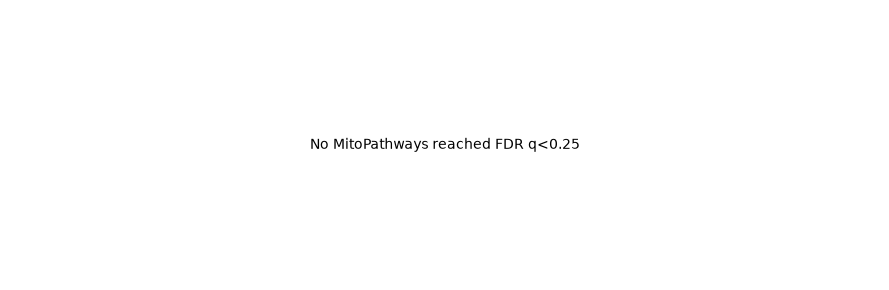

In [101]:
fig, ax = plt.subplots(figsize=(9, max(3, 0.35 * len(sig_pathways) + 1)))
if len(sig_pathways) > 0:
    colors_bar = ["#c44e52" if v > 0 else "#4c72b0" for v in sig_pathways["NES"]]
    ax.barh(sig_pathways["Term"], sig_pathways["NES"], color=colors_bar)
    ax.axvline(0, color="black", lw=0.8)
    ax.set_xlabel("Normalized Enrichment Score (NES)")
    ax.set_title(f"Significant MitoPathways (FDR q<0.25)\npositive NES = enriched in AML {LABEL}s")
else:
    ax.text(0.5, 0.5, "No MitoPathways reached FDR q<0.25", ha="center", va="center")
    ax.axis("off")
fig.tight_layout()
plt.show()

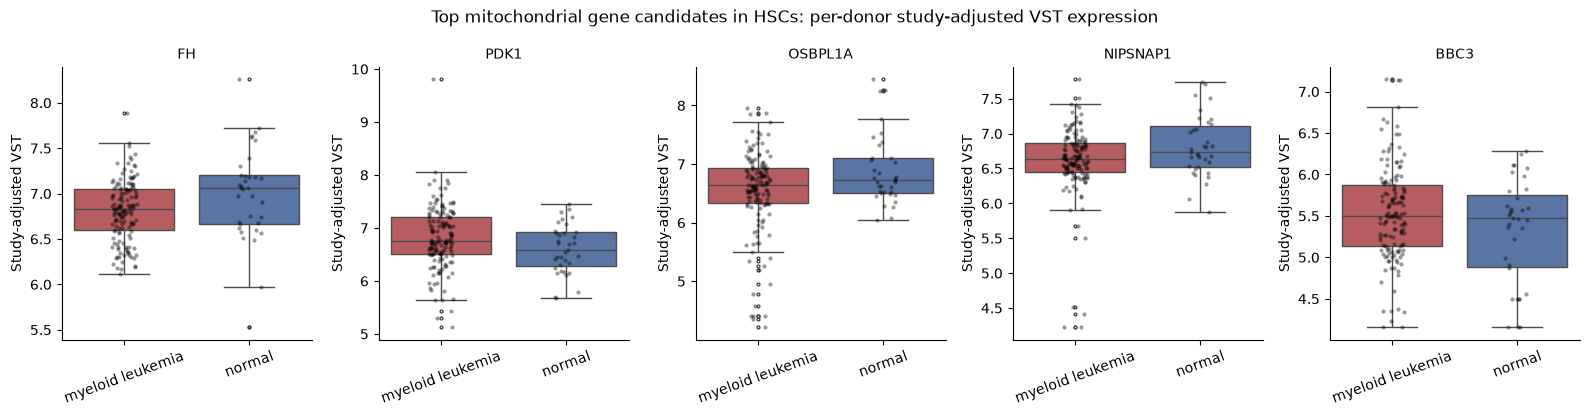

In [102]:
def study_adjusted(gene_vals, study_labels):
    df_tmp = pd.DataFrame({"v": gene_vals, "Study": study_labels})
    study_mean = df_tmp.groupby("Study")["v"].transform("mean")
    return df_tmp["v"] - study_mean + df_tmp["v"].mean()

top_genes_for_plot = (sig_mito.index.tolist() if len(sig_mito) > 0 else mito_table.head(5).index.tolist())[:5]

fig, axes = plt.subplots(1, len(top_genes_for_plot), figsize=(3.2 * len(top_genes_for_plot), 4.2), squeeze=False)
axes = axes[0]
for ax, gene in zip(axes, top_genes_for_plot):
    if use_study_covariate:
        vst_plot_vals = study_adjusted(vst_df[gene], meta["Study"])
        ylabel = "Study-adjusted VST"
    else:
        vst_plot_vals = vst_df[gene]
        ylabel = "VST"
    df_g = pd.DataFrame({ylabel: vst_plot_vals, "disease": meta["disease"].astype(str)})
    sns.boxplot(data=df_g, x="disease", y=ylabel, palette=disease_colors, ax=ax, fliersize=2)
    sns.stripplot(data=df_g, x="disease", y=ylabel, color="black", alpha=0.4, size=3, ax=ax)
    ax.set_title(gene, fontsize=10)
    ax.set_xlabel("")
    ax.tick_params(axis="x", rotation=20)
fig.suptitle(f"Top mitochondrial gene candidates in {LABEL}s: per-donor "
             + ("study-adjusted " if use_study_covariate else "") + "VST expression")
fig.tight_layout()
plt.show()

Top pathway (by |NES|, among those with >=5 leading-edge genes): Apoptosis  (NES=1.46, FDR q=0.906)
Leading-edge genes plotted: 10


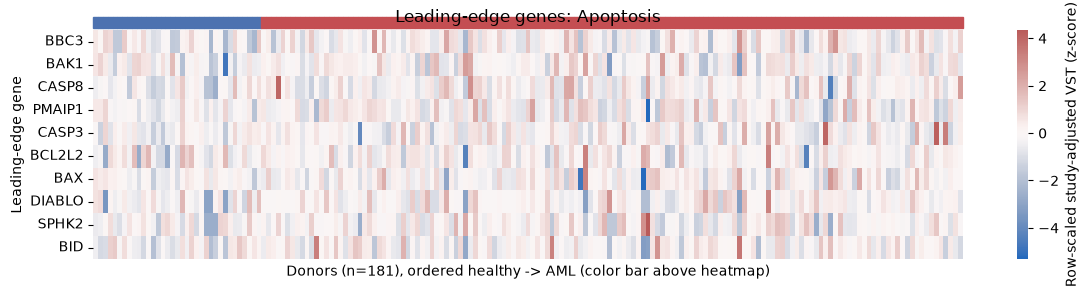

In [103]:
MIN_LEADING_EDGE = 5   # a heatmap needs several genes; skip pathways whose leading edge is (almost) empty

def _enough_genes(df):
    n = df["Lead_genes"].map(lambda s: sum(g in vst_df.columns for g in str(s).split(";")))
    return df[n >= MIN_LEADING_EDGE]

cand_ok = _enough_genes(sig_pathways if len(sig_pathways) > 0 else gsea_res)
if len(cand_ok) == 0:
    cand_ok = _enough_genes(gsea_res)   # none of the significant ones qualifies: use any tested pathway
pool = cand_ok if len(cand_ok) > 0 else gsea_res
top_pathway = pool.loc[pool["NES"].abs().idxmax()]

top_pathway_name = top_pathway["Term"]
leading_edge_genes = [g for g in str(top_pathway["Lead_genes"]).split(";") if g in vst_df.columns]
print(f"Top pathway (by |NES|, among those with >={MIN_LEADING_EDGE} leading-edge genes): "
      f"{top_pathway_name}  (NES={top_pathway['NES']:.2f}, FDR q={top_pathway['FDR q-val']:.3f})")
print(f"Leading-edge genes plotted: {len(leading_edge_genes)}")

if len(leading_edge_genes) >= 2:
    order = meta.sort_values("disease").index
    if use_study_covariate:
        hm_source = pd.DataFrame(
            {g: study_adjusted(vst_df[g], meta["Study"]) for g in leading_edge_genes},
            index=vst_df.index,
        )
        cbar_label = "Row-scaled study-adjusted VST (z-score)"
    else:
        hm_source = vst_df[leading_edge_genes]
        cbar_label = "Row-scaled VST (z-score)"
    hm_data = hm_source.loc[order, leading_edge_genes].T
    hm_z = hm_data.sub(hm_data.mean(axis=1), axis=0).div(hm_data.std(axis=1), axis=0)

    fig, ax = plt.subplots(figsize=(12, max(3, 0.28 * len(leading_edge_genes))))
    sns.heatmap(hm_z, cmap="vlag", center=0, ax=ax,
                cbar_kws={"label": cbar_label},
                xticklabels=False, yticklabels=True)
    disease_track = meta.loc[order, "disease"].astype(str).map({"normal": 0, "myeloid leukemia": 1}).values
    for i, v in enumerate(disease_track):
        ax.add_patch(plt.Rectangle((i, -0.6), 1, 0.5,
                                    color=disease_colors["myeloid leukemia"] if v else disease_colors["normal"],
                                    clip_on=False))
    ax.set_ylabel("Leading-edge gene")
    ax.set_xlabel(f"Donors (n={len(order)}), ordered healthy -> AML (color bar above heatmap)")
    ax.set_title(f"Leading-edge genes: {top_pathway_name}")
    fig.tight_layout()
    plt.show()
else:
    print("Not enough leading-edge genes with VST values to plot a heatmap.")

RESULTS[PFX] = dict(label=LABEL, deseq=deseq_res, gsea=gsea_res, mito_table=mito_table,
                    mito_genes=mito_genes, meta=meta)

In [104]:
CT, LABEL, PFX = "plasmacytoid dendritic cell", "pDC", "pdc"
if "RESULTS" not in globals():
    RESULTS = {}

MIN_CELLS_PER_DONOR = 20
MIN_DONORS_PER_GROUP = 5

is_ct = (obs["cell_type"] == CT)
print(f"{LABEL}s before any donor-level filter: {is_ct.sum():,} cells, "
      f"{obs.loc[is_ct, 'donor_id'].nunique()} donors, "
      f"{obs.loc[is_ct, 'Study'].nunique()} studies")

ct_per_donor = (
    obs.loc[is_ct].groupby(["donor_id", "disease"], observed=True).size()
    .reset_index(name="n_cells_ct")
)
qualifying = ct_per_donor[ct_per_donor["n_cells_ct"] >= MIN_CELLS_PER_DONOR]
dropped = ct_per_donor[ct_per_donor["n_cells_ct"] < MIN_CELLS_PER_DONOR]
zero_donors = obs.loc[~obs["donor_id"].isin(ct_per_donor["donor_id"]), "donor_id"].nunique()

n_per_group = qualifying.groupby("disease", observed=True)["donor_id"].nunique()
assert (n_per_group >= MIN_DONORS_PER_GROUP).all(), "A disease group has <5 qualifying donors!"

print(f"\nDonors with ZERO {LABEL}s (dropped outright, mostly CD34+-sorted studies): {zero_donors}")
print(f"Donors with 1-{MIN_CELLS_PER_DONOR - 1} {LABEL}s (dropped, too few cells): "
      f"{dropped['donor_id'].nunique()}  ({dropped.groupby('disease', observed=True)['donor_id'].nunique().to_dict()})")
print(f"\nDonors KEPT (>={MIN_CELLS_PER_DONOR} {LABEL}s), per group:")
print(n_per_group)
print(f"\nTotal donors kept: {len(qualifying)} / {obs['donor_id'].nunique()} in the full atlas")
print(f"Total {LABEL}s kept for pseudobulk: {qualifying['n_cells_ct'].sum():,} "
      f"(of {is_ct.sum():,} {LABEL}s overall)")

qualifying_donors = qualifying["donor_id"].tolist()

studies_dropped_entirely = sorted(
    set(obs["Study"].unique())
    - set(obs.loc[obs["donor_id"].isin(qualifying_donors), "Study"].unique())
)
print(f"\nStudies with ZERO qualifying donors (effectively fully excluded): {studies_dropped_entirely}")

pDCs before any donor-level filter: 5,393 cells, 124 donors, 16 studies

Donors with ZERO pDCs (dropped outright, mostly CD34+-sorted studies): 86
Donors with 1-19 pDCs (dropped, too few cells): 75  ({'myeloid leukemia': 58, 'normal': 17})

Donors KEPT (>=20 pDCs), per group:
disease
myeloid leukemia    19
normal              30
Name: donor_id, dtype: int64

Total donors kept: 49 / 210 in the full atlas
Total pDCs kept for pseudobulk: 5,033 (of 5,393 pDCs overall)

Studies with ZERO qualifying donors (effectively fully excluded): ['fiskus_2023', 'human_cell_atlas', 'jiang_2020', 'johnston_2020', 'li_2022', 'pei_2020', 'stetson_2021', 'velten_2021', 'zhai_2022']


In [105]:
PB_CACHE = os.path.join(RESULTS_DIR, f"{PFX}_pseudobulk_counts.parquet")
PB_META_CACHE = os.path.join(RESULTS_DIR, f"{PFX}_pseudobulk_donor_meta.parquet")

if os.path.exists(PB_CACHE) and os.path.exists(PB_META_CACHE):
    print(f"Loading cached {LABEL} pseudobulk matrix...")
    pb_counts = pd.read_parquet(PB_CACHE)
    donor_meta = pd.read_parquet(PB_META_CACHE)
else:
    donor_to_qidx = {d: i for i, d in enumerate(qualifying_donors)}
    n_donors_pb = len(qualifying_donors)
    donor_codes_arr = obs["donor_id"].values
    is_ct_arr = is_ct.values
    assign = np.full(n_cells, -1, dtype=np.int64)
    mask_keep_cell = is_ct_arr & np.isin(donor_codes_arr, qualifying_donors)
    keep_rows = np.where(mask_keep_cell)[0]
    assign[keep_rows] = np.array([donor_to_qidx[d] for d in donor_codes_arr[keep_rows]])

    t0 = time.time()
    pseudobulk = np.zeros((n_donors_pb, n_genes), dtype=np.float64)
    with h5py.File(H5_PATH, "r") as f:
        indptr = f["X/indptr"][:]
        raw_data_ds, raw_idx_ds = f["raw/X/data"], f["raw/X/indices"]
        for start in range(0, n_cells, CHUNK_ROWS):
            end = min(start + CHUNK_ROWS, n_cells)
            chunk_assign = assign[start:end]
            if not np.any(chunk_assign >= 0):
                continue
            s, e = int(indptr[start]), int(indptr[end])
            local_indptr = indptr[start:end + 1] - indptr[start]
            raw_chunk = sparse.csr_matrix(
                (raw_data_ds[s:e], raw_idx_ds[s:e], local_indptr),
                shape=(end - start, n_genes))
            valid = chunk_assign >= 0
            rows = np.where(valid)[0]
            indicator = sparse.csr_matrix(
                (np.ones(len(rows)), (chunk_assign[valid], rows)),
                shape=(n_donors_pb, end - start))
            pseudobulk += indicator.dot(raw_chunk).toarray()
    print(f"Pseudobulk scan done in {time.time()-t0:.0f}s")

    pb_counts = pd.DataFrame(pseudobulk, index=qualifying_donors, columns=gene_names)
    donor_meta = (
        obs[obs["donor_id"].isin(qualifying_donors)]
        .drop_duplicates("donor_id").set_index("donor_id")
        .loc[qualifying_donors, ["disease", "Study", "Fine Age Group", "Main Age Group", "sex", "ELN Risk Group"]]
    )
    pb_counts.to_parquet(PB_CACHE)
    donor_meta.to_parquet(PB_META_CACHE)

print(f"Pseudobulk matrix: {pb_counts.shape[0]} donors x {pb_counts.shape[1]} genes")
donor_meta["disease"].value_counts()

Loading cached pDC pseudobulk matrix...


Pseudobulk matrix: 49 donors x 21588 genes


disease
normal              30
myeloid leukemia    19
Name: count, dtype: int64

In [106]:
counts_all = pb_counts.round().astype(int)
gene_sums = counts_all.sum(axis=0)
counts_filt = counts_all.loc[:, gene_sums >= 10]
print(f"Genes after near-empty filter (sum>=10 across donors): {counts_filt.shape[1]} / {counts_all.shape[1]}")

meta = donor_meta.copy()
meta["disease"] = pd.Categorical(meta["disease"].astype(str), categories=["normal", "myeloid leukemia"])
meta["Study"] = meta["Study"].astype(str)

design_full = pd.get_dummies(meta[["Study", "disease"]], drop_first=True).astype(float)
design_full.insert(0, "intercept", 1.0)
rank = np.linalg.matrix_rank(design_full.values)
use_study_covariate = (rank == design_full.shape[1])
print(f"~ Study + disease design matrix: {design_full.shape}, rank {rank} "
      f"-> {'FULL RANK, using Study as covariate' if use_study_covariate else 'RANK DEFICIENT, falling back to ~ disease'}")

DESIGN_FORMULA = "~Study+disease" if use_study_covariate else "~disease"

Genes after near-empty filter (sum>=10 across donors): 13952 / 21588
~ Study + disease design matrix: (49, 12), rank 12 -> FULL RANK, using Study as covariate


In [107]:
from pydeseq2.dds import DeseqDataSet
from pydeseq2.ds import DeseqStats

DESEQ_CACHE = os.path.join(RESULTS_DIR, f"{PFX}_deseq_results.parquet")
VST_CACHE = os.path.join(RESULTS_DIR, f"{PFX}_vst.parquet")

if os.path.exists(DESEQ_CACHE) and os.path.exists(VST_CACHE):
    print("Loading cached DESeq2 results + VST matrix...")
    deseq_res = pd.read_parquet(DESEQ_CACHE)
    vst_df = pd.read_parquet(VST_CACHE)
else:
    dds = DeseqDataSet(counts=counts_filt, metadata=meta, design=DESIGN_FORMULA,
                        refit_cooks=True, quiet=True)
    dds.deseq2()

    dds.vst(use_design=False)
    vst_df = pd.DataFrame(dds.layers["vst_counts"], index=dds.obs_names, columns=dds.var_names)

    ds = DeseqStats(dds, contrast=["disease", "myeloid leukemia", "normal"], quiet=True)
    ds.summary()
    ds.lfc_shrink(coeff="disease[T.myeloid leukemia]")
    deseq_res = ds.results_df.copy()

    deseq_res.to_parquet(DESEQ_CACHE)
    vst_df.to_parquet(VST_CACHE)

print(f"DESeq2 results: {deseq_res.shape[0]} genes tested "
      f"(positive log2FC = higher in AML {LABEL}s vs. healthy {LABEL}s)")
print(f"Significant genes overall (padj < 0.05): {(deseq_res['padj'] < 0.05).sum()}")
deseq_res.sort_values("padj").head(10)

Loading cached DESeq2 results + VST matrix...


DESeq2 results: 13952 genes tested (positive log2FC = higher in AML pDCs vs. healthy pDCs)
Significant genes overall (padj < 0.05): 27


,baseMean,log2FoldChange,lfcSE,stat,pvalue,padj
ARPC5L,33.735293,1.828744,0.248491,7.045367,1.849729e-12,6.794055e-09
NDUFB3,25.028746,-1.907671,0.351324,-4.910091,9.103418e-07,1.490653e-03
NDRG1,11.543959,-1.929205,0.368737,-4.852765,1.217522e-06,1.490653e-03
ANXA2,35.750159,-0.000005,0.000503,-4.702741,2.566922e-06,2.357076e-03
ZC3H15,45.890014,0.988565,0.198670,4.535592,5.744211e-06,4.219697e-03
SAT1,68.475689,1.247518,0.255309,4.391563,1.125387e-05,6.889243e-03
SNRPA1,23.185813,1.305944,0.277934,4.190821,2.779469e-05,1.458427e-02
PRMT7,14.933062,1.878574,0.439929,3.989829,6.612098e-05,3.035780e-02
RPS4X,1404.648425,0.748843,0.167107,3.937216,8.243248e-05,3.172712e-02
APBB1IP,31.819587,-1.122698,0.249319,-3.922204,8.774271e-05,3.172712e-02


Variance explained by PC1-5: [0.35  0.127 0.061 0.045 0.038]
Donors flagged as PCA outliers (>3 SD on PC1 or PC2): ['HS_BM_1', 'HS_BM_2']


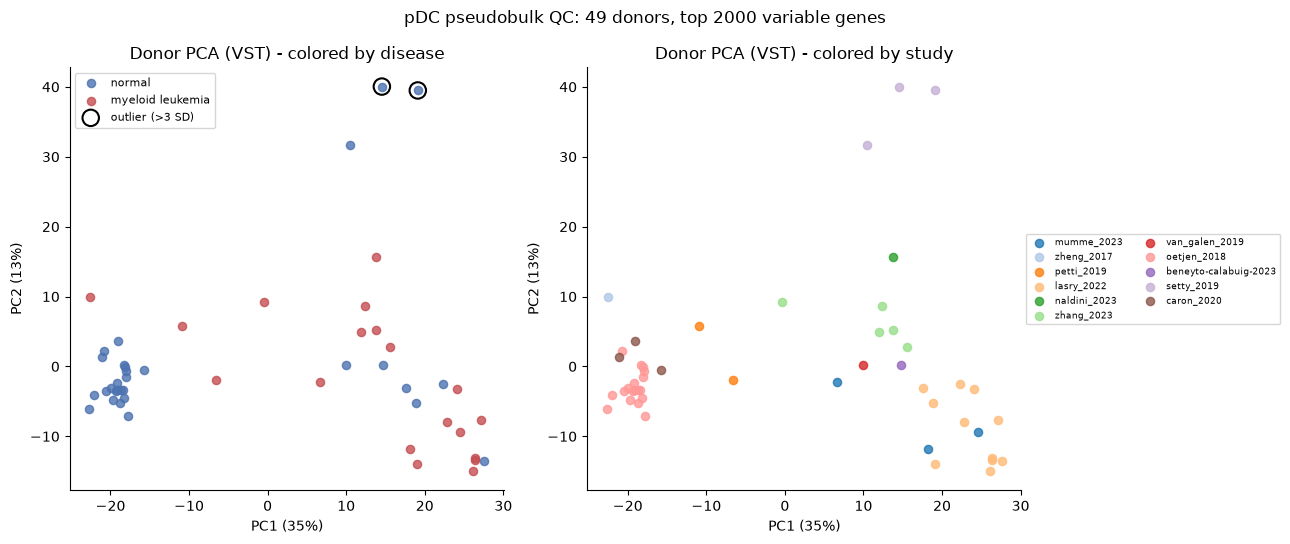

In [108]:
from sklearn.decomposition import PCA

gene_var = vst_df.var(axis=0).sort_values(ascending=False)
top_var_genes = gene_var.index[:2000]
Xc = vst_df[top_var_genes].values
Xc = Xc - Xc.mean(axis=0)
pca = PCA(n_components=10, random_state=0)
pcs = pca.fit_transform(Xc)
print("Variance explained by PC1-5:", np.round(pca.explained_variance_ratio_[:5], 3))

pc_df = pd.DataFrame(pcs[:, :2], columns=["PC1", "PC2"], index=vst_df.index).join(meta)
z1 = (pc_df["PC1"] - pc_df["PC1"].mean()) / pc_df["PC1"].std()
z2 = (pc_df["PC2"] - pc_df["PC2"].mean()) / pc_df["PC2"].std()
pc_df["outlier"] = (z1.abs() > 3) | (z2.abs() > 3)
outlier_donors = pc_df.index[pc_df["outlier"]].tolist()
print(f"Donors flagged as PCA outliers (>3 SD on PC1 or PC2): {outlier_donors}")

fig, axes = plt.subplots(1, 2, figsize=(13, 5.5))
disease_colors = {"normal": "#4c72b0", "myeloid leukemia": "#c44e52"}
for d, c in disease_colors.items():
    m = pc_df["disease"].astype(str) == d
    axes[0].scatter(pc_df.loc[m, "PC1"], pc_df.loc[m, "PC2"], s=35, alpha=0.8, color=c, label=d)
axes[0].scatter(pc_df.loc[pc_df["outlier"], "PC1"], pc_df.loc[pc_df["outlier"], "PC2"],
                s=140, facecolors="none", edgecolors="black", linewidths=1.5, label="outlier (>3 SD)")
axes[0].set_xlabel(f"PC1 ({pca.explained_variance_ratio_[0]*100:.0f}%)")
axes[0].set_ylabel(f"PC2 ({pca.explained_variance_ratio_[1]*100:.0f}%)")
axes[0].set_title("Donor PCA (VST) - colored by disease")
axes[0].legend(fontsize=8)

study_cats = pc_df["Study"].astype(str).unique()
study_colors2 = dict(zip(study_cats, sns.color_palette("tab20", len(study_cats))))
for s in study_cats:
    m = pc_df["Study"].astype(str) == s
    axes[1].scatter(pc_df.loc[m, "PC1"], pc_df.loc[m, "PC2"], s=35, alpha=0.8, color=study_colors2[s], label=s)
axes[1].set_xlabel(f"PC1 ({pca.explained_variance_ratio_[0]*100:.0f}%)")
axes[1].set_ylabel(f"PC2 ({pca.explained_variance_ratio_[1]*100:.0f}%)")
axes[1].set_title("Donor PCA (VST) - colored by study")
axes[1].legend(fontsize=6.5, ncol=2, loc="center left", bbox_to_anchor=(1.0, 0.5))

fig.suptitle(f"{LABEL} pseudobulk QC: {len(pc_df)} donors, top {len(top_var_genes)} variable genes")
fig.tight_layout()
plt.show()

In [109]:
mitocarta = pd.read_excel(os.path.join(DATA_DIR, "Human.MitoCarta3.0.xls"), sheet_name="A Human MitoCarta3.0")
mitocarta_genes = set(mitocarta["Symbol"].dropna().astype(str))

MT_GENES_ALL = sorted([g for g in gene_names if g.upper().startswith("MT-")])
mito_genes = sorted([g for g in mitocarta_genes if g in deseq_res.index])
n_mt_in_set = sum(g.upper().startswith("MT-") for g in mito_genes)
print(f"MitoCarta3.0: {len(mitocarta_genes)} genes total")
print(f"MitoCarta genes tested in this DE analysis: {len(mito_genes)} "
      f"({len(mito_genes) - n_mt_in_set} nuclear-encoded + {n_mt_in_set} mtDNA-encoded MT- genes)")

mito_table = deseq_res.loc[mito_genes].sort_values("padj")
mito_table["encoded_by"] = np.where(mito_table.index.str.upper().str.startswith("MT-"), "mtDNA", "nuclear")
display(mito_table.head(15)[["baseMean", "log2FoldChange", "lfcSE", "pvalue", "padj", "encoded_by"]])

MitoCarta3.0: 1136 genes total
MitoCarta genes tested in this DE analysis: 997 (984 nuclear-encoded + 13 mtDNA-encoded MT- genes)


,baseMean,log2FoldChange,lfcSE,pvalue,padj,encoded_by
NDUFB3,25.028746,-1.907671e+00,0.351324,9.103418e-07,0.001491,nuclear
ACADM,11.750472,-5.795925e-06,0.000501,1.919110e-04,0.039925,nuclear
UCP2,86.918904,-1.296600e-05,0.000496,2.334020e-04,0.040039,nuclear
SDHAF3,13.038898,-5.860372e-06,0.000493,3.119675e-04,0.047744,nuclear
CASP8,13.154211,1.043708e+00,0.267982,4.813423e-04,0.057226,nuclear
PRDX2,27.233423,-7.741906e-06,0.000524,1.126561e-03,0.096229,nuclear
PMAIP1,22.026126,1.257909e+00,0.368180,1.162349e-03,0.096945,nuclear
BAX,35.828320,1.034057e-05,0.000476,2.894795e-03,0.145652,nuclear
UQCRFS1,34.818552,4.836653e-06,0.000475,2.934919e-03,0.145675,nuclear
CAT,42.138720,-3.255291e-05,0.000482,3.161269e-03,0.148863,nuclear


Mitochondrial genes passing padj<0.05 & |log2FC|>0.5: 1
Mitochondrial genes with padj<0.05 (any effect size): 4


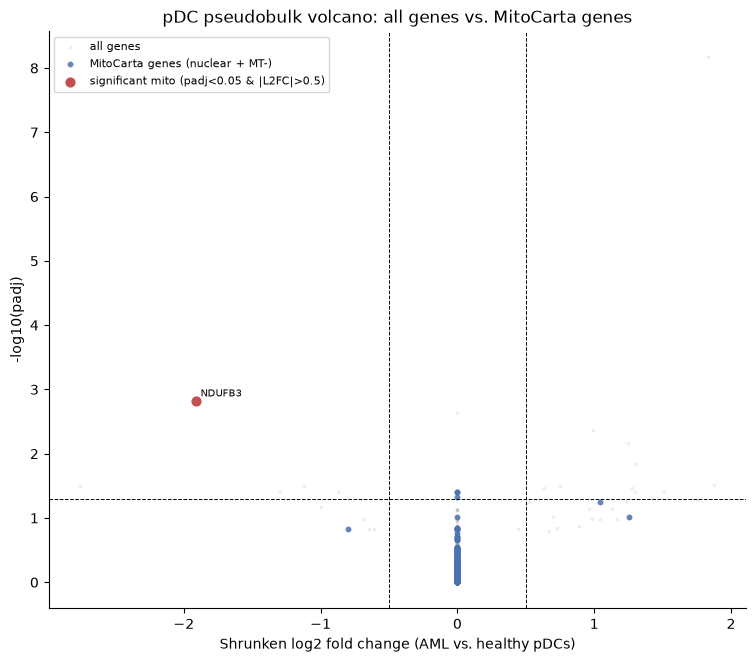

In [110]:
sig_mito = mito_table[(mito_table["padj"] < 0.05) & (mito_table["log2FoldChange"].abs() > 0.5)]
print(f"Mitochondrial genes passing padj<0.05 & |log2FC|>0.5: {len(sig_mito)}")
print(f"Mitochondrial genes with padj<0.05 (any effect size): {(mito_table['padj'] < 0.05).sum()}")
if len(sig_mito) == 0:
    print("None reach both thresholds simultaneously. Closest candidates (by padj):")
    print(mito_table.head(5)[["baseMean", "log2FoldChange", "padj", "encoded_by"]])

fig, ax = plt.subplots(figsize=(9, 7.5))
plot_df = deseq_res.dropna(subset=["padj"]).copy()
plot_df["neglog10padj"] = -np.log10(plot_df["padj"].clip(lower=1e-300))

ax.scatter(plot_df["log2FoldChange"], plot_df["neglog10padj"],
           s=6, alpha=0.25, color="#bbbbbb", linewidths=0, label="all genes")

mito_plot = plot_df.loc[plot_df.index.isin(mito_genes)]
ax.scatter(mito_plot["log2FoldChange"], mito_plot["neglog10padj"],
           s=18, alpha=0.85, color="#4c72b0", linewidths=0, label="MitoCarta genes (nuclear + MT-)")

if len(sig_mito) > 0:
    sig_plot = plot_df.loc[plot_df.index.isin(sig_mito.index)]
    ax.scatter(sig_plot["log2FoldChange"], sig_plot["neglog10padj"],
               s=40, color="#c44e52", label="significant mito (padj<0.05 & |L2FC|>0.5)")
    for gene, row in sig_plot.iterrows():
        ax.annotate(gene, (row["log2FoldChange"], row["neglog10padj"]), fontsize=7,
                    xytext=(3, 3), textcoords="offset points")
else:
    top5 = mito_table.head(5)
    top5_plot = plot_df.loc[plot_df.index.isin(top5.index)]
    ax.scatter(top5_plot["log2FoldChange"], top5_plot["neglog10padj"],
               s=40, color="#dd8452", label="top 5 mito genes (by padj, n.s.)")
    for gene, row in top5_plot.iterrows():
        ax.annotate(gene, (row["log2FoldChange"], row["neglog10padj"]), fontsize=7,
                    xytext=(3, 3), textcoords="offset points")

ax.axhline(-np.log10(0.05), color="black", lw=0.7, ls="--")
ax.axvline(0.5, color="black", lw=0.7, ls="--")
ax.axvline(-0.5, color="black", lw=0.7, ls="--")
ax.set_xlabel(f"Shrunken log2 fold change (AML vs. healthy {LABEL}s)")
ax.set_ylabel("-log10(padj)")
ax.set_title(f"{LABEL} pseudobulk volcano: all genes vs. MitoCarta genes")
ax.legend(fontsize=8, loc="upper left")
plt.show()

In [111]:
import gseapy as gp

GSEA_CACHE = os.path.join(RESULTS_DIR, f"{PFX}_gsea_results_mt_included.parquet")

mitopathways = pd.read_excel(os.path.join(DATA_DIR, "Human.MitoCarta3.0.xls"), sheet_name="C MitoPathways")
mitopathways = mitopathways.dropna(subset=["MitoPathway"])

gene_sets = {}
for _, row in mitopathways.iterrows():
    gene_sets[row["MitoPathway"]] = [g.strip() for g in str(row["Genes"]).split(",") if g.strip()]

gene_rank = deseq_res["log2FoldChange"].dropna().sort_values(ascending=False)
print(f"Ranked gene list (nuclear + MT-): {len(gene_rank)} genes; {len(gene_sets)} MitoPathway gene sets")

if os.path.exists(GSEA_CACHE):
    print("Loading cached GSEA results...")
    gsea_res = pd.read_parquet(GSEA_CACHE)
else:
    prerank = gp.prerank(
        rnk=gene_rank, gene_sets=gene_sets, min_size=5, max_size=500,
        permutation_num=1000, seed=0, threads=4, no_plot=True, outdir=None,
    )
    gsea_res = prerank.res2d.copy()
    gsea_res["NES"] = gsea_res["NES"].astype(float)
    gsea_res["FDR q-val"] = gsea_res["FDR q-val"].astype(float)
    gsea_res.to_parquet(GSEA_CACHE)

print(f"Pathways tested: {len(gsea_res)}")
print(f"Pathways with FDR q<0.05: {(gsea_res['FDR q-val'] < 0.05).sum()}")
sig_pathways = gsea_res[gsea_res["FDR q-val"] < 0.25].sort_values("NES")
print(f"Significant pathways (FDR q<0.25, standard GSEA convention): {len(sig_pathways)}")
sig_pathways[["Term", "NES", "NOM p-val", "FDR q-val"]]

Ranked gene list (nuclear + MT-): 13952 genes; 149 MitoPathway gene sets
Loading cached GSEA results...
Pathways tested: 111
Pathways with FDR q<0.05: 0
Significant pathways (FDR q<0.25, standard GSEA convention): 6


,Term,NES,NOM p-val,FDR q-val
0,CI subunits,-2.084032,0.038745,0.077417
1,Complex I,-2.073653,0.062157,0.094156
2,OXPHOS subunits,-2.058499,0.088768,0.107408
3,Complex IV,-2.051785,0.066190,0.096248
4,OXPHOS assembly factors,-2.033045,0.093578,0.108803
5,CIV assembly factors,-1.986050,0.042105,0.193369


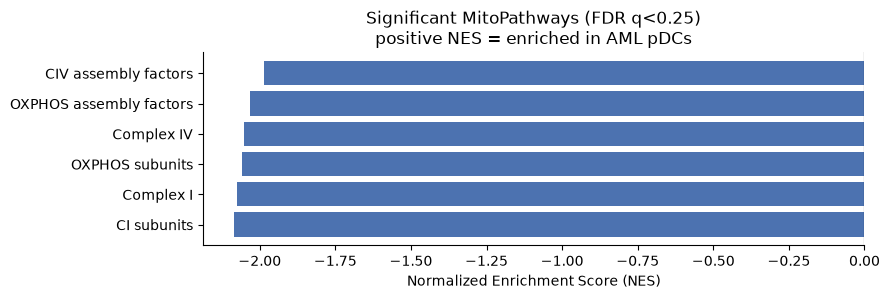

In [112]:
fig, ax = plt.subplots(figsize=(9, max(3, 0.35 * len(sig_pathways) + 1)))
if len(sig_pathways) > 0:
    colors_bar = ["#c44e52" if v > 0 else "#4c72b0" for v in sig_pathways["NES"]]
    ax.barh(sig_pathways["Term"], sig_pathways["NES"], color=colors_bar)
    ax.axvline(0, color="black", lw=0.8)
    ax.set_xlabel("Normalized Enrichment Score (NES)")
    ax.set_title(f"Significant MitoPathways (FDR q<0.25)\npositive NES = enriched in AML {LABEL}s")
else:
    ax.text(0.5, 0.5, "No MitoPathways reached FDR q<0.25", ha="center", va="center")
    ax.axis("off")
fig.tight_layout()
plt.show()

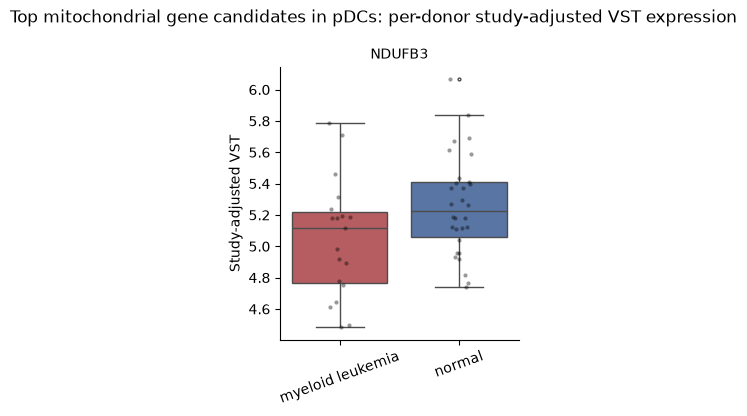

In [113]:
def study_adjusted(gene_vals, study_labels):
    df_tmp = pd.DataFrame({"v": gene_vals, "Study": study_labels})
    study_mean = df_tmp.groupby("Study")["v"].transform("mean")
    return df_tmp["v"] - study_mean + df_tmp["v"].mean()

top_genes_for_plot = (sig_mito.index.tolist() if len(sig_mito) > 0 else mito_table.head(5).index.tolist())[:5]

fig, axes = plt.subplots(1, len(top_genes_for_plot), figsize=(3.2 * len(top_genes_for_plot), 4.2), squeeze=False)
axes = axes[0]
for ax, gene in zip(axes, top_genes_for_plot):
    if use_study_covariate:
        vst_plot_vals = study_adjusted(vst_df[gene], meta["Study"])
        ylabel = "Study-adjusted VST"
    else:
        vst_plot_vals = vst_df[gene]
        ylabel = "VST"
    df_g = pd.DataFrame({ylabel: vst_plot_vals, "disease": meta["disease"].astype(str)})
    sns.boxplot(data=df_g, x="disease", y=ylabel, palette=disease_colors, ax=ax, fliersize=2)
    sns.stripplot(data=df_g, x="disease", y=ylabel, color="black", alpha=0.4, size=3, ax=ax)
    ax.set_title(gene, fontsize=10)
    ax.set_xlabel("")
    ax.tick_params(axis="x", rotation=20)
fig.suptitle(f"Top mitochondrial gene candidates in {LABEL}s: per-donor "
             + ("study-adjusted " if use_study_covariate else "") + "VST expression")
fig.tight_layout()
plt.show()

Top pathway (by |NES|, among those with >=5 leading-edge genes): Transcription  (NES=1.35, FDR q=1.000)
Leading-edge genes plotted: 5


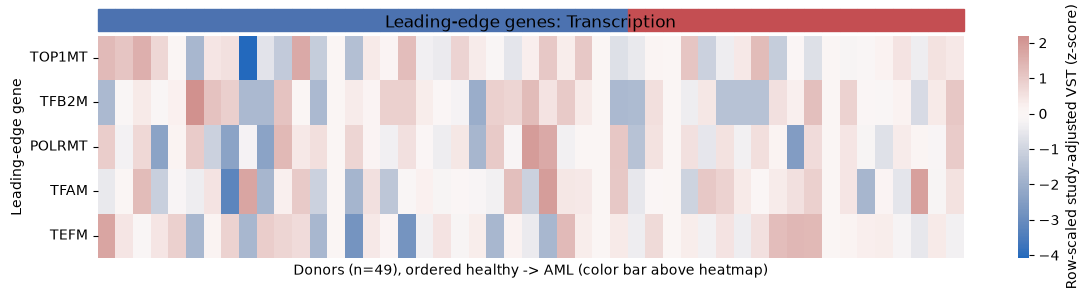

In [ ]:
MIN_LEADING_EDGE = 5   

def _enough_genes(df):
    n = df["Lead_genes"].map(lambda s: sum(g in vst_df.columns for g in str(s).split(";")))
    return df[n >= MIN_LEADING_EDGE]

cand_ok = _enough_genes(sig_pathways if len(sig_pathways) > 0 else gsea_res)
if len(cand_ok) == 0:
    cand_ok = _enough_genes(gsea_res)   # none of the significant ones qualifies: use any tested pathway
pool = cand_ok if len(cand_ok) > 0 else gsea_res
top_pathway = pool.loc[pool["NES"].abs().idxmax()]

top_pathway_name = top_pathway["Term"]
leading_edge_genes = [g for g in str(top_pathway["Lead_genes"]).split(";") if g in vst_df.columns]
print(f"Top pathway (by |NES|, among those with >={MIN_LEADING_EDGE} leading-edge genes): "
      f"{top_pathway_name}  (NES={top_pathway['NES']:.2f}, FDR q={top_pathway['FDR q-val']:.3f})")
print(f"Leading-edge genes plotted: {len(leading_edge_genes)}")

if len(leading_edge_genes) >= 2:
    order = meta.sort_values("disease").index
    if use_study_covariate:
        hm_source = pd.DataFrame(
            {g: study_adjusted(vst_df[g], meta["Study"]) for g in leading_edge_genes},
            index=vst_df.index,
        )
        cbar_label = "Row-scaled study-adjusted VST (z-score)"
    else:
        hm_source = vst_df[leading_edge_genes]
        cbar_label = "Row-scaled VST (z-score)"
    hm_data = hm_source.loc[order, leading_edge_genes].T
    hm_z = hm_data.sub(hm_data.mean(axis=1), axis=0).div(hm_data.std(axis=1), axis=0)

    fig, ax = plt.subplots(figsize=(12, max(3, 0.28 * len(leading_edge_genes))))
    sns.heatmap(hm_z, cmap="vlag", center=0, ax=ax,
                cbar_kws={"label": cbar_label},
                xticklabels=False, yticklabels=True)
    disease_track = meta.loc[order, "disease"].astype(str).map({"normal": 0, "myeloid leukemia": 1}).values
    for i, v in enumerate(disease_track):
        ax.add_patch(plt.Rectangle((i, -0.6), 1, 0.5,
                                    color=disease_colors["myeloid leukemia"] if v else disease_colors["normal"],
                                    clip_on=False))
    ax.set_ylabel("Leading-edge gene")
    ax.set_xlabel(f"Donors (n={len(order)}), ordered healthy -> AML (color bar above heatmap)")
    ax.set_title(f"Leading-edge genes: {top_pathway_name}")
    fig.tight_layout()
    plt.show()
else:
    print("Not enough leading-edge genes with VST values to plot a heatmap.")

RESULTS[PFX] = dict(label=LABEL, deseq=deseq_res, gsea=gsea_res, mito_table=mito_table,
                    mito_genes=mito_genes, meta=meta)

In [115]:
CT, LABEL, PFX = "plasma cell", "plasma cell", "plasma"
if "RESULTS" not in globals():
    RESULTS = {}

MIN_CELLS_PER_DONOR = 20
MIN_DONORS_PER_GROUP = 5

is_ct = (obs["cell_type"] == CT)
print(f"{LABEL}s before any donor-level filter: {is_ct.sum():,} cells, "
      f"{obs.loc[is_ct, 'donor_id'].nunique()} donors, "
      f"{obs.loc[is_ct, 'Study'].nunique()} studies")

ct_per_donor = (
    obs.loc[is_ct].groupby(["donor_id", "disease"], observed=True).size()
    .reset_index(name="n_cells_ct")
)
qualifying = ct_per_donor[ct_per_donor["n_cells_ct"] >= MIN_CELLS_PER_DONOR]
dropped = ct_per_donor[ct_per_donor["n_cells_ct"] < MIN_CELLS_PER_DONOR]
zero_donors = obs.loc[~obs["donor_id"].isin(ct_per_donor["donor_id"]), "donor_id"].nunique()

n_per_group = qualifying.groupby("disease", observed=True)["donor_id"].nunique()
assert (n_per_group >= MIN_DONORS_PER_GROUP).all(), "A disease group has <5 qualifying donors!"

print(f"\nDonors with ZERO {LABEL}s (dropped outright, mostly CD34+-sorted studies): {zero_donors}")
print(f"Donors with 1-{MIN_CELLS_PER_DONOR - 1} {LABEL}s (dropped, too few cells): "
      f"{dropped['donor_id'].nunique()}  ({dropped.groupby('disease', observed=True)['donor_id'].nunique().to_dict()})")
print(f"\nDonors KEPT (>={MIN_CELLS_PER_DONOR} {LABEL}s), per group:")
print(n_per_group)
print(f"\nTotal donors kept: {len(qualifying)} / {obs['donor_id'].nunique()} in the full atlas")
print(f"Total {LABEL}s kept for pseudobulk: {qualifying['n_cells_ct'].sum():,} "
      f"(of {is_ct.sum():,} {LABEL}s overall)")

qualifying_donors = qualifying["donor_id"].tolist()

studies_dropped_entirely = sorted(
    set(obs["Study"].unique())
    - set(obs.loc[obs["donor_id"].isin(qualifying_donors), "Study"].unique())
)
print(f"\nStudies with ZERO qualifying donors (effectively fully excluded): {studies_dropped_entirely}")

plasma cells before any donor-level filter: 2,949 cells, 130 donors, 16 studies

Donors with ZERO plasma cells (dropped outright, mostly CD34+-sorted studies): 80
Donors with 1-19 plasma cells (dropped, too few cells): 90  ({'myeloid leukemia': 71, 'normal': 19})

Donors KEPT (>=20 plasma cells), per group:
disease
myeloid leukemia    22
normal              18
Name: donor_id, dtype: int64

Total donors kept: 40 / 210 in the full atlas
Total plasma cells kept for pseudobulk: 2,490 (of 2,949 plasma cells overall)

Studies with ZERO qualifying donors (effectively fully excluded): ['fiskus_2023', 'human_cell_atlas', 'johnston_2020', 'pei_2020', 'setty_2019', 'stetson_2021', 'velten_2021', 'zhai_2022', 'zheng_2017']


In [116]:
PB_CACHE = os.path.join(RESULTS_DIR, f"{PFX}_pseudobulk_counts.parquet")
PB_META_CACHE = os.path.join(RESULTS_DIR, f"{PFX}_pseudobulk_donor_meta.parquet")

if os.path.exists(PB_CACHE) and os.path.exists(PB_META_CACHE):
    print(f"Loading cached {LABEL} pseudobulk matrix...")
    pb_counts = pd.read_parquet(PB_CACHE)
    donor_meta = pd.read_parquet(PB_META_CACHE)
else:
    donor_to_qidx = {d: i for i, d in enumerate(qualifying_donors)}
    n_donors_pb = len(qualifying_donors)
    donor_codes_arr = obs["donor_id"].values
    is_ct_arr = is_ct.values
    assign = np.full(n_cells, -1, dtype=np.int64)
    mask_keep_cell = is_ct_arr & np.isin(donor_codes_arr, qualifying_donors)
    keep_rows = np.where(mask_keep_cell)[0]
    assign[keep_rows] = np.array([donor_to_qidx[d] for d in donor_codes_arr[keep_rows]])

    t0 = time.time()
    pseudobulk = np.zeros((n_donors_pb, n_genes), dtype=np.float64)
    with h5py.File(H5_PATH, "r") as f:
        indptr = f["X/indptr"][:]
        raw_data_ds, raw_idx_ds = f["raw/X/data"], f["raw/X/indices"]
        for start in range(0, n_cells, CHUNK_ROWS):
            end = min(start + CHUNK_ROWS, n_cells)
            chunk_assign = assign[start:end]
            if not np.any(chunk_assign >= 0):
                continue
            s, e = int(indptr[start]), int(indptr[end])
            local_indptr = indptr[start:end + 1] - indptr[start]
            raw_chunk = sparse.csr_matrix(
                (raw_data_ds[s:e], raw_idx_ds[s:e], local_indptr),
                shape=(end - start, n_genes))
            valid = chunk_assign >= 0
            rows = np.where(valid)[0]
            indicator = sparse.csr_matrix(
                (np.ones(len(rows)), (chunk_assign[valid], rows)),
                shape=(n_donors_pb, end - start))
            pseudobulk += indicator.dot(raw_chunk).toarray()
    print(f"Pseudobulk scan done in {time.time()-t0:.0f}s")

    pb_counts = pd.DataFrame(pseudobulk, index=qualifying_donors, columns=gene_names)
    donor_meta = (
        obs[obs["donor_id"].isin(qualifying_donors)]
        .drop_duplicates("donor_id").set_index("donor_id")
        .loc[qualifying_donors, ["disease", "Study", "Fine Age Group", "Main Age Group", "sex", "ELN Risk Group"]]
    )
    pb_counts.to_parquet(PB_CACHE)
    donor_meta.to_parquet(PB_META_CACHE)

print(f"Pseudobulk matrix: {pb_counts.shape[0]} donors x {pb_counts.shape[1]} genes")
donor_meta["disease"].value_counts()

Loading cached plasma cell pseudobulk matrix...


Pseudobulk matrix: 40 donors x 21588 genes


disease
myeloid leukemia    22
normal              18
Name: count, dtype: int64

In [117]:
counts_all = pb_counts.round().astype(int)
gene_sums = counts_all.sum(axis=0)
counts_filt = counts_all.loc[:, gene_sums >= 10]
print(f"Genes after near-empty filter (sum>=10 across donors): {counts_filt.shape[1]} / {counts_all.shape[1]}")

meta = donor_meta.copy()
meta["disease"] = pd.Categorical(meta["disease"].astype(str), categories=["normal", "myeloid leukemia"])
meta["Study"] = meta["Study"].astype(str)

design_full = pd.get_dummies(meta[["Study", "disease"]], drop_first=True).astype(float)
design_full.insert(0, "intercept", 1.0)
rank = np.linalg.matrix_rank(design_full.values)
use_study_covariate = (rank == design_full.shape[1])
print(f"~ Study + disease design matrix: {design_full.shape}, rank {rank} "
      f"-> {'FULL RANK, using Study as covariate' if use_study_covariate else 'RANK DEFICIENT, falling back to ~ disease'}")

DESIGN_FORMULA = "~Study+disease" if use_study_covariate else "~disease"

Genes after near-empty filter (sum>=10 across donors): 12199 / 21588
~ Study + disease design matrix: (40, 12), rank 12 -> FULL RANK, using Study as covariate


In [118]:
from pydeseq2.dds import DeseqDataSet
from pydeseq2.ds import DeseqStats

DESEQ_CACHE = os.path.join(RESULTS_DIR, f"{PFX}_deseq_results.parquet")
VST_CACHE = os.path.join(RESULTS_DIR, f"{PFX}_vst.parquet")

if os.path.exists(DESEQ_CACHE) and os.path.exists(VST_CACHE):
    print("Loading cached DESeq2 results + VST matrix...")
    deseq_res = pd.read_parquet(DESEQ_CACHE)
    vst_df = pd.read_parquet(VST_CACHE)
else:
    dds = DeseqDataSet(counts=counts_filt, metadata=meta, design=DESIGN_FORMULA,
                        refit_cooks=True, quiet=True)
    dds.deseq2()

    dds.vst(use_design=False)
    vst_df = pd.DataFrame(dds.layers["vst_counts"], index=dds.obs_names, columns=dds.var_names)

    ds = DeseqStats(dds, contrast=["disease", "myeloid leukemia", "normal"], quiet=True)
    ds.summary()
    ds.lfc_shrink(coeff="disease[T.myeloid leukemia]")
    deseq_res = ds.results_df.copy()

    deseq_res.to_parquet(DESEQ_CACHE)
    vst_df.to_parquet(VST_CACHE)

print(f"DESeq2 results: {deseq_res.shape[0]} genes tested "
      f"(positive log2FC = higher in AML {LABEL}s vs. healthy {LABEL}s)")
print(f"Significant genes overall (padj < 0.05): {(deseq_res['padj'] < 0.05).sum()}")
deseq_res.sort_values("padj").head(10)

Loading cached DESeq2 results + VST matrix...


DESeq2 results: 12199 genes tested (positive log2FC = higher in AML plasma cells vs. healthy plasma cells)
Significant genes overall (padj < 0.05): 4


,baseMean,log2FoldChange,lfcSE,stat,pvalue,padj
IGKV2D-29,278.500808,-1.505073e-07,0.009372,13.383249,7.576150e-41,9.239115e-37
COMMD3,84.436113,3.316710e+00,0.977607,4.657133,3.206427e-06,1.955119e-02
GSTP1,229.227517,2.201190e+00,0.696208,4.403420,1.065575e-05,4.331562e-02
TMSB4X,1315.323552,-9.963952e-06,0.000623,-4.329832,1.492231e-05,4.549440e-02
CTSH,42.360028,1.312517e-06,0.000615,-4.126402,3.684828e-05,8.682783e-02
GADD45B,54.692278,1.557448e-06,0.000753,4.056378,4.983967e-05,8.682783e-02
CD27,150.371598,2.574765e-05,0.000633,-4.089247,4.327756e-05,8.682783e-02
CD52,130.180516,-2.987299e-06,0.000627,-3.694644,2.201951e-04,3.076698e-01
CCDC167,54.472089,-5.935014e-06,0.000642,-3.686833,2.270626e-04,3.076698e-01
TXNIP,135.280025,-5.175688e-06,0.000630,-3.460881,5.384110e-04,5.969020e-01


Variance explained by PC1-5: [0.288 0.149 0.104 0.075 0.048]
Donors flagged as PCA outliers (>3 SD on PC1 or PC2): ['AML420B', 'AML556']


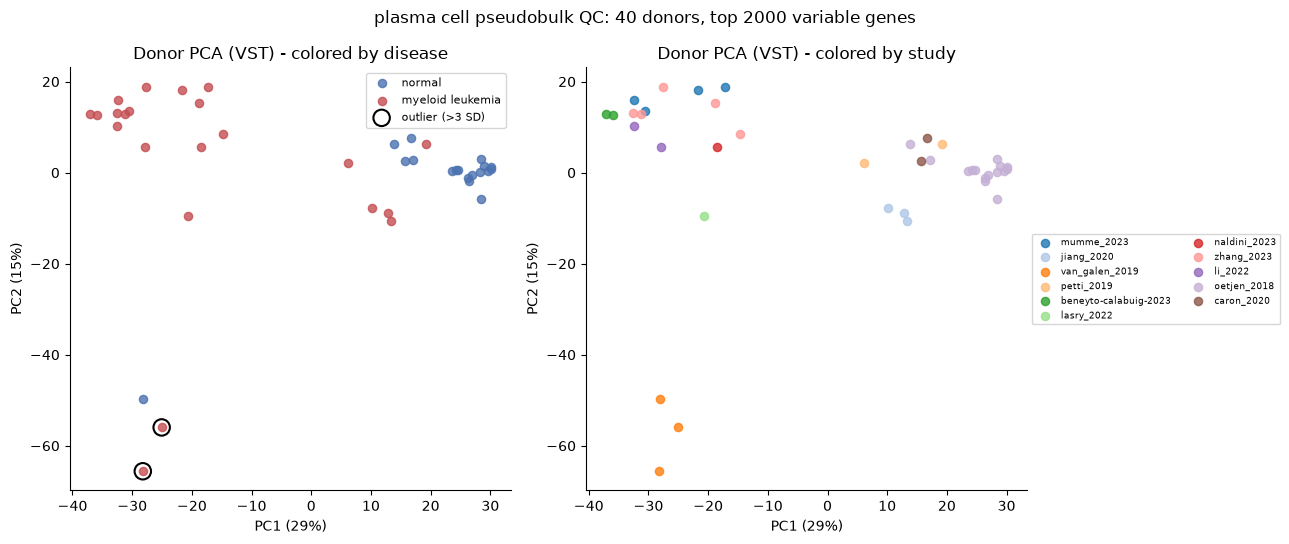

In [119]:
from sklearn.decomposition import PCA

gene_var = vst_df.var(axis=0).sort_values(ascending=False)
top_var_genes = gene_var.index[:2000]
Xc = vst_df[top_var_genes].values
Xc = Xc - Xc.mean(axis=0)
pca = PCA(n_components=10, random_state=0)
pcs = pca.fit_transform(Xc)
print("Variance explained by PC1-5:", np.round(pca.explained_variance_ratio_[:5], 3))

pc_df = pd.DataFrame(pcs[:, :2], columns=["PC1", "PC2"], index=vst_df.index).join(meta)
z1 = (pc_df["PC1"] - pc_df["PC1"].mean()) / pc_df["PC1"].std()
z2 = (pc_df["PC2"] - pc_df["PC2"].mean()) / pc_df["PC2"].std()
pc_df["outlier"] = (z1.abs() > 3) | (z2.abs() > 3)
outlier_donors = pc_df.index[pc_df["outlier"]].tolist()
print(f"Donors flagged as PCA outliers (>3 SD on PC1 or PC2): {outlier_donors}")

fig, axes = plt.subplots(1, 2, figsize=(13, 5.5))
disease_colors = {"normal": "#4c72b0", "myeloid leukemia": "#c44e52"}
for d, c in disease_colors.items():
    m = pc_df["disease"].astype(str) == d
    axes[0].scatter(pc_df.loc[m, "PC1"], pc_df.loc[m, "PC2"], s=35, alpha=0.8, color=c, label=d)
axes[0].scatter(pc_df.loc[pc_df["outlier"], "PC1"], pc_df.loc[pc_df["outlier"], "PC2"],
                s=140, facecolors="none", edgecolors="black", linewidths=1.5, label="outlier (>3 SD)")
axes[0].set_xlabel(f"PC1 ({pca.explained_variance_ratio_[0]*100:.0f}%)")
axes[0].set_ylabel(f"PC2 ({pca.explained_variance_ratio_[1]*100:.0f}%)")
axes[0].set_title("Donor PCA (VST) - colored by disease")
axes[0].legend(fontsize=8)

study_cats = pc_df["Study"].astype(str).unique()
study_colors2 = dict(zip(study_cats, sns.color_palette("tab20", len(study_cats))))
for s in study_cats:
    m = pc_df["Study"].astype(str) == s
    axes[1].scatter(pc_df.loc[m, "PC1"], pc_df.loc[m, "PC2"], s=35, alpha=0.8, color=study_colors2[s], label=s)
axes[1].set_xlabel(f"PC1 ({pca.explained_variance_ratio_[0]*100:.0f}%)")
axes[1].set_ylabel(f"PC2 ({pca.explained_variance_ratio_[1]*100:.0f}%)")
axes[1].set_title("Donor PCA (VST) - colored by study")
axes[1].legend(fontsize=6.5, ncol=2, loc="center left", bbox_to_anchor=(1.0, 0.5))

fig.suptitle(f"{LABEL} pseudobulk QC: {len(pc_df)} donors, top {len(top_var_genes)} variable genes")
fig.tight_layout()
plt.show()

In [120]:
mitocarta = pd.read_excel(os.path.join(DATA_DIR, "Human.MitoCarta3.0.xls"), sheet_name="A Human MitoCarta3.0")
mitocarta_genes = set(mitocarta["Symbol"].dropna().astype(str))

MT_GENES_ALL = sorted([g for g in gene_names if g.upper().startswith("MT-")])
mito_genes = sorted([g for g in mitocarta_genes if g in deseq_res.index])
n_mt_in_set = sum(g.upper().startswith("MT-") for g in mito_genes)
print(f"MitoCarta3.0: {len(mitocarta_genes)} genes total")
print(f"MitoCarta genes tested in this DE analysis: {len(mito_genes)} "
      f"({len(mito_genes) - n_mt_in_set} nuclear-encoded + {n_mt_in_set} mtDNA-encoded MT- genes)")

mito_table = deseq_res.loc[mito_genes].sort_values("padj")
mito_table["encoded_by"] = np.where(mito_table.index.str.upper().str.startswith("MT-"), "mtDNA", "nuclear")
display(mito_table.head(15)[["baseMean", "log2FoldChange", "lfcSE", "pvalue", "padj", "encoded_by"]])

MitoCarta3.0: 1136 genes total
MitoCarta genes tested in this DE analysis: 979 (966 nuclear-encoded + 13 mtDNA-encoded MT- genes)


,baseMean,log2FoldChange,lfcSE,pvalue,padj,encoded_by
AARS2,0.996924,2.587036e-07,0.000707,0.385669,0.998259,nuclear
AASS,0.320440,-2.064856e-07,0.001276,0.580578,0.998259,nuclear
ABAT,0.455684,2.013032e-09,0.000960,0.956463,0.998259,nuclear
ABCB10,2.905594,-3.300444e-07,0.000686,0.411199,0.998259,nuclear
ABCB6,0.376348,3.656562e-07,0.001260,0.820325,0.998259,nuclear
ABCB7,3.787567,-8.482814e-06,0.000685,0.478199,0.998259,nuclear
ABCB8,5.401052,2.474424e-07,0.000684,0.504752,0.998259,nuclear
ABCD1,0.808907,-2.013027e-07,0.000804,0.947874,0.998259,nuclear
ABCD2,1.045414,1.193840e-07,0.000898,0.864639,0.998259,nuclear
ABCD3,3.271970,1.061339e-06,0.000672,0.635939,0.998259,nuclear


Mitochondrial genes passing padj<0.05 & |log2FC|>0.5: 0
Mitochondrial genes with padj<0.05 (any effect size): 0
None reach both thresholds simultaneously. Closest candidates (by padj):
        baseMean  log2FoldChange      padj encoded_by
AARS2   0.996924    2.587036e-07  0.998259    nuclear
AASS    0.320440   -2.064856e-07  0.998259    nuclear
ABAT    0.455684    2.013032e-09  0.998259    nuclear
ABCB10  2.905594   -3.300444e-07  0.998259    nuclear
ABCB6   0.376348    3.656562e-07  0.998259    nuclear


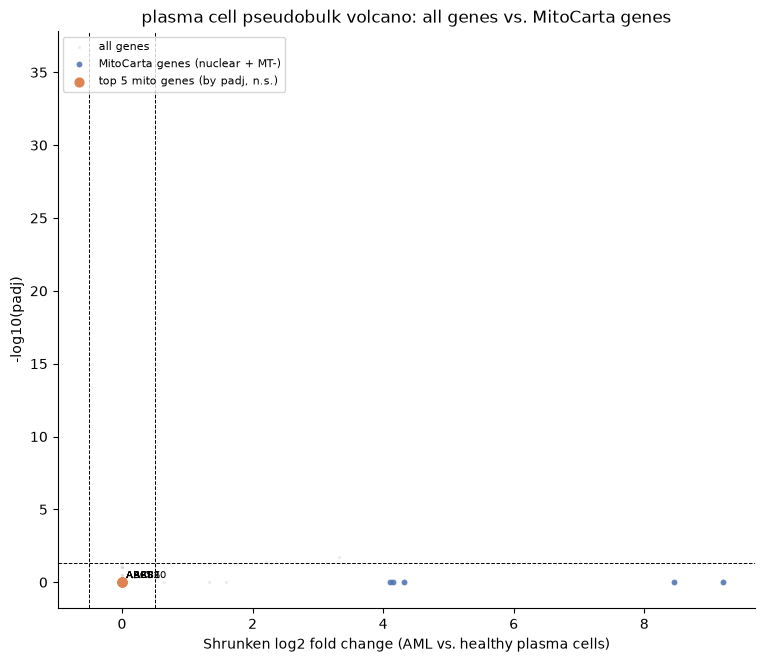

In [121]:
sig_mito = mito_table[(mito_table["padj"] < 0.05) & (mito_table["log2FoldChange"].abs() > 0.5)]
print(f"Mitochondrial genes passing padj<0.05 & |log2FC|>0.5: {len(sig_mito)}")
print(f"Mitochondrial genes with padj<0.05 (any effect size): {(mito_table['padj'] < 0.05).sum()}")
if len(sig_mito) == 0:
    print("None reach both thresholds simultaneously. Closest candidates (by padj):")
    print(mito_table.head(5)[["baseMean", "log2FoldChange", "padj", "encoded_by"]])

fig, ax = plt.subplots(figsize=(9, 7.5))
plot_df = deseq_res.dropna(subset=["padj"]).copy()
plot_df["neglog10padj"] = -np.log10(plot_df["padj"].clip(lower=1e-300))

ax.scatter(plot_df["log2FoldChange"], plot_df["neglog10padj"],
           s=6, alpha=0.25, color="#bbbbbb", linewidths=0, label="all genes")

mito_plot = plot_df.loc[plot_df.index.isin(mito_genes)]
ax.scatter(mito_plot["log2FoldChange"], mito_plot["neglog10padj"],
           s=18, alpha=0.85, color="#4c72b0", linewidths=0, label="MitoCarta genes (nuclear + MT-)")

if len(sig_mito) > 0:
    sig_plot = plot_df.loc[plot_df.index.isin(sig_mito.index)]
    ax.scatter(sig_plot["log2FoldChange"], sig_plot["neglog10padj"],
               s=40, color="#c44e52", label="significant mito (padj<0.05 & |L2FC|>0.5)")
    for gene, row in sig_plot.iterrows():
        ax.annotate(gene, (row["log2FoldChange"], row["neglog10padj"]), fontsize=7,
                    xytext=(3, 3), textcoords="offset points")
else:
    top5 = mito_table.head(5)
    top5_plot = plot_df.loc[plot_df.index.isin(top5.index)]
    ax.scatter(top5_plot["log2FoldChange"], top5_plot["neglog10padj"],
               s=40, color="#dd8452", label="top 5 mito genes (by padj, n.s.)")
    for gene, row in top5_plot.iterrows():
        ax.annotate(gene, (row["log2FoldChange"], row["neglog10padj"]), fontsize=7,
                    xytext=(3, 3), textcoords="offset points")

ax.axhline(-np.log10(0.05), color="black", lw=0.7, ls="--")
ax.axvline(0.5, color="black", lw=0.7, ls="--")
ax.axvline(-0.5, color="black", lw=0.7, ls="--")
ax.set_xlabel(f"Shrunken log2 fold change (AML vs. healthy {LABEL}s)")
ax.set_ylabel("-log10(padj)")
ax.set_title(f"{LABEL} pseudobulk volcano: all genes vs. MitoCarta genes")
ax.legend(fontsize=8, loc="upper left")
plt.show()

In [122]:
import gseapy as gp

GSEA_CACHE = os.path.join(RESULTS_DIR, f"{PFX}_gsea_results_mt_included.parquet")

mitopathways = pd.read_excel(os.path.join(DATA_DIR, "Human.MitoCarta3.0.xls"), sheet_name="C MitoPathways")
mitopathways = mitopathways.dropna(subset=["MitoPathway"])

gene_sets = {}
for _, row in mitopathways.iterrows():
    gene_sets[row["MitoPathway"]] = [g.strip() for g in str(row["Genes"]).split(",") if g.strip()]

gene_rank = deseq_res["log2FoldChange"].dropna().sort_values(ascending=False)
print(f"Ranked gene list (nuclear + MT-): {len(gene_rank)} genes; {len(gene_sets)} MitoPathway gene sets")

if os.path.exists(GSEA_CACHE):
    print("Loading cached GSEA results...")
    gsea_res = pd.read_parquet(GSEA_CACHE)
else:
    prerank = gp.prerank(
        rnk=gene_rank, gene_sets=gene_sets, min_size=5, max_size=500,
        permutation_num=1000, seed=0, threads=4, no_plot=True, outdir=None,
    )
    gsea_res = prerank.res2d.copy()
    gsea_res["NES"] = gsea_res["NES"].astype(float)
    gsea_res["FDR q-val"] = gsea_res["FDR q-val"].astype(float)
    gsea_res.to_parquet(GSEA_CACHE)

print(f"Pathways tested: {len(gsea_res)}")
print(f"Pathways with FDR q<0.05: {(gsea_res['FDR q-val'] < 0.05).sum()}")
sig_pathways = gsea_res[gsea_res["FDR q-val"] < 0.25].sort_values("NES")
print(f"Significant pathways (FDR q<0.25, standard GSEA convention): {len(sig_pathways)}")
sig_pathways[["Term", "NES", "NOM p-val", "FDR q-val"]]

Ranked gene list (nuclear + MT-): 12199 genes; 149 MitoPathway gene sets
Loading cached GSEA results...
Pathways tested: 110
Pathways with FDR q<0.05: 0
Significant pathways (FDR q<0.25, standard GSEA convention): 15


,Term,NES,NOM p-val,FDR q-val
15,Copper metabolism,1.451613,0.059273,0.249063
13,Metabolism,1.614405,0.108108,0.145704
12,Heme-containing proteins,1.702511,0.001805,0.138679
11,CIII subunits,1.723846,0.007233,0.147489
10,Cristae formation,1.741516,0.003824,0.158828
9,Electron carriers,1.801646,0.007380,0.168353
8,Complex III,1.852584,0.007055,0.174414
7,CV subunits,1.867963,0.001855,0.177575
6,CIV subunits,1.874603,0.008818,0.201037
5,Complex V,1.904786,0.001876,0.223425


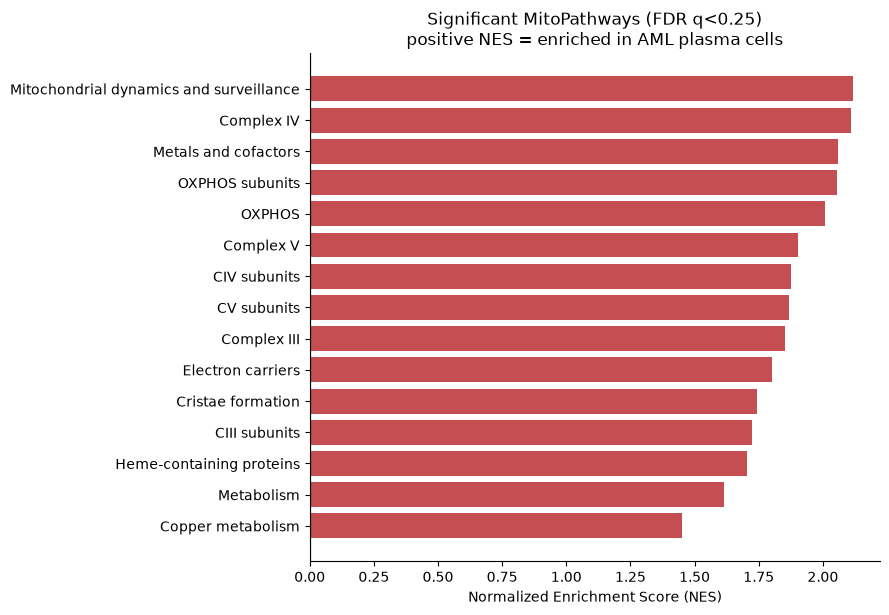

In [123]:
fig, ax = plt.subplots(figsize=(9, max(3, 0.35 * len(sig_pathways) + 1)))
if len(sig_pathways) > 0:
    colors_bar = ["#c44e52" if v > 0 else "#4c72b0" for v in sig_pathways["NES"]]
    ax.barh(sig_pathways["Term"], sig_pathways["NES"], color=colors_bar)
    ax.axvline(0, color="black", lw=0.8)
    ax.set_xlabel("Normalized Enrichment Score (NES)")
    ax.set_title(f"Significant MitoPathways (FDR q<0.25)\npositive NES = enriched in AML {LABEL}s")
else:
    ax.text(0.5, 0.5, "No MitoPathways reached FDR q<0.25", ha="center", va="center")
    ax.axis("off")
fig.tight_layout()
plt.show()

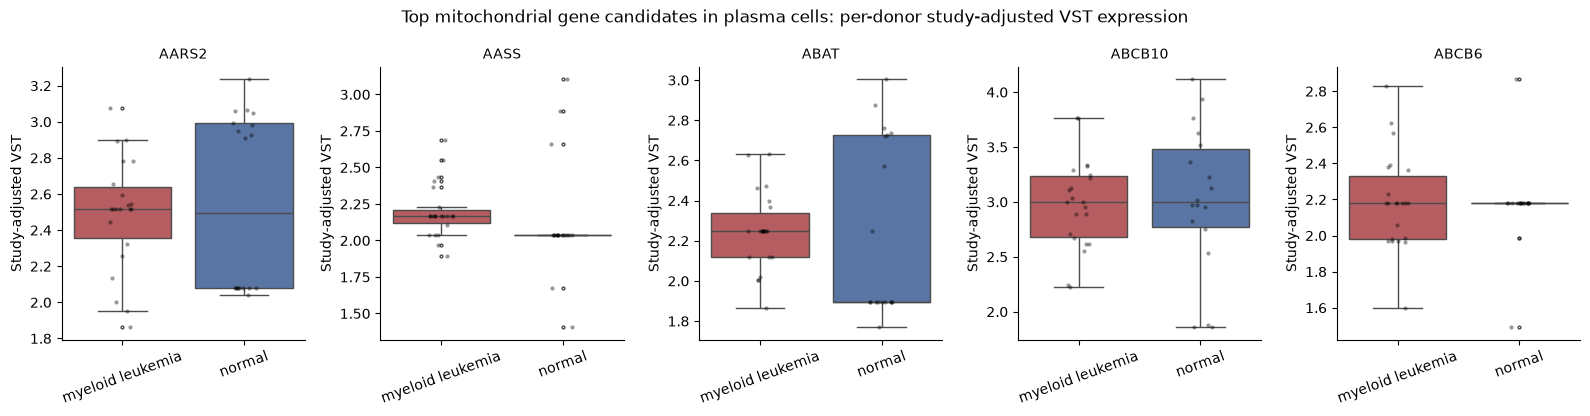

In [124]:
def study_adjusted(gene_vals, study_labels):
    df_tmp = pd.DataFrame({"v": gene_vals, "Study": study_labels})
    study_mean = df_tmp.groupby("Study")["v"].transform("mean")
    return df_tmp["v"] - study_mean + df_tmp["v"].mean()

top_genes_for_plot = (sig_mito.index.tolist() if len(sig_mito) > 0 else mito_table.head(5).index.tolist())[:5]

fig, axes = plt.subplots(1, len(top_genes_for_plot), figsize=(3.2 * len(top_genes_for_plot), 4.2), squeeze=False)
axes = axes[0]
for ax, gene in zip(axes, top_genes_for_plot):
    if use_study_covariate:
        vst_plot_vals = study_adjusted(vst_df[gene], meta["Study"])
        ylabel = "Study-adjusted VST"
    else:
        vst_plot_vals = vst_df[gene]
        ylabel = "VST"
    df_g = pd.DataFrame({ylabel: vst_plot_vals, "disease": meta["disease"].astype(str)})
    sns.boxplot(data=df_g, x="disease", y=ylabel, palette=disease_colors, ax=ax, fliersize=2)
    sns.stripplot(data=df_g, x="disease", y=ylabel, color="black", alpha=0.4, size=3, ax=ax)
    ax.set_title(gene, fontsize=10)
    ax.set_xlabel("")
    ax.tick_params(axis="x", rotation=20)
fig.suptitle(f"Top mitochondrial gene candidates in {LABEL}s: per-donor "
             + ("study-adjusted " if use_study_covariate else "") + "VST expression")
fig.tight_layout()
plt.show()

Top pathway (by |NES|, among those with >=5 leading-edge genes): OXPHOS subunits  (NES=2.06, FDR q=0.147)
Leading-edge genes plotted: 5


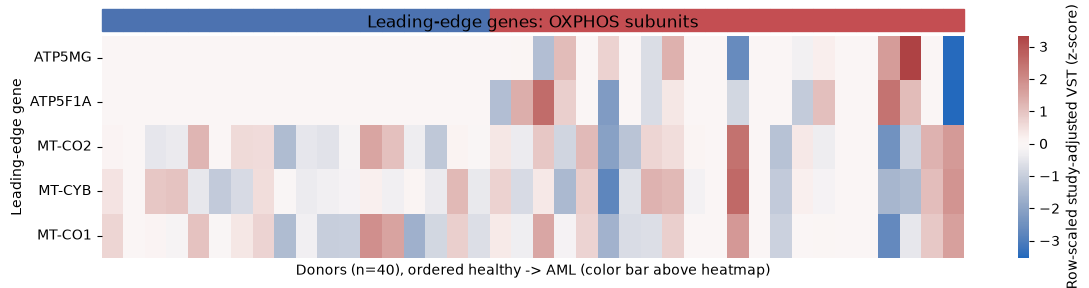

In [125]:
MIN_LEADING_EDGE = 5   # a heatmap needs several genes; skip pathways whose leading edge is (almost) empty

def _enough_genes(df):
    n = df["Lead_genes"].map(lambda s: sum(g in vst_df.columns for g in str(s).split(";")))
    return df[n >= MIN_LEADING_EDGE]

cand_ok = _enough_genes(sig_pathways if len(sig_pathways) > 0 else gsea_res)
if len(cand_ok) == 0:
    cand_ok = _enough_genes(gsea_res)   # none of the significant ones qualifies: use any tested pathway
pool = cand_ok if len(cand_ok) > 0 else gsea_res
top_pathway = pool.loc[pool["NES"].abs().idxmax()]

top_pathway_name = top_pathway["Term"]
leading_edge_genes = [g for g in str(top_pathway["Lead_genes"]).split(";") if g in vst_df.columns]
print(f"Top pathway (by |NES|, among those with >={MIN_LEADING_EDGE} leading-edge genes): "
      f"{top_pathway_name}  (NES={top_pathway['NES']:.2f}, FDR q={top_pathway['FDR q-val']:.3f})")
print(f"Leading-edge genes plotted: {len(leading_edge_genes)}")

if len(leading_edge_genes) >= 2:
    order = meta.sort_values("disease").index
    if use_study_covariate:
        hm_source = pd.DataFrame(
            {g: study_adjusted(vst_df[g], meta["Study"]) for g in leading_edge_genes},
            index=vst_df.index,
        )
        cbar_label = "Row-scaled study-adjusted VST (z-score)"
    else:
        hm_source = vst_df[leading_edge_genes]
        cbar_label = "Row-scaled VST (z-score)"
    hm_data = hm_source.loc[order, leading_edge_genes].T
    hm_z = hm_data.sub(hm_data.mean(axis=1), axis=0).div(hm_data.std(axis=1), axis=0)

    fig, ax = plt.subplots(figsize=(12, max(3, 0.28 * len(leading_edge_genes))))
    sns.heatmap(hm_z, cmap="vlag", center=0, ax=ax,
                cbar_kws={"label": cbar_label},
                xticklabels=False, yticklabels=True)
    disease_track = meta.loc[order, "disease"].astype(str).map({"normal": 0, "myeloid leukemia": 1}).values
    for i, v in enumerate(disease_track):
        ax.add_patch(plt.Rectangle((i, -0.6), 1, 0.5,
                                    color=disease_colors["myeloid leukemia"] if v else disease_colors["normal"],
                                    clip_on=False))
    ax.set_ylabel("Leading-edge gene")
    ax.set_xlabel(f"Donors (n={len(order)}), ordered healthy -> AML (color bar above heatmap)")
    ax.set_title(f"Leading-edge genes: {top_pathway_name}")
    fig.tight_layout()
    plt.show()
else:
    print("Not enough leading-edge genes with VST values to plot a heatmap.")

RESULTS[PFX] = dict(label=LABEL, deseq=deseq_res, gsea=gsea_res, mito_table=mito_table,
                    mito_genes=mito_genes, meta=meta)

17. Comparison across all cell types

In [126]:
ORDER = list(RESULTS.keys())
print("Cell types analysed:", [RESULTS[k]["label"] for k in ORDER])

rows = []
for k in ORDER:
    R = RESULTS[k]
    d, g, m, mt = R["deseq"], R["gsea"], R["mito_table"], R["meta"]
    top = g.loc[g["NES"].abs().idxmax()]
    rows.append({
        "cell type": R["label"],
        "donors healthy": int((mt["disease"].astype(str) == "normal").sum()),
        "donors AML": int((mt["disease"].astype(str) == "myeloid leukemia").sum()),
        "genes tested": len(d),
        "genes padj<0.05": int((d["padj"] < 0.05).sum()),
        "mito genes tested": len(m),
        "mito padj<0.05": int((m["padj"] < 0.05).sum()),
        "mito padj<0.05 & |LFC|>0.5": int(((m["padj"] < 0.05) & (m["log2FoldChange"].abs() > 0.5)).sum()),
        "pathways tested": len(g),
        "pathways FDR<0.05 up": int(((g["FDR q-val"] < 0.05) & (g["NES"] > 0)).sum()),
        "pathways FDR<0.05 down": int(((g["FDR q-val"] < 0.05) & (g["NES"] < 0)).sum()),
        "pathways FDR<0.25": int((g["FDR q-val"] < 0.25).sum()),
        "FDR<0.25 pathways driven by <5 genes": int(((g["FDR q-val"] < 0.25)
            & (g["Lead_genes"].map(lambda s: len(str(s).split(";"))) < 5)).sum()),
        "genes with LFC~0 (%)": int(round(100 * (d["log2FoldChange"].dropna().abs() < 1e-6).mean())),
        "top pathway (|NES|)": top["Term"],
        "top NES": round(float(top["NES"]), 2),
        "top FDR": round(float(top["FDR q-val"]), 3),
    })
summary_all = pd.DataFrame(rows).set_index("cell type")
summary_all

Cell types analysed: ['T cell', 'NK cell', 'B cell', 'monocyte', 'promonocyte', 'erythroid cell', 'cDC', 'HSC', 'pDC', 'plasma cell']


,donors healthy,donors AML,genes tested,genes padj<0.05,mito genes tested,mito padj<0.05,mito padj<0.05 & |LFC|>0.5,pathways tested,pathways FDR<0.05 up,pathways FDR<0.05 down,pathways FDR<0.25,FDR<0.25 pathways driven by <5 genes,genes with LFC~0 (%),top pathway (|NES|),top NES,top FDR
cell type,,,,,,,,,,,,,,,,
T cell,46,114,18414,27,1029,2,0,114,10,0,30,6,0,OXPHOS subunits,2.23,0.000
NK cell,37,71,14333,0,994,0,0,110,11,0,20,3,0,OXPHOS subunits,2.38,0.000
B cell,43,85,14945,16,1000,3,3,113,0,0,13,3,0,OXPHOS subunits,2.06,0.063
monocyte,48,112,19094,117,1037,3,3,114,0,0,0,0,0,Ketone metabolism,-1.45,1.000
promonocyte,36,73,18778,153,1034,10,9,113,0,0,0,0,38,Calcium homeostasis,-1.74,0.953
erythroid cell,42,71,20074,825,1039,59,49,114,0,11,21,0,0,Translation,-2.03,0.002
cDC,31,58,15842,158,1015,9,6,113,0,0,1,0,0,OXPHOS subunits,-1.78,0.233
HSC,35,146,21209,405,1041,22,20,114,0,0,0,0,0,Apoptosis,1.46,0.906
pDC,30,19,13952,27,997,4,1,111,0,0,6,6,49,CI subunits,-2.08,0.077


Pathway NES across cell types

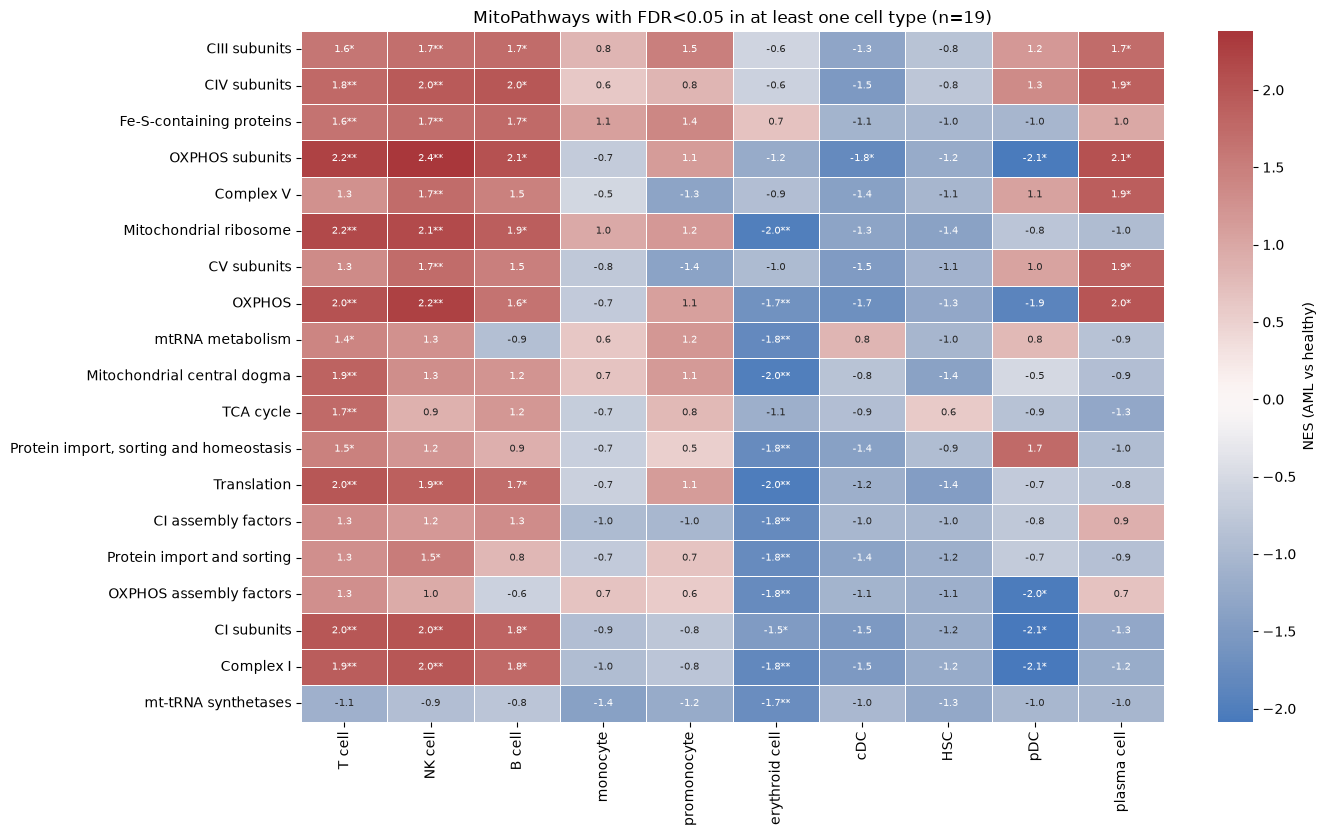

In [127]:
nes = pd.DataFrame({RESULTS[k]["label"]: RESULTS[k]["gsea"].set_index("Term")["NES"] for k in ORDER})
fdr = pd.DataFrame({RESULTS[k]["label"]: RESULTS[k]["gsea"].set_index("Term")["FDR q-val"] for k in ORDER})

sig_any = fdr.index[(fdr < 0.05).any(axis=1)]
nes_s, fdr_s = nes.loc[sig_any], fdr.loc[sig_any]
row_order = nes_s.mean(axis=1).sort_values(ascending=False).index
nes_s, fdr_s = nes_s.loc[row_order], fdr_s.loc[row_order]
stars = fdr_s.map(lambda v: "" if pd.isna(v) else ("**" if v < 0.05 else ("*" if v < 0.25 else "")))
annot = nes_s.round(1).astype(str).where(nes_s.notna(), "") + stars

fig, ax = plt.subplots(figsize=(1.0 * len(ORDER) + 4, 0.34 * len(nes_s) + 2))
sns.heatmap(nes_s, annot=annot, fmt="", cmap="vlag", center=0, ax=ax,
            cbar_kws={"label": "NES (AML vs healthy)"}, linewidths=0.4, linecolor="white",
            annot_kws={"fontsize": 7})
ax.set_ylabel("")
ax.set_title(f"MitoPathways with FDR<0.05 in at least one cell type (n={len(nes_s)})")
fig.tight_layout()
plt.show()

Consistency of each pathway across cell types

In [128]:
cons = pd.DataFrame({
    "n types tested": nes.notna().sum(axis=1),
    "n up (FDR<0.05)": ((fdr < 0.05) & (nes > 0)).sum(axis=1),
    "n down (FDR<0.05)": ((fdr < 0.05) & (nes < 0)).sum(axis=1),
    "n up (FDR<0.25)": ((fdr < 0.25) & (nes > 0)).sum(axis=1),
    "n with NES>0": (nes > 0).sum(axis=1),
    "mean NES": nes.mean(axis=1).round(2),
})
cons = cons[(cons["n up (FDR<0.05)"] + cons["n down (FDR<0.05)"]) > 0]
cons.sort_values(["n up (FDR<0.05)", "mean NES"], ascending=False)

,n types tested,n up (FDR<0.05),n down (FDR<0.05),n up (FDR<0.25),n with NES>0,mean NES
Term,,,,,,
CIV subunits,10,2,0,4,7,0.74
Fe-S-containing proteins,10,2,0,3,7,0.61
OXPHOS subunits,10,2,0,4,5,0.29
Mitochondrial ribosome,10,2,1,3,5,0.19
OXPHOS,10,2,1,4,5,0.17
Translation,10,2,1,3,4,-0.01
CI subunits,10,2,0,3,3,-0.34
Complex I,10,2,1,3,3,-0.39
CIII subunits,10,1,0,4,7,0.75


Similarity between cell types

Spearman correlation between cell types, computed on (left) the log2FC of the MitoCarta genes
tested in all cell types and (right) the NES of the pathways tested in all cell types. 

MitoCarta genes tested in all 10 cell types: 969
MitoPathways tested in all 10 cell types: 108


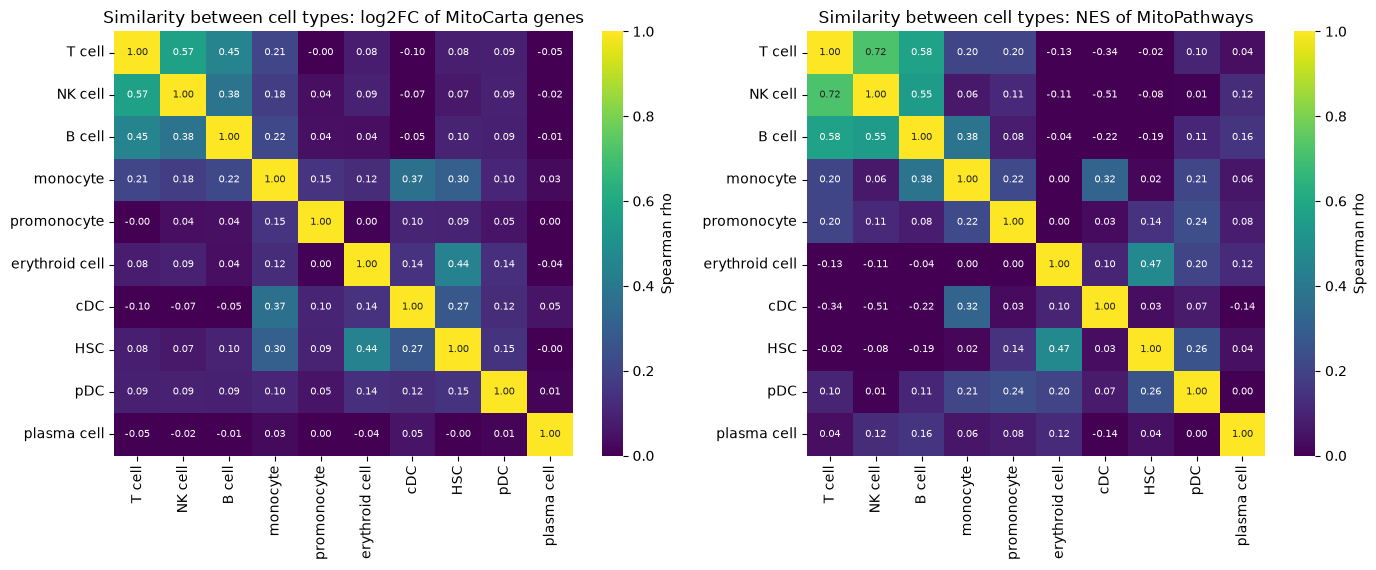

In [129]:
from scipy.stats import spearmanr

lab = [RESULTS[k]["label"] for k in ORDER]

shared_genes = sorted(set.intersection(*[set(RESULTS[k]["mito_genes"]) for k in ORDER]))
lfc_all = pd.DataFrame({RESULTS[k]["label"]: RESULTS[k]["deseq"].loc[shared_genes, "log2FoldChange"] for k in ORDER}).dropna()
nes_common = nes.dropna()
print(f"MitoCarta genes tested in all {len(ORDER)} cell types: {len(lfc_all)}")
print(f"MitoPathways tested in all {len(ORDER)} cell types: {len(nes_common)}")

corr_g = lfc_all.corr(method="spearman")
corr_p = nes_common.corr(method="spearman")

fig, axes = plt.subplots(1, 2, figsize=(14, 5.8))
for ax, cm, title in [(axes[0], corr_g, "log2FC of MitoCarta genes"), (axes[1], corr_p, "NES of MitoPathways")]:
    sns.heatmap(cm, annot=True, fmt=".2f", cmap="viridis", vmin=0, vmax=1, ax=ax,
                cbar_kws={"label": "Spearman rho"}, annot_kws={"fontsize": 7})
    ax.set_title(f"Similarity between cell types: {title}")
fig.tight_layout()
plt.show()

OXPHOS pathways in every cell type

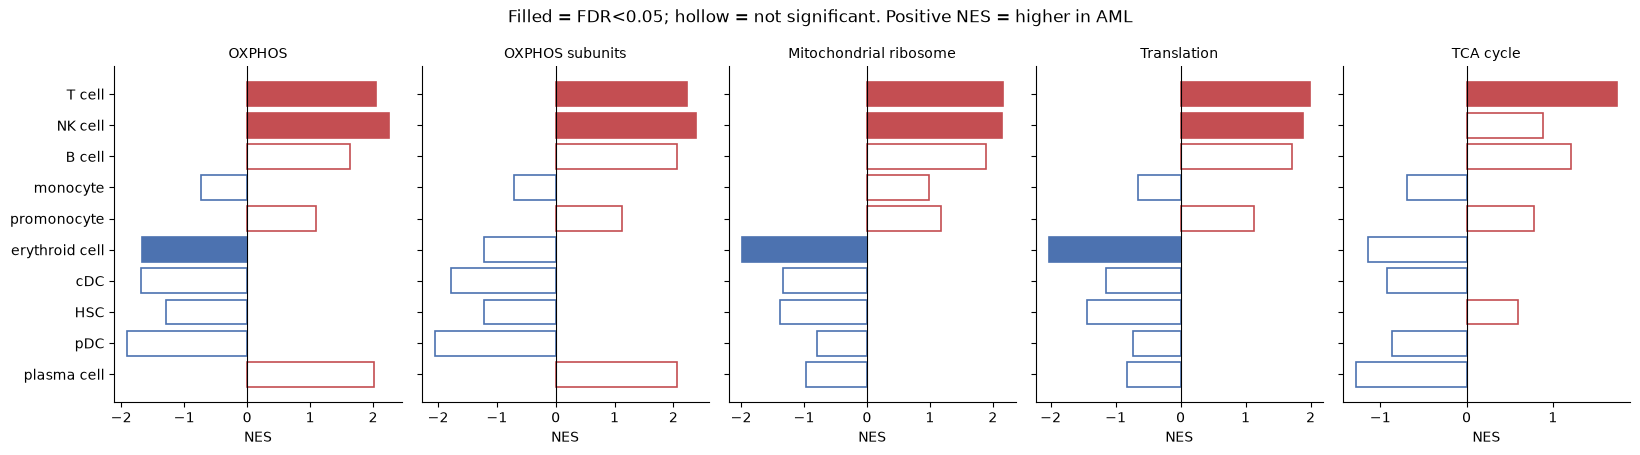

In [130]:
focus = [t for t in ["OXPHOS", "OXPHOS subunits", "Mitochondrial ribosome", "Translation", "TCA cycle"] if t in nes.index]
fig, axes = plt.subplots(1, len(focus), figsize=(3.3 * len(focus), 4.6), sharey=True, squeeze=False)
axes = axes[0]
for ax, term in zip(axes, focus):
    vals = nes.loc[term, lab]
    sig = fdr.loc[term, lab] < 0.05
    y = np.arange(len(lab))
    ax.barh(y, vals.fillna(0).values,
            color=["#c44e52" if (s and v > 0) else ("#4c72b0" if (s and v < 0) else "white") for v, s in zip(vals.fillna(0), sig)],
            edgecolor=["#c44e52" if v > 0 else "#4c72b0" for v in vals.fillna(0)], linewidth=1.2)
    ax.set_yticks(y); ax.set_yticklabels(lab)
    ax.invert_yaxis()
    ax.axvline(0, color="black", lw=0.8)
    ax.set_title(term, fontsize=10)
    ax.set_xlabel("NES")
fig.suptitle("Filled = FDR<0.05; hollow = not significant. Positive NES = higher in AML")
fig.tight_layout()
plt.show()